In [2]:
import pandas as pd
import pickle
import json
from matplotlib import pyplot as plt
import torch
import numpy as np
import os
import itertools
import seaborn as sns
import warnings
import scanpy as sc
import time
import torch
import torch.nn as nn
from tqdm import tqdm
from torch.utils.data import Dataset,DataLoader
import copy
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=DeprecationWarning)
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300



# CREATE DATAFRAME WITH TRAIN PARAMETER COMBINATIONS FOR SLURM PARALLEL COMPUTING

In [48]:
parameters_for_analysis={'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},
            
                        'tb21_22_2984_pats_22_vars_relapse':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'}, 

                         'tb21_22_2984_pats_22_vars_result_at_end_of_treatment_mb_only':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},

                         'tb21_22_2984_pats_22_vars_result_at_end_of_treatment_without_mb':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},

                         'tb21_22_2984_pats_22_vars_relapse_mb_only':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'},

                         'tb21_22_2984_pats_22_vars_relapse_without_mb':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'},

                         'tb21_1405_pats_40_vars_result_at_end_of_treatment':{
                            'fn':'tb21_1405_pats_40_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},
                         
                         'tb21_1405_pats_40_vars_relapse':{
                            'fn':'tb21_1405_pats_40_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'},

                         'tb22_1499_pats_31_vars_result_at_end_of_treatment':{
                             'fn':'tb22_1499_pats_31_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},
                         
                         'tb22_1499_pats_31_vars_relapse':{
                             'fn':'tb22_1499_pats_31_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'},


                          'tb21_22_2984_pats_22_vars_relapse_without_dr_reg':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'},

                         

                         'tb21_22_2984_pats_22_vars_result_at_end_of_treatment_weight_norm':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},
            
                        'tb21_22_2984_pats_22_vars_relapse_weight_norm':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'}, 
                        

                         'tb21_22_2984_pats_22_vars_relapse_1_year':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE',
                             'bins':[0,365][:],
                             'labels':[1]}, 

                         'tb21_22_2984_pats_22_vars_relapse_half_years':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE',
                             'bins':[0,182,365,np.inf],
                             'labels':[1,2,3]}, 
                         
                         
                         'tb21_22_2840_pats_23_vars_result_at_end_of_treatment':{
                            'fn':'tb21_22_2840_pats_23_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},

                         'tb21_22_2840_pats_23_vars_relapse':{
                            'fn':'tb21_22_2840_pats_23_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'},
        

                         'tb21_22_2798_pats_24_vars_result_at_end_of_treatment':{
                            'fn':'tb21_22_2798_pats_24_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},   

                          'tb21_22_2798_pats_24_vars_relapse':{
                            'fn':'tb21_22_2798_pats_24_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'}, 
                         
                         }






dataset_names=[*parameters_for_analysis][:2]
period_end_days=['baseline',31,62,93,125,160,'all'][:]
data_inclusion_types=['baseline_last_day','baseline_vars','all_days'][:]
model_names=['XGBoost','LogisticRegression'][:]

#Create all combinations of the lists
combinations = list(itertools.product(dataset_names,model_names,period_end_days, data_inclusion_types))

# Create the dataframe
df = pd.DataFrame(combinations, columns=['dataset_names','model_names','period_end_days', 'data_inclusion_types'])

# Add a column for the row number
df['ArrayTaskID'] = range(1, len(df) + 1)


file_path = "train_param_combinations.tsv"
df.to_csv(file_path, sep='\t', index=False)
df#(df[df['ArrayTaskID']>42])

,dataset_names,model_names,period_end_days,data_inclusion_types,ArrayTaskID
0,tb21_22_2984_pats_22_vars_result_at_end_of_tre...,XGBoost,baseline,baseline_last_day,1
1,tb21_22_2984_pats_22_vars_result_at_end_of_tre...,XGBoost,baseline,baseline_vars,2
2,tb21_22_2984_pats_22_vars_result_at_end_of_tre...,XGBoost,baseline,all_days,3
3,tb21_22_2984_pats_22_vars_result_at_end_of_tre...,XGBoost,31,baseline_last_day,4
4,tb21_22_2984_pats_22_vars_result_at_end_of_tre...,XGBoost,31,baseline_vars,5
...,...,...,...,...,...
79,tb21_22_2984_pats_22_vars_relapse,LogisticRegression,160,baseline_vars,80
80,tb21_22_2984_pats_22_vars_relapse,LogisticRegression,160,all_days,81
81,tb21_22_2984_pats_22_vars_relapse,LogisticRegression,all,baseline_last_day,82
82,tb21_22_2984_pats_22_vars_relapse,LogisticRegression,all,baseline_vars,83


# DEFINE DATASET NAMES + FUNCTIONS

In [3]:
parameters_for_analysis={'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},
            
                        'tb21_22_2984_pats_22_vars_relapse':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'}, 

                         'tb21_22_2984_pats_22_vars_result_at_end_of_treatment_mb_only':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},

                         'tb21_22_2984_pats_22_vars_result_at_end_of_treatment_without_mb':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},

                         'tb21_22_2984_pats_22_vars_relapse_mb_only':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'},

                         'tb21_22_2984_pats_22_vars_relapse_without_mb':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'},

                         'tb21_1405_pats_40_vars_result_at_end_of_treatment':{
                            'fn':'tb21_1405_pats_40_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},
                         
                         'tb21_1405_pats_40_vars_relapse':{
                            'fn':'tb21_1405_pats_40_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'},

                         'tb22_1499_pats_31_vars_result_at_end_of_treatment':{
                             'fn':'tb22_1499_pats_31_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},
                         
                         'tb22_1499_pats_31_vars_relapse':{
                             'fn':'tb22_1499_pats_31_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'},


                          'tb21_22_2984_pats_22_vars_relapse_without_dr_reg':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'},

                         

                         'tb21_22_2984_pats_22_vars_result_at_end_of_treatment_weight_norm':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},
            
                        'tb21_22_2984_pats_22_vars_relapse_weight_norm':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'}, 
                        

                         'tb21_22_2984_pats_22_vars_relapse_1_year':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE',
                             'bins':[0,365][:],
                             'labels':[1]}, 

                         'tb21_22_2984_pats_22_vars_relapse_half_years':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE',
                             'bins':[0,182,365,np.inf],
                             'labels':[1,2,3]}, 
                         
                         
                         'tb21_22_2840_pats_23_vars_result_at_end_of_treatment':{
                            'fn':'tb21_22_2840_pats_23_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},

                         'tb21_22_2840_pats_23_vars_relapse':{
                            'fn':'tb21_22_2840_pats_23_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'},
        

                         'tb21_22_2798_pats_24_vars_result_at_end_of_treatment':{
                            'fn':'tb21_22_2798_pats_24_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},   

                          'tb21_22_2798_pats_24_vars_relapse':{
                            'fn':'tb21_22_2798_pats_24_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'}, 
                         
                         }
## Define string descriptions to add as a prefix for each ds_type, for LLM to know what the variables describe
ds_type_descriptions={'dm':'Demographic descriptors',
                    'mb':'Microbiological test results',
                    'vs':'Vital signs',
                    're':'Chest X-ray findings',
                    'lb':'Laboratory test results',
                    'dr_reg':'Cumulative drug doses taken'}


##=========================================
## Setup function for calculating elapsed time
def print_elapsed_time(start,stop):
    # Calculate the elapsed time in seconds
    elapsed_seconds = stop - start
    
    # Convert elapsed time to hours and minutes
    elapsed_minutes, elapsed_seconds = divmod(int(elapsed_seconds), 60)
    elapsed_hours, elapsed_minutes = divmod(elapsed_minutes, 60)
    
    # Print the result in the desired format
    print(f"Elapsed time:{elapsed_hours} hours:{elapsed_minutes} minutes seconds:{elapsed_seconds}")


##=========================================
##  LOAD INPUT EMBEDDINGS CREATED BY AN LLM MODEL AS A DATAFRAME
def load_input_emebddings_of_model(data_param_key,llm_model_name,fine_tuned_tag,period_end_day,llm_model_name_with_tag,data_inclusion_type,autoencoder_merged):

    if autoencoder_merged==True:
        model_dir=f"../data/{'_'.join([parameters_for_analysis[data_param_key]['fn'],llm_model_name,fine_tuned_tag,str(period_end_day),'days',data_inclusion_type,'autoencoder_merged'])}"
        fn=f"{model_dir}/latent_embeddings.csv.gz"
        df_pt=pd.read_csv(fn,low_memory=False,index_col=0)

        return df_pt

    
    if autoencoder_merged==False:
        
        ## LOAD EMBEDDINGS OF GIVEN MODEL AND DATASET&PREDICTION LABEL (CONTAINED IN 'key' string)
        model_dir=f"../data/{'_'.join([parameters_for_analysis[data_param_key]['fn'],llm_model_name,fine_tuned_tag,str(period_end_day),'days',data_inclusion_type])}"
        print(model_dir)
    
        #if 'text-embedding' in llm_model_name:
        #    llm_model_name_with_tag=llm_model_name
        #else:
        #    llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
    
    
        ## LOOP THORUGH PAT _IDS AND LOAD THE EMBEDDINGS VECTORS INTO AN DATAFRAME
        l_pt,l_npy=[],[]
        #pats=target_df.index.tolist()
        
        pat_filenames = os.listdir(f"{model_dir}")
        
        pat_ids=[pat.replace('_','/').replace('.pt','') for pat in pat_filenames if 'TB-1018' not in pat]
    
        if 'text-embedding' in llm_model_name_with_tag:
            pat_ids=[pat.replace('_','/').replace('.npy','') for pat in pat_filenames if 'TB-1018' not in pat]
    
        for pat in pat_filenames:
            fn=f"{model_dir}/{pat}"
            
            if 'text-embedding' in llm_model_name_with_tag:
                embed=np.load(fn)
            
            else:
                embed=torch.load(fn)
                #print(torch.isinf(embed).any())
                #if torch.isinf(embed).any():
                    #torch.isnan(tensor).any().item()
                    #print('Inf in embedding',pat)
    
                embed=embed.detach().cpu().numpy()
            
            if 'TB-1018' not in pat:
                l_pt.append(embed)
            
            #fn=f"../data/{model_dir}/{pat_ids[0].replace('/','_')}_pca_mean.npy"
            #l_npy.append(np.load(fn))
    
        df_pt=pd.DataFrame(data=np.array(l_pt),index=pat_ids)
        #df_npy=pd.DataFrame(data=np.array(l_npy),index=pats)
    
    
        ## REPLACE -INF OR INF VALUES WITH THE MEAN OF THE GIVEN COLUMN
        # Replace infinite values with NaN
        df_pt=df_pt.replace([np.inf, -np.inf], np.nan)
        #df_npy.replace([np.inf, -np.inf], np.nan, inplace=True)
        
        # Fill NaNs with respective column means
        for column in df_pt.columns[df_pt.isna().any()]:
            column_mean = df_pt[column].astype(float).mean(skipna=True)
            df_pt[column]=df_pt[column].fillna(column_mean, inplace=False)
    
        # Fill NaN values with mean of respective columns
        #df_pt=df_pt.fillna(df_pt.mean())
        #df_npy.fillna(df_npy.mean(), inplace=True)
    
        return df_pt #,df_npy



###=========================================
def load_input_embeddings_of_model(data_param_key, llm_model_name, fine_tuned_tag, period_end_day, llm_model_name_with_tag,data_inclusion_type, autoencoder_merged, max_workers=8):
    
    import os
    import numpy as np
    import pandas as pd
    import torch
    from concurrent.futures import ThreadPoolExecutor, as_completed
    
    base = "../data"
    dataset_name = parameters_for_analysis[data_param_key]['fn']

    parts = [dataset_name, llm_model_name, fine_tuned_tag, str(period_end_day), 'days', data_inclusion_type]
    if autoencoder_merged:
        parts.append('autoencoder_merged')
    model_dir = os.path.join(base, '_'.join(parts))

    # Load full matrix directly if autoencoder was used
    if autoencoder_merged:
        df_pt = pd.read_csv(f"{model_dir}/latent_embeddings.csv.gz", index_col=0, low_memory=False)
        return df_pt

    text_embedding_mode = 'text-embedding' in llm_model_name
    #llm_model_name_with_tag = llm_model_name if text_embedding_mode else '_'.join([llm_model_name.split('/')[-1], fine_tuned_tag])

    def load_embedding(entry):
        fname = entry.name
        if 'TB-1018' in fname:
            return None

        path = os.path.join(model_dir, fname)

        try:
            if text_embedding_mode:
                embed = np.load(path)
            else:
                embed = torch.load(path).detach().cpu().numpy()

            # 🔐 Replace inf before appending
            embed = np.where(np.isinf(embed), np.nan, embed)

            pat_id = fname.replace('_', '/').replace('.pt', '').replace('.npy', '')
            return (pat_id, embed)
        except Exception as e:
            print(f"Error loading {fname}: {e}")
            return None

    # Use ThreadPoolExecutor for I/O parallelism
    embeddings = []
    pat_ids = []
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [
            executor.submit(load_embedding, entry)
            for entry in os.scandir(model_dir)
            if entry.is_file() and (entry.name.endswith('.npy') or entry.name.endswith('.pt'))
        ]

        for future in as_completed(futures):
            result = future.result()
            if result is not None:
                pid, emb = result
                pat_ids.append(pid)
                embeddings.append(emb)

    # Stack into DataFrame
    df_pt = pd.DataFrame(data=np.vstack(embeddings), index=pat_ids)

    df_pt = df_pt.astype(float)

    # Clean Inf/NaN
    df_pt = df_pt.replace([np.inf, -np.inf], np.nan)
    df_pt = df_pt.fillna(df_pt.mean(numeric_only=True))

    return df_pt



###=========================================
### Initialise Dense Network structure -> number of layers and activation function as hyperparameters
class DenseNetwork(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dims,hidden_activation,last_activation):
        super(DenseNetwork, self).__init__()
        
        dims=[input_dim] + hidden_dims + [output_dim]
        layers=[]
        
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            layers.append(hidden_activation)
        
        # Replace the last activation function
        layers[-1]=last_activation  
        #layers=layers[:-1]
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

#=================================================================
## Initialise CustomDataset for loading my training/testing data
class CustomDataset(Dataset):
    def __init__(self, x_train, y_train):
        self.x_train = x_train.reset_index(drop=True)
        self.y_train = y_train.reset_index(drop=True)

    def __len__(self):
        return len(self.x_train)

    def __getitem__(self, index):
        x = self.x_train.loc[index,:]
        y = self.y_train.loc[index,:]
        X_patient_data=torch.tensor(x.values, dtype=torch.float32)
        y_patient_data=torch.tensor(y.values, dtype=torch.float32)
        return X_patient_data, y_patient_data


#=================================================================

#=================================================================
## Function for training DenseNetwork
def train_dense_network(X_train,y_train_data_with_index,dense_network_params,label_weights_dict,
                        train_param_comb,plot_loss_function,verbose=True):
    
    from torch.optim.lr_scheduler import CosineAnnealingLR


    
    ### TRAIN MODEL ###
    loss_items_list=[]
    # Define batch size
    batch_size=dense_network_params['batch_size']

    # Create data loaders
    train_dataset=CustomDataset(X_train,y_train_data_with_index)
    train_loader=DataLoader(train_dataset,batch_size=batch_size, shuffle=True)
    
    # Initialize the model and optimizer
    device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model=DenseNetwork(len(X_train.columns), dense_network_params['output_dim'], 
                        dense_network_params['hidden_dims'],dense_network_params['last_activation'],
                        dense_network_params['last_activation'])

    #print(model)

    optimizer=torch.optim.Adam(model.parameters(), lr=dense_network_params['learning_rate'],
                                weight_decay=dense_network_params['weight_decay'])

    if label_weights_dict is not None:
        cross_entropy_weights=[label_weights_dict[key] for key in np.sort([*label_weights_dict])]
        #print('DenseNetwork weights',(cross_entropy_weights))

    ## Initialize loss function    
    if dense_network_params['criterion']=='CrossEntropyLoss':
        if label_weights_dict is not None:
            criterion=nn.CrossEntropyLoss(weight=torch.FloatTensor(cross_entropy_weights))
        if label_weights_dict is None:
            criterion=nn.CrossEntropyLoss()

    if dense_network_params['criterion']=='MSELoss':
        criterion=nn.MSELoss()
  

    # Train the model
    num_of_epochs=dense_network_params['num_epochs']

     # Learning rate scheduler
    scheduler = CosineAnnealingLR(
        optimizer, 
        T_max=dense_network_params['num_epochs'],  # The maximum number of epochs
        eta_min=0  # Minimum learning rate
    )

    for epoch in range(num_of_epochs):
        #print('epoch:',epoch)
        for inputs, targets in train_loader:
            #print('inputs.shape',inputs.shape,'targets.shape',targets.shape)
            inputs = inputs.to(device)
            targets = targets.to(device)
        
            outputs = model(inputs)
            #print('outputs.shape',outputs,'targets.shape',targets)
            if dense_network_params['criterion']=='CrossEntropyLoss':
                loss = criterion(outputs, targets.squeeze(1).long())
            
            if dense_network_params['criterion']=='MSELoss':
                loss = criterion(outputs, targets.squeeze(1))
            #print('loss',loss.item())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            if plot_loss_function==True:
                loss_items_list.append(loss.item())

        if verbose==True:
            if num_of_epochs>10:
                if epoch==0:
                    print(f'Epoch [{epoch+1}/{num_of_epochs}], Loss: {loss.item():.3f}')
                if (epoch+1) % round(num_of_epochs/10) == 0:
                    print(f'Mean Loss Epoch [{epoch+1}/{num_of_epochs}], Loss: {round(np.mean(loss_items_list[-round(num_of_epochs/10):]),3)}')
            else:
                print(f'Epoch [{epoch+1}], Loss: {loss.item():.3f}')   
    
    ### PLOT LOSS FUNCTION OVER TRAINING STEPS
    if plot_loss_function==True:
        fig,ax=plt.subplots(1,1,figsize=(10,5))

        sns.lineplot(y=loss_items_list,x=np.arange(len(loss_items_list)),ax=ax)
        #ax.set_title(categorical_map_name,fontsize=10)
        ax.set_ylim(0,None)
        ax.set_ylabel('Loss',fontsize=7)
        fig.suptitle(train_param_comb,fontsize=6,fontweight='bold') 
            
    return model



#=================================================================
## Function for testing the model 
#  1. Test the model with training dataset
#  2. Test the model with unseen testing dataset
def test_dense_model(model,X_test,y_test_data_with_index):
    
    ### TEST MODEL ###
    with torch.no_grad():
    
        x_test=X_test.copy()
        y_data_with_index=y_test_data_with_index.copy()                                                         

        test_dataset=CustomDataset(x_test,y_data_with_index)
        test_loader = DataLoader(test_dataset, batch_size=x_test.shape[0], shuffle=False)#, collate_fn=train_dataset.collate_fn)
        
        predicted_output_list,target_list=[],[]
        for inputs, targets in test_loader:
        
            #print('test input shape',inputs.shape)
            #print('test targets',targets.detach().cpu().numpy().flatten())
            predicted_output=model(inputs)
            #print('predicted_output',predicted_output.detach().cpu().numpy().flatten())

            #predicted_output_list.append(torch.argmax(predicted_output.detach(),dim=1).numpy().flatten())
            predicted_output_list.append(predicted_output.detach().numpy().flatten())
            #target_list.append(targets.detach().cpu().numpy().flatten())

    #predicted_output_list=np.array(predicted_output_list)

    predicted_output_list = predicted_output.squeeze(0).detach().numpy()
    
    return predicted_output_list


###=========================================
### FUNCTION FOR TRAINING THE ML MODELS & CALCULATING CV ROC-AUC SCORES
def init_model(model_name,X_train,y_train_data,
                                k_folds,random_state,
                                outcome_label,
                                model_params,
                                weight_by_label_freq,
                                train_params,
                                dense_network_params):

    from sklearn.model_selection import cross_val_score,RepeatedKFold,cross_validate,GridSearchCV
    from sklearn.linear_model import Lasso,LogisticRegressionCV,LogisticRegression
    from sklearn.ensemble import GradientBoostingClassifier,RandomForestClassifier
    from xgboost import XGBClassifier
    from sklearn.svm import SVC
    from sklearn.neighbors import KNeighborsClassifier

    
    
    if weight_by_label_freq==True:
        target_label_freq=y_train_data[outcome_label].value_counts(normalize=True)
        
        target_label_freq=target_label_freq.sort_index(ascending=False)

        label_weights_dict={label:1/x for label,x in zip(target_label_freq.index.tolist(),
                                                         target_label_freq.values.tolist())}

        rf_label_weight='balanced' 
        gb_label_weight=y_train_data[outcome_label].map(label_weights_dict).values
        #print(gb_label_weight)
        #print('label_weights_dict',label_weights_dict)
    
    if weight_by_label_freq==False:

        if train_params['label_weights'] is not None:
            rf_label_weight={label:x for label,x in enumerate(train_params['label_weights'])}
            gb_label_weight=y_train_data[outcome_label].map(rf_label_weight).values

            #print('label_weights_dict',rf_label_weight)

        if train_params['label_weights'] is None:
            rf_label_weight=None   
            gb_label_weight=None

        if dense_network_params['label_weights'] is not None:
            label_weights_dict={label:x for label,x in enumerate(dense_network_params['label_weights'])}
        if dense_network_params['label_weights'] is None:
            label_weights_dict=None

    if 'RandomForest' in model_name:

        label_weights=rf_label_weight
        label_weight_param_name='class_weight'
        
        '''
        rfCV=RandomForestClassifier(n_estimators=200, max_features='sqrt',random_state=random_state,
                                     class_weight=label_weights)
        params={'n_estimators':[300,500],'max_features':['log2', 'sqrt'],'max_depth':[3,5,7],}

        grid=GridSearchCV(rfCV,param_grid=params,cv=3,scoring='roc_auc',verbose=1,return_train_score=True)
        grid.fit(X_train,y_train_data)
        print(model_name,'parameter grid search...')

        '''
                                    
        model=RandomForestClassifier(class_weight=rf_label_weight,random_state=random_state,
                                     **model_params)
        
        #model=RandomForestClassifier(n_estimators=500, max_features='sqrt',random_state=random_state,
        #                             class_weight=label_weights)
        #model.fit(X_train, y_train_data)
        #feature_names=model.feature_names_in_
        #feature_importances=model.feature_importances_

        
    elif 'GradientBoost' in model_name:
        
        label_weights=gb_label_weight
        label_weight_param_name='sample_weight'
        '''
        gbCV=GradientBoostingClassifier(n_estimators=200, subsample=0.9,max_features='sqrt',random_state=random_state,\
                                        learning_rate=0.1)
        params={'n_estimators':[300,500],'max_features':['log2', 'sqrt'],'learning_rate':[0.1,0.3,0.5],}

        print(model_name,'parameter grid search...')                        
        grid=GridSearchCV(gbCV,param_grid=params,cv=3,scoring='roc_auc',verbose=1,return_train_score=True)
        grid.fit(X_train,y_train_data,sample_weight=label_weights)

        model=GradientBoostingClassifier(n_estimators=grid.best_params_['n_estimators'], subsample=0.9,
                                         max_features=grid.best_params_['max_features'],random_state=random_state,\
                                         learning_rate=grid.best_params_['learning_rate']) 
        '''                                                 
        
        model=GradientBoostingClassifier(random_state=random_state,**model_params)
        
        #model.fit(X_train, y_train_data,label_weights=gb_label_weight)
        #feature_names=model.feature_names_in_
        #feature_importances=model.feature_importances_

        
    elif 'XGBoost' in model_name:
        
        label_weights=gb_label_weight
        label_weight_param_name='sample_weight'
        
        '''
        xgbCV=XGBClassifier(n_estimators=200, max_depth=7, eta=0.1, subsample=1.0, colsample_bytree=0.8,\
                           random_state=random_state)
        params={'n_estimators':[250,500],'max_depth':[3,5,7],'eta':[0.1,0.3,0.5],}

        print(model_name,'parameter grid search...')                        
        grid=GridSearchCV(xgbCV,param_grid=params,cv=3,scoring='roc_auc',verbose=1,return_train_score=True)    
        grid.fit(X_train,y_train_data,sample_weight=label_weights)

        model=XGBClassifier(n_estimators=grid.best_params_['n_estimators'], max_depth=grid.best_params_['max_depth'],
                            eta=grid.best_params_['eta'], subsample=1.0, colsample_bytree=0.8,\
                            random_state=random_state)
        '''
        model=XGBClassifier(random_state=random_state,**model_params,colsample_bytree=0.8)
        #model.fit(X_train, y_train_data,sample_weight=label_weights)
        #feature_names=X_train.columns.tolist()
        #feature_importances=model.feature_importances_

        
    elif 'LogisticRegression' in model_name:
        label_weights=rf_label_weight
        label_weight_param_name='class_weight'
        
        model=LogisticRegression(penalty='elasticnet',solver='saga',class_weight=label_weights,max_iter=100,**model_params)
        #model.fit(X_train, y_train_data)
        #feature_names=X_train.columns.tolist()
        #feature_importances=np.abs(model.coef_)

    
    elif 'SVC' in model_name:
        
        label_weights=rf_label_weight
        label_weight_param_name='class_weight'
        '''
        svc=SVC(kernel='rbf',gamma='scale', C=1.0,class_weight=rf_label_weight)
        params={'C':[1e-3,1e-2,1e-1,1e0,1e1,1e2]}
        #f1_macro_scorer=make_scorer(f1_score, average='macro')

        grid=GridSearchCV(svc,param_grid=params,cv=3,scoring='roc_auc',verbose=1,return_train_score=True)
        grid.fit(X_train,y_train_data)

        model=SVC(kernel='rbf',gamma='scale', C=grid.best_params_['C'],class_weight=rf_label_weight)
        '''
        model=SVC(gamma='scale',class_weight=rf_label_weight,**model_params)
        #model.fit(X_train, y_train_data)
        #feature_importances=np.abs(model.coef_)

        
    elif 'KNN' in model_name:
        
        label_weights=None
        label_weight_param_name=None
        '''
        knn=KNeighborsClassifier(n_neighbors=2)
        params={'n_neighbors':[2,5,10,25,50,100]}
        #f1_macro_scorer=make_scorer(f1_score, average='macro')

        grid=GridSearchCV(knn,param_grid=params,cv=3,scoring='roc_auc',verbose=1,return_train_score=True)
        grid.fit(X_train,y_train_data)
        model=KNeighborsClassifier(n_neighbors=grid.best_params_['n_neighbors'])
        '''
        model=KNeighborsClassifier(**model_params)
        #model.fit(X_train, y_train_data)
        #feature_importances=np.abs(model.coef_)   

    elif 'Dense' in model_name:
        device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        model=DenseNetwork(len(X_train.columns), dense_network_params['output_dim'], 
                            dense_network_params['hidden_dims'],dense_network_params['last_activation'],
                            dense_network_params['last_activation'])
        label_weights=None
        
    return model,label_weights,label_weights_dict


##=========================================
## SCALE TRAINING AND TESTING DATA WITH A STANDARD SCALER TRAINED ON THE TRAINING DATA
def scale_by_training_data(X_train, X_test):
    from sklearn.preprocessing import StandardScaler
    '''
    ## Standardise non-binary numerical columns ==> select numerical columns and drop columns already scaled
    numerical_cols=X_train.select_dtypes(exclude=['object'])
    non_binary_num_cols = []

    for col in numerical_cols.columns:
        unique_values = np.sort(numerical_cols[col].unique())
        if np.array_equal(unique_values, np.array([0, 1]))==False:
            non_binary_num_cols.append(col)

    if len(non_binary_num_cols)>0:
        std_scaler = StandardScaler()
        std_scaler.fit(X_train.loc[:,non_binary_num_cols])
        X_train.loc[:,non_binary_num_cols]=std_scaler.transform(X_train.loc[:,non_binary_num_cols])
        X_test.loc[:,non_binary_num_cols]=std_scaler.transform(X_test.loc[:,non_binary_num_cols])

        #X_train.loc[:,non_binary_num_cols]=(StandardScaler().fit_transform(X_train.loc[:,non_binary_num_cols]))

    '''
    std_scaler = StandardScaler()
    std_scaler.fit(X_train)
    X_train.loc[:,:]=std_scaler.transform(X_train)
    X_test.loc[:,:]=std_scaler.transform(X_test)
    return (X_train, X_test)

##=========================================
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

def scale_by_training_data(X_train, X_test):

    scaler = StandardScaler()

    # Fit on training data
    X_train_scaled = scaler.fit_transform(X_train)

    # Transform test data
    X_test_scaled = scaler.transform(X_test)

    # Convert back to DataFrame (with same structure)
    X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

    return X_train_scaled, X_test_scaled

##=========================================
def run_cv(X,y,k_folds,model_name,weight_by_label_freq,random_state,outcome_label,model_params,
           train_params,dense_network_params,train_param_comb):
    
    from sklearn.model_selection import StratifiedKFold
    from sklearn.metrics import roc_auc_score,r2_score
    from sklearn.model_selection import cross_validate
    import time
    pd.options.mode.chained_assignment = None
    
    
    pat_ids=y.index.get_level_values('USUBJID').unique()
    y_unique=y.reset_index().drop_duplicates(subset='USUBJID').set_index('USUBJID',drop=True)
    #print('y_unique',y_unique.loc[pat_ids,:])

    ## Update dens network default parameters with the parameters selected for given CV run
    updated_dense_network_params=copy.deepcopy(dense_network_params)
    for param in model_params.keys(): 
        if param in dense_network_params.keys():
            updated_dense_network_params[param]=model_params[param]
   
    
    # Initialize a StratifiedKFold splitter
    skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=random_state)

    # Initialize lists to store the evaluation scores
    train_roc_auc_scores_all,test_roc_auc_scores_all=[],[]
    train_roc_auc_scores_per_study,test_roc_auc_scores_per_study=[],[]
    
    cv_roc_auc_scores={}


    ## STRATIFY ON OUTCOME LABEL & STUDYID 
    ##. ==> WITHIN STUDY ROC-AUC CLAUCLATION IS POSSIBLE, AS THERE ALWAYS WILL BE AT LEAST ONE UNFAVOUR. LABEL FROM BOTH STUDIES IN THE TEST SET
    ## CLASSIFIER
    y_for_strat=y[outcome_label].astype(str) + "_" + y.index.get_level_values('STUDYID')#.astype(str)

    ## REGRESSION
    #y_for_strat=y.reset_index().set_index('USUBJID')['STUDYID']

    # Loop through each fold
    #for train_index, test_index in skf.split(pat_ids, y_unique.loc[pat_ids,outcome_label]):
    for train_index, test_index in skf.split(pat_ids, y_for_strat.loc[pat_ids]):    
        
        train_pat_ids=pat_ids[train_index]
        test_pat_ids=pat_ids[test_index]
        
        #print('train test index set',set(train_pat_ids)&set(test_pat_ids))
        
        train_mask=y.index.get_level_values('USUBJID').isin(train_pat_ids)
        test_mask=y.index.get_level_values('USUBJID').isin(test_pat_ids)
        
        
        # Split the data
        #X_train_fold, X_test_fold = scale_by_training_data(X.loc[train_mask,:], X.loc[test_mask,:])
        X_train_fold, X_test_fold =X.loc[train_mask,:], X.loc[test_mask,:]
        y_train_fold,y_test_fold=y.loc[train_mask,:],y.loc[test_mask,:]

        
        ## Init model

        model,label_weights,label_weights_dict=init_model(model_name,X_train_fold,y_train_fold,
                                                 k_folds,random_state,outcome_label,
                                                 model_params,
                                                 weight_by_label_freq,
                                                 train_params,
                                                 updated_dense_network_params) 
        #start=time.time()
                
        ## Fit model
        if model_name in ['XGBoost','GradientBoost']:
            model.fit(X_train_fold, y_train_fold.values.ravel(),sample_weight=label_weights)
        elif model_name in ['RandomForest','LogisticRegression','SVC','KNN']:
            model.fit(X_train_fold, y_train_fold.values.ravel())
        elif model_name in ['Dense']:
            model = train_dense_network(X_train_fold,y_train_fold,updated_dense_network_params,label_weights_dict,
                                        train_param_comb,
                                        plot_loss_function=True,verbose=True)
        #stop=time.time()
        #print_elapsed_time(start,stop)
        
        if 'Dense' in model_name:
            model.eval()  # Set the model to evaluation mode
            with torch.no_grad():  # Disable gradient calculations
                #inputs = torch.tensor(test_data, dtype=torch.float32)  # Your test data

                ## CLASSIFIER
                train_probabilities = test_dense_model(model,X_train_fold,y_train_fold)[:,1]
                #print('train_probabilities',test_dense_model(model,X_train_fold,y_train_fold))
                test_probabilities = test_dense_model(model,X_test_fold,y_test_fold)[:,1]

                ## REGRESSION
                #train_probabilities = test_dense_model(model,X_train_fold,y_train_fold)
                #test_probabilities = test_dense_model(model,X_test_fold,y_test_fold)

                fig,ax=plt.subplots(1,1,figsize=(10,5))
                #print(y_train_fold.values.flatten())
                #print(train_probabilities.flatten())
                sns.scatterplot(y=y_train_fold.values.flatten(),x=train_probabilities.flatten(),ax=ax,s=5)
                #ax.set_title(categorical_map_name,fontsize=10)
                ax.set_ylim(0,None)
                ax.set_ylabel('Loss',fontsize=7)
                fig.suptitle(train_param_comb,fontsize=6,fontweight='bold') 
                

        
        else:
            # Predict probabilities on the training and test data
            train_probabilities = model.predict_proba(X_train_fold)[:,1]
            test_probabilities = model.predict_proba(X_test_fold)[:,1]
        
        
        ## If patients come from multiple studies, calculate the ROC-AUC score within the studies as well
        if len(y.index.get_level_values('STUDYID').unique())>1:
            y_train_fold['pred']=train_probabilities
            y_test_fold['pred']=test_probabilities

            ## CLASSIFIER
            train_roc_auc_per_study=y_train_fold.groupby('STUDYID').apply(lambda x:roc_auc_score(x[outcome_label],x['pred']))
            #print(y_test_fold.groupby('STUDYID').apply(lambda x:(x[outcome_label].value_counts())))
            test_roc_auc_per_study=y_test_fold.groupby('STUDYID').apply(lambda x:roc_auc_score(x[outcome_label],x['pred']))

            ## REGRESSION
            #train_roc_auc_per_study=y_train_fold.groupby('STUDYID').apply(lambda x:r2_score(x[outcome_label],x['pred']))
            #print(y_test_fold.groupby('STUDYID').apply(lambda x:(x[outcome_label].value_counts())))
            #test_roc_auc_per_study=y_test_fold.groupby('STUDYID').apply(lambda x:r2_score(x[outcome_label],x['pred']))
            
            train_roc_auc_scores_per_study.append(train_roc_auc_per_study)
            test_roc_auc_scores_per_study.append(test_roc_auc_per_study)
            
      
        # Calculate ROC AUC scores for all prediction across all studies
        ## CLASSIFIER
        train_roc_auc=roc_auc_score(y_train_fold[outcome_label], train_probabilities)
        test_roc_auc=roc_auc_score(y_test_fold[outcome_label], test_probabilities)

        ## REGRESSION
        #train_roc_auc=r2_score(y_train_fold[outcome_label], train_probabilities)
        #test_roc_auc=r2_score(y_test_fold[outcome_label], test_probabilities)


        # Append the scores to the lists
        train_roc_auc_scores_all.append(train_roc_auc)
        test_roc_auc_scores_all.append(test_roc_auc)
        

    ## Add ROC-AUC values calculated across all studies to the result dictionary
    cv_roc_auc_scores['train_score']=train_roc_auc_scores_all
    cv_roc_auc_scores['test_score']=test_roc_auc_scores_all

    print('CV test_score:',test_roc_auc_scores_all)
    print('CV train_score:',train_roc_auc_scores_all)

    ## If multiple studies, join the per-study ROC-AUC scores into one dataframe containing scores per CV-fold 
    if len(y.index.get_level_values('STUDYID').unique())>1:
        
        train_roc_auc_per_study_df=pd.concat(train_roc_auc_scores_per_study,axis=1)
        test_roc_auc_per_study_df=pd.concat(test_roc_auc_scores_per_study,axis=1)
        
        cv_roc_auc_scores['train_score_per_study']=train_roc_auc_per_study_df
        cv_roc_auc_scores['test_score_per_study']=test_roc_auc_per_study_df
    
    return cv_roc_auc_scores 





##=========================================
## RUN CV OF GIVEN MODEL & TRAIN FINAL MODEL AFTERWARDS
def run_parameter_search(model_name,X_train,y_train_data,
                                k_folds,random_state,
                                outcome_label,
                                param_search_dict,
                                weight_by_label_freq,
                                train_params,
                                dense_network_params,
                                train_param_comb):
    from tqdm.auto import tqdm
    
    param_search_results={}
        
    ### RUN CV WITH DIFFERENT PARAMETER SETS & SAVE THE CV-RESULTS INTO A DICT
    parameter_combinations = list(itertools.product(*param_search_dict[model_name].values()))
    parameter_sets=[{key: value for key, value in zip(param_search_dict[model_name].keys(), combination)} for combination in parameter_combinations]

    #for n, model_params in enumerate(parameter_sets):
    for n, model_params in enumerate(tqdm(parameter_sets[:], desc="Processing", unit="parameter_set")):

        ## Create string of the parameters
        pairs=[f"{key}:{value}" for key, value in model_params.items()]
        param_set_string='-'.join(pairs)
  
        #print(f'Running CV of {model_name} model with parameters:{param_set_string}')
              
        ## CALCULATE CV-SCORES
        cv_roc_auc_scores=run_cv(X_train,y_train_data,k_folds,
                                 model_name,weight_by_label_freq,
                                 random_state,outcome_label,
                                 model_params,
                                 train_params,
                                 dense_network_params,
                                 train_param_comb)
        
        ## SAVE RESULT OF CV WITH GIVEN PARAMETER SET
        param_search_results[param_set_string]=cv_roc_auc_scores

        
    return param_search_results



##=========================================

##=========================================
def extract_best_model_params(param_search_results,metric_func,num_of_top_models_per_cv,
                              average_models_across_splits=False):
    
    def is_float(s):
        try:
            a=float(s)
            return True
        except ValueError:
            return False
    
    
    ## Init dictionary to hold the best results for each CV-repetition
    best_cv_rep_results={}
    
    ## Loop through all thr CV-repeats and extract the CV-scores of the validation splits
    for cv_rep_num in param_search_results['param_search_results'].keys():
        
        cv_rep_param_search_results = param_search_results['param_search_results'][cv_rep_num]

        ## Construct a dataframe with the parmeter sets and the corresponding mean or median of the validation ROC-AUC of model trained with parameter set
        param_roc_auc_df=pd.DataFrame.from_dict({param_set_string:cv_rep_param_search_results[param_set_string]['test_score'] for param_set_string in cv_rep_param_search_results.keys()})
        best_model_params = np.mean(param_roc_auc_df,axis=0).sort_values(ascending=False).index[:num_of_top_models_per_cv]

        best_params_dict={}
        for n,best_param_set in enumerate(best_model_params):
            
            ## Convert the best parameter-set to a dictionary
            best_model_params={key_val_pair.split(':')[0]:key_val_pair.split(':')[1] for key_val_pair in best_param_set.split('-')}
            best_params_dict[n]=best_model_params
            #print('best_model_params',best_model_params)
    
        
        #best_model_params={key:float(value) if is_float(value) else value for key,value in best_model_params.items() }
        #print('best_model_params',best_model_params)
        
        best_cv_rep_results[cv_rep_num]=best_params_dict
        
        #print(f'Best CV-score {best_score} in CV-rep {cv_rep_num}, best params: {best_model_params}')
    
    ## AVERAGE THE PARAMETERS OF THE BEST MODELS ACROSS ALL SPLITS
    if average_models_across_splits==True:
        raise ValueError('Not correctly implemented!')

        
        ## Initialize dictionary for averaging the parameters of the best parameter-sets/CV-repeat
        best_model_params_avg={}
        
        ## Average the parameters values across the different CV-splits, and save them into a dictionary
        n = len(best_cv_rep_results)
        for param_name in best_cv_rep_results[[*best_cv_rep_results][0]].keys():
            
            if is_float(best_cv_rep_results[[*best_cv_rep_results][0]][param_name])==True:
            
                best_model_params_avg[param_name] = sum(best_cv_rep_results[cv_rep_num][param_name] for cv_rep_num in best_cv_rep_results.keys()) / n
    
                if best_model_params_avg[param_name]>1:
                    best_model_params_avg[param_name]=int(best_model_params_avg[param_name])
                    
            if is_float(best_cv_rep_results[[*best_cv_rep_results][0]][param_name])==False:
                best_model_params_avg[param_name]= list(set(best_cv_rep_results[cv_rep_num][param_name] for cv_rep_num in best_cv_rep_results.keys()))[0]
        
        return best_model_params_avg
    
    ## TAKE THE PARAMETERS OF THE BEST MODELOF GIVEN SPLIT
    if average_models_across_splits==False:

        for cv_rep_num in best_cv_rep_results.keys():

            for n in range(len(best_cv_rep_results[cv_rep_num].keys())):
                
                best_model_params=best_cv_rep_results[cv_rep_num][n]
           

                ## If parameter is float and larger than 1, convert it to integer, as scklearn will throw an error
                #for param_name in best_cv_rep_results[[*best_cv_rep_results][0]].keys():
                for param_name in best_model_params.keys():

                    #print(best_model_params[param_name],type(best_model_params[param_name]),'is float',is_float(best_model_params[param_name]))
                    if is_float(best_model_params[param_name])==True and float(best_model_params[param_name])>1:
                        best_model_params[param_name]=int(best_model_params[param_name])
                    
                    if is_float(best_model_params[param_name])==True and float(best_model_params[param_name])<=1:
                        best_model_params[param_name]=float(best_model_params[param_name])

                best_cv_rep_results[cv_rep_num][n]=best_model_params
        
        return best_cv_rep_results


##=========================================
## RUN CV OF GIVEN MODEL & TRAIN FINAL MODEL AFTERWARDS
def calc_roc_auc_score_of_model(model_name,
                                X_train,
                                y_train_data,
                                k_folds,
                                random_state,
                                outcome_label,
                                model_params,
                                weight_by_label_freq,
                                train_params,
                                dense_network_params,
                                train_param_comb):
        
    ### RUN CV & TRAIN MODEL AFTERWARDS
    if model_name in ['XGBoost','GradientBoost']:
        
        ## CALCULATE CV-SCORES
        cv_roc_auc_scores=run_cv(X_train,y_train_data,k_folds,
                                 model_name,weight_by_label_freq,
                                 random_state,outcome_label,
                                 model_params,
                                 train_params,
                                 dense_network_params,
                                 train_param_comb)
        
        ## INITIALIZE MODEL & TRAIN 
        model,label_weights,label_weights_dict=init_model(model_name,X_train,y_train_data,
                                                          k_folds,random_state,outcome_label,
                                                          model_params,
                                                          weight_by_label_freq,
                                                          train_params,
                                                          dense_network_params) 

        X_train,_ = scale_by_training_data(X_train, X_train)
        model.fit(X_train, y_train_data,sample_weight=label_weights)
        
    else:
        
        ## CALCULATE CV-SCORES
        cv_roc_auc_scores=run_cv(X_train,y_train_data,k_folds,
                                 model_name,weight_by_label_freq,
                                 random_state,outcome_label,
                                 model_params,
                                 dense_network_params,
                                 train_param_comb)
        
        ## INITIALIZE MODEL & TRAIN 
        model,label_weights,label_weights_dict=init_model(model_name,X_train,y_train_data,
                                                          k_folds,random_state,outcome_label,
                                                          model_params,
                                                          weight_by_label_freq,
                                                          train_params,
                                                          dense_network_params) 
        X_train,_ = scale_by_training_data(X_train, X_train)
        model.fit(X_train, y_train_data)
        
    return model,cv_roc_auc_scores,label_weights_dict


##=========================================
### CALCLUATE PCA & STANDARD-SCALED DATA
def return_std_data_and_pca(df,num_pca_comp):
    
    from sklearn.decomposition import PCA
    from sklearn.preprocessing import StandardScaler
    
    ## RUN PCA
    # Standardize the data
    scaler=StandardScaler()
    scaled_data=pd.DataFrame(data=scaler.fit_transform(df),index=df.index)

    ## Run PCA
    pca=PCA(n_components=num_pca_comp)
    pca.fit(scaled_data.T)   
    df_pca=pd.DataFrame(data=np.transpose(pca.components_),index=df.index)
    
    return scaled_data,df_pca

##=========================================
### CALCLUATE PCA & STANDARD-SCALED DATA
def return_pca(df,num_pca_comp):
    
    from sklearn.decomposition import PCA
    from sklearn.preprocessing import StandardScaler
    
    ## RUN PCA
    # Standardize the data
    scaler=StandardScaler()
    scaled_data=pd.DataFrame(data=scaler.fit_transform(df),index=df.index)

    ## Run PCA
    pca=PCA(n_components=num_pca_comp)
    pca.fit(scaled_data.T)   
    df_pca=pd.DataFrame(data=np.transpose(pca.components_),index=df.index)
    
    return df_pca



    

    
##=========================================    
def draw_pca_biplot(score, coeff, y, loading_rel_length_thr, legend_title, labels=None):
    from adjustText import adjust_text
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    xs = score[:, 0]
    ys = score[:, 1]
    
    load_vect_lengths = np.sqrt(coeff[:, 0]**2 + coeff[:, 1]**2)
    norm_load_vect_lengths = load_vect_lengths / np.max(load_vect_lengths)

    coeff_filt = coeff[norm_load_vect_lengths > loading_rel_length_thr]
    #labels = [x.split('_STD_NUM_RESULT')[0] for x in labels]
    #labels = [x.split('dr_reg_')[-1] for x in labels]
    labels_filt = np.array(labels)[norm_load_vect_lengths > loading_rel_length_thr]
    
    n = coeff_filt.shape[0]
    
    scalex = 1.0 / (xs.max() - xs.min())
    scaley = 1.0 / (ys.max() - ys.min())
    scatter = ax.scatter(xs * scalex, ys * scaley, c=y, s=4)
    
    # produce a legend with the unique colors from the scatter
    h = scatter.legend_elements()[0]
    l = [id2label[int(x.split('{')[-1].split('}')[0])] for x in scatter.legend_elements()[1]]
    legend1 = ax.legend(handles=h, labels=l, loc="best", title=legend_title)
    ax.add_artist(legend1)
    
    for i in range(n):
        ax.arrow(0, 0, coeff_filt[i, 0], coeff_filt[i, 1], color='r', alpha=0.5)
    
    texts = []
    for i in range(n):
        if labels is None:
            texts.append(ax.text(coeff_filt[i, 0] * 1.15, coeff_filt[i, 1] * 1.15, "Var"+str(i+1), color='g', ha='center', va='center'))
        else:
            texts.append(ax.text(coeff_filt[i, 0] * 1.15, coeff_filt[i, 1] * 1.15, labels_filt[i], color='g', ha='center', va='center'))
    
    adjust_text(texts, arrowprops=dict(arrowstyle="->", color='b', lw=0.5))
    
    ax.set_xlabel("PC{}".format(1))
    ax.set_ylabel("PC{}".format(2))
    plt.grid() 

##=========================================  
## Select variables from temporal-type data types, where enough patients (==num_of_pats * temp_col_threshold) have entries for that variable
#  - Temporal variables: 
#  (ae: adverse events,ce: clinical events, mh: medical history, cm: concomitant medication, cmind: indication for concomitant medication)
def select_temporal_cols_with_suff_pat_data(temp_data_name,X_subset,temp_col_threshold): 
    variables_per_patient_all=pd.read_csv('../data/all_pat_variables_with_reliable_therapy_data.csv.gz',index_col=0)
    
    if temp_data_name!='cmdos':
        vars_per_pat=variables_per_patient_all.loc[X_subset['USUBJID'].unique(),:]
        a=vars_per_pat.loc[:,vars_per_pat.columns.str.startswith(temp_data_name)].sum()
        temp_cols_with_suff_data=a[a>len(X_subset['USUBJID'].unique())*temp_col_threshold].index.tolist()

    if temp_data_name=='cmdos':
        aa=X_subset.loc[:,['USUBJID']+ X_subset.columns[X_subset.columns.str.startswith('cmdos')].tolist()]
        bb=aa.groupby('USUBJID').apply(lambda x:pd.DataFrame(index=x.dropna(how='all',axis=1).columns,data=[1,]*x.dropna(how='all',axis=1).shape[1]).T)
        temp_cols_with_suff_data = bb.loc[:,bb.columns.str.contains('cumul')].sum()[bb.loc[:,bb.columns.str.contains('cumul')].sum()>10].index.tolist()


    return temp_cols_with_suff_data


##========================================= 
##========================================= 
### 1. COLLECT PATIENTS, WHO ONLY HAVE FAVOURABLE OUTCOMES AT END OF TREATMENT & AT ALL FOLLOW-UP TIMEPOINTS 
    #. ==>TB-1021: 12 & 18 MONTHS, TB-1022: 18 & 24 MONTHS

### 2. COLLECT PATIENTS, WHO HAVE FAVOURABLE OUTCOME AT END OF TREATMENT, BUT HAVE AT LEAST ONE UNFAVOURABLE OUTCOME AT ANY OF THE FOLLOW-UP TIMEPOINTS 
    #. ==>TB-1021: 12 & 18 MONTHS, TB-1022: 18 & 24 MONTHS

def extract_21_22_relapse_pats():

    ### ====== LOAD ALL PATIENTS DATA =======
    fn='../data/tb21_22_2984_pats_22_vars_result_at_end_of_treatment_preproc_data_with_imp.csv.gz'
    X_subset=pd.read_csv(fn,index_col=0)
    X_subset=X_subset.rename(columns=lambda x: x.replace('<', 'lower than'))
    X_subset=X_subset.rename(columns=lambda x: x.replace('>', 'higher than'))
    
    
    #### ================================ FAVOURABLE PATIENTS ========== ############
    
    ### COLLECT PATIENTS, WHO ONLY HAVE FAVOURABLE OUTCOMES AT END OF TREATMENT & AT ALL FOLLOW-UP TIMEPOINTS 
    #. ==>TB-1021: 12 & 18 MONTHS, TB-1022: 18 & 24 MONTHS

   
    
    df_=outcome_df.reset_index()#
    df_['STUDYID']=df_['USUBJID'].str.split('/',expand=True)[0].values
    df_=df_.set_index('USUBJID')
    df_=df_.loc[X_subset['USUBJID'].unique()]
    
    pats_with_fav=[]
    for study,d in df_[df_['STUDYID'].isin(['TB-1022','TB-1021'])].groupby('STUDYID'):
        if study=='TB-1021':
            out_cols=['RESULT_AT_END_OF_TREATMENT','RESULT_AT_12_MONTHS','RESULT_AT_18_MONTHS']#,'RESULT_AT_24_MONTHS']
            pats_with_fav.extend(d.loc[(d[out_cols]=='FAVOURABLE').all(axis=1),:].index.tolist())
            
        if study=='TB-1022':
            out_cols=['RESULT_AT_END_OF_TREATMENT','RESULT_AT_18_MONTHS','RESULT_AT_24_MONTHS','UNFAVOURABLE_OUTCOME_CATEGORY_AT_24_MONTHS']
            pats_with_fav.extend(d.loc[(d[out_cols]=='FAVOURABLE').all(axis=1),:].index.tolist())
    
    len(pats_with_fav)
    
    
    #### ================================ UNFAVOURABLE PATIENTS ========== ############
    
    ### COLLECT PATIENTS, WHO HAVE FAVOURABLE OUTCOME AT END OF TREATMENT, BUT HAVE AT LEAST ONE UNFAVOURABLE OUTCOME AT ANY OF THE FOLLOW-UP TIMEPOINTS 
    #. ==>TB-1021: 12 & 18 MONTHS, TB-1022: 18 & 24 MONTHS
    
    pats_with_unfav=[]
    
    for study,d in df_[df_['STUDYID'].isin(['TB-1022','TB-1021'])].groupby('STUDYID'):
        if study=='TB-1021':
            out_cols=['RESULT_AT_12_MONTHS','RESULT_AT_18_MONTHS']#,'RESULT_AT_24_MONTHS']
    
            pats_=d.loc[(d['RESULT_AT_END_OF_TREATMENT']=='FAVOURABLE')&(d[out_cols]=='UNFAVOURABLE').any(axis=1),:].index.tolist()
            pats_with_unfav.extend(pats_)
            
        if study=='TB-1022':
            out_cols=['RESULT_AT_18_MONTHS','RESULT_AT_24_MONTHS']#,'UNFAVOURABLE_OUTCOME_CATEGORY_AT_24_MONTHS']
            
            pats_=d.loc[(d['RESULT_AT_END_OF_TREATMENT']=='FAVOURABLE')&\
                  (d[out_cols]=='UNFAVOURABLE').any(axis=1)&\
                  (d['UNFAVOURABLE_OUTCOME_CATEGORY_AT_24_MONTHS']!='FAVOURABLE')&\
                  (~d['UNFAVOURABLE_OUTCOME_CATEGORY_AT_24_MONTHS'].isna())\
                    ,:].index.tolist()
            
            pats_with_unfav.extend(pats_)
    
    
    ## USING THE RAW DISPOSITION EVENTS DATAFRAME (ds) &  PREPROCESSED de DATAFRAME (day of disposition events extracted/patient),
    #. EXTRACT PATIENT IDS:
    #  ==> WHO HAVE DOCUMENTED RELAPSE OR TREATMENT FAILURE (
    #. ==> WHOSE RELAPSE OR TREATMENT FAILURE IS AFTER THE LAST DAY OF THE INITIAL THERAPY
    
    
    #####=========  1. Read the dataframes
    ds=pd.read_csv('../../C-Path_data/fullExportDb-1025-Member-CSV/ds.csv',low_memory=False)
    ds=ds.loc[ds['USUBJID'].isin(X_subset['USUBJID'].unique())]
    
    de=pd.read_csv('../../C-Path_data/preprocessing/disposition_events.csv',low_memory=True) 
    de=de.set_index('USUBJID')
    
    
    
    #####=========  2. Extract Patients, whose relapse is after the last day available in the initital dataset (==relapse is after initital therapy completion)
    
    # 3 patients didn't have an exact day of relapse==> either 'YES' or 'FOLLOW-UP PHASE' was extracted during preprocessing
    #. => drop these rows temporarily, as they are string values, this way the other RELAPSE days can be converted to float
    de_=de[(~de['RELAPSE'].isin(['YES','FOLLOW-UP PHASE']))&(~de['REINFECTION'].isin(['YES','FOLLOW-UP PHASE']))]
    de_['RELAPSE']=de_['RELAPSE'].astype(float)
    
    ds_rel=(ds.loc[ds['USUBJID'].isin(pats_with_unfav)].groupby('USUBJID').apply(lambda x: x.loc[(x['DSDECOD'].str.contains('RELAPSE'))|((x['DSTERM'].str.contains('RELAPSE')))]))
    #print(ds_rel['DSDECOD'].value_counts(dropna=False))
    
    
    # Extract the last day available in the concatenated clinical & drug regimen dataset ==> this day will be assumed to be the completion day of the initial therapy
    ## N.B.: For TB-1021
    max_days=X_subset.loc[X_subset['USUBJID'].isin(pats_with_unfav),:].groupby('USUBJID').apply(lambda x: x['DAY'].max())
    
    ## Subset de to the unfavourable patient ids
    com_idx=list(set(de_.index)&set(pats_with_unfav))
    de_=de_.loc[(com_idx)]
    
    comm_idx=list(set(de_.index)&set(max_days.index))
    
    ## Add the last day values to the de dataframe
    de_=pd.concat([max_days,de_.loc[comm_idx,:]],axis=1)
    
    ## Add ARMS to the de dataframe
    arms=X_subset.groupby('USUBJID').apply(lambda x:x['ARM'].unique()[0])
    de_['ARM']=arms.loc[de_.index]
    
    ## Column 0 contains tha last days coming from the clinical data
    # => For TB-1021: Last day of therapy (==COMPLETION CONTINUATION PHASE) is available for some patients
    # => Take the maximum of the last day of therapy coming frok clinical data & COMPLETION CONTINUATION PHASE in these cases, as clinical data is sparse
    de_['last_therapy_day']=de_[[0,'COMPLETION CONTINUATION PHASE']].max(axis=1)
    de_.loc[~de_['COMPLETION CONTINUATION PHASE'].isna(),'last_therapy_day']=de_.loc[~de_['COMPLETION CONTINUATION PHASE'].isna(),'COMPLETION CONTINUATION PHASE'].values
    
    
    ## Extract those patients, where relapse was observed after the completion of the initial therapy
    relapse_after_obs_period=de_[(de_['last_therapy_day']<de_['RELAPSE'])]
    
    ## For TB-1021 Study: for the 4 month arms, the continuation phae goes up until 6 months (patients taking placebo after month 4)
    #. => Extract those relapses, that occurred after completion of the 4 month therapy, but before the the end of the 6 month study observation period
    #. => 
    relapse_during_obs_period=de_[(de_['last_therapy_day']>=de_['RELAPSE'])\
                                &(de_['RELAPSE']>100)\
                                &(de_['ARM'].str.contains(r'2MHRZ/2MHR|2EMRZ/2MR'))]
    
    
    #####=========  3. Extracting the IDs of the 3 patients, where the relapse data as either missing, (2 TB-1022 patients), 
    #.                 or it can be imputed from the treatment restart day (TB-1021/2003995)
    idx=de[(de.index.isin(pats_with_unfav))\
        &(de['RELAPSE'].isin(['YES','FOLLOW-UP PHASE']))].index

    
    print('set(idx)&set(de_.index)',set(idx)&set(de_.index))
    
    pats_with_sparse_relapse_data=pd.DataFrame({'RELAPSE':[238,np.nan,np.nan],
                                                  'ARM':arms.loc[idx],
                                                 'last_therapy_day':de_.loc[idx,'last_therapy_day'].values,
                                                  'STUDYID':de[(de.index.isin(pats_with_unfav))\
                                                                &(de['RELAPSE'].isin(['YES','FOLLOW-UP PHASE']))]['STUDYID'].tolist()},
                                                 index=idx)
    #pats_with_sparse_relapse_data['last_therapy_day']=de_.loc[set(idx)&set(de_.index)],
    
    #####========= 4. Concatenate all relapse patients into 1 dataframe
    #print('relapse_during_obs_period',relapse_during_obs_period)
    pats_with_relapse_df=pd.concat([relapse_after_obs_period[['RELAPSE','STUDYID','ARM','last_therapy_day']],\
                               relapse_during_obs_period[['RELAPSE','STUDYID','ARM','last_therapy_day']],\
                               pats_with_sparse_relapse_data[['RELAPSE','STUDYID','ARM','last_therapy_day']]],axis=0)
    
    pats_with_relapse_df.columns=['RELAPSE_DAY','STUDYID','ARM','last_therapy_day']
    pats_with_relapse_df['RELAPSE']=1


    ## Create dataframe for favourable patients
    max_days_fav=X_subset.loc[X_subset['USUBJID'].isin(pats_with_fav),:].groupby('USUBJID').apply(lambda x: x['DAY'].max())
    arms_fav=X_subset.loc[X_subset['USUBJID'].isin(pats_with_fav),:].groupby('USUBJID').apply(lambda x: x['ARM'].unique()[0])
    study_fav=X_subset.loc[X_subset['USUBJID'].isin(pats_with_fav),:].groupby('USUBJID').apply(lambda x: x['STUDYID'].unique()[0])
    
    pats_wo_relapse_df = pd.DataFrame({'RELAPSE':0},index=pats_with_fav)
    pats_wo_relapse_df['last_therapy_day'] = max_days_fav.loc[pats_wo_relapse_df.index].values
    pats_wo_relapse_df['ARM'] = arms_fav.loc[pats_wo_relapse_df.index].values
    pats_wo_relapse_df['STUDYID'] = study_fav.loc[pats_wo_relapse_df.index].values
    
    pats_relapse_df = pd.concat([pats_with_relapse_df,pats_wo_relapse_df],axis=0)

    pats_relapse_df.index.name='USUBJID'

    pats_relapse_df['DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE']=(pats_relapse_df['RELAPSE_DAY'] - pats_relapse_df['last_therapy_day']).values

    return pats_relapse_df#,relapse_during_obs_period,relapse_after_obs_period,pats_with_sparse_relapse_data,max_days

##========================================= 
def extract_last_init_therapy_day_from_drug_regimen(pat_ids):

    ## Load drug regimen data, containing the daily taken doses
    dr_reg=pd.read_csv('../data/out_temporal_pat_regimens_1018_20_21_22_30.csv.gz',index_col=0)
    dr_reg=dr_reg[dr_reg['USUBJID'].isin(pat_ids)]

    ## Extract colnames containing the drug names
    drug_cols=[c.split('_cumulative_dose')[0] for c in dr_reg.columns if '_cumulative_dose' in c]

    ## IF drug was not taken anymore, the daily dose is set to 0. Drop all drug columns which have only zeroes (meaning patient didn't take them),
    #. replace 0s with NaNs, and drop all rows, which only have NaNs in the drug column 
    #. ==> The last day where drug was applied is the last day of initial therapy
    last_init_therapy_days=dr_reg.loc[:,['DAY','USUBJID']+drug_cols].groupby('USUBJID').apply(lambda x:x.replace(0,np.nan).dropna(subset=drug_cols,how='all',axis=0)['DAY'].max())

    
    ### PATIENTS WITH TREATMENT GAPS: DRUG REGIMEN DATA ALSO CONTAINS RETREATMENTS FOLLOWING THE INITIAL TREATMENT IN THE DATAFRAME ==> EXTRACT LAST DAY OF INIT. THERAPY
    ## Extract patients, who had treatment gaps 
    #  ==> not all days are consecutive in the patient's drug regimen dataframe, 
    #  ==> if difference of 'DAY' value between two consecutive rows is larger than 1==> therapy gap & retreatment
    # IMPORTANT: For some patients, treatment went on well into the follow-up period (>250 days), without a treatment gap! 
    #.           For these patients, consider the very last day as last day of treatment, not the last day of the originally scheduled continuation period
    day_diffs=dr_reg.loc[:,['DAY','USUBJID']].groupby('USUBJID').apply(lambda x:x['DAY'].diff().max()).sort_values(ascending=False)
    pats_with_treatment_gaps=day_diffs[day_diffs>1].index.tolist()


    ## For patients with treatment gaps, extract the first day after the treatment gap
    retreat_start_day=dr_reg.loc[dr_reg['USUBJID'].isin(pats_with_treatment_gaps),['DAY','USUBJID']].groupby('USUBJID',as_index=True).apply(lambda x:\
                                                                                                                   x.loc[x['DAY'].diff()>1,'DAY']).sort_values(ascending=False)
    retreat_start_day = retreat_start_day.reset_index().drop(columns=['level_1']).set_index('USUBJID')

    ## Using the retreat_start_day, extract the last day of the initial therapy for patients with therapy gaps
    last_init_day_of_pats_with_retreatment=dr_reg.loc[dr_reg['USUBJID'].isin(pats_with_treatment_gaps), ['DAY', 'USUBJID']].groupby('USUBJID', as_index=True).apply(
                                                        lambda x: x.loc[x['DAY'] < retreat_start_day.loc[x['USUBJID'].unique()[0]].values[0], 'DAY'].max()
                                                        ).sort_values(ascending=False)

    
    ## Replace the last day values of patients with treatment gaps with the extracted last day values
    last_init_therapy_days.loc[last_init_day_of_pats_with_retreatment.index]=last_init_day_of_pats_with_retreatment.values

    return last_init_therapy_days



##========================================= 
def subset_pats_with_therapy_in_period(period_num,period_end_days):#,last_init_ther_days,pats_with_relapse_df):
    
     ## SUBSET TO PATIENTS WHO WERE TAKING DRUGS DURING THE PERIOD
    if parameters_for_analysis[data_param_key]['result_cat']!='RELAPSE': 
        
        ## Drop patients whose last therapy day was before the previous period_end_day 
        #  i.e. period_end_day=125, keep patients having last therapy day later than 93 +5 days (some leeway)
        if period_num==1:
            pat_ids_=last_init_ther_days[~(last_init_ther_days<=period_end_days[period_num])].index.tolist()
        
        if period_num>1:
            pat_ids_=last_init_ther_days[~(last_init_ther_days<=period_end_days[period_num-1]+5)].index.tolist()

        ## If perios is baseline, keep all the patients
        if period_num==0:
            pat_ids_=last_init_ther_days.dropna().index.tolist()
    
    
    ## SUBSET TO PATIENTS WHO WERE HAD THEIR RELAPSE AFTER THE END OF PERIOD & PATIENTS WITHOUT RELAPSE 
    ## (RELAPSE DAY IS NAN + 2 PATIENTS WITH RELAPSE IN FOLLOW-UP PERIOD, BUT UNKNOWN EXACT RELAPSE DAY)
    if parameters_for_analysis[data_param_key]['result_cat']=='RELAPSE': 
        
        if isinstance(period_end_day,int):#!='all':
            pat_ids_ = pats_with_relapse_df[(pats_with_relapse_df['RELAPSE_DAY']>period_end_day)\
                                      |(pats_with_relapse_df['RELAPSE_DAY'].isna())]['RELAPSE_DAY'].index.tolist() #
    
        if period_end_day=='all':
            pat_ids_ = pats_with_relapse_df[(pats_with_relapse_df['RELAPSE_DAY']>182)\
                                             |(pats_with_relapse_df['RELAPSE_DAY'].isna())]['RELAPSE_DAY'].index.tolist()

        if period_end_day=='baseline':
            pat_ids_ = pats_with_relapse_df[(pats_with_relapse_df['RELAPSE_DAY']>0)\
                                             |(pats_with_relapse_df['RELAPSE_DAY'].isna())]['RELAPSE_DAY'].index.tolist()

    return pat_ids_

# LOAD LLM EMBEDDINGS

## DEPRECATED - Load embeddings of LLM models into a dictionary for faster inference later

In [ ]:
import warnings
embed_dict={}



llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-70b","epfl-llm/meditron-7b",
                 "google/long-t5-local-base",'google/long-t5-tglobal-large',
                'text-embedding-3-small']
fine_tuned_tags=['base','fine_tuned']
data_inclusion_types=['baseline_last_day','baseline_vars','all_days'][:]

## Last days of periods to use as training data.
# i.e period_end_day=31 ==> use only data of patient coming from the first 30 days
period_end_days=['baseline',31,62,93,125,160,'all']
autoenc_merged_bool_list=[False,True]


for data_param_key in [*parameters_for_analysis][:2]:
    embed_dict[data_param_key]={}
    outcome_label=data_param_key.split('vars_')[-1].upper()
    
    for llm_model_name in llm_model_names[:1]:

        for fine_tuned_tag in fine_tuned_tags[:1]:
            
            if 'text-embedding' in llm_model_name:
                llm_model_name_with_tag=llm_model_name
            else:
                llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
            
            embed_dict[data_param_key][llm_model_name_with_tag]={}
            
            for period_end_day in period_end_days[:]:
                
                embed_dict[data_param_key][llm_model_name_with_tag][period_end_day]={}
                
                for data_inclusion_type in data_inclusion_types[:]:

                    embed_dict[data_param_key][llm_model_name_with_tag][period_end_day][data_inclusion_type]={}
                    
                    for autoencoder_merged in autoenc_merged_bool_list[:1]:

                        ## Load embeddings created by LLM model
                        print(f'Loading embeddings:\n{data_param_key} data - {llm_model_name_with_tag} - {period_end_day} - {data_inclusion_type} - autoencoder {autoencoder_merged} model\n')
                        #try:
                        #df_pt=load_input_emebddings_of_model(data_param_key,llm_model_name,fine_tuned_tag,period_end_day,llm_model_name_with_tag,data_inclusion_type,autoencoder_merged)
                        df_pt=load_input_embeddings_of_model(data_param_key,llm_model_name,fine_tuned_tag,period_end_day,llm_model_name_with_tag,data_inclusion_type,autoencoder_merged)
                        #except FileNotFoundError:
                        #    warnings.warn(f'Embeddings of {data_param_key} data / {llm_model_name_with_tag} model not found! Check if they have been created. Skipping to next item.')
                        #    continue
        
                        embed_dict[data_param_key][llm_model_name_with_tag][period_end_day][data_inclusion_type][autoencoder_merged]=df_pt
        #            embed_dict[data_param_key][llm_model_name_with_tag]['pca_mean_vect']=df_npy

## Load embeddings of LLM models into a dictionary for faster inference later

In [4]:
import warnings
import time
from tqdm import tqdm

embed_dict = {}

llm_model_names = ['BioMistral/BioMistral-7B', "epfl-llm/meditron-70b", "epfl-llm/meditron-7b",
                   "google/long-t5-local-base", 'google/long-t5-tglobal-large',
                   'text-embedding-3-small']
fine_tuned_tags = ['base', 'fine_tuned']
data_inclusion_types = ['baseline_last_day', 'baseline_vars', 'all_days']
period_end_days = ['baseline', 31, 62, 93, 125, 160, 'all']
autoenc_merged_bool_list = [False, True]

# Prepare all combinations to wrap in tqdm
combinations = []
for data_param_key in [*parameters_for_analysis][:2]:
    outcome_label = data_param_key.split('vars_')[-1].upper()
    
    for llm_model_name in llm_model_names[:1]:
        
        for fine_tuned_tag in fine_tuned_tags[:1]:
            
            if 'text-embedding' in llm_model_name:
                llm_model_name_with_tag = llm_model_name
            else:
                llm_model_name_with_tag = '_'.join([llm_model_name.split('/')[-1], fine_tuned_tag])
                
            for period_end_day in period_end_days[:]:
                
                for data_inclusion_type in data_inclusion_types[:]:
                    
                    for autoencoder_merged in autoenc_merged_bool_list[:1]:
                        combinations.append((
                            data_param_key, llm_model_name, fine_tuned_tag,
                            llm_model_name_with_tag, period_end_day,
                            data_inclusion_type, autoencoder_merged
                        ))

# Iterate with progress bar
for combo in tqdm(combinations, desc="Loading embeddings", unit="set"):
    data_param_key, llm_model_name, fine_tuned_tag, llm_model_name_with_tag, period_end_day, data_inclusion_type, autoencoder_merged = combo
    
    embed_dict.setdefault(data_param_key, {})
    embed_dict[data_param_key].setdefault(llm_model_name_with_tag, {})
    embed_dict[data_param_key][llm_model_name_with_tag].setdefault(period_end_day, {})
    embed_dict[data_param_key][llm_model_name_with_tag][period_end_day].setdefault(data_inclusion_type, {})

    print(f"\n→ Loading: {data_param_key} | {llm_model_name_with_tag} | {period_end_day} | {data_inclusion_type} | autoenc={autoencoder_merged}")

    try:
        start = time.time()
        df_pt = load_input_embeddings_of_model(
            data_param_key, llm_model_name, fine_tuned_tag,
            period_end_day, llm_model_name_with_tag,data_inclusion_type, autoencoder_merged
        )
        elapsed = time.time() - start
        print(f"Loaded in {elapsed:.2f} seconds.")
    except FileNotFoundError:
        warnings.warn(f"Embeddings missing for: {data_param_key} / {llm_model_name_with_tag}. Skipping.")
        continue

    embed_dict[data_param_key][llm_model_name_with_tag][period_end_day][data_inclusion_type][autoencoder_merged] = df_pt
    #print('Inf present:',any(df_pt==np.inf))
    #print('-Inf present:',any(df_pt==-np.inf))
    assert not np.isinf(df_pt.values).any(), "There are still Inf values!"
    assert not np.isnan(df_pt.values).any(), "There are still NaN values!"


Loading embeddings:   0%|          | 0/42 [00:00<?, ?set/s]


→ Loading: tb21_22_2984_pats_22_vars_result_at_end_of_treatment | BioMistral-7B_base | baseline | baseline_last_day | autoenc=False


Loading embeddings:   2%|▏         | 1/42 [00:02<01:29,  2.18s/set]

Loaded in 2.11 seconds.

→ Loading: tb21_22_2984_pats_22_vars_result_at_end_of_treatment | BioMistral-7B_base | baseline | baseline_vars | autoenc=False


Loading embeddings:   5%|▍         | 2/42 [00:04<01:35,  2.38s/set]

...

Loaded in 1.89 seconds.

→ Loading: tb21_22_2984_pats_22_vars_relapse | BioMistral-7B_base | all | baseline_vars | autoenc=False


Loading embeddings:  98%|█████████▊| 41/42 [01:31<00:02,  2.08s/set]

Loaded in 1.92 seconds.

→ Loading: tb21_22_2984_pats_22_vars_relapse | BioMistral-7B_base | all | all_days | autoenc=False


Loading embeddings: 100%|██████████| 42/42 [01:33<00:00,  2.21s/set]

Loaded in 1.90 seconds.


In [ ]:
np.where(np.isinf(df_pt.values))

In [ ]:
#df_pt.iloc[np.where(np.isinf(df_pt.values))[0],np.where(np.isinf(df_pt.values))[1]]
df_pt.iloc[np.where(np.isnan(df_pt.values))[0],np.where(np.isnan(df_pt.values))[1]].shape

# PLOT EMBEDDING UMAPs 

In [ ]:
import umap
from sklearn.decomposition import PCA
import anndata as ad


outcome_df=pd.read_csv('../data/tb_1018_20_21_22_30_outcome.csv.gz',index_col=0)
outcome_df=outcome_df.set_index('USUBJID',drop=True)

## Set up prediction labels
id2label={0: "FAVOURABLE", 1: "UNFAVOURABLE"}
label2id={"FAVOURABLE": 0, "UNFAVOURABLE": 1}

### EXTRACT METADATA OF PATIENTS AND ADD THEM AS COLORING VARIABLES TO THE UMAP PLOT
## Define columns to use for UMAP colouring
col_columns=['STUDYID','AGE','SEX','RACE','ARM']

## Drop patients who have their last data at an earlier timepin than threshold
therapy_day_thr=80

llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-70b","epfl-llm/meditron-7b",
                 "google/long-t5-local-base",'google/long-t5-tglobal-large',
                'text-embedding-3-small']

fine_tuned_tags=['base','fine_tuned']
training_data_types=['full','pca']
pca_dims=50


### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][-1:]:
    
    print(data_param_key)
    #fn='../data/'+data_param_key+'_all_data_concat.csv.gz'
    #X=pd.read_csv(fn,index_col=0,low_memory=False)
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        
    for llm_model_name in llm_model_names[:1]:
        
        for fine_tuned_tag in fine_tuned_tags[:1]:
            

            if 'text-embedding' in llm_model_name:
                llm_model_name_with_tag=llm_model_name
            else:
                llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
            
            
            for period_end_day in period_end_days[-1:]:                
                period_num = period_end_days.index(period_end_day)
                
                print(f'Training on {period_end_day} days of data')

                for data_inclusion_type in data_inclusion_types[-1:]:

                    for autoencoder_merged in autoenc_merged_bool_list[:1]:

                        ## Load embeddings created by LLM model
                        print(f'Loading embeddings of {data_param_key} data / {llm_model_name_with_tag} /{period_end_day} /{data_inclusion_type} /autoenc {autoencoder_merged} model')
    
                        ## Load embeddings created by LLM model
                        #print(f'Loading embeddings of {llm_model_name_with_tag} model')
                        try:
                            df=embed_dict[parameters_for_analysis[data_param_key]['fn']][llm_model_name_with_tag][period_end_day][data_inclusion_type][autoencoder_merged]
                        except KeyError:
                            warnings.warn(f"Embeddings of {parameters_for_analysis[data_param_key]['fn']} data / {llm_model_name_with_tag} model/ {period_end_day} days/ {data_inclusion_type}/ autoenc {autoencoder_merged}not found! Check if they have been created. Skipping to next item.")
                            continue
        
                        #print(data_param_key)
                        fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_all_data_concat.csv.gz'
                        X=pd.read_csv(fn,index_col=0,low_memory=False)

                        meta_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
                        
                        ## If not RELAPSE shpuld be predicted, subset the patients according to the availbility of the outcome results
                        if parameters_for_analysis[data_param_key]['result_cat']!='RELAPSE':
                            
                            ## Extract patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
                            last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
                            pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
                            #pat_ids=X['USUBJID'].unique().tolist()
                            
                            ## Subset outcome dataframe to patient considered
                            target_df=outcome_df.loc[pat_ids,outcome_label]
                            y=target_df.loc[pat_ids].replace(label2id)

                            y=y.reset_index()
                            y['STUDYID']=y['USUBJID'].str.split('/',expand=True)[0].values
                            y=y.set_index(['USUBJID','STUDYID'])
                            #y=y.rename(columns={'index':'USUBJID'})
                            
                        if parameters_for_analysis[data_param_key]['result_cat']=='RELAPSE':
                            outcome_label='RELAPSE'
                            pats_with_relapse_df=extract_21_22_relapse_pats(X)
                            pat_ids=pats_with_relapse_df.index.tolist()
                            target_df=pats_with_relapse_df[[outcome_label]]
                            y=pats_with_relapse_df[[outcome_label]]

                            y=y.reset_index()
                            y['STUDYID']=y['USUBJID'].str.split('/',expand=True)[0].values
                            y=y.set_index(['USUBJID','STUDYID'])

                                                 
                        
                        ## Drop patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
                        #last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
                        #pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()

                        ## Subset initial therapy last day dataframe to all patient considered in analysis
                        #init_ther_df=last_initial_therapy_day_df.loc[pat_ids,:]
                        last_init_ther_days = extract_last_init_therapy_day_from_drug_regimen(pat_ids)

                        ## SUBSET TO PATIENTS WHO WERE TAKING DRUGS DURING THE PERIOD
                        pat_ids_ = subset_pats_with_therapy_in_period(period_num,period_end_days)
                        
                        #df=df.loc[list(set(df.index) & set(pat_ids_)),:]
                        df=df.loc[(pat_ids_),:]
                        y=y.loc[pat_ids_]
        
        
                        ## Standardise data + calculate PCA 
                        #scaled_data,df_pca=return_std_data_and_pca(df,train_params['pca_comp'])
                        #df_pca=(scaled_data.loc[:,sign_diff_cols['Column'][:20]])
                        df_pca = return_pca(df,train_params['pca_comp'])
                        X_dict={'full':df,'pca':df_pca}

                        ## Subset outcome dataframe to patient considered
                        #target_df=outcome_df.loc[df.index.tolist(),outcome_label]
        
                        for training_data_type in training_data_types[:1]:
        
        
                            ## Define X and y dataframes for training
                            X=X_dict[training_data_type].copy()
                            #y=target_df.loc[X.index].replace(label2id)
        
                            print(f'PCA of {training_data_type} model: {X.shape[1]} vars')
        
                            # Perform UMAP
                            reducer=umap.UMAP()
                            
                            #reducer = PCA(n_components=2)
                            
                            embedding=reducer.fit_transform(X)
                            umap_df=pd.DataFrame(embedding, columns=['PCA1', 'PCA2'],index=X.index.tolist())
        
                            umap_df[outcome_label]=y.loc[umap_df.index].values
                            umap_df[col_columns]=meta_df.loc[umap_df.index.tolist(),col_columns].values
        
                            umap_df['Last_therapy_day']=last_init_ther_days.loc[umap_df.index.tolist()].astype(float).values
                            umap_df[col_columns+['Last_therapy_day']]=umap_df[col_columns+['Last_therapy_day']].fillna('NaN')
                            umap_df['RELAPSE_DAY']=pats_with_relapse_df.loc[umap_df.index,'RELAPSE_DAY']
        
        
                            umap_col_cols=[outcome_label,'Last_therapy_day','RELAPSE_DAY'] + col_columns
                            
                            
                            obs_columns=umap_df.columns[~umap_df.columns.str.contains('PCA')]
                            '''
                            embed_adata = ad.AnnData(X=df.values,
                                                    obs=umap_df[obs_columns],
                                                    var=pd.DataFrame(index=df.columns))
                            embed_adata.layers['raw_embeddings']=embed_adata.X.copy()
                            embed_adata.layers['regressed_out']=sc.pp.regress_out(embed_adata,keys=['STUDYID'],copy=True)
                            '''
        
                            ## Plot UMAP and PCA biplot
                            ncols=2
                            nrows=int(np.ceil(len(umap_col_cols)/ncols))
                            fig=plt.figure(figsize=(ncols*8,nrows*6))
        
                            suptitle=f"PCA - training on {period_end_day} days\n{'_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])}\n{data_param_key} - {training_data_type} {X.shape[1]} vars" 
                            fig.suptitle(suptitle,fontweight='bold',fontsize=15,y=0.98)
        
                            for n,col in enumerate(umap_col_cols): 
                                ax=fig.add_subplot(nrows,ncols,n+1)
                                sns.scatterplot(data=umap_df,x='PCA1',y='PCA2',ax=ax,hue=col,s=7)
                                ax.set_title(col,fontweight='bold')
        
                            ## Plot PCA biplot
                            reducer = PCA(n_components=2)
                            X_pca=(X.copy())
                            embedding=reducer.fit_transform(X_pca)
                            draw_pca_biplot(embedding[:,0:2],
                                           np.transpose(reducer.components_[0:2, :]),
                                           y=umap_df[outcome_label].replace(label2id).values,
                                           loading_rel_length_thr=0.5,
                                           legend_title=outcome_label,
                                           labels=X_pca.columns.tolist())
        
                            ax=plt.gca()
                            title=f"PCA BIPLOT - training on {period_end_day} days\n{'_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])}\n{data_param_key} - {training_data_type} {X.shape[1]} vars" 
                            #title=f"PCA BIPLOT - {period_end_day} days\n {data_param_key} - {training_data_type} {X_full.shape[1]} vars" 
                            ax.set_title(title,fontweight='bold',fontsize=12)

In [ ]:
import scanpy as sc
embed_adata_regr=sc.pp.regress_out(embed_adata,keys=['STUDYID'],copy=True)

In [ ]:
sc.pp.neighbors(embed_adata_regr, n_neighbors=15,use_rep='X')
sc.tl.umap(embed_adata_regr)
sc.pl.umap(embed_adata_regr,color=umap_col_cols,ncols=3)

# TRAIN ML MODELS ON PATIENT EMBEDDINGS

## Define training parameters

In [5]:
from sklearn.model_selection import train_test_split
import warnings
from tqdm import tqdm


outcome_df=pd.read_csv('../data/tb_1018_20_21_22_30_outcome.csv.gz',index_col=0)
outcome_df=outcome_df.set_index('USUBJID',drop=True)

llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-70b","epfl-llm/meditron-7b",
                 "google/long-t5-local-base",'google/long-t5-tglobal-large',
                'text-embedding-3-small']

fine_tuned_tags=['base','fine_tuned']
model_names=['XGBoost','GradientBoost','LogisticRegression','RandomForest']#,'SVC','KNN']
model_names=['XGBoost','LogisticRegression',]#'Dense']#,'SVC','KNN']

#model_names=['LogisticRegression','XGBoost'][:]
training_data_types=['full','pca']
#data_inclusion_types=['baseline_vars','baseline_vars_ext','all_days'][:]
data_inclusion_types=['baseline_last_day','baseline_vars','all_days'][:]

## Set up prediction labels
id2label={0: "FAVOURABLE", 1: "UNFAVOURABLE"}
label2id={"FAVOURABLE": 0, "UNFAVOURABLE": 1}


## Drop patients who have their last data at an earlier timepin than threshold
therapy_day_thr=80
period_end_days=['baseline',31,62,93,125,160,'all']

## Define training parameters
train_params={'num_cv_repeats':25,
              'k_folds':5,              
              'weight_by_label_freq':True,
              'random_state':42,
              'test_size_ratio':0.2,
              'pca_comp':512,
              'label_weights':[1,1], ## [index_0: weight for label 0 (negative),index_1: weight for label 1 (positive)], only
                                     ## only considered if weight_by_label_freq=False !
              'label2id':label2id}


dense_network_params={#'input_dim' :len(data.drop(columns=['STUDYID','ARM']).columns),
                        'batch_size':128,
                        'hidden_dims':[1024,128,32],
                        #'output_dim':len(id2label.keys()),
                        'output_dim':1,
                        'learning_rate':1e-4,
                        'weight_decay':1e-5,
                        'dropout_prob':0.0,
                        'num_epochs':5,
                        'label_weights':[1,60],
                        'hidden_activation':nn.ReLU(), #nn. Sigmoid()
                        #'last_activation': nn.Softmax(dim=1), # #nn.Hardsigmoid()
                        #'criterion':'CrossEntropyLoss',
                        'last_activation': nn.ReLU(), # #nn.Hardsigmoid()
                        'criterion':'MSELoss',
                        }

## Run parameter search for models

In [ ]:
import warnings
warnings.filterwarnings("ignore")

param_search_dict={'RandomForest':{'n_estimators':[300,500,700],
                                   'max_features':['sqrt'],
                                   'max_depth':[3,5,7,9]},
                   
                  'GradientBoost':{'n_estimators':[300,500,700],
                                   'max_features':['sqrt'],
                                   'learning_rate':[0.1,0.3,0.5,0.8]},
                  
                  'XGBoost':{'n_estimators':[300,500,700],
                             'max_depth':[3,5,7,9],
                             'eta':[0.1,0.3,0.5,0.8],
                             #'subsample':[1.0,0.9,0.8,0.7]
                             #'tree_method':['hist'],
                             #"device": ["cuda"]
                             #'n_jobs':[4]
                            },
                   
                  'LogisticRegression':{'l1_ratio':[0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9],
                                       'n_jobs':[4]},
                   
                  'SVC':{'C':[1e-3,1e-2,1e-1,1e0,1e1,1e2],
                        'kernel':['rbf','poly']},
                   
                  'KNN':{'n_neighbors':[2,5,10,25,50,100]},
                   
                  'Dense':{'learning_rate':[1e-2],#1e-3],
                          'batch_size':[32],
                          'num_epochs':[200],},
                  }  



start=time.time()
### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][:1]:

    ## LOAD FINAL PATIENT IDS FOR ANALYSIS, SAVED DURING PREPROCESSING OF THE BASELINE MODELS IN NOTEBOOK S9_3
    fn=f'../data/{data_param_key}_final_pat_ids_for_analysis.pickle'
    with open(fn, 'rb') as handle:
        final_pat_ids_for_analysis=pickle.load(handle)
    
    print(data_param_key)
    #fn='../data/'+data_param_key+'_all_data_concat.csv.gz'
    #X=pd.read_csv(fn,index_col=0,low_memory=False)
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        
    for llm_model_name in llm_model_names[:1]:
        
        for fine_tuned_tag in fine_tuned_tags[:1]:
            

            if 'text-embedding' in llm_model_name:
                llm_model_name_with_tag=llm_model_name
            else:
                llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
            
            
            for period_end_day in period_end_days[6:7]:                
                period_num = period_end_days.index(period_end_day)
                
                print(f'Training on {period_end_day} days of data')

                for data_inclusion_type in data_inclusion_types[:1]:

                    for autoencoder_merged in autoenc_merged_bool_list[:1]:

                        ## Load embeddings created by LLM model
                        print(f'Loading embeddings of {data_param_key} data / {llm_model_name_with_tag} /{period_end_day} /{data_inclusion_type} /autoenc {autoencoder_merged} model')
    
                        ## Load embeddings created by LLM model
                        #print(f'Loading embeddings of {llm_model_name_with_tag} model')
                        try:
                            df=embed_dict[parameters_for_analysis[data_param_key]['fn']][llm_model_name_with_tag][period_end_day][data_inclusion_type][autoencoder_merged]
                        except KeyError:
                            warnings.warn(f"Embeddings of {parameters_for_analysis[data_param_key]['fn']} data / {llm_model_name_with_tag} model/ {period_end_day} days/ {data_inclusion_type}/ autoenc {autoencoder_merged}not found! Check if they have been created. Skipping to next item.")
                            continue
        
                        #print(data_param_key)
                        fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_all_data_concat.csv.gz'
                        X=pd.read_csv(fn,index_col=0,low_memory=False)

              
                        
                        ## If not RELAPSE shpuld be predicted, subset the patients according to the availbility of the outcome results
                        if parameters_for_analysis[data_param_key]['result_cat']!='RELAPSE':
                            
                            ## Extract patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
                            last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
                            pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
                            #pat_ids=X['USUBJID'].unique().tolist()
                            
                            ## Subset outcome dataframe to patient considered
                            target_df=outcome_df.loc[:,outcome_label]
                            y=target_df.replace(label2id)

                            y=y.reset_index()
                            y['STUDYID']=y['USUBJID'].str.split('/',expand=True)[0].values
                            y=y.set_index(['USUBJID','STUDYID'])
                            #y=y.rename(columns={'index':'USUBJID'})
                            
                        if parameters_for_analysis[data_param_key]['result_cat']=='RELAPSE':
                            outcome_label='RELAPSE'
                            pats_with_relapse_df=extract_21_22_relapse_pats(X)

                            ## IF PEDICTION IS A REGRESSION TASK
                            outcome_label='RELAPSE_DAY'
                            pats_with_relapse_df = pats_with_relapse_df[[outcome_label]].dropna()
                            
                            
                            
                            pat_ids=pats_with_relapse_df.index.tolist()
                            target_df=pats_with_relapse_df[[outcome_label]]
                            y=pats_with_relapse_df[[outcome_label]]
                           

                            y=y.reset_index()
                            y['STUDYID']=y['USUBJID'].str.split('/',expand=True)[0].values
                            y=y.set_index(['USUBJID','STUDYID'])

                            from sklearn.preprocessing import MinMaxScaler
                            scaler = MinMaxScaler()
                            y[outcome_label]=scaler.fit_transform(y[outcome_label].values.reshape(-1,1))
                            #y = zscore(y[outcome_label]).to_frame()

                                                 
                        
                        ## Drop patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
                        #last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
                        #pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()

                        ## Subset initial therapy last day dataframe to all patient considered in analysis
                        #init_ther_df=last_initial_therapy_day_df.loc[pat_ids,:]
                        last_init_ther_days = extract_last_init_therapy_day_from_drug_regimen(pat_ids)

                        ## SUBSET TO PATIENTS WHO WERE TAKING DRUGS DURING THE PERIOD
                        #pat_ids_ = subset_pats_with_therapy_in_period(period_num,period_end_days)
                        #pat_ids_= final_pat_ids_for_analysis[period_end_day]['X_train_ids'] + final_pat_ids_for_analysis[period_end_day]['X_test_ids']
                        
                        
                        #df=df.loc[list(set(df.index) & set(pat_ids_)),:]
                        #df=df.loc[(pat_ids_),:]
        
        
                        ## Standardise data + calculate PCA 
                        #scaled_data,df_pca=return_std_data_and_pca(df,train_params['pca_comp'])
                        #df_pca=(scaled_data.loc[:,sign_diff_cols['Column'][:20]])
                        #df_pca = return_pca(df,train_params['pca_comp'])
                        X_dict={'full':df,}#'pca':df_pca}
        
        
                        df_=y.reset_index()#
                        df_['STUDYID']=df_['USUBJID'].str.split('/',expand=True)[0].values
                        #print(pd.crosstab(df_.loc[df_['USUBJID'].isin(pat_ids_),'STUDYID'],df_.loc[df_['USUBJID'].isin(pat_ids_),outcome_label]))
                        
                        for training_data_type in training_data_types[:1]:
        
        
                            ## Define X and y dataframes for training
                            X=X_dict[training_data_type].copy()
                            #y=y.loc[y.index.get_level_values('USUBJID').isin(pat_ids_)]
                            #y=y.loc[pat_ids_]
                                                                         
                            print(f'+++++++\nRunning training with {training_data_type} model: {X.shape[1]} vars\n+++++++')
        
                            #for model_name in model_names[:]:
                            for n, model_name in enumerate(tqdm(model_names[1:], unit="model")):
                                print('\n=====================')
                                print(model_name)
        
                                training_results={}
                                training_results['train_params']=train_params
                                training_results['param_search_results']={}
        
                                
                                for cv_repeat_num in range(train_params['num_cv_repeats']):
                                    rand_state=train_params['random_state'] + cv_repeat_num

                                    '''
                                    ## STRATIFY ON OUTCOME LABEL & STUDYID 
                                    ##. ==> WITHIN STUDY ROC-AUC CLAUCLATION IS POSSIBLE, AS THERE ALWAYS WILL BE AT LEAST ONE UNFAVOUR. LABEL FROM BOTH STUDIES IN THE TEST SET

                                    # CLASSIFICATION
                                    #y_for_strat=y[outcome_label].astype(str) + "_" + y.index.get_level_values('STUDYID')#.astype(str)
                                    # REGRESSION
                                    y_for_strat=y.index.get_level_values('STUDYID')#.astype(str)
                                    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=train_params['test_size_ratio'], 
                                                                                        stratify=y_for_strat,random_state=rand_state)
                                    '''
                                    
                                    X_train_ids=final_pat_ids_for_analysis[period_end_day][cv_repeat_num]['X_train_ids']
                                    X_test_ids=final_pat_ids_for_analysis[period_end_day][cv_repeat_num]['X_test_ids']
                                    
                                    X_train=X.loc[list(set(X.index)&set(X_train_ids)),:]
                                    X_test=X.loc[list(set(X.index)&set(X_test_ids)),:]

                                    y_train=y.loc[list(set(X.index)&set(X_train_ids)),:]
                                    y_test=y.loc[list(set(X.index)&set(X_test_ids)),:]

                                    #if model_name=='LogisticRegression':
                                    X_train, X_test = scale_by_training_data(X_train, X_test)
        
                                    print(f"Num of CV-repeat:{cv_repeat_num+1}")
                                    training_results['param_search_results'][f'cv_rep_{cv_repeat_num}']={}
                                    
                                    
                                    train_param_comb=f'{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_{data_inclusion_type}_autoenc_{autoencoder_merged}'
                                    param_search_results = run_parameter_search(model_name,
                                                                        X_train,
                                                                        y_train,
                                                                        train_params['k_folds'],
                                                                        train_params['random_state'],
                                                                        outcome_label,
                                                                        param_search_dict,
                                                                        train_params['weight_by_label_freq'],
                                                                        train_params,
                                                                        dense_network_params,
                                                                        train_param_comb)
                            
                            
        
                                    training_results['param_search_results'][f'cv_rep_{cv_repeat_num}']=param_search_results
                            
                              
                                
                                ## Save training results
                                fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_{data_inclusion_type}_autoenc_{autoencoder_merged}_vars_param_search_results.pickle'
                                print(fn)
                                with open(fn, 'wb') as handle:
                                    pickle.dump(training_results, handle)
        
loop_time=time.time()
print('Training duration:')
print_elapsed_time(start,loop_time)  
                    

In [ ]:
pats_with_relapse_df=extract_21_22_relapse_pats()

In [ ]:
plt.figure(figsize=(3,2))
pats_with_relapse_df['RELAPSE_DAY'].hist(bins=30)

In [ ]:
plt.figure(figsize=(4,4))
pats_with_relapse_df['days_after_therapy_end'] = (pats_with_relapse_df['RELAPSE_DAY']- pats_with_relapse_df['last_therapy_day']).values
sns.kdeplot(data=pats_with_relapse_df[pats_with_relapse_df['days_after_therapy_end']>0],
            x='days_after_therapy_end',hue='ARM',cut=0)
pats_with_relapse_df[pats_with_relapse_df['days_after_therapy_end']>=-0].shape

In [ ]:
#y.reset_index().set_index('USUBJID')['STUDYID']
y#.index.get_level_values('STUDYID')
pats_with_relapse_df
y=pats_with_relapse_df[[outcome_label]]
y#.loc[pat_ids_]
subset_pats_with_therapy_in_period(period_num,period_end_days)

## Inspecting parameter seach results

In [ ]:

### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][:1]:
    
    print(data_param_key)
    #fn='../data/'+data_param_key+'_all_data_concat.csv.gz'
    #X=pd.read_csv(fn,index_col=0,low_memory=False)
    fn='../data/'+data_param_key+'_all_data_concat.csv.gz'
    X=pd.read_csv(fn,index_col=0,low_memory=False)
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        
    for llm_model_name in llm_model_names[:1]:
        
        for fine_tuned_tag in fine_tuned_tags[:1]:
            

            if 'text-embedding' in llm_model_name:
                llm_model_name_with_tag=llm_model_name
            else:
                llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
            
            
            for period_end_day in period_end_days[:1]:
                print(f'Training on {period_end_day} days of data')

                for data_inclusion_type in data_inclusion_types[-1:]:

                    for autoencoder_merged in autoenc_merged_bool_list[:1]:

                        for n, model_name in enumerate(tqdm(model_names[:], unit="model")):

                            for training_data_type in training_data_types[:1]:

                                ## Load embeddings created by LLM model
                                #print(f'Loading embeddings of {llm_model_name_with_tag} model')
                                try:
                                    X=embed_dict[data_param_key][llm_model_name_with_tag][period_end_day][data_inclusion_type][autoencoder_merged]
                                except KeyError:
                                    warnings.warn(f'Embeddings of {data_param_key} data / {llm_model_name_with_tag} model/ {period_end_day} days/ {data_inclusion_type}/ autoenc {autoencoder_merged}not found! Check if they have been created. Skipping to next item.')
                                    continue
                                    
                                fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_{data_inclusion_type}_autoenc_{autoencoder_merged}_vars_param_search_results.pickle'
                                with open(fn, 'rb') as handle:
                                    param_search_results=pickle.load(handle)

                                
                                
                                ncols=3
                                nrows=int(np.ceil(train_params['num_cv_repeats']/ncols))
                                fig=plt.figure(figsize=(ncols*8,nrows*6))
                                fig.suptitle(f'{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}\nROC-AUC of internal validation for all parameter combinations',fontweight='bold',fontsize=18)
                                
                                for cv_repeat_num in range(train_params['num_cv_repeats']):
                                
                                    d=pd.DataFrame.from_dict({param:param_search_results['param_search_results'][f'cv_rep_{cv_repeat_num}'][param]['test_score'] for param in param_search_results['param_search_results'][f'cv_rep_{cv_repeat_num}'].keys()})
                                    np.mean(d,axis=0).sort_values(ascending=False).index[:5]
                                    d.index=[f'Internal train-valid split {ind+1}' for ind in d.index]
                                    ax=fig.add_subplot(nrows,ncols,cv_repeat_num+1)
                                    ax.set_title(f'External train-test split - {cv_repeat_num+1}',fontweight='bold')
                                    sns.kdeplot(d.T,ax=ax,cut=0)#,legend=True)
                                    #sns.histplot(d.T,ax=ax)#,legend=True)
                                    
                            
                                #d.T.mean(axis=1).sort_values(ascending=False).hist(bins=30)

## Run training & save results 

In [55]:
import warnings
warnings.filterwarnings("ignore")

import time    
start=time.time()

for data_param_key in [*parameters_for_analysis][:1]:

    ## LOAD FINAL PATIENT IDS FOR ANALYSIS, SAVED DURING PREPROCESSING OF THE BASELINE MODELS IN NOTEBOOK S9_3
    fn=f'../data/{data_param_key}_final_pat_ids_for_analysis.pickle'
    with open(fn, 'rb') as handle:
        final_pat_ids_for_analysis=pickle.load(handle)
    
    print(data_param_key)
    #fn='../data/'+data_param_key+'_all_data_concat.csv.gz'
    #X=pd.read_csv(fn,index_col=0,low_memory=False)
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        
    for llm_model_name in llm_model_names[:1]:
        
        for fine_tuned_tag in fine_tuned_tags[:1]:
            

            if 'text-embedding' in llm_model_name:
                llm_model_name_with_tag=llm_model_name
            else:
                llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
            
            
            for period_end_day in period_end_days[:1]:                
                period_num = period_end_days.index(period_end_day)
                
                print(f'Training on {period_end_day} days of data')

                for data_inclusion_type in data_inclusion_types[:1]:

                    for autoencoder_merged in autoenc_merged_bool_list[:1]:

                        ## Load embeddings created by LLM model
                        print(f'Loading embeddings of {data_param_key} data / {llm_model_name_with_tag} /{period_end_day} /{data_inclusion_type} /autoenc {autoencoder_merged} model')
    
                        ## Load embeddings created by LLM model
                        #print(f'Loading embeddings of {llm_model_name_with_tag} model')
                        try:
                            df=embed_dict[parameters_for_analysis[data_param_key]['fn']][llm_model_name_with_tag][period_end_day][data_inclusion_type][autoencoder_merged]
                        except KeyError:
                            warnings.warn(f"Embeddings of {parameters_for_analysis[data_param_key]['fn']} data / {llm_model_name_with_tag} model/ {period_end_day} days/ {data_inclusion_type}/ autoenc {autoencoder_merged}not found! Check if they have been created. Skipping to next item.")
                            continue
        
                        #print(data_param_key)
                        fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_all_data_concat.csv.gz'
                        X=pd.read_csv(fn,index_col=0,low_memory=False)

              
                        
                        ## If not RELAPSE shpuld be predicted, subset the patients according to the availbility of the outcome results
                        if parameters_for_analysis[data_param_key]['result_cat']!='RELAPSE':
                            
                            ## Extract patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
                            last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
                            pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
                            #pat_ids=X['USUBJID'].unique().tolist()
                            
                            ## Subset outcome dataframe to patient considered
                            target_df=outcome_df.loc[:,outcome_label]
                            y=target_df.replace(label2id)

                            y=y.reset_index()
                            y['STUDYID']=y['USUBJID'].str.split('/',expand=True)[0].values
                            y=y.set_index(['USUBJID','STUDYID'])
                            #y=y.rename(columns={'index':'USUBJID'})
                            
                        if parameters_for_analysis[data_param_key]['result_cat']=='RELAPSE':
                            outcome_label='RELAPSE'
                            pats_with_relapse_df=extract_21_22_relapse_pats()

                            ## IF PEDICTION IS A REGRESSION TASK
                            outcome_label='RELAPSE_DAY'
                            pats_with_relapse_df = pats_with_relapse_df[[outcome_label]].dropna()
                                                      
                            pat_ids=pats_with_relapse_df.index.tolist()
                            target_df=pats_with_relapse_df[[outcome_label]]
                            y=pats_with_relapse_df[[outcome_label]]
                           

                            y=y.reset_index()
                            y['STUDYID']=y['USUBJID'].str.split('/',expand=True)[0].values
                            y=y.set_index(['USUBJID','STUDYID'])

                            #from sklearn.preprocessing import MinMaxScaler
                            #scaler = MinMaxScaler()
                            #y[outcome_label]=scaler.fit_transform(y[outcome_label].values.reshape(-1,1))
                            #y = zscore(y[outcome_label]).to_frame()

                                                 
                        
                        ## Drop patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
                        #last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
                        #pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()

                        ## Subset initial therapy last day dataframe to all patient considered in analysis
                        #init_ther_df=last_initial_therapy_day_df.loc[pat_ids,:]
                        last_init_ther_days = extract_last_init_therapy_day_from_drug_regimen(pat_ids)

                        ## SUBSET TO PATIENTS WHO WERE TAKING DRUGS DURING THE PERIOD
                        #pat_ids_ = subset_pats_with_therapy_in_period(period_num,period_end_days)
                         #pat_ids_= final_pat_ids_for_analysis[period_end_day][0]['X_train_ids'] + final_pat_ids_for_analysis[period_end_day][0]['X_test_ids']
                        
                        
                        #df=df.loc[list(set(df.index) & set(pat_ids_)),:]
                        #df=df.loc[(pat_ids_),:]
        
        
                        ## Standardise data + calculate PCA 
                        #scaled_data,df_pca=return_std_data_and_pca(df,train_params['pca_comp'])
                        #df_pca=(scaled_data.loc[:,sign_diff_cols['Column'][:20]])
                        #df_pca = return_pca(df,train_params['pca_comp'])
                        X_dict={'full':df,}#'pca':df_pca}
        
        
                        df_=y.reset_index()#
                        df_['STUDYID']=df_['USUBJID'].str.split('/',expand=True)[0].values
                        #print(pd.crosstab(df_.loc[df_['USUBJID'].isin(pat_ids_),'STUDYID'],df_.loc[df_['USUBJID'].isin(pat_ids_),outcome_label]))
                        
                        for training_data_type in training_data_types[:1]:
        
        
                            ## Define X and y dataframes for training
                            X=X_dict[training_data_type].copy()
                            #y=y.loc[y.index.get_level_values('USUBJID').isin(pat_ids_)]
                            #y=y.loc[pat_ids_]
                            
                            
                            print(f'+++++++\nRunning training with {training_data_type} model: {X.shape[1]} vars\n+++++++')
        
                            #for model_name in model_names[:]:
                            for n, model_name in enumerate(tqdm(model_names[:1], desc="Processing", unit="model")):
                                print('\n=====================')
                                print(model_name)
        
                                training_results={}
                                training_results['train_params']=train_params
                                training_results['cv_results']={}

                                ## LOAD RESULTS OF PARAMETER SEARCH AND EXTRACT THE PARAMETERS OF THE BEST MODEL
                                fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_{data_inclusion_type}_autoenc_{autoencoder_merged}_vars_param_search_results.pickle'
                                with open(fn, 'rb') as handle:
                                    param_search_results=pickle.load(handle)
        
                                ## Take the mean of the best parameteres selected for each CV-split as best parameters for the final model
                                metric_func=np.mean
                                num_of_top_models_per_cv=5
                                #num_of_top_models_per_cv=1
                                best_model_params_across_cvs=extract_best_model_params(param_search_results,metric_func,num_of_top_models_per_cv,average_models_across_splits=False)
                                
                                for cv_repeat_num in tqdm(range(train_params['num_cv_repeats']),desc="Processing", unit="cv_repeat"):
                                
                                    rand_state=train_params['random_state'] + cv_repeat_num

                                    '''
                                    ## STRATIFY ON OUTCOME LABEL & STUDYID 
                                    ##. ==> WITHIN STUDY ROC-AUC CLAUCLATION IS POSSIBLE, AS THERE ALWAYS WILL BE AT LEAST ONE UNFAVOUR. LABEL FROM BOTH STUDIES IN THE TEST SET

                                    # CLASSIFICATION
                                    #y_for_strat=y[outcome_label].astype(str) + "_" + y.index.get_level_values('STUDYID')#.astype(str)
                                    # REGRESSION
                                    y_for_strat=y.index.get_level_values('STUDYID')#.astype(str)
                                    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=train_params['test_size_ratio'], 
                                                                                        stratify=y_for_strat,random_state=rand_state)
                                    '''
                                    
                                    X_train_ids=final_pat_ids_for_analysis[period_end_day][cv_repeat_num]['X_train_ids']
                                    X_test_ids=final_pat_ids_for_analysis[period_end_day][cv_repeat_num]['X_test_ids']
                                    
                                    X_train=X.loc[list(set(X.index)&set(X_train_ids)),:]
                                    X_test=X.loc[list(set(X.index)&set(X_test_ids)),:]

                                    y_train=y.loc[list(set(X.index)&set(X_train_ids)),:]
                                    y_test=y.loc[list(set(X.index)&set(X_test_ids)),:]
                                    
                                    #if model_name=='LogisticRegression':
                                    X_train, X_test = scale_by_training_data(X_train, X_test)

                                    print('train ids',len(X_train_ids))
                                    print('test ids',len(X_test_ids))

                                    

                                    
                                    ## SAVE PARAMETERRS OF CV-SPLIT
                                    print(f"Num of CV-repeat:{cv_repeat_num+1}")
                                    training_results['cv_results'][f'cv_rep_{cv_repeat_num}']={}

                                    training_results['cv_results'][f'cv_rep_{cv_repeat_num}']['X_train_indices']=X_train.index.tolist()
                                    training_results['cv_results'][f'cv_rep_{cv_repeat_num}']['X_test_indices']=X_test.index.tolist()
                                    training_results['cv_results'][f'cv_rep_{cv_repeat_num}']['y_train_indices']=y_train.index.tolist()
                                    training_results['cv_results'][f'cv_rep_{cv_repeat_num}']['y_test_indices']=y_test.index.tolist()
                                    training_results['cv_results'][f'cv_rep_{cv_repeat_num}']['rand_state']=rand_state

                                    ## LOOP OVER THE PARAMETERS WITH THE TOP N ROC-AUC VALUES DURING PARAMETER SEARCH AND TRAIN MODELS ON WHOLE TRAINING DATA
                                    top_model_params_in_cv = best_model_params_across_cvs[f'cv_rep_{cv_repeat_num}']

                                    training_results['cv_results'][f'cv_rep_{cv_repeat_num}']['model']={}
                                    
                                    #print(best_model_params)
                                    train_param_comb=f'{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_{data_inclusion_type}_autoenc_{autoencoder_merged}'

                                    for n in tqdm(range(num_of_top_models_per_cv),unit="model"):
                                        best_model_params=top_model_params_in_cv[n]
                                        
                                        model,cv_roc_auc_scores,label_weights_dict = calc_roc_auc_score_of_model(model_name,
                                                                                                                 X_train,
                                                                                                                 y_train,
                                                                                                                 train_params['k_folds'],
                                                                                                                 train_params['random_state'],
                                                                                                                 outcome_label,
                                                                                                                 best_model_params,
                                                                                                                 train_params['weight_by_label_freq'],
                                                                                                                 train_params,
                                                                                                                 dense_network_params,
                                                                                                                 train_param_comb)
                                        ## Save the best model's ROC-AUC scores as CV validation ROC-AUC
                                        #. + Savel 'label_weights_dict' ==> it depends on the train-test split, so label_weights_dict is the same for all
                                        #. num_of_top_models_per_cv models
                                        if n==0:
                                            training_results['cv_results'][f'cv_rep_{cv_repeat_num}']['cv_roc_auc_scores']=cv_roc_auc_scores 
                                            training_results['cv_results'][f'cv_rep_{cv_repeat_num}']['label_weights_dict']=label_weights_dict
                                        
                                        training_results['cv_results'][f'cv_rep_{cv_repeat_num}']['model'][n]=model

                              
        
                                ## Save training results
                                fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_{data_inclusion_type}_autoenc_{autoencoder_merged}_vars_training_results.pickle'                                
                                with open(fn, 'wb') as handle:
                                    pickle.dump(training_results, handle)
        
loop_time=time.time()
print('Training duration:')
print_elapsed_time(start,loop_time)  
                                    
                                    

tb21_22_2984_pats_22_vars_result_at_end_of_treatment
Training on baseline days of data
Loading embeddings of tb21_22_2984_pats_22_vars_result_at_end_of_treatment data / BioMistral-7B_base /baseline /baseline_last_day /autoenc False model
+++++++
Running training with full model: 4096 vars
+++++++


Processing:   0%|          | 0/1 [00:00<?, ?model/s]


XGBoost



Processing:   0%|          | 0/25 [00:00<?, ?cv_repeat/s]

train ids 2296
test ids 575
Num of CV-repeat:1




Processing:   0%|          | 0/1 [01:04<?, ?model/s]

KeyboardInterrupt



In [59]:
X_test#.sort_index()
#X_test.index.tolist()

,0,1,2,3,4,5,6,7,8,9,...,4086,4087,4088,4089,4090,4091,4092,4093,4094,4095
TB-1021/2850123,-2.546163,-1.039938,-0.653481,0.192018,-0.199203,-0.276842,0.122139,0.730910,-0.064854,-1.678639,...,-1.364420,0.792949,-1.079349,-0.365589,1.302978,0.191194,-0.191566,0.032361,-0.346048,0.493714
TB-1021/2386582,1.308944,-1.205775,0.458498,0.562787,1.146131,1.832312,-0.431348,-0.422337,1.286610,-2.057465,...,-0.456095,1.222338,-1.315576,-1.751213,0.190938,-0.659324,-0.698801,-0.575609,0.227751,-0.983207
TB-1022/21174,-0.550483,1.189644,0.442850,0.755587,-1.131658,-1.089605,-0.665043,0.651840,1.376708,0.476933,...,1.388886,-1.173202,1.044585,0.526524,-0.765572,-0.574272,0.666831,2.108425,-0.269298,-0.619420
TB-1022/11133,-0.149745,1.742433,0.143361,0.192018,0.060586,-0.626129,-0.837238,0.122743,0.462860,0.514282,...,1.138970,-0.969807,1.119812,0.811241,0.058737,-1.046782,-0.464693,0.109487,1.547123,0.172879
TB-1022/41200,-0.863060,0.305182,0.291886,1.170849,-0.310541,-0.982133,-0.566645,0.964756,0.694540,0.311530,...,1.116135,-0.856810,1.153559,1.076977,-1.550999,-0.423069,-0.035494,1.775973,-0.894263,-0.099806
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TB-1022/31005,1.244826,1.115939,0.364697,0.384818,-0.862591,0.327692,-0.677342,0.065543,-0.090597,0.322202,...,-0.122874,-1.195802,1.275891,0.355694,0.797505,-0.697125,0.354687,-0.310774,1.174336,0.549725
TB-1022/31042,0.018566,1.926696,0.017845,0.340326,-0.955373,-1.304551,0.036041,0.448276,0.501474,0.279517,...,0.656898,-1.466995,1.161293,0.640411,-0.874443,-0.999531,0.237632,0.374321,0.355668,0.341403
TB-1022/31185,-0.718794,2.074107,0.258677,-0.178751,-0.101782,-1.116474,-1.070933,0.645110,1.093544,0.311530,...,0.571479,-0.992407,0.822419,0.507543,0.463115,-0.716025,-0.737819,2.174164,0.187548,-0.213793
TB-1022/41147,0.948280,0.784265,0.450422,0.666603,-0.862591,-0.001443,-0.369850,0.725863,0.746024,0.562302,...,0.569787,-1.173202,0.814686,0.868185,-0.820008,-0.186814,-0.386656,1.070686,0.096179,0.095741


In [ ]:
#final_pat_ids_for_analysis.keys()
len(X_train_ids)
y

# PLOT TRAINING RESULTS

## CV TRAINING SET ROC-AUC values 

In [ ]:
figtitle_size=20
subtitle_size=18
x_tick_size=31
y_tick_size=31
y_label_size=15
legend_fontsize=11.5
axis_lw=1.6


llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-7b",
                 "google/long-t5-local-base",'google/long-t5-tglobal-large',
                'text-embedding-3-small']
fine_tuned_tags=['base','fine_tuned']
model_names=['XGBoost','GradientBoost','LogisticRegression','RandomForest','SVC','KNN']
model_names=['XGBoost','LogisticRegression']

training_data_types=['full','pca']


### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][:1]:
    print(data_param_key)
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        
    for llm_model_name in llm_model_names[:1]:
        
        for fine_tuned_tag in fine_tuned_tags[:1]:

            if 'text-embedding' in llm_model_name:
                llm_model_name_with_tag=llm_model_name
            else:
                llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
            
            for period_end_day in period_end_days[:-1]:
            
                ## Load embeddings created by LLM model
                print(f'Loading embeddings of {llm_model_name_with_tag} model')
                try:
                    df=embed_dict[data_param_key][llm_model_name_with_tag][period_end_day]
                except KeyError:
                    warnings.warn(f'Embeddings of {data_param_key} data / {llm_model_name_with_tag} model/ {period_end_day} days not found! Check if they have been created. Skipping to next item.')
                    continue

                ## Standardise data + calculate PCA 
                #scaled_data,df_pca=return_std_data_and_pca(df,train_params['pca_comp'])
                #df_pca=(scaled_data.loc[:,sign_diff_cols['Column'][:20]])
                df_pca = return_pca(df,train_params['pca_comp'])
                X_dict={'full':df,'pca':df_pca}

                ## Subset outcome dataframe to patient considered
                target_df=outcome_df.loc[df.index.tolist(),outcome_label]

                for training_data_type in training_data_types[:]:


                    ## Define X and y dataframes for training
                    X=X_dict[training_data_type].copy()
                    y=target_df.loc[X.index].replace(label2id)

                    fig,ax=plt.subplots(1,1,figsize=(13,4))

                    scores=[]
                    cv_num_list=[]
                    model_name_list=[]

                    for model_name in model_names[:]:


                        #fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{training_data_type}_{X.shape[1]}_vars_training_results.pickle'
                        fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_vars_training_results.pickle'
                        with open(fn, 'rb') as handle:
                            training_results=pickle.load(handle)

                        cv_results=training_results['cv_results']


                        for cv_repeat_num in range(len([*cv_results])):
                            cv_roc_auc_scores=cv_results[f'cv_rep_{cv_repeat_num}']['cv_roc_auc_scores']['train_score']
                            scores.extend(cv_roc_auc_scores)
                            cv_num_list.extend([cv_repeat_num+1,]*len(cv_roc_auc_scores))
                            model_name_list.extend([model_name,]*len(cv_roc_auc_scores))



                    cv_res_df=pd.DataFrame.from_dict({'model_name':model_name_list,'Num_of_CV_repeat':cv_num_list,'ROC_AUC_score':scores})



                    sns.boxplot(data=cv_res_df,x='model_name',y='ROC_AUC_score',ax=ax,color='white',boxprops={'fill': None})
                    sns.swarmplot(data=cv_res_df,x='model_name',y='ROC_AUC_score',hue='Num_of_CV_repeat',ax=ax)
                    ax.set_ylabel('ROC-AUC value',fontsize=y_label_size,fontweight='bold')
                    ax.set_xlabel(None)
                    ax.set_xticklabels(model_names, weight='bold')
                    #ax.set_title(f"{'_'.join([llm_model_name,fine_tuned_tag])} - Test set ROC-AUC")
                    ax.set_ylim(0.5,1) 

                    # increase tick width
                    ax.tick_params(width=axis_lw)
  
                    suptitle=f"ROC-AUC of CV - training on {period_end_day} days\n{'_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])}\n{data_param_key} - {training_data_type} {X.shape[1]} vars" 

                    fig.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=1.15)  
                    ax.yaxis.grid(True) 
    

## CV VALIDATION SET ROC-AUC values 

In [ ]:
figtitle_size=20
subtitle_size=18
x_tick_size=31
y_tick_size=31
y_label_size=15
legend_fontsize=11.5
axis_lw=1.6


llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-70b","epfl-llm/meditron-7b",
                 "google/long-t5-local-base",'google/long-t5-tglobal-large',
                'text-embedding-3-small']

fine_tuned_tags=['base','fine_tuned']
#model_names=['XGBoost','GradientBoost','LogisticRegression','RandomForest','SVC','KNN']

model_names=['XGBoost','LogisticRegression']
training_data_types=['full','pca']


### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][:1]:
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        
    for llm_model_name in llm_model_names[:1]:
        
        for fine_tuned_tag in fine_tuned_tags[:1]:

            if 'text-embedding' in llm_model_name:
                llm_model_name_with_tag=llm_model_name
            else:
                llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
            
            for period_end_day in period_end_days[:-1]:
            
                ## Load embeddings created by LLM model
                print(f'Loading embeddings of {llm_model_name_with_tag}/{period_end_day} model')
                try:
                    df=embed_dict[data_param_key][llm_model_name_with_tag][period_end_day]
                except KeyError:
                    warnings.warn(f'Embeddings of {data_param_key} data / {llm_model_name_with_tag} model/ {period_end_day} days not found! Check if they have been created. Skipping to next item.')
                    continue

                ## Standardise data + calculate PCA 
                print(f"Calculating PCA with {train_params['pca_comp']} components + stanardising data")
                scaled_data,df_pca=return_std_data_and_pca(df,train_params['pca_comp'])
                X_dict={'full':scaled_data,'pca':df_pca}

                ## Subset outcome dataframe to patient considered
                target_df=outcome_df.loc[df.index.tolist(),outcome_label]

                for training_data_type in training_data_types[:1]:


                    ## Define X and y dataframes for training
                    X=X_dict[training_data_type].copy()
                    y=target_df.loc[X.index].replace(label2id)

                    fig,ax=plt.subplots(1,1,figsize=(13,4))

                    scores=[]
                    cv_num_list=[]
                    model_name_list=[]

                    for model_name in model_names[:]:

                        fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_vars_training_results.pickle'
                        with open(fn, 'rb') as handle:
                            training_results=pickle.load(handle)

                        cv_results=training_results['cv_results']


                        for cv_repeat_num in range(len([*cv_results])):
                            cv_roc_auc_scores=cv_results[f'cv_rep_{cv_repeat_num}']['cv_roc_auc_scores']['test_score']
                            scores.extend(cv_roc_auc_scores)
                            cv_num_list.extend([cv_repeat_num+1,]*len(cv_roc_auc_scores))
                            model_name_list.extend([model_name,]*len(cv_roc_auc_scores))



                    cv_res_df=pd.DataFrame.from_dict({'model_name':model_name_list,'Num_of_CV_repeat':cv_num_list,'ROC_AUC_score':scores})

                    # Calculate mean ROC_AUC_score for each model_name
                    mean_scores = cv_res_df.groupby('model_name')['ROC_AUC_score'].mean().reset_index()

                    sns.boxplot(data=cv_res_df,x='model_name',y='ROC_AUC_score',ax=ax,color='white',boxprops={'fill': None})
                    sns.swarmplot(data=cv_res_df,x='model_name',y='ROC_AUC_score',hue='Num_of_CV_repeat',ax=ax)


                    # Plot mean points
                    for i, model in enumerate(model_names):
                        mean_score = mean_scores.loc[mean_scores['model_name'] == model, 'ROC_AUC_score'].values[0]
                        max_score = cv_res_df[cv_res_df['model_name'] == model]['ROC_AUC_score'].max()
                        ax.text(i, 0.85, f'Mean: {mean_score:.3f}', ha='center', va='bottom', fontsize=10,fontweight='bold')


                    ax.set_ylabel('ROC-AUC value',fontsize=y_label_size,fontweight='bold')
                    ax.set_xlabel(None)
                    ax.set_xticklabels(model_names, weight='bold')
                    #ax.set_title(f"{'_'.join([llm_model_name,fine_tuned_tag])} - Test set ROC-AUC")
                    ax.set_ylim(0.5,1) 

                    # increase tick width
                    ax.tick_params(width=axis_lw)

                    suptitle=f"ROC-AUC of CV - training on {period_end_day} days\n{'_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])}\n{data_param_key} - {training_data_type} {X.shape[1]} vars" 


                    fig.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=1.15)  
                    ax.yaxis.grid(True) 
    

## CV VALIDATION SET ROC-AUC values - across therapy time

In [ ]:
figtitle_size=20
subtitle_size=18
x_tick_size=18
y_tick_size=13
y_label_size=17
legend_fontsize=11.5
axis_lw=1.6


llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-70b","epfl-llm/meditron-7b",
                 "google/long-t5-local-base",'google/long-t5-tglobal-large',
                'text-embedding-3-small']

suptitle_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox'}

fine_tuned_tags=['base','fine_tuned']
#model_names=['XGBoost','GradientBoost','LogisticRegression','RandomForest','SVC','KNN']


model_names_for_plot=['XGBoost','LogisticRegression']
period_end_days_for_plot=period_end_days[:]

training_data_types=['full','pca']
plot_split_by_studies=True


### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][-1:]:
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        
    for llm_model_name in llm_model_names[:1]:
        
        for fine_tuned_tag in fine_tuned_tags[:1]:

            if 'text-embedding' in llm_model_name:
                llm_model_name_with_tag=llm_model_name
            else:
                llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])


            for training_data_type in training_data_types[:1]:

                for data_inclusion_type in data_inclusion_types[-1:]:

                    for autoencoder_merged in autoenc_merged_bool_list[:1]:
                        
                        cv_res_df_list,cv_res_df_per_study_list=[],[]
                        fig,ax=plt.subplots(1,1,figsize=(12,5.5))
                        
                        for period_end_day in period_end_days_for_plot:
    
                            ## Load embeddings created by LLM model
                            print(f'Loading embeddings of {data_param_key} data / {llm_model_name_with_tag} /{period_end_day} /{data_inclusion_type} /autoenc {autoencoder_merged} model')
        
                            ## Load embeddings created by LLM model
                            #print(f'Loading embeddings of {llm_model_name_with_tag} model')
                            try:
                                df=embed_dict[data_param_key][llm_model_name_with_tag][period_end_day][data_inclusion_type][autoencoder_merged]
                            except KeyError:
                                warnings.warn(f'Embeddings of {data_param_key} data / {llm_model_name_with_tag} model/ {period_end_day} days/ {data_inclusion_type}/ autoenc {autoencoder_merged}not found! Check if they have been created. Skipping to next item.')
                                continue
            
                            ## Standardise data + calculate PCA 
                            #scaled_data,df_pca=return_std_data_and_pca(df,train_params['pca_comp'])
                            #df_pca=(scaled_data.loc[:,sign_diff_cols['Column'][:20]])
                            df_pca = return_pca(df,train_params['pca_comp'])
                            X_dict={'full':df,'pca':df_pca}
            
                            ## Subset outcome dataframe to patient considered
                            target_df=outcome_df.loc[df.index.tolist(),outcome_label]
        
                            
                            
                            ## Define X and y dataframes for training
                            X=X_dict[training_data_type].copy()
                            y=target_df.loc[X.index].replace(label2id)
        
        
                            scores,cv_num_list,model_name_list,scores_per_study_list=[],[],[],[]
        
                            for model_name in model_names[:]:
        
                                #fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_vars_training_results.pickle'
                                #fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_{data_inclusion_type}vars_training_results.pickle'
                                fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_{data_inclusion_type}_autoenc_{autoencoder_merged}_vars_training_results.pickle'                                
                                with open(fn, 'rb') as handle:
                                    training_results=pickle.load(handle)
        
                                cv_results=training_results['cv_results']
        
        
                                for cv_repeat_num in range(len([*cv_results])):
                                    cv_roc_auc_scores=cv_results[f'cv_rep_{cv_repeat_num}']['cv_roc_auc_scores']['test_score']
                                    scores.extend(cv_roc_auc_scores)
                                    cv_num_list.extend([cv_repeat_num+1,]*len(cv_roc_auc_scores))
                                    model_name_list.extend([model_name,]*len(cv_roc_auc_scores))
        
                                    if 'test_score_per_study' in cv_results[f'cv_rep_{cv_repeat_num}']['cv_roc_auc_scores'].keys():
                                        test_score_per_study_df=pd.melt(cv_results[f'cv_rep_{cv_repeat_num}']['cv_roc_auc_scores']['test_score_per_study'].T)
                                        test_score_per_study_df['model_name']=model_name
                                        test_score_per_study_df['Num_of_CV_repeat']=cv_repeat_num
                                        test_score_per_study_df['inclusion_period']=period_end_day
                                        test_score_per_study_df=test_score_per_study_df.rename(columns={'value':'ROC_AUC_score'})
                                        
                                        scores_per_study_list.append(test_score_per_study_df)
        
        
        
                            cv_res_df=pd.DataFrame.from_dict({'model_name':model_name_list,'Num_of_CV_repeat':cv_num_list,'ROC_AUC_score':scores})
                            cv_res_df['inclusion_period']=period_end_day
                            cv_res_df_list.append(cv_res_df)
        
                            if len(scores_per_study_list)>0:
                                cv_res_per_study_df=pd.concat(scores_per_study_list,axis=0)
                                cv_res_df_per_study_list.append(cv_res_per_study_df)
        
                        cv_res_acros_time_df=pd.concat(cv_res_df_list,axis=0)
            
                        #sns.boxplot(data=cv_res_acros_time_df,x='inclusion_period',hue='model_name',y='ROC_AUC_score',ax=ax,color='white',boxprops={'fill': None})
                        #bp=sns.boxplot(data=cv_res_acros_time_df,x='inclusion_period',hue='model_name',y='ROC_AUC_score',ax=ax,boxprops={'fill': None},legend=None)
                        #sns.stripplot(data=cv_res_acros_time_df, x='inclusion_period', hue='model_name', y='ROC_AUC_score', ax=ax, #color='black',
                        #              size=6, jitter=0, alpha=1, dodge=False)
                        
                        sns.pointplot(data=cv_res_acros_time_df,x='inclusion_period',hue='model_name',y='ROC_AUC_score',ax=ax,
                                      errorbar='sd',alpha=0.5)
            
                        
                        ax.set_ylabel('ROC-AUC value',fontsize=y_label_size,fontweight='bold')
                        ax.set_xlabel('Period used for training',fontsize=y_label_size,fontweight='bold')
                        
                        ## Convert days to months for xticklabels
                        xticklabels=[f'{int(np.floor(int(day)/30))} month' if day !='all' else '6 month' for day in period_end_days_for_plot]
                        ax.set_xticklabels(xticklabels, fontsize=x_tick_size) #weight='bold'
                        #ax.set_title(f"{'_'.join([llm_model_name,fine_tuned_tag])} - Test set ROC-AUC")
                        ax.set_ylim(0.4,1) 
            
                        # Adjust legend: changing font size and handle size
                        h, l = ax.get_legend_handles_labels()
                        legend = ax.legend(h, l, title='Models', loc='best',title_fontsize=12,handlelength=2)
                        
                        ax.legend(h,l,frameon=True,framealpha=0.5,
                                            prop={'weight':'bold','size':legend_fontsize})
            
                        '''
                        # Set manual offsets depending on the number of models and the seaborn plot spacing
                        offsets = np.linspace(-0.30, 0.30, num=len(model_names))  # Adjust this based on the number of models
                
                        for j, period in enumerate(period_end_days[:4]):
                            group_data = cv_res_acros_time_df[cv_res_acros_time_df['inclusion_period'] == period]
                            for i, model in enumerate(model_names_for_plot):
                                median_score = mean_scores.loc[(mean_scores['model_name'] == model) & (mean_scores['inclusion_period'] == period), 'ROC_AUC_score'].values[0]
                                max_score = group_data[group_data['model_name'] == model]['ROC_AUC_score'].max()
                                # Calculate position
                                position = j + offsets[i]  # shift each model within its group
                                ax.text(position, max_score + 0.005, f'Median:\n{median_score:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
                
                        '''
            
            
                        ## PLot chance predicor's line at 0.5
                        ax.axhline(y=0.5,color='black', linestyle='dashed')
                        range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
                        ax.text(range_mean,0.48,'Chance level predictor (AUC=0.5)',fontsize=y_label_size,fontweight='bold',
                                            rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')
            
                        # increase tick width
                        ax.tick_params(width=axis_lw)
                        ax.tick_params(axis='y',labelsize=y_tick_size)
            
                        
        
                        if data_param_key in suptitle_dict.keys():
                            study_names=suptitle_dict[data_param_key]
                            prediction_time=data_param_key.split('at_')[-1].replace('_',' ')
                            #train_ds_type=suptitle_training_type_dict[training_data_type]
                            
                            suptitle= f"{study_names} study \n Training: LLM embeddings - input vars {data_inclusion_type}\nPrediction: outcome at {prediction_time}"
                        else:
                            suptitle=f"ROC-AUC of CV - training on {period_end_day} days\n{'_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])}\n{data_param_key} - {training_data_type} {X.shape[1]} vars - input vars {data_inclusion_type}" 
            
            
                        fig.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=1.05)  
                        ax.yaxis.grid(True) 
            
                        
            
            
                        ## IF THERE ARE AUC-ROC VALUES PER STUDY AVAILABLE, PLOT HEM IN A SEPERATE BOXPLOT
                        if len(scores_per_study_list)>0 and plot_split_by_studies==True:
                
                            cv_res_per_study_df=pd.concat(cv_res_df_per_study_list,axis=0)
                            ncols=len(cv_res_per_study_df['STUDYID'].unique())
                            nrows=1
                            fig2=plt.figure(figsize=(ncols*10,nrows*5))
                
                            for n,studyid in enumerate(cv_res_per_study_df['STUDYID'].unique()):
                                ax2=fig2.add_subplot(nrows,ncols,n+1)
                                plot_df=cv_res_per_study_df[cv_res_per_study_df['STUDYID']==studyid]
                
                                # Calculate mean ROC_AUC_score for each model_name
                                mean_scores=plot_df.groupby('model_name')['ROC_AUC_score'].median().reset_index()
                
                                #sns.boxplot(data=plot_df,x='inclusion_period',hue='model_name',y='ROC_AUC_score',ax=ax2,color='white',boxprops={'fill': None})
                                #sns.stripplot(data=plot_df, x='inclusion_period', hue='model_name', y='ROC_AUC_score', ax=ax2, #color='black',
                                #              size=6, jitter=0, alpha=1, dodge=False)
                                sns.pointplot(data=plot_df,x='inclusion_period',hue='model_name',y='ROC_AUC_score',ax=ax2,
                                      errorbar='sd',alpha=0.5)
                                
                
                                ax2.set_title(studyid,fontweight='bold')
                                ax2.set_ylabel('ROC-AUC value',fontsize=y_label_size,fontweight='bold')
                                ax2.set_xlabel(None)
                                ax2.set_xticklabels(xticklabels, weight='bold',fontsize=x_tick_size)
                                #ax.set_title(f"{'_'.join([llm_model_name,fine_tuned_tag])} - Test set ROC-AUC")
                                ax2.set_ylim(0.4,1) 
                
                                # increase tick width
                                ax2.tick_params(width=axis_lw)
                                ax2.yaxis.grid(True)
                                
                                ## PLot chance predicor's line at 0.5
                                ax2.axhline(y=0.5,color='black', linestyle='dashed')
                                range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
                                ax2.text(range_mean,0.48,'Chance level predictor (AUC=0.5)',fontsize=y_label_size,fontweight='bold',
                                                    rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')
                
                                ## Remove legend title
                
                                # Adjust legend: changing font size and handle size
                                h, l = ax2.get_legend_handles_labels()
                                legend = ax2.legend(h, l, title='Models', loc='best',title_fontsize=12,handlelength=2)
                
                                ax2.legend(h,l,frameon=True,framealpha=0.5,
                                                    prop={'weight':'bold','size':legend_fontsize})
                
                                fig2.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=1.15)  
    



# PLOT TESTING RESULTS

## ROC-AUC curve of test set - across time

### Calculate test set ROC-AUC values across time

tb21_22_2984_pats_22_vars_result_at_end_of_treatment
Training on baseline days of data
Loading embeddings of tb21_22_2984_pats_22_vars_result_at_end_of_treatment data / BioMistral-7B_base /baseline /baseline_last_day model
No pats in cv-repeat_num 2 - ARM - 2EHRZ/4HR
No pats in cv-repeat_num 2 - ARM - 2EHRZ/4HR
Training on 31 days of data
Loading embeddings of tb21_22_2984_pats_22_vars_result_at_end_of_treatment data / BioMistral-7B_base /31 /baseline_last_day model
No pats in cv-repeat_num 2 - ARM - 2EHRZ/4HR
No pats in cv-repeat_num 2 - ARM - 2EHRZ/4HR
Training on 62 days of data
Loading embeddings of tb21_22_2984_pats_22_vars_result_at_end_of_treatment data / BioMistral-7B_base /62 /baseline_last_day model
No pats in cv-repeat_num 2 - ARM - 2EHRZ/4HR
No pats in cv-repeat_num 2 - ARM - 2EHRZ/4HR
Training on 93 days of data
Loading embeddings of tb21_22_2984_pats_22_vars_result_at_end_of_treatment data / BioMistral-7B_base /93 /baseline_last_day model
No pats in cv-repeat_num 2 - ARM 

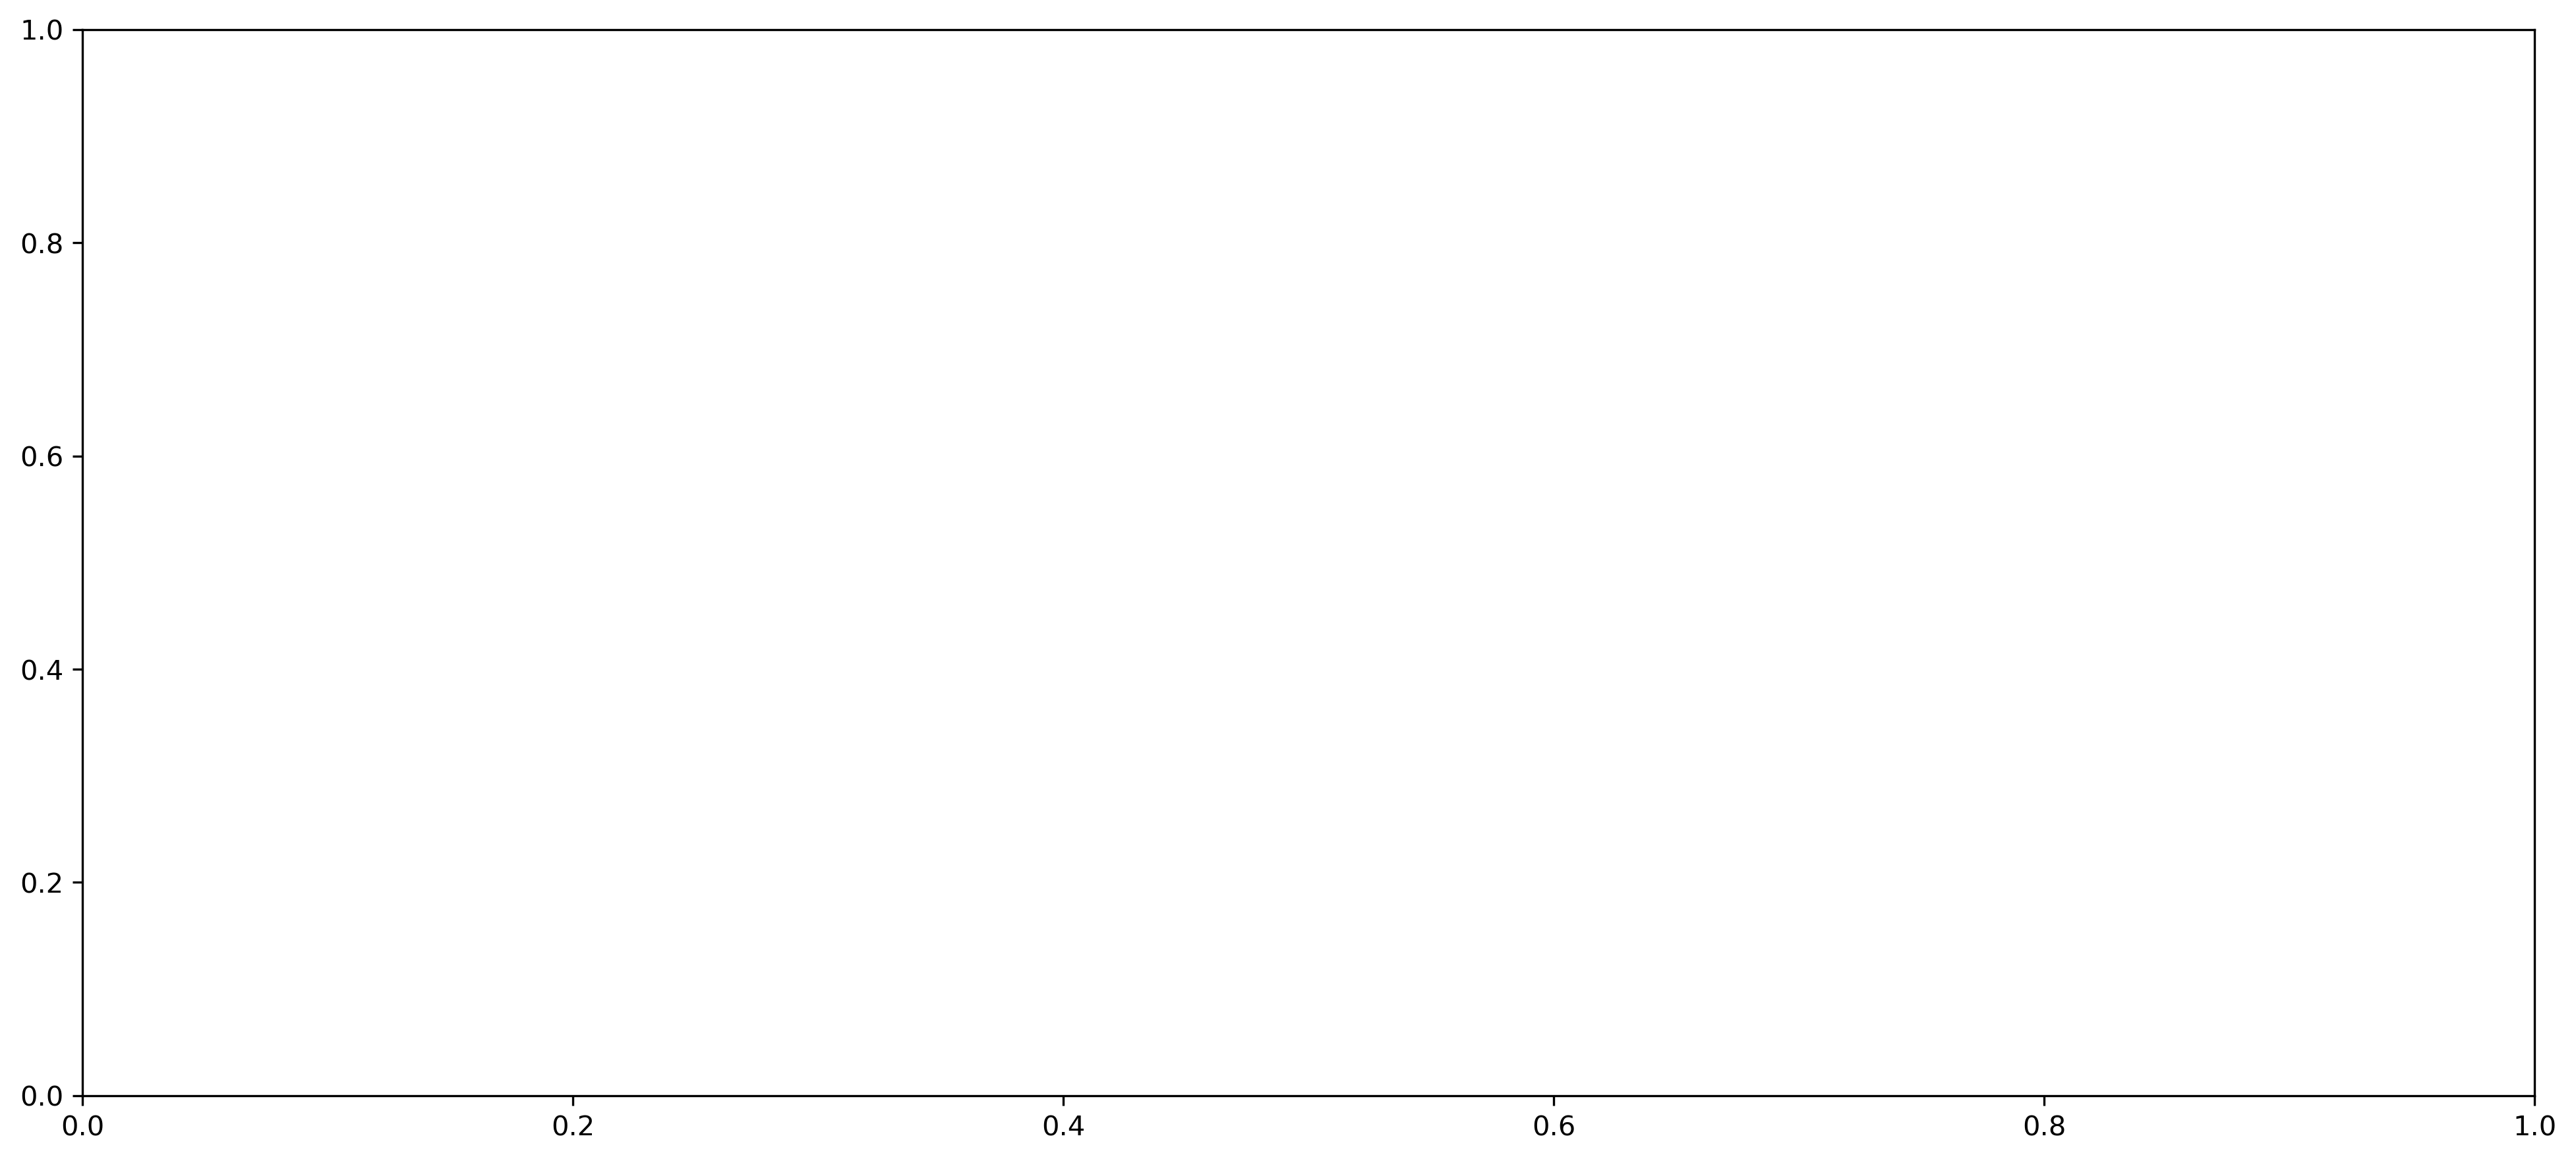

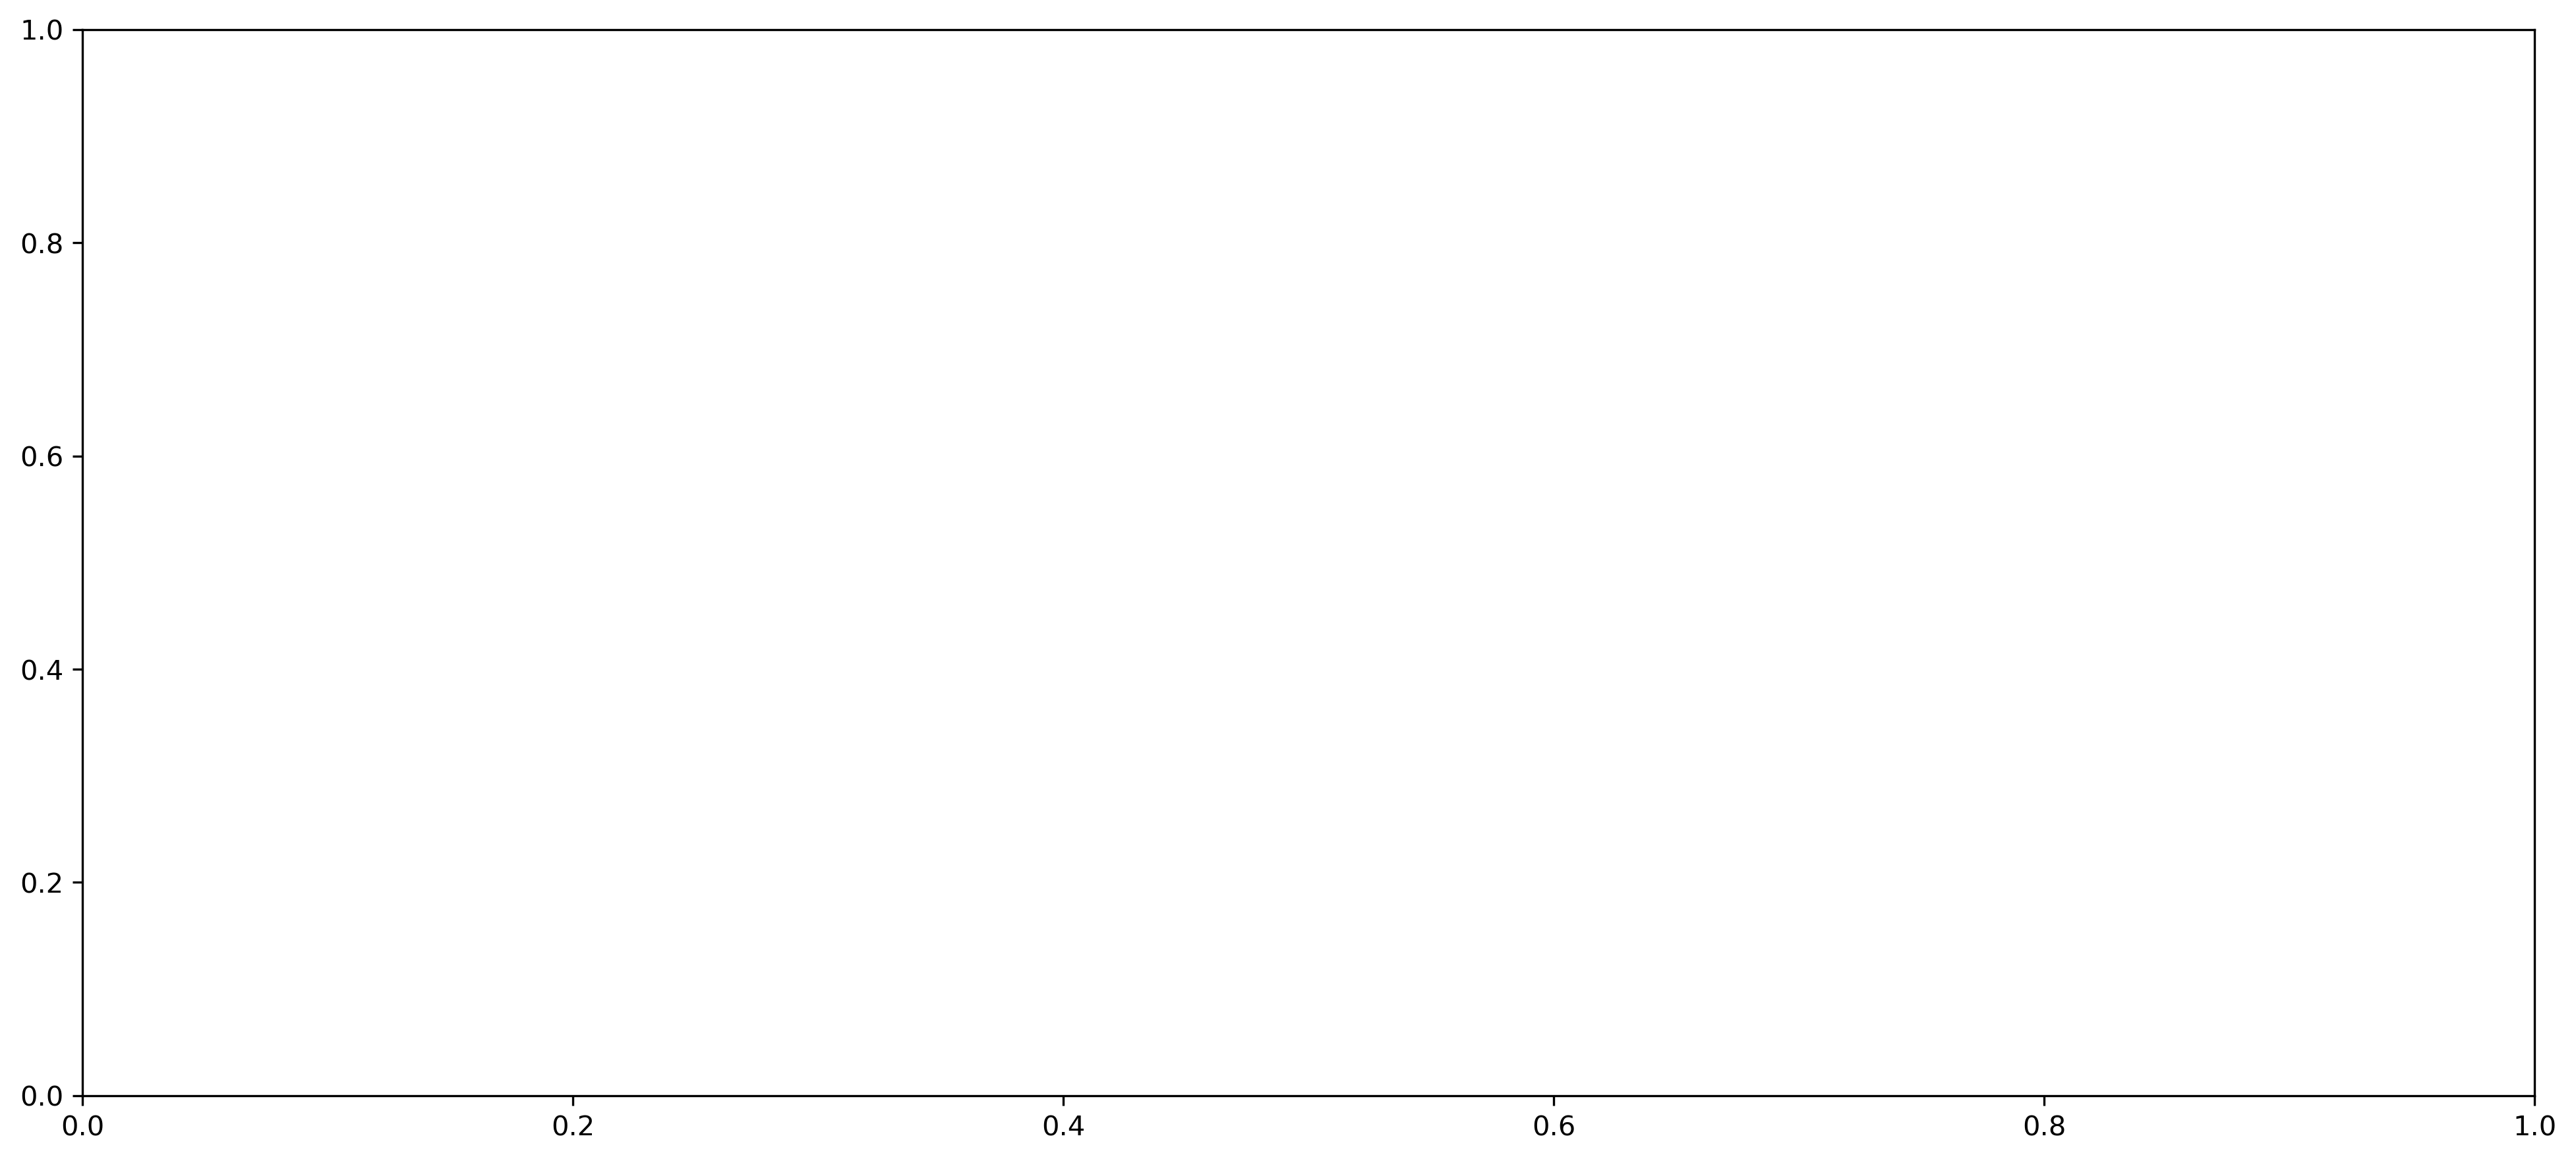

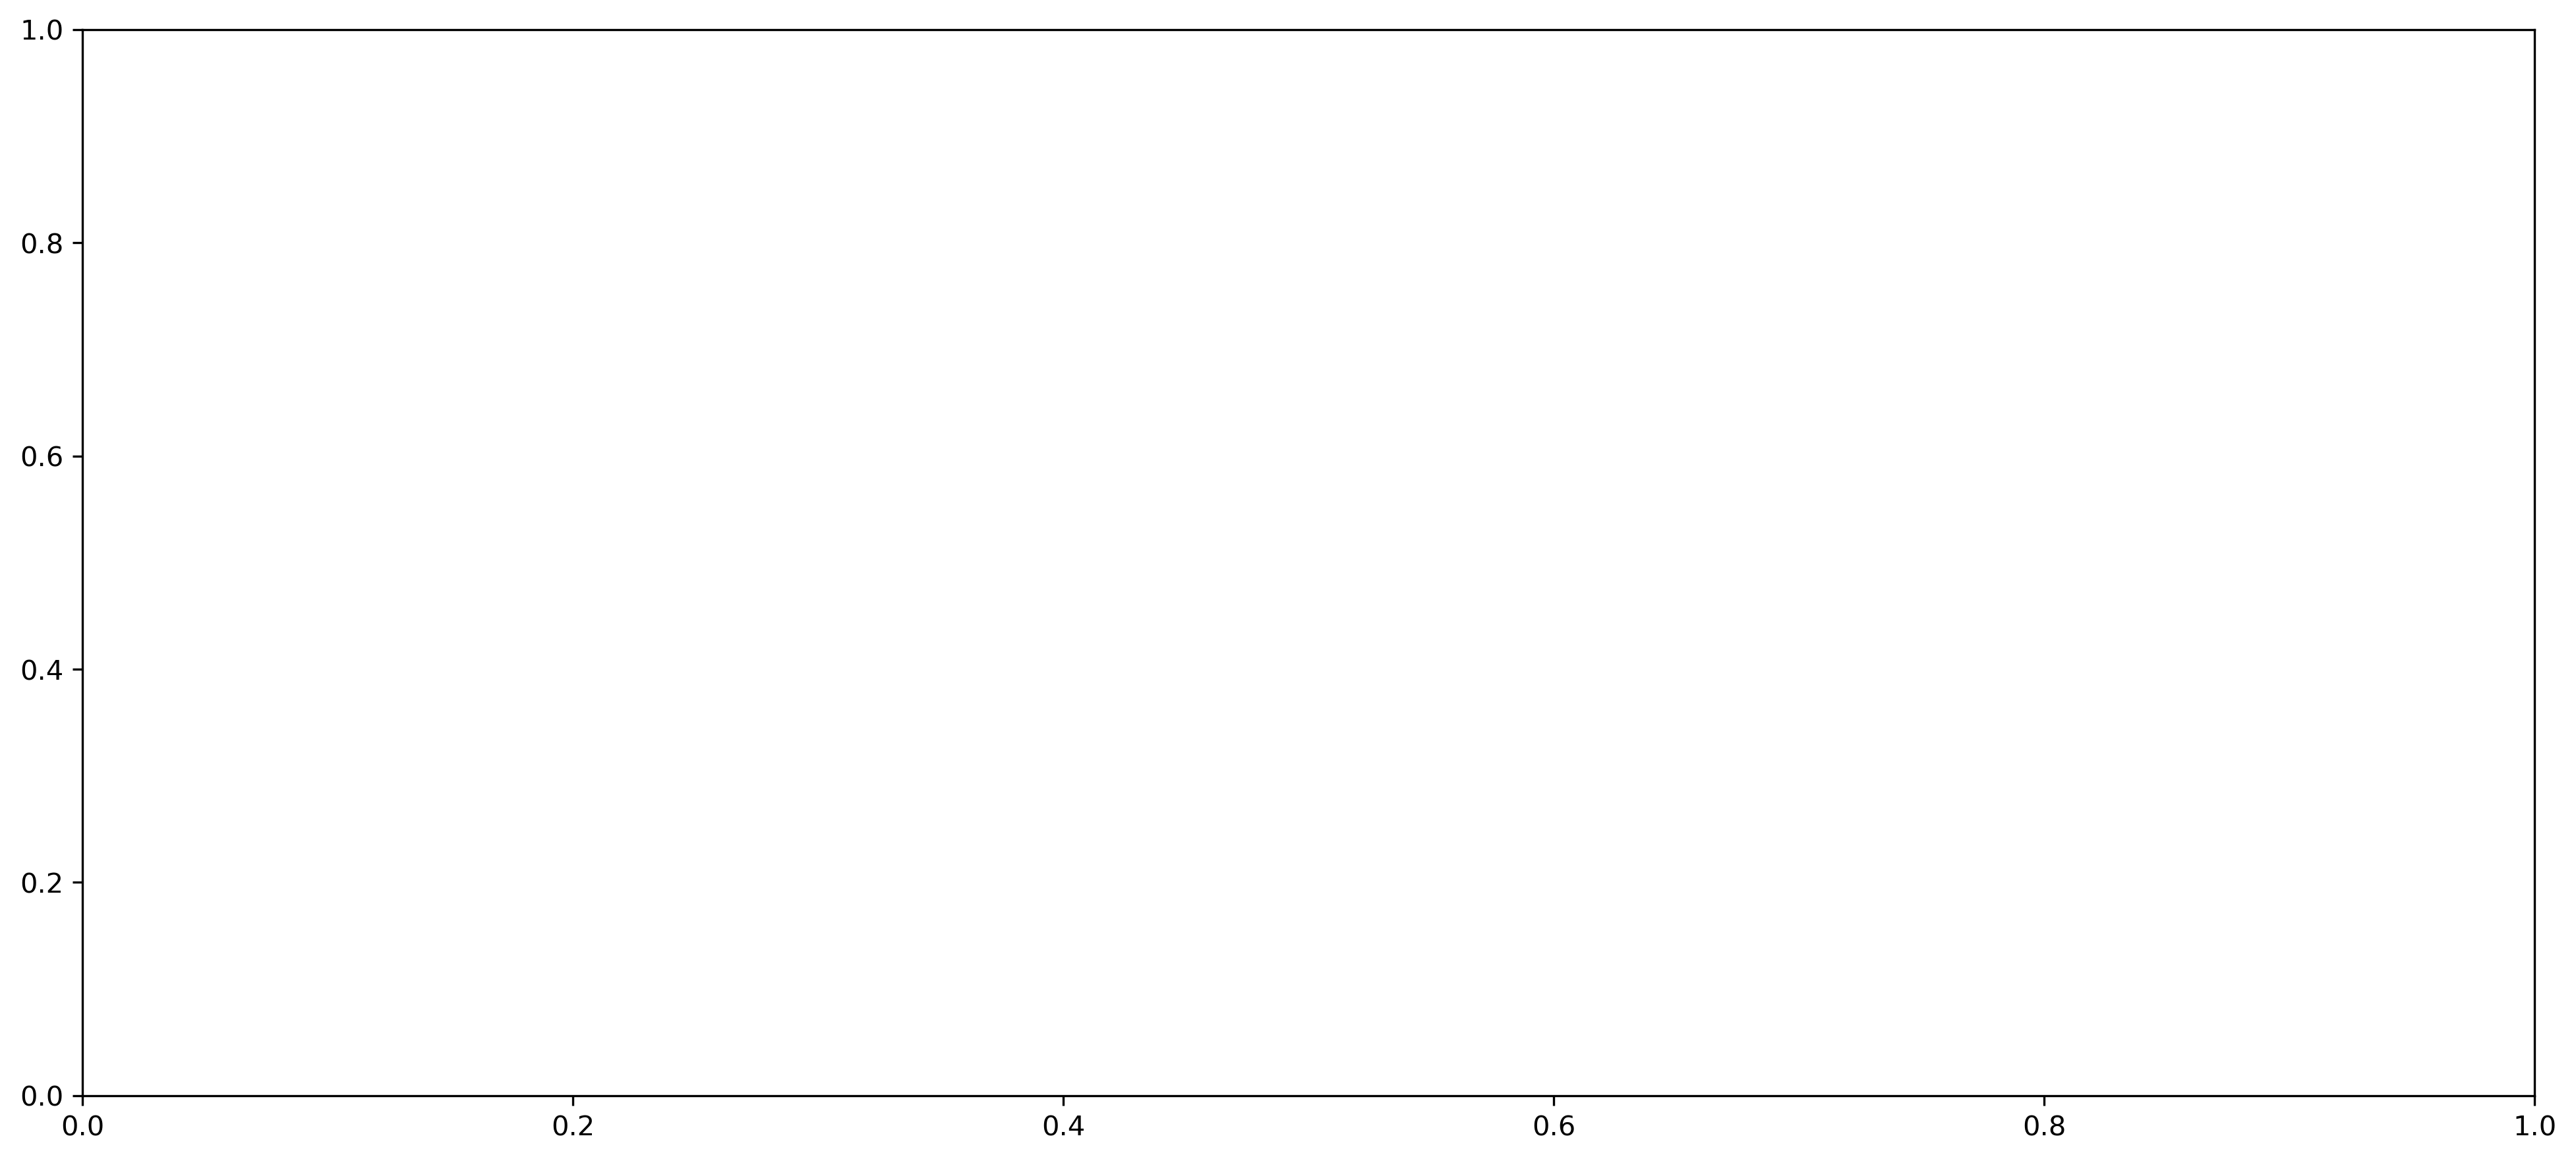

In [68]:
## PLOT ROC-AUC CURVE OF TEST SET
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_auc_score

figtitle_size=20
subtitle_size=18
x_tick_size=18
y_tick_size=13
y_label_size=17
legend_fontsize=11.5
axis_lw=1.6

period_end_days_for_plot=period_end_days[:]

llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-7b"]
fine_tuned_tags=['base','fine_tuned']
#model_names=['XGBoost','GradientBoost','LogisticRegression','RandomForest','SVC','KNN']
training_data_types=['full','pca']

llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-70b","epfl-llm/meditron-7b",
                 "google/long-t5-local-base",'google/long-t5-tglobal-large',
                'text-embedding-3-small']

suptitle_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox'}

plot_split_by_studies=True



for data_param_key in [*parameters_for_analysis][:1]:

    ## LOAD FINAL PATIENT IDS FOR ANALYSIS, SAVED DURING PREPROCESSING OF THE BASELINE MODELS IN NOTEBOOK S9_3
    fn=f'../data/{data_param_key}_final_pat_ids_for_analysis.pickle'
    with open(fn, 'rb') as handle:
        final_pat_ids_for_analysis=pickle.load(handle)
    

    #print(data_param_key)
    fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_all_data_concat.csv.gz'
    X_=pd.read_csv(fn,index_col=0,low_memory=False)
    
    print(data_param_key)
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        
    for llm_model_name in llm_model_names[:1]:
        
        for fine_tuned_tag in fine_tuned_tags[:1]:
            
            
            if 'text-embedding' in llm_model_name:
                llm_model_name_with_tag=llm_model_name
            else:
                llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
            
            

            for data_inclusion_type in data_inclusion_types[:]:

                for training_data_type in training_data_types[:1]:
                
                    cv_res_df_list,cv_res_df_per_study_list=[],[]
                    fig,ax=plt.subplots(1,1,figsize=(16,7))
    
                    for autoencoder_merged in autoenc_merged_bool_list[:1]:
                    
                        for period_end_day in period_end_days[:]:
                            print(f'Training on {period_end_day} days of data')
                            period_num=period_end_days.index(period_end_day)
    
                            ## Load embeddings created by LLM model
                            print(f'Loading embeddings of {data_param_key} data / {llm_model_name_with_tag} /{period_end_day} /{data_inclusion_type} model')
        
                            ## Load embeddings created by LLM model
                            #print(f'Loading embeddings of {llm_model_name_with_tag} model')
                            try:
                                #df=embed_dict[data_param_key][llm_model_name_with_tag][period_end_day][data_inclusion_type]
                                df=embed_dict[parameters_for_analysis[data_param_key]['fn']][llm_model_name_with_tag][period_end_day][data_inclusion_type][autoencoder_merged]
                            except KeyError:
                                warnings.warn(f'Embeddings of {data_param_key} data / {llm_model_name_with_tag} model/ {period_end_day} days/ {data_inclusion_type}/ autoenc {autoencoder_merged}not found! Check if they have been created. Skipping to next item.')
                                continue
    

                            #print(data_param_key)
                            fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_all_data_concat.csv.gz'
                            X=pd.read_csv(fn,index_col=0,low_memory=False)
                        
                            ## If not RELAPSE shpuld be predicted, subset the patients according to the availbility of the outcome results
                            if parameters_for_analysis[data_param_key]['result_cat']!='RELAPSE':
                            
                                ## Extract patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
                                last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
                                pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
                                #pat_ids=X['USUBJID'].unique().tolist()
                                
                                ## Subset outcome dataframe to patient considered
                                target_df=outcome_df.loc[:,outcome_label]
                                y=target_df.replace(label2id)
    
                                y=y.reset_index()
                                y['STUDYID']=y['USUBJID'].str.split('/',expand=True)[0].values
                                y=y.set_index(['USUBJID','STUDYID'])
                                #y=y.rename(columns={'index':'USUBJID'})
                                
                            if parameters_for_analysis[data_param_key]['result_cat']=='RELAPSE':
                                outcome_label='RELAPSE'
                                pats_with_relapse_df=extract_21_22_relapse_pats()
                                pat_ids=pats_with_relapse_df.index.tolist()
                                target_df=pats_with_relapse_df[[outcome_label]]
                                y=pats_with_relapse_df[[outcome_label]]
    
                                y=y.reset_index()
                                y['STUDYID']=y['USUBJID'].str.split('/',expand=True)[0].values
                                y=y.set_index(['USUBJID','STUDYID'])

                                                 
                        
                            ## Drop patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
                            #last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
                            #pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
    
                            ## Subset initial therapy last day dataframe to all patient considered in analysis
                            #init_ther_df=last_initial_therapy_day_df.loc[pat_ids,:]
                            last_init_ther_days = extract_last_init_therapy_day_from_drug_regimen(pat_ids)
    
                            ## SUBSET TO PATIENTS WHO WERE TAKING DRUGS DURING THE PERIOD
                            #pat_ids_ = subset_pats_with_therapy_in_period(period_num,period_end_days)
                            #pat_ids_= final_pat_ids_for_analysis[period_end_day]['X_train_ids'] + final_pat_ids_for_analysis[period_end_day]['X_test_ids']
                            
                            #df=df.loc[list(set(df.index) & set(pat_ids_)),:]
                            #df=df.loc[(pat_ids_),:]
                            #y=y.loc[y.index.get_level_values('USUBJID').isin(pat_ids_)] 
                            #y=y.loc[pat_ids_] 
            
            
                            ## Standardise data + calculate PCA 
                            #scaled_data,df_pca=return_std_data_and_pca(df,train_params['pca_comp'])
                            #df_pca=(scaled_data.loc[:,sign_diff_cols['Column'][:20]])
                            #df_pca = return_pca(df,train_params['pca_comp'])
                            X_dict={'full':df}#,'pca':df_pca}

                            X=X_dict[training_data_type].copy()

                            ## ADD ARM INFORMATION TO y
                            pat_arm_df=X_.drop_duplicates(subset=['USUBJID'])[['USUBJID','ARM']].set_index('USUBJID')#.to_dict(orient='records')
                            y['ARM']=np.nan                        

                            ## Make sure to extract correct ARM names from pat_arm_df
                            idx_ = y.index.get_level_values('USUBJID').isin(X.index)                            
                            idx__=y.index.get_level_values('USUBJID')[y.index.get_level_values('USUBJID').isin(X.index)]
                            y.loc[idx_,'ARM'] = pat_arm_df.loc[idx__,'ARM'].values
                            y=y.reset_index().set_index(['STUDYID','USUBJID','ARM'])
    
                            scores,cv_num_list,model_name_list,scores_per_study_list,\
                                cv_num_per_study_list,model_name_per_study_list,study_list,split_coln_list=[],[],[],[],[],[],[],[]
        
                            for model_name in model_names[:]:
                                #print('model_name',model_name)
        
                                #fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_vars_training_results.pickle'
                                #fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_{data_inclusion_type}vars_training_results.pickle'
                                fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_{data_inclusion_type}_autoenc_{autoencoder_merged}_vars_training_results.pickle'                                
                                with open(fn, 'rb') as handle:
                                    training_results=pickle.load(handle)
        
                                cv_results=training_results['cv_results']

                                ## LOAD TRAIN-TEST DATA AND SCALE BY TRAINING DATA'S DISTRIBUTION
                                for cv_repeat_num in range(len([*cv_results])): 
                                
                                    #X_train=X.loc[cv_results[f'cv_rep_{cv_repeat_num}']['X_train_indices'],:]
                                    #X_test=X.loc[cv_results[f'cv_rep_{cv_repeat_num}']['X_test_indices'],:]
                                    #y_test=y.loc[cv_results[f'cv_rep_{cv_repeat_num}']['y_test_indices']]

                                    X_train_ids=final_pat_ids_for_analysis[period_end_day][cv_repeat_num]['X_train_ids']
                                    X_test_ids=final_pat_ids_for_analysis[period_end_day][cv_repeat_num]['X_test_ids']

                                    X_train_ids_=list(set(X.index)&set(X_train_ids))
                                    X_test_ids_=list(set(X.index)&set(X_test_ids))
                                    
                                    X_train=X.loc[X_train_ids_,:]
                                    X_test=X.loc[X_test_ids_,:]

                                    y_train = y.loc[y.index.get_level_values('USUBJID').isin(X_train_ids_),:]
                                    y_test = y.loc[y.index.get_level_values('USUBJID').isin(X_test_ids_),:]
                                     

                                    #if data_inclusion_type!='all_days' or model_name=='LogisticRegression':
                                    _, X_test = scale_by_training_data(X_train, X_test)
                                    
                                    ## Align X_test and y_test based on patient IDs
                                    X_test = X_test.loc[y_test.index.get_level_values('USUBJID'),:]

                                    
                                    #print(X_test.shape)
                                    ## Calculate label weights mapped to the test labels for RocCurveDisplay
                                    if training_results['train_params']['weight_by_label_freq']==True:
        
                                        label_weights_dict=cv_results[f'cv_rep_{cv_repeat_num}']['label_weights_dict'] 
                                        label_weights=y_test[outcome_label].map(label_weights_dict).values
        
                                    if training_results['train_params']['weight_by_label_freq']==False:
                                        label_weights=None    

                                    ## EXtract the output probabilities for each top n models and average them to get a final prediction probability
                                    if isinstance(cv_results[f'cv_rep_{cv_repeat_num}']['model'],dict):
                                        
                                        test_probs=[]
                                        for n in range(len(cv_results[f'cv_rep_{cv_repeat_num}']['model'].keys())):
                                            #print(n,'model',model_name)                                        
                                            model=cv_results[f'cv_rep_{cv_repeat_num}']['model'][n]
                                            test_probabilities = model.predict_proba(X_test)[:, 1]
                                            test_probs.append(test_probabilities)
                                            
                                        test_probabilities =np.mean(np.array(test_probs),axis=0)
                                    
                                    # Predict probabilities on the training and test data
                                    if not isinstance(cv_results[f'cv_rep_{cv_repeat_num}']['model'],dict):
                                    
                                        model=cv_results[f'cv_rep_{cv_repeat_num}']['model']
                                        test_probabilities = model.predict_proba(X_test)[:, 1]


                                    test_roc_auc=roc_auc_score(y_test, test_probabilities,sample_weight=label_weights)
    
                                    #cv_roc_auc_scores=cv_results[f'cv_rep_{cv_repeat_num}']['cv_roc_auc_scores']['test_score']
                                    scores.append(test_roc_auc)
                                    cv_num_list.append(cv_repeat_num+1)
                                    model_name_list.append(model_name)
    
                                    ## IF THERE ARE MULTIPLE STUDIES IN THE DATA, CALCULATE THE ROC-AUC SCORES WITHIN THE STUDIES AS WELL
                                    for split_coln in ['STUDYID','ARM']:
                                        study_ids=y_test.index.get_level_values(split_coln).unique()                                        
                                        
                                        if len(study_ids)>1:
                                            
                                            for study_id in study_ids:                                           
                                        
                                                X_test_study_idx=y_test.index.get_level_values('USUBJID')[y_test.index.get_level_values(split_coln)==study_id].tolist()
                                                X_test_study=X_test.loc[X_test_study_idx,:]
                                                #_, X_test_study = scale_by_training_data(X_train, X_test_study)
                                                y_test_study=y_test[y_test.index.get_level_values(split_coln)==study_id]
        
                                                # Predict probabilities on the training and test data
                                                try:
                                                    test_probabilities = model.predict_proba(X_test_study)[:, 1]
                                                    label_weights=y_test_study[outcome_label].map(label_weights_dict).values
                                                    test_roc_auc=roc_auc_score(y_test_study, test_probabilities,sample_weight=label_weights)
                                                except ValueError:
                                                    print(f'No pats in cv-repeat_num {cv_repeat_num} - {split_coln} - {study_id}')
                                                    continue
                    
                                                scores_per_study_list.append(test_roc_auc)
                                                cv_num_per_study_list.append(cv_repeat_num+1)
                                                model_name_per_study_list.append(model_name)
                                                study_list.append(study_id)    
                                                split_coln_list.append(split_coln)
                                                         
                                
                            cv_res_df=pd.DataFrame.from_dict({'model_name':model_name_list,'Num_of_CV_repeat':cv_num_list,'ROC_AUC_score':scores})
                            cv_res_df['inclusion_period']=period_end_day
                            cv_res_df_list.append(cv_res_df)
    
                            if len(study_ids)>1:
                                cv_res_per_study_df=pd.DataFrame.from_dict({'model_name':model_name_per_study_list,
                                                  'Num_of_CV_repeat':cv_num_per_study_list,
                                                  'ROC_AUC_score':scores_per_study_list,
                                                   'split_coln_level':study_list,
                                                   'split_coln':split_coln_list})
                                
                                cv_res_per_study_df['inclusion_period']=period_end_day
                                cv_res_df_per_study_list.append(cv_res_per_study_df)
                                
                                
                    cv_res_acros_time_df=pd.concat(cv_res_df_list,axis=0)
                    cv_res_acros_time_df = cv_res_acros_time_df.reset_index().drop(columns='index')


                    ## SAVE TEST DATFRAME FOR LATER COMPARISON
                    fn=f'../data/test_roc_auc_values/LLM/{data_param_key}_{llm_model_name_with_tag}_{training_data_type}_{X.shape[1]}_{data_inclusion_type}_autoenc_{autoencoder_merged}_test_ROC_AUC_across_time_all_studies.csv'                                                    
                    cv_res_acros_time_df.to_csv(fn)
                    
                                                  
                    ## IF THERE ARE AUC-ROC VALUES PER STUDY AVAILABLE, PLOT HEM IN A SEPERATE BOXPLOT
                    if len(scores_per_study_list)>0 and plot_split_by_studies==True:
            
                        cv_res_per_study_df=pd.concat(cv_res_df_per_study_list,axis=0)

                        ## SAVE TEST DATFRAME FOR LATER COMPARISON
                        fn=f'../data/test_roc_auc_values/LLM/{data_param_key}_{llm_model_name_with_tag}_{training_data_type}_{X.shape[1]}_{data_inclusion_type}_autoenc_{autoencoder_merged}_test_ROC_AUC_across_time_per_study.csv'                                                    
                        cv_res_per_study_df.to_csv(fn)
                                        
                        

In [ ]:
X_test.sort_index()
#np.sort(X_test_ids_)

In [ ]:
cv_res_per_study_df
type(cv_results[f'cv_rep_{cv_repeat_num}']['model'])

In [ ]:
cv_results[f'cv_rep_{cv_repeat_num}']['model'].keys()

### Concatenate all setups' ROC-AUC values into one dataframe

### Functions

In [69]:
def replace_substring_in_list(replacements,list):
   
    replaced_list= [h if not isinstance(h, str)  else
                        reduce(lambda s, kv: s.replace(*kv), replacements.items(), h)
                        for h in list]
    return replaced_list
    

#### Across studies

In [70]:
## PLOT ROC-AUC CURVE OF TEST SET
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_auc_score
from scipy.stats import ttest_rel
from functools import reduce
from matplotlib.font_manager import FontProperties

figtitle_size=20
subtitle_size=18
x_tick_size=18
y_tick_size=13
y_label_size=17
legend_fontsize=11.5
axis_lw=1.6



period_end_days_for_plot=period_end_days[:]

llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-7b"]
fine_tuned_tags=['base','fine_tuned']
#model_names=['XGBoost','GradientBoost','LogisticRegression','RandomForest','SVC','KNN']
training_data_types=['full','pca']
data_inclusion_types=['baseline_last_day','baseline_vars','all_days'][:]

llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-70b","epfl-llm/meditron-7b",
                 "google/long-t5-local-base",'google/long-t5-tglobal-large',
                'text-embedding-3-small']

suptitle_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox'}

plot_split_by_studies=True

baseline_training_data_types=['all_days_in_period','last_therapy_day']
llm_data_inclusion_types=['baseline_last_day','baseline_vars','all_days'][:]


## COMAPARISON_1: baseline model setups, that will be compared to all setups in comparison_2
comparison_1=['baseline_last_therapy_day', 'baseline_all_days_in_period'][:1]
comparison_2=['baseline_last_therapy_day', 'LLM_embed_baseline_last_day','LLM_embed_baseline_vars','LLM_embed_all_days'][:]

## Order of the different setups within an inclusion period
hue_order=['baseline_last_therapy_day', 'LLM_embed_baseline_last_day','LLM_embed_baseline_vars','LLM_embed_all_days'][:]


## SELECT THE FINAL SETUPS FOR COMPARISON, PER EACH MODEL/INCLUSION PERIOD/INPUT VARIABLE
period_end_days=['baseline',31,62,93,125,160,'all']

final_setup_dict={'XGBoost':{'incl_periods':[str(day) for day in period_end_days],
                             'trained_on':['raw_vars']},
                  
                 'LogisticRegression':{'incl_periods':[str(day) for day in period_end_days],
                                      'trained_on':['raw_vars','embeddings']}}

## TO MAKE A COMPARISON ACROSS MODELS POSSIBLE, ADD THE MODEL NAME IN FRONT OF THE HUE AND COMPARISON SETUP NAMES
hue_order=[f'{mod_name} - {hue}' for mod_name in model_names for hue in hue_order]

## Use underscore in the comparisons, as the model name will be split from the setup name before the t-test calculation, 
#. and used for subsetting the dataframe holding the t-test p-values for all comparisons performed. 
#. See in the function "calc_paired_t_test_between_exp_setups()", also there underscore is used, as a '-' character is already being used at other part of the setup strings.
#. After the t-test, the '_' will be replaced by ' - ' where needed, to match with the hue_order setup names.
comparison_1=[f'{mod_name}_{comp}' for mod_name in model_names for comp in comparison_1]
comparison_2=[f'{mod_name}_{comp}' for mod_name in model_names for comp in comparison_2]



for data_param_key in [*parameters_for_analysis][:10]:


    pred_models_result=[]
    #hue_order=[]

    ## LOAD BASLINE MODEL
    for bl_training_data_type in baseline_training_data_types[:]:
        
        fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{bl_training_data_type}_test_ROC_AUC_across_time_all_studies.csv'
        #fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{bl_training_data_type}_test_ROC_AUC_across_time_per_study..csv'
        baseline_cv_res_acros_time_df=pd.read_csv(fn,index_col=0)
        baseline_cv_res_acros_time_df['trained_on']='raw_vars'
        baseline_cv_res_acros_time_df['setup']=f'baseline_{bl_training_data_type}'
        pred_models_result.append(baseline_cv_res_acros_time_df)
        #hue_order.append(f'baseline_{bl_training_data_type}')

        for llm_model_name in llm_model_names[:1]:
    
            for fine_tuned_tag in fine_tuned_tags[:1]:
                
                
                if 'text-embedding' in llm_model_name:
                    llm_model_name_with_tag=llm_model_name
                else:
                    llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
                
    
                for data_inclusion_type in llm_data_inclusion_types[:]:
    
                    for training_data_type in training_data_types[:1]:

                        for autoencoder_merged in autoenc_merged_bool_list[:1]:

                            
                            fn=f'../data/test_roc_auc_values/LLM/{data_param_key}_{llm_model_name_with_tag}_{training_data_type}_4096_{data_inclusion_type}_autoenc_{autoencoder_merged}_test_ROC_AUC_across_time_all_studies.csv'                                                    
                            #fn=f'../data/test_roc_auc_values/LLM/{data_param_key}_{llm_model_name_with_tag}_{training_data_type}_4096_{data_inclusion_type}_autoenc_{autoencoder_merged}_test_ROC_AUC_across_time_per_study.csv'                                                    
                            try:
                                llm_cv_res_acros_time_df=pd.read_csv(fn,index_col=0)
                                llm_cv_res_acros_time_df['trained_on']='embeddings'
                                llm_cv_res_acros_time_df['setup']=f'LLM_embed_{data_inclusion_type}'
                                pred_models_result.append(llm_cv_res_acros_time_df)
                            except FileNotFoundError:
                                print(f'{fn} model does not exist')
                                continue
                            
    #hue_order=comparison_1
    plot_df = pd.concat(pred_models_result,axis=0)


    # Refine names of the setups
    replacements = {
        '_embed_baseline_vars': ' Baseline vars - all visits in period',
        '_embed_baseline_last_day': ' Baseline vars - last visit in period',
        'baseline_last_therapy_day': 'Baseline vars - last visit in period',
        'baseline_all_days_in_period': 'Baseline vars - last visits concatenated',
        '_embed_all_days':' All vars - all visits in period'}
    
    #sns.barplot(data=plot_df,x='inclusion_period',y='ROC_AUC_score',hue='setup')
    plot_df['setup']=plot_df['setup'].replace(replacements,regex=True)
    #plot_df['setup_']=plot_df['model_name'] +' - '+ plot_df['setup']

    
    ## FILTER SETUPS BASED ON THE final_setup_dict, WHICH DETERMINES WHICH SETUPS ARE USED FOR FINAL COMPARISON
    '''
    l=[]

    for model_name in [*final_setup_dict]:
        
        incl_periods_=final_setup_dict[model_name]['incl_periods']
        trained_on=final_setup_dict[model_name]['trained_on']
        
        plot_df_filt = plot_df.loc[(plot_df['model_name']==model_name)\
                                    &(plot_df['trained_on'].isin(trained_on))\
                                    &(plot_df['inclusion_period'].isin(incl_periods_))]
        #print(plot_df_filt)
        l.append(plot_df_filt)
    
    plot_df = pd.concat(l,axis=0)
    '''
    
    # Update hur_order list with refined setup names
    hue_order=replace_substring_in_list(replacements,hue_order)
    comparison_1=replace_substring_in_list(replacements,comparison_1)
    comparison_2=replace_substring_in_list(replacements,comparison_2)

    ## Save dataframe
    data_dir_=f'../data/test_roc_auc_values/baseline_LLM_concat'
    os.makedirs(data_dir_,exist_ok=True)
    
    fn=os.path.join(data_dir_,
                    f'{data_param_key}_test_ROC_AUC_across_time_all_studies.csv')                                                   
    plot_df.to_csv(fn)
    

../data/test_roc_auc_values/LLM/tb21_22_2984_pats_22_vars_result_at_end_of_treatment_mb_only_BioMistral-7B_base_full_4096_baseline_last_day_autoenc_False_test_ROC_AUC_across_time_all_studies.csv model does not exist
../data/test_roc_auc_values/LLM/tb21_22_2984_pats_22_vars_result_at_end_of_treatment_mb_only_BioMistral-7B_base_full_4096_baseline_vars_autoenc_False_test_ROC_AUC_across_time_all_studies.csv model does not exist
../data/test_roc_auc_values/LLM/tb21_22_2984_pats_22_vars_result_at_end_of_treatment_mb_only_BioMistral-7B_base_full_4096_all_days_autoenc_False_test_ROC_AUC_across_time_all_studies.csv model does not exist
../data/test_roc_auc_values/LLM/tb21_22_2984_pats_22_vars_result_at_end_of_treatment_mb_only_BioMistral-7B_base_full_4096_baseline_last_day_autoenc_False_test_ROC_AUC_across_time_all_studies.csv model does not exist
../data/test_roc_auc_values/LLM/tb21_22_2984_pats_22_vars_result_at_end_of_treatment_mb_only_BioMistral-7B_base_full_4096_baseline_vars_autoenc_False

#### Per study

In [ ]:
## PLOT ROC-AUC CURVE OF TEST SET
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_auc_score
from scipy.stats import ttest_rel
from functools import reduce
from matplotlib.font_manager import FontProperties

figtitle_size=20
subtitle_size=18
x_tick_size=18
y_tick_size=13
y_label_size=17
legend_fontsize=11.5
axis_lw=1.6



period_end_days_for_plot=period_end_days[:]

llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-7b"]
fine_tuned_tags=['base','fine_tuned']
#model_names=['XGBoost','GradientBoost','LogisticRegression','RandomForest','SVC','KNN']
training_data_types=['full','pca']
data_inclusion_types=['baseline_last_day','baseline_vars','all_days'][:]

llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-70b","epfl-llm/meditron-7b",
                 "google/long-t5-local-base",'google/long-t5-tglobal-large',
                'text-embedding-3-small']

suptitle_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox'}

plot_split_by_studies=True

baseline_training_data_types=['all_days_in_period','last_therapy_day']
llm_data_inclusion_types=['baseline_last_day','baseline_vars','all_days'][:]


## COMAPARISON_1: baseline model setups, that will be compared to all setups in comparison_2
comparison_1=['baseline_last_therapy_day', 'baseline_all_days_in_period'][:1]
comparison_2=['baseline_last_therapy_day', 'LLM_embed_baseline_last_day','LLM_embed_baseline_vars','LLM_embed_all_days'][:]

## Order of the different setups within an inclusion period
hue_order=['baseline_last_therapy_day', 'LLM_embed_baseline_last_day','LLM_embed_baseline_vars','LLM_embed_all_days'][:]


## SELECT THE FINAL SETUPS FOR COMPARISON, PER EACH MODEL/INCLUSION PERIOD/INPUT VARIABLE
period_end_days=['baseline',31,62,93,125,160,'all']

final_setup_dict={'XGBoost':{'incl_periods':[str(day) for day in period_end_days],
                             'trained_on':['raw_vars']},
                  
                 'LogisticRegression':{'incl_periods':[str(day) for day in period_end_days],
                                      'trained_on':['raw_vars','embeddings']}}

## TO MAKE A COMPARISON ACROSS MODELS POSSIBLE, ADD THE MODEL NAME IN FRONT OF THE HUE AND COMPARISON SETUP NAMES
hue_order=[f'{mod_name} - {hue}' for mod_name in model_names for hue in hue_order]

## Use underscore in the comparisons, as the model name will be split from the setup name before the t-test calculation, 
#. and used for subsetting the dataframe holding the t-test p-values for all comparisons performed. 
#. See in the function "calc_paired_t_test_between_exp_setups()", also there underscore is used, as a '-' character is already being used at other part of the setup strings.
#. After the t-test, the '_' will be replaced by ' - ' where needed, to match with the hue_order setup names.
comparison_1=[f'{mod_name}_{comp}' for mod_name in model_names for comp in comparison_1]
comparison_2=[f'{mod_name}_{comp}' for mod_name in model_names for comp in comparison_2]



for data_param_key in [*parameters_for_analysis][:10]:


    pred_models_result=[]
    #hue_order=[]

    ## LOAD BASLINE MODEL
    for bl_training_data_type in baseline_training_data_types[:]:
        
        fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{bl_training_data_type}_test_ROC_AUC_across_time_all_studies.csv'
        fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{bl_training_data_type}_test_ROC_AUC_across_time_per_study..csv'
        baseline_cv_res_acros_time_df=pd.read_csv(fn,index_col=0)
        baseline_cv_res_acros_time_df['trained_on']='raw_vars'
        baseline_cv_res_acros_time_df['setup']=f'baseline_{bl_training_data_type}'
        pred_models_result.append(baseline_cv_res_acros_time_df)
        #hue_order.append(f'baseline_{bl_training_data_type}')

        for llm_model_name in llm_model_names[:1]:
    
            for fine_tuned_tag in fine_tuned_tags[:1]:
                
                
                if 'text-embedding' in llm_model_name:
                    llm_model_name_with_tag=llm_model_name
                else:
                    llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
                
    
                for data_inclusion_type in llm_data_inclusion_types[:]:
    
                    for training_data_type in training_data_types[:1]:

                        for autoencoder_merged in autoenc_merged_bool_list[:1]:

                            #fn=f'../data/test_roc_auc_values/LLM/{data_param_key}_{llm_model_name_with_tag}_{training_data_type}_4096_{data_inclusion_type}_autoenc_{autoencoder_merged}_test_ROC_AUC_across_time_all_studies.csv'                                                    
                            fn=f'../data/test_roc_auc_values/LLM/{data_param_key}_{llm_model_name_with_tag}_{training_data_type}_4096_{data_inclusion_type}_autoenc_{autoencoder_merged}_test_ROC_AUC_across_time_per_study.csv'                                                    
                            try:
                                llm_cv_res_acros_time_df=pd.read_csv(fn,index_col=0)
                                llm_cv_res_acros_time_df['trained_on']='embeddings'
                                llm_cv_res_acros_time_df['setup']=f'LLM_embed_{data_inclusion_type}'
                                pred_models_result.append(llm_cv_res_acros_time_df)
                            except FileNotFoundError:
                                print(f'{fn} model does not exist')
                                continue
                            
    #hue_order=comparison_1
    plot_df = pd.concat(pred_models_result,axis=0)


    # Refine names of the setups
    replacements = {
        '_embed_baseline_vars': ' Baseline vars - all visits in period',
        '_embed_baseline_last_day': ' Baseline vars - last visit in period',
        'baseline_last_therapy_day': 'Baseline vars - last visit in period',
        'baseline_all_days_in_period': 'Baseline vars - last visits concatenated',
        '_embed_all_days':' All vars - all visits in period'}
    
    #sns.barplot(data=plot_df,x='inclusion_period',y='ROC_AUC_score',hue='setup')
    plot_df['setup']=plot_df['setup'].replace(replacements,regex=True)
    #plot_df['setup_']=plot_df['model_name'] +' - '+ plot_df['setup']

    
    ## FILTER SETUPS BASED ON THE final_setup_dict, WHICH DETERMINES WHICH SETUPS ARE USED FOR FINAL COMPARISON
    '''
    l=[]

    for model_name in [*final_setup_dict]:
        
        incl_periods_=final_setup_dict[model_name]['incl_periods']
        trained_on=final_setup_dict[model_name]['trained_on']
        
        plot_df_filt = plot_df.loc[(plot_df['model_name']==model_name)\
                                    &(plot_df['trained_on'].isin(trained_on))\
                                    &(plot_df['inclusion_period'].isin(incl_periods_))]
        #print(plot_df_filt)
        l.append(plot_df_filt)
    
    plot_df = pd.concat(l,axis=0)
    '''
    
    # Update hur_order list with refined setup names
    hue_order=replace_substring_in_list(replacements,hue_order)
    comparison_1=replace_substring_in_list(replacements,comparison_1)
    comparison_2=replace_substring_in_list(replacements,comparison_2)

    ## Save dataframe
    data_dir_=f'../data/test_roc_auc_values/baseline_LLM_concat'
    os.makedirs(data_dir_,exist_ok=True)
    
    fn=os.path.join(data_dir_,
                    f'{data_param_key}_test_ROC_AUC_across_time_per_study.csv')                                                   
    plot_df.to_csv(fn)
    

In [ ]:
plot_df

### Plot test set ROC-AUC values across time

#### Across studies

In [ ]:
from sklearn.metrics import roc_auc_score

figtitle_size=18
subtitle_size=18
x_tick_size=18
y_tick_size=13
y_label_size=17
legend_fontsize=11.5
axis_lw=1.6

suptitle_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
               'tb21_22_2984_pats_22_vars_relapse':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox',
              'TB-1021':'REMox',
              'TB-1022':'OFLOTUB'}

suptitle_training_type_dict={'all_days':'all variables - all visits in period - embeddings',
                             'baseline_vars':'baseline variables - all visits in period - embeddings',
                             'baseline_last_day':'baseline variables - visit at end of period - embeddings'}

data_inclusion_types=['baseline_last_day','baseline_vars','all_days'][:]
plot_split_by_studies=True


model_names=['XGBoost','LogisticRegression','GradientBoost','RandomForest'][:2]
period_end_days_for_plot=period_end_days[:]

### loop over ML models, train them & training results in a dictionary
idx_list=[0,2]
#for idx in idx_list:
#    data_param_key=[*parameters_for_analysis][idx]
    
for data_param_key in [*parameters_for_analysis][:2]:

    data_dir_=f'../data/test_roc_auc_values/baseline_LLM_concat'
    fn=os.path.join(data_dir_,
                    #f'{data_param_key}_test_ROC_AUC_across_time_per_study.csv') 
                    f'{data_param_key}_test_ROC_AUC_across_time_all_studies.csv')   
    roc_auc_concat_df=pd.read_csv(fn,index_col=0,low_memory=False)



    for setup in roc_auc_concat_df['setup'].unique():
        #print(setup)

        fig,ax=plt.subplots(1,1,figsize=(12,5.5))
        
        plot_df=roc_auc_concat_df[roc_auc_concat_df['setup']==setup]
                        
        sns.boxplot(data=plot_df,x='inclusion_period',hue='model_name',
                    y='ROC_AUC_score',ax=ax,boxprops={'fill': None},legend=False)
        sns.stripplot(data=plot_df, x='inclusion_period',hue='model_name', 
                      y='ROC_AUC_score', ax=ax, #color='black',
                      size=6, jitter=0.1, alpha=1, dodge=True,legend=False)
        sns.pointplot(data=plot_df,x='inclusion_period',hue='model_name',
                      y='ROC_AUC_score',ax=ax,
                      errorbar='sd',alpha=0.5,dodge=True)
    
        
        ax.set_ylabel('ROC-AUC value',fontsize=y_label_size,fontweight='bold')
        ax.set_xlabel('Period used for training',fontsize=y_label_size,fontweight='bold')
        
        ## Convert days to months for xticklabels
        xticklabels=[ '6 month' if day == 'all' 
                        else 'Baseline' if day == 'baseline' 
                        else f'{int(np.floor(int(day)/30))} month' if isinstance(day, int) 
                        else None 
                        for day in period_end_days_for_plot]
    
        ax.set_xticklabels(xticklabels, fontsize=x_tick_size) #weight='bold'
        #ax.set_title(f"{'_'.join([llm_model_name,fine_tuned_tag])} - Test set ROC-AUC")
        ax.set_ylim(0.3,1) 
    
        # Adjust legend: changing font size and handle size
        h, l = ax.get_legend_handles_labels()
        legend = ax.legend(h, l, title='Models', loc='best',title_fontsize=12,handlelength=2)
        
        ax.legend(h,l,frameon=True,framealpha=0.5,
                            prop={'weight':'bold','size':legend_fontsize})
    
    
    
        ## PLot chance predicor's line at 0.5
        ax.axhline(y=0.5,color='black', linestyle='dashed')
        range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
        ax.text(range_mean,0.45,'Chance level predictor (AUC=0.5)',fontsize=y_label_size,fontweight='bold',
                            rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')
    
        # increase tick width
        ax.tick_params(width=axis_lw)
        ax.tick_params(axis='y',labelsize=y_tick_size)
    
        
    
        if data_param_key in suptitle_dict.keys():
                study_names=suptitle_dict[data_param_key]
                if 'relapse' not in data_param_key:
                    prediction_time=data_param_key.split('at_')[-1].replace('_',' ')
                    prediction_time = f'outcome at {prediction_time}'
                if 'relapse' in data_param_key:
                    prediction_time='relapse'
                #train_ds_type=suptitle_training_type_dict[data_inclusion_type]
                train_ds_type=setup.replace('LLM','LLM embeddings - ')
                suptitle= f"{study_names} study \n Training: {train_ds_type}\nPrediction: {prediction_time}"
                
        else:   
            suptitle=f"ROC-AUC of CV - {data_param_key} - {data_inclusion_type}" 
    
        fig.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=1.05)  
        ax.yaxis.grid(True) 
    
    
        ## SAVE PLOTS
        data_dir_=f'../data/plots/ROC_AUC_plots_across_time/baseline_LLM_concat/'
        os.makedirs(data_dir_,exist_ok=True)
    
        exp_setup = train_ds_type.replace(' ','_').replace('-','__')
        fn=os.path.join(data_dir_,
                    f'{data_param_key}_{exp_setup}_test_ROC_AUC_across_time_across_studies.png')
        fig.savefig(fn, bbox_inches='tight', dpi=300)
    
        

#### Per study

In [ ]:
from sklearn.metrics import roc_auc_score

figtitle_size=18
subtitle_size=16
x_tick_size=18
y_tick_size=13
y_label_size=17
legend_fontsize=11.5
axis_lw=1.6

suptitle_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
               'tb21_22_2984_pats_22_vars_relapse':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox',
              'TB-1021':'REMox',
              'TB-1022':'OFLOTUB'}

suptitle_training_type_dict={'all_days':'all variables - all visits in period - embeddings',
                             'baseline_vars':'baseline variables - all visits in period - embeddings',
                             'baseline_last_day':'baseline variables - visit at end of period - embeddings'}

data_inclusion_types=['baseline_last_day','baseline_vars','all_days'][:]

model_names=['XGBoost','LogisticRegression','GradientBoost','RandomForest'][:2]
period_end_days_for_plot=period_end_days[:]
    
for data_param_key in [*parameters_for_analysis][:6]:

    data_dir_=f'../data/test_roc_auc_values/baseline_LLM_concat'
    fn=os.path.join(data_dir_,
                    f'{data_param_key}_test_ROC_AUC_across_time_per_study.csv') 
                    #f'{data_param_key}_test_ROC_AUC_across_time_all_studies.csv')   
    roc_auc_concat_df=pd.read_csv(fn,index_col=0,low_memory=False)



    for setup in roc_auc_concat_df['setup'].unique():

        for study in roc_auc_concat_df['STUDYID'].unique():
            

            fig,ax=plt.subplots(1,1,figsize=(12,5.5))
            
            plot_df=roc_auc_concat_df[(roc_auc_concat_df['setup']==setup)\
                                     &(roc_auc_concat_df['STUDYID']==study)]
                            
            sns.boxplot(data=plot_df,x='inclusion_period',hue='model_name',
                        y='ROC_AUC_score',ax=ax,boxprops={'fill': None},legend=False)
            sns.stripplot(data=plot_df, x='inclusion_period',hue='model_name', 
                          y='ROC_AUC_score', ax=ax, #color='black',
                          size=6, jitter=0.1, alpha=1, dodge=True,legend=False)
            sns.pointplot(data=plot_df,x='inclusion_period',hue='model_name',
                          y='ROC_AUC_score',ax=ax,
                          errorbar='sd',alpha=0.5,dodge=True)
        
            
            ax.set_ylabel('ROC-AUC value',fontsize=y_label_size,fontweight='bold')
            ax.set_xlabel('Period used for training',fontsize=y_label_size,fontweight='bold')
            
            ## Convert days to months for xticklabels
            xticklabels=[ '6 month' if day == 'all' 
                            else 'Baseline' if day == 'baseline' 
                            else f'{int(np.floor(int(day)/30))} month' if isinstance(day, int) 
                            else None 
                            for day in period_end_days_for_plot]
        
            ax.set_xticklabels(xticklabels, fontsize=x_tick_size) #weight='bold'
            ax.set_ylim(0.3,1) 
        
            # Adjust legend: changing font size and handle size
            h, l = ax.get_legend_handles_labels()
            legend = ax.legend(h, l, title='Models', loc='best',title_fontsize=12,handlelength=2)
            
            ax.legend(h,l,frameon=True,framealpha=0.5,
                                prop={'weight':'bold','size':legend_fontsize})
        
        
        
            ## PLot chance predicor's line at 0.5
            ax.axhline(y=0.5,color='black', linestyle='dashed')
            range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
            ax.text(range_mean,0.45,'Chance level predictor (AUC=0.5)',fontsize=y_label_size,fontweight='bold',
                                rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')
        
            # increase tick width
            ax.tick_params(width=axis_lw)
            ax.tick_params(axis='y',labelsize=y_tick_size)
        
            
        
            if data_param_key in suptitle_dict.keys():
                    study_names=suptitle_dict[data_param_key]
                
                    if 'relapse' not in data_param_key:
                        prediction_time=data_param_key.split('at_')[-1].replace('_',' ')
                        prediction_time = f'outcome at {prediction_time}'
                    if 'relapse' in data_param_key:
                        prediction_time='relapse'
                    #train_ds_type=suptitle_training_type_dict[data_inclusion_type]
                    train_ds_type=setup.replace('LLM','LLM embeddings - ')
                    suptitle= f"{study_names} study \n Training: {train_ds_type}\nPrediction: {prediction_time}"
                    
            else:   
                suptitle=f"ROC-AUC of CV - {data_param_key} - {data_inclusion_type}" 
        
            fig.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=1.1)  
            
            ax.set_title(f"{suptitle_dict[study]}",fontsize=subtitle_size)
            ax.yaxis.grid(True) 
        
        
            ## SAVE PLOTS
            data_dir_=f'../data/plots/ROC_AUC_plots_across_time/baseline_LLM_concat/'
            os.makedirs(data_dir_,exist_ok=True)
        
            exp_setup = train_ds_type.replace(' ','_').replace('-','__')
            fn=os.path.join(data_dir_,
                        f'{data_param_key}_{exp_setup}_test_ROC_AUC_across_time_per_study_{study}.png')
            fig.savefig(fn, bbox_inches='tight', dpi=300)
    
        

### Plot test set TOC-AUC values across time

In [ ]:
train_ds_type.replace(' ','_').replace('-','__')

In [ ]:
from sklearn.metrics import roc_auc_score

figtitle_size=18
subtitle_size=18
x_tick_size=18
y_tick_size=13
y_label_size=17
legend_fontsize=11.5
axis_lw=1.6

suptitle_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
               'tb21_22_2984_pats_22_vars_relapse':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox',
              'TB-1021':'REMox',
              'TB-1022':'OFLOTUB'}

suptitle_training_type_dict={'all_days':'all variables - all visits in period - embeddings',
                             'baseline_vars':'baseline variables - all visits in period - embeddings',
                             'baseline_last_day':'baseline variables - visit at end of period - embeddings'}

data_inclusion_types=['baseline_last_day','baseline_vars','all_days'][:]
plot_split_by_studies=True


model_names=['XGBoost','LogisticRegression','GradientBoost','RandomForest'][:2]
period_end_days_for_plot=period_end_days[:]

### loop over ML models, train them & training results in a dictionary
idx_list=[0,2]
#for idx in idx_list:
#    data_param_key=[*parameters_for_analysis][idx]
    
for data_param_key in [*parameters_for_analysis][:2]:
    fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_all_data_concat.csv.gz'
    #X=pd.read_csv(fn,index_col=0,low_memory=False)

    for llm_model_name in llm_model_names[:1]:
        
        for fine_tuned_tag in fine_tuned_tags[:1]:
                       

            if 'text-embedding' in llm_model_name:
                llm_model_name_with_tag=llm_model_name
            else:
                llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
              
    
            for data_inclusion_type in data_inclusion_types[:]:
    
                for training_data_type in training_data_types[:1]:
                
                    cv_res_df_list,cv_res_df_per_study_list=[],[]
                    #fig,ax=plt.subplots(1,1,figsize=(16,7))
    
                    for autoencoder_merged in autoenc_merged_bool_list[:1]:
    
                        fig,ax=plt.subplots(1,1,figsize=(12,5.5))
                        
                        ## LOAD TEST DATFRAME 
                        #fn=f'../data/test_roc_auc_values/LLM/{data_param_key}_{llm_model_name_with_tag}_{training_data_type}_{X.shape[1]}_{data_inclusion_type}_autoenc_{autoencoder_merged}_test_ROC_AUC_across_time_all_studies.csv'                                                    
                        fn=f'../data/test_roc_auc_values/LLM/{data_param_key}_{llm_model_name_with_tag}_{training_data_type}_4096_{data_inclusion_type}_autoenc_{autoencoder_merged}_test_ROC_AUC_across_time_all_studies.csv'                                                    
                        
                        #print(fn)
                        cv_res_acros_time_df=pd.read_csv(fn,index_col=0)
                        
                        sns.boxplot(data=cv_res_acros_time_df,x='inclusion_period',hue='model_name',
                                    y='ROC_AUC_score',ax=ax,boxprops={'fill': None},legend=False)
                        sns.stripplot(data=cv_res_acros_time_df, x='inclusion_period',hue='model_name', 
                                      y='ROC_AUC_score', ax=ax, #color='black',
                                      size=6, jitter=0.1, alpha=1, dodge=True,legend=False)
                        sns.pointplot(data=cv_res_acros_time_df,x='inclusion_period',hue='model_name',
                                      y='ROC_AUC_score',ax=ax,
                                      errorbar='sd',alpha=0.5,dodge=True)
                    
                        
                        ax.set_ylabel('ROC-AUC value',fontsize=y_label_size,fontweight='bold')
                        ax.set_xlabel('Period used for training',fontsize=y_label_size,fontweight='bold')
                        
                        ## Convert days to months for xticklabels
                        xticklabels=[ '6 month' if day == 'all' 
                                        else 'Baseline' if day == 'baseline' 
                                        else f'{int(np.floor(int(day)/30))} month' if isinstance(day, int) 
                                        else None 
                                        for day in period_end_days_for_plot]
                    
                        ax.set_xticklabels(xticklabels, fontsize=x_tick_size) #weight='bold'
                        #ax.set_title(f"{'_'.join([llm_model_name,fine_tuned_tag])} - Test set ROC-AUC")
                        ax.set_ylim(0.3,1) 
                    
                        # Adjust legend: changing font size and handle size
                        h, l = ax.get_legend_handles_labels()
                        legend = ax.legend(h, l, title='Models', loc='best',title_fontsize=12,handlelength=2)
                        
                        ax.legend(h,l,frameon=True,framealpha=0.5,
                                            prop={'weight':'bold','size':legend_fontsize})
                    
                        
                        '''
                        # Set manual offsets depending on the number of models and the seaborn plot spacing
                        offsets = np.linspace(-0.30, 0.30, num=len(model_names))  # Adjust this based on the number of models
                    
                        for j, period in enumerate(period_end_days[:4]):
                            group_data = cv_res_acros_time_df[cv_res_acros_time_df['inclusion_period'] == period]
                            for i, model in enumerate(model_names_for_plot):
                                median_score = mean_scores.loc[(mean_scores['model_name'] == model) & (mean_scores['inclusion_period'] == period), 'ROC_AUC_score'].values[0]
                                max_score = group_data[group_data['model_name'] == model]['ROC_AUC_score'].max()
                                # Calculate position
                                position = j + offsets[i]  # shift each model within its group
                                ax.text(position, max_score + 0.005, f'Median:\n{median_score:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
                    
                        '''
                        
                    
                    
                        ## PLot chance predicor's line at 0.5
                        ax.axhline(y=0.5,color='black', linestyle='dashed')
                        range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
                        ax.text(range_mean,0.45,'Chance level predictor (AUC=0.5)',fontsize=y_label_size,fontweight='bold',
                                            rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')
                    
                        # increase tick width
                        ax.tick_params(width=axis_lw)
                        ax.tick_params(axis='y',labelsize=y_tick_size)
                    
                        
                    
                        if data_param_key in suptitle_dict.keys():
                                study_names=suptitle_dict[data_param_key]
                                if 'relapse' not in data_param_key:
                                    prediction_time=data_param_key.split('at_')[-1].replace('_',' ')
                                    prediction_time = f'outcome at {prediction_time}'
                                if 'relapse' in data_param_key:
                                    prediction_time='relapse'
                                train_ds_type=suptitle_training_type_dict[data_inclusion_type]
                                suptitle= f"{study_names} study \n Training: {train_ds_type}\nPrediction: {prediction_time}"
                                
                        else:   
                            suptitle=f"ROC-AUC of CV - {data_param_key} - {data_inclusion_type}" 
                    
                        fig.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=1.05)  
                        ax.yaxis.grid(True) 
                
                
                        ## SAVE PLOTS
                        data_dir_=f'../data/plots/ROC_AUC_plots_across_time/LLM_models/{data_param_key}'
                        os.makedirs(data_dir_,exist_ok=True)

                        exp_setup = train_ds_type.replace(' ','_').replace('-','__')
                        fn=os.path.join(data_dir_,
                                    f'{data_param_key}_{exp_setup}_{training_data_type}_test_ROC_AUC_across_time_across_studies.png')
                        fig.savefig(fn, bbox_inches='tight', dpi=300)
                
                        
                                  
                        ## IF THERE ARE AUC-ROC VALUES PER STUDY AVAILABLE, PLOT HEM IN A SEPERATE BOXPLOT
                        study_coln='STUDYID'
                        fn=f'../data/test_roc_auc_values/LLM/{data_param_key}_{llm_model_name_with_tag}_{training_data_type}_4096_{data_inclusion_type}_autoenc_{autoencoder_merged}_test_ROC_AUC_across_time_per_study.csv'                                                    
                        if os.path.isfile(fn)==True and plot_split_by_studies==True:
                    
        
                            cv_res_per_study_df=pd.read_csv(fn,index_col=0)
                               
                            ncols=len(cv_res_per_study_df[study_coln].unique())
                            nrows=1
                            fig2=plt.figure(figsize=(ncols*10,nrows*5))
                    
                            for n,studyid in enumerate(np.sort(cv_res_per_study_df[study_coln].unique())):
                                ax2=fig2.add_subplot(nrows,ncols,n+1)
                                plot_df=cv_res_per_study_df[cv_res_per_study_df[study_coln]==studyid]
                    
                                # Calculate mean ROC_AUC_score for each model_name
                                mean_scores=plot_df.groupby('model_name')['ROC_AUC_score'].median().reset_index()
                    
                                sns.boxplot(data=plot_df,x='inclusion_period',hue='model_name',
                                            y='ROC_AUC_score',ax=ax2,boxprops={'fill': None},legend=False)
                                sns.stripplot(data=plot_df, x='inclusion_period', hue='model_name', 
                                              y='ROC_AUC_score', ax=ax2, #color='black',
                                             size=6, jitter=0.1, alpha=1, dodge=True)
                                sns.pointplot(data=plot_df,x='inclusion_period',
                                              hue='model_name',
                                              y='ROC_AUC_score',ax=ax2,
                                              errorbar='sd',alpha=0.5,dodge=True,legend=False)
                                
                    
                                ax2.set_title(studyid,fontweight='bold')
                                ax2.set_ylabel('ROC-AUC value',fontsize=y_label_size,fontweight='bold')
                                ax2.set_xlabel(None)
                                ax2.set_xticklabels(xticklabels, fontsize=x_tick_size*0.8)
                                #ax.set_title(f"{'_'.join([llm_model_name,fine_tuned_tag])} - Test set ROC-AUC")
                                ax2.set_ylim(0.3,1) 
                    
                                # increase tick width
                                ax2.tick_params(width=axis_lw)
                                ax2.yaxis.grid(True)
                                
                                ## PLot chance predicor's line at 0.5
                                ax2.axhline(y=0.5,color='black', linestyle='dashed')
                                range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
                                ax2.text(range_mean,0.45,'Chance level predictor (AUC=0.5)',fontsize=y_label_size,fontweight='bold',
                                                    rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')
                    
                                ## Remove legend title
                    
                                # Adjust legend: changing font size and handle size
                                h, l = ax2.get_legend_handles_labels()
                                legend = ax2.legend(h, l, title='Models', loc='best',title_fontsize=12,handlelength=2)
                    
                                ax2.legend(h,l,frameon=True,framealpha=0.5,
                                                    prop={'weight':'bold','size':legend_fontsize})
                    
                                fig2.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=1.15) 
                
                                ## SAVE PLOTS
                                data_dir_=f'../data/plots/ROC_AUC_plots_across_time/LLM_models/{data_param_key}'
                                os.makedirs(data_dir_,exist_ok=True)
                                fn=os.path.join(data_dir_,
                                            f'{data_param_key}_{exp_setup}_{training_data_type}_test_ROC_AUC_across_time_per_study.png')
                                fig2.savefig(fn, bbox_inches='tight', dpi=300)


## Plot ROC-AUC curve of test set

In [ ]:
## PLOT ROC-AUC CURVE OF TEST SET
from sklearn.metrics import RocCurveDisplay

figtitle_size=20
subtitle_size=18
x_tick_size=31
y_tick_size=31
y_label_size=15
legend_fontsize=11.5
axis_lw=1.6



llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-7b"]
fine_tuned_tags=['base','fine_tuned']
#model_names=['XGBoost','GradientBoost','LogisticRegression','RandomForest','SVC','KNN']
training_data_types=['full','pca']


for data_param_key in [*parameters_for_analysis][:2]:
    
    print(data_param_key)
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        
    for llm_model_name in llm_model_names[:1]:
        
        for fine_tuned_tag in fine_tuned_tags[:1]:
            
            

            if 'text-embedding' in llm_model_name:
                llm_model_name_with_tag=llm_model_name
            else:
                llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
            
            
            for period_end_day in period_end_days[:1]:
                print(f'Training on {period_end_day} days of data')

                for data_inclusion_type in data_inclusion_types:

                    ## Load embeddings created by LLM model
                    print(f'Loading embeddings of {data_param_key} data / {llm_model_name_with_tag} /{period_end_day} /{data_inclusion_type} model')

                    ## Load embeddings created by LLM model
                    #print(f'Loading embeddings of {llm_model_name_with_tag} model')
                    try:
                        df=embed_dict[data_param_key][llm_model_name_with_tag][period_end_day][data_inclusion_type]
                    except KeyError:
                        warnings.warn(f'Embeddings of {data_param_key} data / {llm_model_name_with_tag} model/ {period_end_day} days/ {data_inclusion_type} not found! Check if they have been created. Skipping to next item.')
                        continue

            
                    ## Drop patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
                    #last_day_per_pat_df=data_conc.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
                    #pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
                    #df=df.loc[pat_ids,:]
    
                    ## Standardise data + calculate PCA 
                    #scaled_data,df_pca=return_std_data_and_pca(df,train_params['pca_comp'])
                    #df_pca=(scaled_data.loc[:,sign_diff_cols['Column'][:20]])
                    #df_pca = return_pca(df,train_params['pca_comp'])
                    X_dict={'full':df}#'pca':df_pca}
    
                    ## Subset outcome dataframe to patient considered
                    target_df=outcome_df.loc[df.index.tolist(),outcome_label]
    
                    for training_data_type in training_data_types[:1]:
    
                        ## Define X and y dataframes for training
                        X=X_dict[training_data_type].copy()
                        y=target_df.loc[X.index].replace(label2id)
                        
                        ## Add USUBJID TO INDEX
                        y=y.reset_index()
                        y['STUDYID']=y['index'].str.split('/',expand=True)[0].values
                        y=y.rename(columns={'index':'USUBJID'})
                        y=y.set_index(['USUBJID','STUDYID'])
    
                        ncols=train_params['num_cv_repeats']
                        fig,axes=plt.subplots(1,ncols,figsize=(ncols*8,12))
    
                        for model_name in model_names[:]:
    
                            #fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_vars_training_results.pickle'
                            fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_{data_inclusion_type}vars_training_results.pickle'
                            with open(fn, 'rb') as handle:
                                training_results=pickle.load(handle)
    
                            cv_results=training_results['cv_results']
    
                            for cv_repeat_num in range(len([*cv_results])): 
                                X_test=X.loc[cv_results[f'cv_rep_{cv_repeat_num}']['X_test_indices'],:]
                                y_test=y.loc[cv_results[f'cv_rep_{cv_repeat_num}']['y_test_indices']]
                                model=cv_results[f'cv_rep_{cv_repeat_num}']['model']
    
                                ## Calculate label weights mapped to the test labels for RocCurveDisplay
                                if training_results['train_params']['weight_by_label_freq']==True:
    
                                    label_weights_dict=cv_results[f'cv_rep_{cv_repeat_num}']['label_weights_dict'] 
                                    label_weights=y_test[outcome_label].map(label_weights_dict).values
    
                                if training_results['train_params']['weight_by_label_freq']==False:
                                    label_weights=None   
    
                                if len([*cv_results])==1:
                                    ax=axes
                                else:    
                                    ax=axes[cv_repeat_num]
    
    
                                rfc_disp=RocCurveDisplay.from_estimator(model, X_test.values, y_test.values, ax=ax, name=model_name,
                                                                                        sample_weight=label_weights,
                                                                                        alpha=0.8)  
    
                                ax.set_ylabel('True Positive Rate',fontsize=y_label_size,fontweight='bold')
                                ax.set_xlabel('False Positive Rate',fontsize=y_label_size,fontweight='bold')
    
                                ax.tick_params(axis='y', labelsize=y_label_size*0.8)
                                ax.tick_params(axis='x', labelsize=y_label_size*0.8)
    
                                ax.set_title(' - '.join(['CV-split',str(cv_repeat_num+1)]),fontsize=subtitle_size,fontweight='bold')
    
                                ## Plot diagonal chance level predictor curve + customize legend
                                ax.plot([0,1], [0,1],color='black', linestyle='dashed')
                                ax.text(0.5,0.55,'Chance level predictor (AUC=0.5)',fontsize=y_label_size*0.8,fontweight='bold',
                                        rotation=45,horizontalalignment='center', verticalalignment='center',rotation_mode='default')
    
                                h, l = ax.get_legend_handles_labels()
                                ax.legend(h,l,frameon=True,framealpha=0.5,
                                        prop={'weight':'bold','size':legend_fontsize})
    
                                ## Change linewidth of axes
                                for axis in ['top','bottom','left','right']:
                                    ax.spines[axis].set_linewidth(axis_lw)
    
                                # increase tick width
                                ax.tick_params(width=axis_lw)
    
                                #suptitle=f"ROC curve of test data\n {'_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])}\n{data_param_key} - {training_data_type} {X.shape[1]} vars" 
                                
                                suptitle=f"curve of test data - training on {period_end_day} days\n{'_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])}\n{data_param_key} - {training_data_type} {X.shape[1]} vars" 
    
                                fig.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=0.9)  
                                ax.grid(True)        
        

## Plot ROC-AUC curve of test set per study

In [ ]:
#y_test=y.loc[cv_results[f'cv_rep_{cv_repeat_num}']['y_test_indices']]
pd.MultiIndex.from_tuples((cv_results[f'cv_rep_{cv_repeat_num}']['y_test_indices'])).get_level_values(0)
y

In [ ]:
## PLOT ROC-AUC CURVE OF TEST SET
from sklearn.metrics import RocCurveDisplay

figtitle_size=20
subtitle_size=18
x_tick_size=31
y_tick_size=31
y_label_size=15
legend_fontsize=11.5
axis_lw=1.6



llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-7b"]
fine_tuned_tags=['base','fine_tuned']
#model_names=['XGBoost','GradientBoost','LogisticRegression','RandomForest','SVC','KNN']
training_data_types=['full','pca']


### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][:2]:
    
    fn='../data/'+data_param_key+'_all_data_concat.csv.gz'
    data_conc=pd.read_csv(fn,index_col=0,low_memory=False)
    
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        
    for llm_model_name in llm_model_names[:1]:
        
        for fine_tuned_tag in fine_tuned_tags[:1]:

            llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
            
            for period_end_day in period_end_days[:]:
            
                ## Load embeddings created by LLM model
                print(f'Loading embeddings of {llm_model_name_with_tag} model')
                try:
                    df=embed_dict[data_param_key][llm_model_name_with_tag][period_end_day]
                except KeyError:
                    warnings.warn(f'Embeddings of {llm_model_name_with_tag} model not found! Check if they have been created. Skipping to next item.')
                    continue

                ## Drop patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
                #last_day_per_pat_df=data_conc.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
                #pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
                #df=df.loc[pat_ids,:]

                ## Standardise data + calculate PCA 
                print(f"Calculating PCA with {train_params['pca_comp']} components + stanardising data")
                scaled_data,df_pca=return_std_data_and_pca(df,train_params['pca_comp'])
                X_dict={'full':scaled_data,'pca':df_pca}

                ## Subset outcome dataframe to patient considered
                target_df=outcome_df.loc[df.index.tolist(),outcome_label]

                for training_data_type in training_data_types[:1]:


                    ## Define X and y dataframes for training
                    X=X_dict[training_data_type].copy()
                    y=target_df.loc[X.index].replace(label2id)
                                   

                    ncols=train_params['num_cv_repeats']
                    nrows=len(data_conc['STUDYID'].unique())
                    fig,axes=plt.subplots(nrows,ncols,figsize=(ncols*7,nrows*7.5),constrained_layout=False)

                    for model_name in model_names[:]:

                        fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_vars_training_results.pickle'
                        with open(fn, 'rb') as handle:
                            training_results=pickle.load(handle)

                        cv_results=training_results['cv_results']


                        for cv_repeat_num in range(len([*cv_results])): 
                            X_test=X.loc[cv_results[f'cv_rep_{cv_repeat_num}']['X_test_indices'],:]
                            y_idx=pd.MultiIndex.from_tuples((cv_results[f'cv_rep_{cv_repeat_num}']['y_test_indices'])).get_level_values(0)
                            y_test=y.loc[y_idx]
                            model=cv_results[f'cv_rep_{cv_repeat_num}']['model']


                            for l,studyid in enumerate(data_conc['STUDYID'].unique()): 
                                
                                if studyid!='TB-1018':
                                    ## Calculate label weights mapped to the test labels for RocCurveDisplay
                                    if training_results['train_params']['weight_by_label_freq']==True:

                                        label_weights_dict=cv_results[f'cv_rep_{cv_repeat_num}']['label_weights_dict'] 
                                        label_weights=y_test.map(label_weights_dict).values

                                    if training_results['train_params']['weight_by_label_freq']==False:
                                        label_weights=None   

                                    if len([*cv_results])==1:
                                        ax=axes[l]
                                    else:    
                                        ax=axes[l,cv_repeat_num]

                                    df=target_df.reset_index()
                                    df['STUDYID']=df['USUBJID'].str.split('/',expand=True)[0].values
                                    df=df.set_index('USUBJID')

                                    pat_ids_study=df.loc[df.index.isin(X_test.index)&(df['STUDYID']==studyid)].index.tolist()

                                    X_study_mask=X_test.loc[pat_ids_study,:]
                                    y_study_mask=y_test.loc[pat_ids_study]


                                    rfc_disp=RocCurveDisplay.from_estimator(model, X_study_mask.values, y_study_mask.values, ax=ax, name=model_name,
                                                                                            sample_weight=label_weights,alpha=0.8)  

                                    ax.set_ylabel('True Positive Rate',fontsize=y_label_size,fontweight='bold')
                                    ax.set_xlabel('False Positive Rate',fontsize=y_label_size,fontweight='bold')

                                    ax.tick_params(axis='y', labelsize=y_label_size*0.8)
                                    ax.tick_params(axis='x', labelsize=y_label_size*0.8)

                                    ax.set_title(' - '.join(['CV-split',str(cv_repeat_num+1),studyid]),fontsize=subtitle_size,fontweight='bold')

                                    ## Plot diagonal chance level predictor curve + customize legend
                                    ax.plot([0,1], [0,1],color='black', linestyle='dashed')
                                    ax.text(0.5,0.55,'Chance level predictor (AUC=0.5)',fontsize=y_label_size*0.8,fontweight='bold',
                                            rotation=45,horizontalalignment='center', verticalalignment='center',rotation_mode='default')

                                    h, l = ax.get_legend_handles_labels()
                                    ax.legend(h,l,frameon=True,framealpha=0.5,
                                            prop={'weight':'bold','size':legend_fontsize})

                                    ## Change linewidth of axes
                                    for axis in ['top','bottom','left','right']:
                                        ax.spines[axis].set_linewidth(axis_lw)

                                    # increase tick width
                                    ax.tick_params(width=axis_lw)

                                    #suptitle=f"ROC curve of test data\n {'_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])}\n{data_param_key} - {training_data_type} {X.shape[1]} vars" 

                                    suptitle=f"curve of test data - training on {period_end_day} days\n{'_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])}\n{data_param_key} - {training_data_type} {X.shape[1]}"

                                    fig.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=0.96)  
                                    ax.grid(True) 
                                ## Print distribution of labels per study
                                df=y_test.reset_index()#
                                df['STUDYID']=df['index'].str.split('/',expand=True)[0].values
                                print(pd.crosstab(df['STUDYID'],df[outcome_label]))

# COMPARISON WITH BASELINE MODEL

## Per model

### Functions

In [ ]:

def calc_paired_t_test_between_exp_setups(plot_df):

    # Get unique values from the 'setup' column
    unique_setups = plot_df['setup'].unique()
    
    # Generate all pairwise combinations
    setup_combinations = list(itertools.combinations(unique_setups, 2))
    setup_combinations#[0]
    
    paired_t_res_dict={}
    
    ## Loop over models
    for model_incl_per, model_incl_per_df in plot_df.groupby(['model_name','inclusion_period']):
        
        ttest_res_df=pd.DataFrame(columns=plot_df['setup'].unique(),
                                  index=plot_df['setup'].unique())
    
        for setup_combination in setup_combinations:
            
            #if setup_combination[0].startswith('baseline'):
    
            model_incl_per_df_1 = model_incl_per_df[(model_incl_per_df['setup']==setup_combination[0])]
            model_incl_per_df_2 = model_incl_per_df[(model_incl_per_df['setup']==setup_combination[1])]
    
            t_stat,pval = ttest_rel(model_incl_per_df_1['ROC_AUC_score'],model_incl_per_df_2['ROC_AUC_score'])
    
            ttest_res_df.loc[setup_combination[0],setup_combination[1]]=pval
    
        ## Copy upper triangle to lower triangle to get a dataframe where it is easier to extract the exp. setup comparisons later
        X=ttest_res_df.fillna(0).values
        X = X + X.T - np.diag(np.diag(X))
        ttest_res_df=pd.DataFrame(data=X,
                                  columns=plot_df['setup'].unique(),
                                  index=plot_df['setup'].unique())
        ttest_res_df=ttest_res_df.replace(0,np.nan)

        ## Add to dict
        paired_t_res_dict[model_incl_per]=ttest_res_df

    return paired_t_res_dict

#####===========================
def extract_paired_t_test_FDR(ttest_res_df,comparison_1,comparison_2):
    from statsmodels.stats.multitest import multipletests

    pvalues_df = ttest_res_df.loc[comparison_1,comparison_2]#.dropna()
    
    # 1. Extract non-NaN p-values
    non_nan_pvalues = pvalues_df.stack().values
    #non_nan_pvalues = pvalues_df.values.flatten()
    
    # 2. FDR correction
    _, corrected_pvalues, _, _ = multipletests(non_nan_pvalues, alpha=0.05, method='fdr_bh')
    
    # 3. Replace corrected p-values back into a symmetric DataFrame
    corrected_pvalues_df = pvalues_df.copy()
    corrected_pvalues_df.loc[:, :] = np.nan  # Reset with NaNs
    
    # Use mask to update non-NaN positions with corrected p-values
    pval_flat=pvalues_df.values.flatten()
    pval_flat[~np.isnan(pval_flat)]=corrected_pvalues
    
    mask = ~pvalues_df.isna()
    corrected_pvalues_df[mask] = pval_flat.reshape(corrected_pvalues_df.shape)

    return corrected_pvalues_df

#####==========
def annotate_fdr(ax, comparison_pairs, fdr_values, y_offset=0.02):
    """
    Annotate FDR-corrected p-values above bars with brackets.

    Args:
        ax: Matplotlib axis.
        comparison_pairs: List of (x1, x2) pairs indicating bar comparisons.
        fdr_values: List of corresponding FDR values for the comparisons.
        y_offset: Vertical offset for annotations.
    """
    for i, ((x1, x2), fdr) in enumerate(zip(comparison_pairs, fdr_values)):
        if fdr < 0.05:  # Only annotate significant comparisons
            # Get the y position for the top of the bars
            y1 = ax.patches[x1].get_height()
            y2 = ax.patches[x2].get_height()
            y_max = max(y1, y2) + y_offset
            
            # Draw bracket
            ax.annotate('', xy=(x1, y_max), xytext=(x2, y_max),
                        arrowprops=dict(arrowstyle='-', lw=1.5))
            
            # Add FDR value above bracket
            ax.text((x1 + x2) / 2, y_max + y_offset, f"p={fdr:.3f}", 
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

#####=========
def add_fdr_vals_to_bars(ax,plot_df,paired_t_res_dict,comparison_1,comparison_2):
    
    ## Create dict containing the x,y positions of all bars
    bars_x_pos = [p.get_x() + p.get_width() / 2 for p in ax.patches]
    bars_y_pos = [p.get_height() for p in ax.patches]
    err_bars_y_pos=([max(line.get_xydata()[:,1]) for line in ax.lines])

    incl_periods=plot_df['inclusion_period'].unique()  
    mod_name = ax.get_title()
    
    d={}
    for n,incl_per in enumerate(incl_periods):
        bars_x_pos_per = np.array(bars_x_pos)[[n+l*len(incl_periods) for l in range(len(hue_order))]]
        bars_y_pos_per = np.array(bars_y_pos)[[n+l*len(incl_periods) for l in range(len(hue_order))]]
        
        err_bars_y_pos_per = np.array(err_bars_y_pos)[[n+l*len(incl_periods) for l in range(len(hue_order))]]
        
        d[incl_per]=dict(zip(hue_order,tuple(zip(bars_x_pos_per,bars_y_pos_per))))
        d[incl_per]=dict(zip(hue_order,tuple(zip(bars_x_pos_per,err_bars_y_pos_per))))

        ttest_res_df=paired_t_res_dict[(mod_name,incl_per)]
        corrected_pvalues_df = extract_paired_t_test_FDR(ttest_res_df,comparison_1,comparison_2)

    
        y_offset=0.03

        m=0
        for comp1 in comparison_1:
            for comp2 in comparison_2:
                if comp1!=comp2:
                    fdr=corrected_pvalues_df.loc[comp1,comp2]
                    x_pos=(d[incl_per][comp1][0] + d[incl_per][comp2][0])/2
                    
                    x_pos1=d[incl_per][comp1][0]
                    x_pos2=d[incl_per][comp2][0]
                    y_pos1=d[incl_per][comp1][1]
                    y_pos2=d[incl_per][comp2][1]

                    x_mean=(x_pos1+x_pos2)/2
                    y_mean=np.max(err_bars_y_pos_per)+0.00 +y_offset*m

                    bx = [x_pos1, x_pos1, x_pos2 ,x_pos2]
                    by = [y_mean+ 0.0, y_mean + 0.01, y_mean + 0.01,y_mean + 0.0]
                    ax.plot(bx, by, 'k-', lw=0.5)
                    
                    # Add FDR value above bracket
                    color='black' if fdr>0.05 else 'r'
                    ax.text(x_mean, y_mean+0.01, f"{fdr:.3f}", 
                            ha='center', va='bottom', fontsize=7, color=color,fontweight='bold')
                    m=m+1

def replace_substring_in_list(replacements,list):
   
    replaced_list= [h if not isinstance(h, str)  else
                        reduce(lambda s, kv: s.replace(*kv), replacements.items(), h)
                        for h in list]
    return replaced_list
    

### ROC-AUC comparisons

In [ ]:
## PLOT ROC-AUC CURVE OF TEST SET
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_auc_score
from scipy.stats import ttest_rel
from functools import reduce

figtitle_size=20
subtitle_size=18
x_tick_size=18
y_tick_size=13
y_label_size=17
legend_fontsize=11.5
axis_lw=1.6



period_end_days_for_plot=period_end_days[:]

llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-7b"]
fine_tuned_tags=['base','fine_tuned']
#model_names=['XGBoost','GradientBoost','LogisticRegression','RandomForest','SVC','KNN']
training_data_types=['full','pca']

llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-70b","epfl-llm/meditron-7b",
                 "google/long-t5-local-base",'google/long-t5-tglobal-large',
                'text-embedding-3-small']

suptitle_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox'}

plot_split_by_studies=True

baseline_training_data_types=['all_days_in_period','last_therapy_day']
llm_data_inclusion_types=['baseline_last_day','baseline_vars','all_days'][:]

comparison_1=['baseline_last_therapy_day', 'baseline_all_days_in_period'][:1]
#comparison_2=['baseline_last_therapy_day', 'baseline_all_days_in_period'][:]
comparison_2=['baseline_last_therapy_day', 'LLM_embed_baseline_last_day','LLM_embed_baseline_vars','LLM_embed_all_days'][1:]
hue_order=['baseline_last_therapy_day', 'LLM_embed_baseline_last_day','LLM_embed_baseline_vars','LLM_embed_all_days'][:]



plot_type='bar'
plot_type='point'

for data_param_key in [*parameters_for_analysis][:2]:

    for plot_type in ['bar','point'][:1]:

        pred_models_result=[]
        #hue_order=[]
    
        ## LOAD BASLINE MODEL
        for bl_training_data_type in baseline_training_data_types[1:]:
            
            fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{bl_training_data_type}_test_ROC_AUC_across_time_all_studies.csv'
            fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{bl_training_data_type}_test_ROC_AUC_across_time_per_study..csv'
            baseline_cv_res_acros_time_df=pd.read_csv(fn,index_col=0)
            baseline_cv_res_acros_time_df['setup']=f'baseline_{bl_training_data_type}'
            pred_models_result.append(baseline_cv_res_acros_time_df)
            #hue_order.append(f'baseline_{bl_training_data_type}')

            for llm_model_name in llm_model_names[:1]:
        
                for fine_tuned_tag in fine_tuned_tags[:1]:
                    
                    
                    if 'text-embedding' in llm_model_name:
                        llm_model_name_with_tag=llm_model_name
                    else:
                        llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
                    
        
                    for data_inclusion_type in llm_data_inclusion_types[:]:
        
                        for training_data_type in training_data_types[:1]:

                            for autoencoder_merged in autoenc_merged_bool_list[:1]:

                                fn=f'../data/test_roc_auc_values/LLM/{data_param_key}_{llm_model_name_with_tag}_{training_data_type}_4096_{data_inclusion_type}_autoenc_{autoencoder_merged}_test_ROC_AUC_across_time_all_studies.csv'                                                    
                                fn=f'../data/test_roc_auc_values/LLM/{data_param_key}_{llm_model_name_with_tag}_{training_data_type}_4096_{data_inclusion_type}_autoenc_{autoencoder_merged}_test_ROC_AUC_across_time_per_study.csv'                                                    
                                llm_cv_res_acros_time_df=pd.read_csv(fn,index_col=0)
                                llm_cv_res_acros_time_df['setup']=f'LLM_embed_{data_inclusion_type}'
                                pred_models_result.append(llm_cv_res_acros_time_df)
                                
        #hue_order=comparison_1
        plot_df = pd.concat(pred_models_result,axis=0)


        # Refine names of the setups
        replacements = {
            '_embed_baseline_vars': ' Baseline vars - all visits in period',
            '_embed_baseline_last_day': ' Baseline vars - last visit in period',
            'baseline_last_therapy_day': 'Baseline vars - last visit in period',
            'baseline_all_days_in_period': 'Baseline vars - last visits concatenated',
            '_embed_all_days':' All vars - all visits in period'}
        
        #sns.barplot(data=plot_df,x='inclusion_period',y='ROC_AUC_score',hue='setup')
        plot_df['setup']=plot_df['setup'].replace(replacements,regex=True)
     
        
        # Update hur_order list with refined setup names
        hue_order=replace_substring_in_list(replacements,hue_order)
        comparison_1=replace_substring_in_list(replacements,comparison_1)
        comparison_2=replace_substring_in_list(replacements,comparison_2)
        
        ## Change names of inlcusion periods to months
        period_dict=dict(zip([str(x) for x in period_end_days],
                             #[f'{int(np.floor(int(day)/30))} month' if day !='all' else '6 month' for day in period_end_days]
                            
                             ['6 month' if day == 'all' 
                                        else 'Baseline' if day == 'baseline' 
                                        else f'{int(np.floor(int(day)/30))} month' if isinstance(day, int) 
                                        else None 
                                        for day in period_end_days_for_plot]
                                             ))
        plot_df['inclusion_period']=plot_df['inclusion_period'].map(period_dict)

        ## Within each model type & inclusion period, calculate the paired t-test results across experimental setups. 
        #. The results coming from the same CV-splits are compared across exp. setups, these are paired for the t-test
        #. The dict. holds all the raw p-values of the t-tests across all exp. setups
        paired_t_res_dict = calc_paired_t_test_between_exp_setups(plot_df)
        #extract_paired_t_test_FDR(ttest_res_df,comparison_1,comparison_2)

        # Figure size customization
        #fig_width = 18
        fig_height = 4

        
        # Create a FacetGrid for splitting by 'model_name'
        g = sns.FacetGrid(plot_df, col='model_name', col_wrap=1, height=fig_height, aspect=1.6,sharex=False,sharey=False)
        #g = sns.FacetGrid(plot_df, height=fig_height, aspect=1.6,sharex=False,sharey=False)
        
        # Map barplot onto the FacetGrid
        if plot_type=='bar':
            g.map_dataframe(sns.barplot, x='inclusion_period',
                            y='ROC_AUC_score', 
                            hue='setup', 
                            errorbar='sd',
                            palette='Set2',
                            hue_order=hue_order,
                            alpha=0.6)

        
        if plot_type=='point':
            g.map_dataframe(sns.pointplot, x='inclusion_period',
                            y='ROC_AUC_score', 
                            hue='setup', 
                            errorbar='sd',
                            palette='Set2',
                            hue_order=hue_order,
                            alpha=0.6)
                                 
        
        # Add legends
        g.add_legend(title='Setup',loc='center left')
        # Adjust legend position
        g._legend.set_bbox_to_anchor((0.95, 0.5))  # Move the legend closer (adjust x and y)
        g._legend.set_frame_on(False)              # Optional: Add a box around the legend
        g._legend.set_title("Setup", prop={'size': 16, 'weight': 'bold'})  # Customize title

        # Customize legend labels font size
        for text in g._legend.texts:  # Loop through legend labels
            text.set_fontsize(14)     # Set label font size
        
        # Customize legend handle size
        for handle in g._legend.legendHandles:
            try:
                handle.set_markersize(12) 
            except AttributeError:
                handle.set(height=12)

        
        # Customize titles
        g.set_titles("{col_name}",size=12, weight='bold')

        # Set axis labels
        g.set_axis_labels("Inclusion Period", "ROC AUC Score",fontsize=12,fontweight='bold')

        # Customize tick sizes
        for ax in g.axes.flat:  # Loop through each subplot
            ax.tick_params(axis='x', labelsize=14)  # Customize x tick size
            ax.tick_params(axis='y', labelsize=14)  # Customize y tick size
            ax.set_ylim(0.4,1.05)

             ## PLot chance predicor's line at 0.5
            ax.axhline(y=0.5,color='black', linestyle='dashed')
            range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
            ax.text(range_mean,0.46,'Chance level predictor (AUC=0.5)',fontsize=14,fontweight='bold',
                                rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')

            #xticklabels=[f'{int(np.floor(int(day)/30))} month' if day !='all' else '6 month' for day in period_end_days]
            #ax.set_xticklabels(ax.get_xticklabels(), fontsize=12) #weight='bold'
            ax.grid(alpha=0.4)

            if plot_type=='bar':
                add_fdr_vals_to_bars(ax,plot_df,paired_t_res_dict,comparison_1,comparison_2)
            
            
        # Adjust layout for better appearance
        # Adjust the overall figure size
        #g.fig.set_size_inches(fig_width, fig_height)  # Set custom figure size
        g.fig.suptitle(f"Test set ROC-AUC comparison\n{parameters_for_analysis[data_param_key]['result_cat'].replace('_',' ').capitalize()}",
                       y=1,fontweight='bold',fontsize=15)\

        plt.tight_layout()
        
        plt.show()

                        

## Preselected setups

### Functions

In [ ]:
def calc_paired_t_test_between_exp_setups(plot_df):

    # Get unique values from the 'setup' column
    #unique_setups = plot_df['setup'].unique()
    unique_setups = [f"{mod_name}_{setup}"for mod_name in plot_df['model_name'].unique() for setup in plot_df['setup'].unique()]
    
    # Generate all pairwise combinations
    setup_combinations = list(itertools.combinations(unique_setups, 2))

    
    paired_t_res_dict={}
    
    ## Loop over models
    for model_incl_per, model_incl_per_df in plot_df.groupby(['inclusion_period']):
        
        ttest_res_df=pd.DataFrame(columns=unique_setups,
                                  index=unique_setups)
        
        #print(ttest_res_df.columns)
        
        for setup_combination in setup_combinations:
            
    
            model_incl_per_df_1 = model_incl_per_df[(model_incl_per_df['setup']==(setup_combination[0].split('_')[-1]))\
                                                &(model_incl_per_df['model_name']==(setup_combination[0].split('_')[0]))]
    
            model_incl_per_df_2 = model_incl_per_df[(model_incl_per_df['setup']==(setup_combination[1].split('_')[-1]))\
                                                    &(model_incl_per_df['model_name']==(setup_combination[1].split('_')[0]))]

            if model_incl_per_df_1.shape[0]==0 or model_incl_per_df_2.shape[0]==0:
                continue

            #print(model_incl_per_df_1.shape,model_incl_per_df_2.shape)
            t_stat,pval = ttest_rel(model_incl_per_df_1['ROC_AUC_score'],model_incl_per_df_2['ROC_AUC_score'])

    
            ttest_res_df.loc[setup_combination[0],setup_combination[1]]=pval
    
        ## Copy upper triangle to lower triangle to get a dataframe where it is easier to extract the exp. setup comparisons later
        X=ttest_res_df.fillna(0).values
        X = X + X.T - np.diag(np.diag(X))
        ttest_res_df=pd.DataFrame(data=X,
                                  columns=unique_setups,
                                  index=unique_setups)
        ttest_res_df=ttest_res_df.replace(0,np.nan)

        ## Add to dict
        paired_t_res_dict[model_incl_per[0]]=ttest_res_df

    return paired_t_res_dict


#####===========================
def extract_paired_t_test_FDR(ttest_res_df,comparison_1,comparison_2):
    from statsmodels.stats.multitest import multipletests

    pvalues_df = ttest_res_df.loc[comparison_1,comparison_2]#.dropna()

    if pvalues_df.shape[0]>0:

        # 1. Extract non-NaN p-values
        non_nan_pvalues = pvalues_df.stack().values
        #non_nan_pvalues = pvalues_df.values.flatten()
        
        # 2. FDR correction
        _, corrected_pvalues, _, _ = multipletests(non_nan_pvalues, alpha=0.05, method='fdr_bh')
        
        # 3. Replace corrected p-values back into a symmetric DataFrame
        corrected_pvalues_df = pvalues_df.copy()
        corrected_pvalues_df.loc[:, :] = np.nan  # Reset with NaNs
        
        # Use mask to update non-NaN positions with corrected p-values
        pval_flat=pvalues_df.values.flatten()
        pval_flat[~np.isnan(pval_flat)]=corrected_pvalues
        
        mask = ~pvalues_df.isna()
        corrected_pvalues_df[mask] = pval_flat.reshape(corrected_pvalues_df.shape)
    
        return corrected_pvalues_df
    
    else:
        return None

'''
#####==========
def annotate_fdr(ax, comparison_pairs, fdr_values, y_offset=0.02):
    """
    Annotate FDR-corrected p-values above bars with brackets.

    Args:
        ax: Matplotlib axis.
        comparison_pairs: List of (x1, x2) pairs indicating bar comparisons.
        fdr_values: List of corresponding FDR values for the comparisons.
        y_offset: Vertical offset for annotations.
    """
    for i, ((x1, x2), fdr) in enumerate(zip(comparison_pairs, fdr_values)):
        if fdr < 0.05:  # Only annotate significant comparisons
            # Get the y position for the top of the bars
            y1 = ax.patches[x1].get_height()
            y2 = ax.patches[x2].get_height()
            y_max = max(y1, y2) + y_offset
            
            # Draw bracket
            ax.annotate('', xy=(x1, y_max), xytext=(x2, y_max),
                        arrowprops=dict(arrowstyle='-', lw=1.5))
            
            # Add FDR value above bracket
            ax.text((x1 + x2) / 2, y_max + y_offset, f"p={fdr:.3f}", 
                    ha='center', va='bottom', fontsize=10, fontweight='bold')
'''
#####=========
def add_fdr_vals_to_bars(ax,plot_df,paired_t_res_dict,comparison_1,comparison_2):
    
    ## Create dict containing the x,y positions of all bars
    bars_x_pos = [p.get_x() + p.get_width() / 2 for p in ax.patches]
    bars_y_pos = [p.get_height() for p in ax.patches]
    err_bars_y_pos=([max(line.get_xydata()[:,1]) for line in ax.lines])

    incl_periods=plot_df['inclusion_period'].unique()  
    mod_name = ax.get_title()
    
    d,dd={},{}
    for n,incl_per in enumerate(incl_periods):
        bars_x_pos_per = np.array(bars_x_pos)[[n+l*len(incl_periods) for l in range(len(hue_order))]]
        bars_y_pos_per = np.array(bars_y_pos)[[n+l*len(incl_periods) for l in range(len(hue_order))]]
        
        err_bars_y_pos_per = np.array(err_bars_y_pos)[[n+l*len(incl_periods) for l in range(len(hue_order))]]
        
        d[incl_per]=dict(zip(hue_order,tuple(zip(bars_x_pos_per,bars_y_pos_per))))
        d[incl_per]=dict(zip(hue_order,tuple(zip(bars_x_pos_per,err_bars_y_pos_per))))

        ttest_res_df=paired_t_res_dict[incl_per]
        corrected_pvalues_df = extract_paired_t_test_FDR(ttest_res_df,comparison_1,comparison_2)

        if corrected_pvalues_df is None:
            continue
            
        corrected_pvalues_df.index=corrected_pvalues_df.index.str.replace('_', ' - ', regex=True)
        corrected_pvalues_df.columns=corrected_pvalues_df.columns.str.replace('_', ' - ', regex=True)

  
        y_offset=0.03
        dd[incl_per]={}

        m=0
        for i,comp1 in enumerate(comparison_1):
            for k,comp2 in enumerate(comparison_2):
                if k>i:
                    if comp1!=comp2:
                        comp1=comp1.replace('_', ' - ') 
                        comp2=comp2.replace('_', ' - ')
                        fdr=corrected_pvalues_df.loc[comp1,comp2]
                        #if str(fdr)!='nan':
                        x_pos=(d[incl_per][comp1][0] + d[incl_per][comp2][0])/2
                        
                        x_pos1=d[incl_per][comp1][0]
                        x_pos2=d[incl_per][comp2][0]
                        y_pos1=d[incl_per][comp1][1]
                        y_pos2=d[incl_per][comp2][1]
    
                        x_mean=(x_pos1+x_pos2)/2
                        y_mean=np.max(err_bars_y_pos_per)+0.00 +y_offset*m
    
                        bx = [x_pos1, x_pos1, x_pos2 ,x_pos2]
                        by = [y_mean+ 0.0, y_mean + 0.01, y_mean + 0.01,y_mean + 0.0]
                        ax.plot(bx, by, 'k-', lw=0.5,clip_on=False)
                        
                        # Add FDR value above bracket
                        color='black' if fdr>0.05 else 'r'
                        ax.text(x_mean, y_mean+0.01, f"{fdr:.3f}", 
                                ha='center', va='bottom', fontsize=7, color=color,fontweight='bold')
                        
                        dd[incl_per][f"{comp1}_{comp2}"]=[x_mean, y_mean+0.01]
                        
                        m=m+1
    return dd   

def replace_substring_in_list(replacements,list):
   
    replaced_list= [h if not isinstance(h, str)  else
                        reduce(lambda s, kv: s.replace(*kv), replacements.items(), h)
                        for h in list]
    return replaced_list
    

### Across studies

In [ ]:
## PLOT ROC-AUC CURVE OF TEST SET
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_auc_score
from scipy.stats import ttest_rel
from functools import reduce
from matplotlib.font_manager import FontProperties

figtitle_size=20
subtitle_size=18
x_tick_size=18
y_tick_size=13
y_label_size=17
legend_fontsize=11.5
axis_lw=1.6



period_end_days_for_plot=period_end_days[:]

llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-7b"]
fine_tuned_tags=['base','fine_tuned']
#model_names=['XGBoost','GradientBoost','LogisticRegression','RandomForest','SVC','KNN']
training_data_types=['full','pca']

llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-70b","epfl-llm/meditron-7b",
                 "google/long-t5-local-base",'google/long-t5-tglobal-large',
                'text-embedding-3-small']

suptitle_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox'}

plot_split_by_studies=True

baseline_training_data_types=['all_days_in_period','last_therapy_day']
llm_data_inclusion_types=['baseline_last_day','baseline_vars','all_days'][:]


## COMAPARISON_1: baseline model setups, that will be compared to all setups in comparison_2
comparison_1=['baseline_last_therapy_day', 'baseline_all_days_in_period'][:1]
comparison_2=['baseline_last_therapy_day', 'LLM_embed_baseline_last_day','LLM_embed_baseline_vars','LLM_embed_all_days'][:]

## Order of the different setups within an inclusion period
hue_order=['baseline_last_therapy_day', 'LLM_embed_baseline_last_day','LLM_embed_baseline_vars','LLM_embed_all_days'][:]


## SELECT THE FINAL SETUPS FOR COMPARISON, PER EACH MODEL/INCLUSION PERIOD/INPUT VARIABLE
period_end_days=['baseline',31,62,93,125,160,'all']

final_setup_dict={'XGBoost':{'incl_periods':[str(day) for day in period_end_days],
                             'trained_on':['raw_vars','embeddings'][:]},
                  
                 'LogisticRegression':{'incl_periods':[str(day) for day in period_end_days],
                                      'trained_on':['raw_vars','embeddings']}}

## TO MAKE A COMPARISON ACROSS MODELS POSSIBLE, ADD THE MODEL NAME IN FRONT OF THE HUE AND COMPARISON SETUP NAMES
hue_order=[f'{mod_name} - {hue}' for mod_name in model_names for hue in hue_order]

## Use underscore in the comparisons, as the model name will be split from the setup name before the t-test calculation, 
#. and used for subsetting the dataframe holding the t-test p-values for all comparisons performed. 
#. See in the function "calc_paired_t_test_between_exp_setups()", also there underscore is used, as a '-' character is already being used at other part of the setup strings.
#. After the t-test, the '_' will be replaced by ' - ' where needed, to match with the hue_order setup names.
comparison_1=[f'{mod_name}_{comp}' for mod_name in model_names for comp in comparison_1]
comparison_2=[f'{mod_name}_{comp}' for mod_name in model_names for comp in comparison_2]



for data_param_key in [*parameters_for_analysis][:2]:

    for plot_type in ['bar','point'][:1]:

        pred_models_result=[]
        #hue_order=[]
    
        ## LOAD BASLINE MODEL
        for bl_training_data_type in baseline_training_data_types[1:]:
            
            fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{bl_training_data_type}_test_ROC_AUC_across_time_all_studies.csv'
            #fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{bl_training_data_type}_test_ROC_AUC_across_time_per_study..csv'
            baseline_cv_res_acros_time_df=pd.read_csv(fn,index_col=0)
            baseline_cv_res_acros_time_df['trained_on']='raw_vars'
            baseline_cv_res_acros_time_df['setup']=f'baseline_{bl_training_data_type}'
            pred_models_result.append(baseline_cv_res_acros_time_df)
            #hue_order.append(f'baseline_{bl_training_data_type}')

            for llm_model_name in llm_model_names[:1]:
        
                for fine_tuned_tag in fine_tuned_tags[:1]:
                    
                    
                    if 'text-embedding' in llm_model_name:
                        llm_model_name_with_tag=llm_model_name
                    else:
                        llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
                    
        
                    for data_inclusion_type in llm_data_inclusion_types[:]:
        
                        for training_data_type in training_data_types[:1]:

                            for autoencoder_merged in autoenc_merged_bool_list[:1]:

                                fn=f'../data/test_roc_auc_values/LLM/{data_param_key}_{llm_model_name_with_tag}_{training_data_type}_4096_{data_inclusion_type}_autoenc_{autoencoder_merged}_test_ROC_AUC_across_time_all_studies.csv'                                                    
                                #fn=f'../data/test_roc_auc_values/LLM/{data_param_key}_{llm_model_name_with_tag}_{training_data_type}_4096_{data_inclusion_type}_autoenc_{autoencoder_merged}_test_ROC_AUC_across_time_per_study.csv'                                                    
                                llm_cv_res_acros_time_df=pd.read_csv(fn,index_col=0)
                                llm_cv_res_acros_time_df['trained_on']='embeddings'
                                llm_cv_res_acros_time_df['setup']=f'LLM_embed_{data_inclusion_type}'
                                pred_models_result.append(llm_cv_res_acros_time_df)
                                
        #hue_order=comparison_1
        plot_df = pd.concat(pred_models_result,axis=0)


        # Refine names of the setups
        replacements = {
            '_embed_baseline_vars': ' Baseline vars - all visits in period',
            '_embed_baseline_last_day': ' Baseline vars - last visit in period',
            'baseline_last_therapy_day': 'Baseline vars - last visit in period',
            'baseline_all_days_in_period': 'Baseline vars - last visits concatenated',
            '_embed_all_days':' All vars - all visits in period'}
        
        #sns.barplot(data=plot_df,x='inclusion_period',y='ROC_AUC_score',hue='setup')
        plot_df['setup']=plot_df['setup'].replace(replacements,regex=True)
        plot_df['setup_']=plot_df['model_name'] +' - '+ plot_df['setup']

        
        ## FILTER SETUPS BASED ON THE final_setup_dict, WHICH DETERMINES WHICH SETUPS ARE USED FOR FINAL COMPARISON
        l=[]

        for model_name in [*final_setup_dict]:
            
            incl_periods_=final_setup_dict[model_name]['incl_periods']
            trained_on=final_setup_dict[model_name]['trained_on']
            
            plot_df_filt = plot_df.loc[(plot_df['model_name']==model_name)\
                                        &(plot_df['trained_on'].isin(trained_on))\
                                        &(plot_df['inclusion_period'].isin(incl_periods_))]
            #print(plot_df_filt)
            l.append(plot_df_filt)
        
        plot_df = pd.concat(l,axis=0)
     
        
        # Update hur_order list with refined setup names
        hue_order=replace_substring_in_list(replacements,hue_order)
        comparison_1=replace_substring_in_list(replacements,comparison_1)
        comparison_2=replace_substring_in_list(replacements,comparison_2)

        ## FILTER HUE AND COMPARISONS ORDER BASED ON THE SETUPS IN PLOT_DF
        hue_order = [hue for hue in hue_order if hue in plot_df['setup_'].unique()]
        comparison_1 = [comp for comp in comparison_1 if comp.replace('_',' - ') in plot_df['setup_'].unique()]
        comparison_2 = [comp for comp in comparison_2 if comp.replace('_',' - ') in plot_df['setup_'].unique()]
        
        
        ## Change names of inlcusion periods to months
        period_dict=dict(zip([str(x) for x in period_end_days],
                             #[f'{int(np.floor(int(day)/30))} month' if day !='all' else '6 month' for day in period_end_days]
                            
                             ['6 month' if day == 'all' 
                                        else 'Baseline' if day == 'baseline' 
                                        else f'{int(np.floor(int(day)/30))} month' if isinstance(day, int) 
                                        else None 
                                        for day in period_end_days_for_plot]
                                             ))
        plot_df['inclusion_period']=plot_df['inclusion_period'].map(period_dict)

        ## Within each model type & inclusion period, calculate the paired t-test results across experimental setups. 
        #. The results coming from the same CV-splits are compared across exp. setups, these are paired for the t-test
        #. The dict. holds all the raw p-values of the t-tests across all exp. setups
        paired_t_res_dict = calc_paired_t_test_between_exp_setups(plot_df)
        #extract_paired_t_test_FDR(ttest_res_df,comparison_1,comparison_2)

        # Figure size customization


        
        # Create a FacetGrid for splitting by 'model_name'
        #g = sns.FacetGrid(plot_df, col='model_name', col_wrap=1, height=fig_height, aspect=1.6,sharex=False,sharey=False)
        fig,ax=plt.subplots(1,1,figsize=(9,6))
        
        # Map barplot onto the FacetGrid
        if plot_type=='bar':
            #g.map_dataframe(
                sns.barplot(data=plot_df,
                            x='inclusion_period',
                            y='ROC_AUC_score', 
                            hue='setup_', 
                            errorbar='sd',
                            palette='Set2',
                            hue_order=hue_order,
                            ax=ax,
                            alpha=0.6)

        
        if plot_type=='point':
            #g.map_dataframe(
                sns.pointplot(data=plot_df, 
                            x='inclusion_period',
                            y='ROC_AUC_score', 
                            hue='setup_', 
                            errorbar='sd',
                            palette='Set2',
                            hue_order=hue_order,
                            ax=ax,
                            alpha=0.6)
                                 
        
        # Add legends
        handles, labels=ax.get_legend_handles_labels()
        ax.legend(handles=handles,
                 labels=labels,
                 title='Setup',
                 alignment='left',
                  fontsize=9,
                  markerscale=1.5,
                  loc='upper left',
                 bbox_to_anchor=(0.0, 1),
                 frameon=False,
                 title_fontproperties=FontProperties(weight='bold', size=9))
        
        #ax.set_title()

        ax.set_ylabel("ROC AUC Score",fontsize=12,fontweight='bold')
        ax.set_xlabel("Inclusion period",fontsize=12,fontweight='bold')

        #ax.set_title(study)

        
        # Customize tick sizes
        #for ax in g.axes.flat:  # Loop through each subplot
        ax.tick_params(axis='x', labelsize=14)  # Customize x tick size
        ax.tick_params(axis='y', labelsize=14)  # Customize y tick size


        
        # Set the filtered y-ticks
        yticks = np.arange(0.4, min(1.0, 1.5) + 0.1, 0.1)
        ax.set_yticks(yticks)

        ax.spines[['top','right']].set_visible(False)


         ## PLot chance predicor's line at 0.5
        ax.axhline(y=0.5,color='black', linestyle='dashed')
        range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
        ax.text(range_mean,0.46,'Chance level predictor (AUC=0.5)',fontsize=14,fontweight='bold',
                            rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')

        #xticklabels=[f'{int(np.floor(int(day)/30))} month' if day !='all' else '6 month' for day in period_end_days]
        #ax.set_xticklabels(ax.get_xticklabels(), fontsize=12) #weight='bold'
        #ax.grid(alpha=0.4)
        
        # Manually add gridlines only for valid y-ticks
        for ytick in yticks:
            ax.axhline(y=ytick, color='black', linestyle='-', alpha=0.05)

        if plot_type=='bar':
            fdr_text_coords_dict=add_fdr_vals_to_bars(ax,plot_df,paired_t_res_dict,comparison_1,comparison_2)

        ## Extract the y-coordinates of the fdr texts from the barplot, and take the maximum y-coordinate of the first 3 periods
        #. ==> change the ylim according to the top fdr text, therefore the legend will be placed above this area without overlapping with the fdr values over the bars
        top_fdr_text_y_coord = np.max([np.max(np.array(list(fdr_text_coords_dict[per].values()))[:,1]) for per in plot_df['inclusion_period'].unique()[:3]])
        
        ylim= top_fdr_text_y_coord+0.25
        ax.set_ylim(0.4,ylim)

        ax.spines['left'].set_bounds(0.4, 1.0) 
        
        # Adjust layout for better appearance
        # Adjust the overall figure size
        #g.fig.set_size_inches(fig_width, fig_height)  # Set custom figure size
        fig.suptitle(f"Test set ROC-AUC comparison\n{parameters_for_analysis[data_param_key]['result_cat'].replace('_',' ').capitalize()}",
                       y=0.95,fontweight='bold',fontsize=15)\

        plt.tight_layout()

        ## SAVE PLOTS
        data_dir_=f'../data/plots/ROC_AUC_setup_comparisons'
        os.makedirs(data_dir_,exist_ok=True)
        fn=os.path.join(data_dir_,
                    f'{data_param_key}_{plot_type}_ROC_AUC_setup_comparisons_across_studies.png')
        fig.savefig(fn, bbox_inches='tight', dpi=300)
        
        plt.show()
        
                        

### Per study

In [ ]:
# PLOT ROC-AUC CURVE OF TEST SET
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_auc_score
from scipy.stats import ttest_rel
from functools import reduce
from matplotlib.font_manager import FontProperties

figtitle_size=20
subtitle_size=18
x_tick_size=18
y_tick_size=13
y_label_size=17
legend_fontsize=11.5
axis_lw=1.6



period_end_days_for_plot=period_end_days[:]

llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-7b"]
fine_tuned_tags=['base','fine_tuned']
#model_names=['XGBoost','GradientBoost','LogisticRegression','RandomForest','SVC','KNN']
training_data_types=['full','pca']

llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-70b","epfl-llm/meditron-7b",
                 "google/long-t5-local-base",'google/long-t5-tglobal-large',
                'text-embedding-3-small']

suptitle_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox',
              'TB-1021':'REMox',
              'TB-1022':'OFLOTUB'}

plot_split_by_studies=True

baseline_training_data_types=['all_days_in_period','last_therapy_day']
llm_data_inclusion_types=['baseline_last_day','baseline_vars','all_days'][:]


## COMAPARISON_1: baseline model setups, that will be compared to all setups in comparison_2
comparison_1=['baseline_last_therapy_day', 'baseline_all_days_in_period'][:1]
comparison_2=['baseline_last_therapy_day', 'LLM_embed_baseline_last_day','LLM_embed_baseline_vars','LLM_embed_all_days'][:]

## Order of the different setups within an inclusion period
hue_order=['baseline_last_therapy_day', 'LLM_embed_baseline_last_day','LLM_embed_baseline_vars','LLM_embed_all_days'][:]


## SELECT THE FINAL SETUPS FOR COMPARISON, PER EACH MODEL/INCLUSION PERIOD/INPUT VARIABLE
period_end_days=['baseline',31,62,93,125,160,'all']

final_setup_dict={'XGBoost':{'incl_periods':[str(day) for day in period_end_days],
                             'trained_on':['raw_vars','embeddings'][:]},
                  
                 'LogisticRegression':{'incl_periods':[str(day) for day in period_end_days],
                                      'trained_on':['raw_vars','embeddings']}}

## TO MAKE A COMPARISON ACROSS MODELS POSSIBLE, ADD THE MODEL NAME IN FRONT OF THE HUE AND COMPARISON SETUP NAMES
hue_order=[f'{mod_name} - {hue}' for mod_name in model_names for hue in hue_order]

## Use underscore in the comparisons, as the model name will be split from the setup name before the t-test calculation, 
#. and used for subsetting the dataframe holding the t-test p-values for all comparisons performed. 
#. See in the function "calc_paired_t_test_between_exp_setups()", also there underscore is used, as a '-' character is already being used at other part of the setup strings.
#. After the t-test, the '_' will be replaced by ' - ' where needed, to match with the hue_order setup names.
comparison_1=[f'{mod_name}_{comp}' for mod_name in model_names for comp in comparison_1]
comparison_2=[f'{mod_name}_{comp}' for mod_name in model_names for comp in comparison_2]



for data_param_key in [*parameters_for_analysis][:2]:

    for plot_type in ['bar','point'][:1]:

        pred_models_result=[]
        #hue_order=[]
    
        ## LOAD BASLINE MODEL
        for bl_training_data_type in baseline_training_data_types[1:]:
            
            fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{bl_training_data_type}_test_ROC_AUC_across_time_all_studies.csv'
            fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{bl_training_data_type}_test_ROC_AUC_across_time_per_study..csv'
            baseline_cv_res_acros_time_df=pd.read_csv(fn,index_col=0)
            baseline_cv_res_acros_time_df['trained_on']='raw_vars'
            baseline_cv_res_acros_time_df['setup']=f'baseline_{bl_training_data_type}'
            pred_models_result.append(baseline_cv_res_acros_time_df)
            #hue_order.append(f'baseline_{bl_training_data_type}')

            for llm_model_name in llm_model_names[:1]:
        
                for fine_tuned_tag in fine_tuned_tags[:1]:
                    
                    
                    if 'text-embedding' in llm_model_name:
                        llm_model_name_with_tag=llm_model_name
                    else:
                        llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
                    
        
                    for data_inclusion_type in llm_data_inclusion_types[:]:
        
                        for training_data_type in training_data_types[:1]:

                            for autoencoder_merged in autoenc_merged_bool_list[:1]:

                                fn=f'../data/test_roc_auc_values/LLM/{data_param_key}_{llm_model_name_with_tag}_{training_data_type}_4096_{data_inclusion_type}_autoenc_{autoencoder_merged}_test_ROC_AUC_across_time_all_studies.csv'                                                    
                                fn=f'../data/test_roc_auc_values/LLM/{data_param_key}_{llm_model_name_with_tag}_{training_data_type}_4096_{data_inclusion_type}_autoenc_{autoencoder_merged}_test_ROC_AUC_across_time_per_study.csv'                                                    
                                llm_cv_res_acros_time_df=pd.read_csv(fn,index_col=0)
                                llm_cv_res_acros_time_df['trained_on']='embeddings'
                                llm_cv_res_acros_time_df['setup']=f'LLM_embed_{data_inclusion_type}'
                                pred_models_result.append(llm_cv_res_acros_time_df)
                                
        #hue_order=comparison_1
        plot_df = pd.concat(pred_models_result,axis=0)


        # Refine names of the setups
        replacements = {
            '_embed_baseline_vars': ' Baseline vars - all visits in period',
            '_embed_baseline_last_day': ' Baseline vars - last visit in period',
            'baseline_last_therapy_day': 'Baseline vars - last visit in period',
            'baseline_all_days_in_period': 'Baseline vars - last visits concatenated',
            '_embed_all_days':' All vars - all visits in period'}
        
        #sns.barplot(data=plot_df,x='inclusion_period',y='ROC_AUC_score',hue='setup')
        plot_df['setup']=plot_df['setup'].replace(replacements,regex=True)
        plot_df['setup_']=plot_df['model_name'] +' - '+ plot_df['setup']

        
        ## FILTER SETUPS BASED ON THE final_setup_dict, WHICH DETERMINES WHICH SETUPS ARE USED FOR FINAL COMPARISON
        l=[]

        for model_name in [*final_setup_dict]:
            
            incl_periods_=final_setup_dict[model_name]['incl_periods']
            trained_on=final_setup_dict[model_name]['trained_on']
            
            plot_df_filt = plot_df.loc[(plot_df['model_name']==model_name)\
                                        &(plot_df['trained_on'].isin(trained_on))\
                                        &(plot_df['inclusion_period'].isin(incl_periods_))]
            #print(plot_df_filt)
            l.append(plot_df_filt)
        
        plot_df = pd.concat(l,axis=0)
     
        
        # Update hur_order list with refined setup names
        hue_order=replace_substring_in_list(replacements,hue_order)
        comparison_1=replace_substring_in_list(replacements,comparison_1)
        comparison_2=replace_substring_in_list(replacements,comparison_2)

        ## FILTER HUE AND COMPARISONS ORDER BASED ON THE SETUPS IN PLOT_DF
        hue_order = [hue for hue in hue_order if hue in plot_df['setup_'].unique()]
        comparison_1 = [comp for comp in comparison_1 if comp.replace('_',' - ') in plot_df['setup_'].unique()]
        comparison_2 = [comp for comp in comparison_2 if comp.replace('_',' - ') in plot_df['setup_'].unique()]
        
        
        ## Change names of inlcusion periods to months
        period_dict=dict(zip([str(x) for x in period_end_days],
                             #[f'{int(np.floor(int(day)/30))} month' if day !='all' else '6 month' for day in period_end_days]
                            
                             ['6 month' if day == 'all' 
                                        else 'Baseline' if day == 'baseline' 
                                        else f'{int(np.floor(int(day)/30))} month' if isinstance(day, int) 
                                        else None 
                                        for day in period_end_days_for_plot]
                                             ))
        plot_df['inclusion_period']=plot_df['inclusion_period'].map(period_dict)

        ## Within each model type & inclusion period, calculate the paired t-test results across experimental setups. 
        #. The results coming from the same CV-splits are compared across exp. setups, these are paired for the t-test
        #. The dict. holds all the raw p-values of the t-tests across all exp. setups
        paired_t_res_dict = calc_paired_t_test_between_exp_setups(plot_df)
        #extract_paired_t_test_FDR(ttest_res_df,comparison_1,comparison_2)

        # Figure size customization


        
        # LOOP OVER THE STUDIES AND PLOT THE ROC-AUC CURVES WITHIN STUDY
        for study in plot_df['STUDYID'].unique()[:]:
            
            plot_df_study=plot_df[plot_df['STUDYID']==study]
            
            fig,ax=plt.subplots(1,1,figsize=(9,6))
            
            # Map barplot onto the FacetGrid
            if plot_type=='bar':
                #g.map_dataframe(
                    sns.barplot(data=plot_df_study,
                                x='inclusion_period',
                                y='ROC_AUC_score', 
                                hue='setup_', 
                                errorbar='sd',
                                palette='Set2',
                                hue_order=hue_order,
                                ax=ax,
                                alpha=0.6)
    
            
            if plot_type=='point':
                #g.map_dataframe(
                    sns.pointplot(data=plot_df_study, 
                                x='inclusion_period',
                                y='ROC_AUC_score', 
                                hue='setup_', 
                                errorbar='sd',
                                palette='Set2',
                                hue_order=hue_order,
                                ax=ax,
                                alpha=0.6)
                                     
            
            # Add legends
            handles, labels=ax.get_legend_handles_labels()
            ax.legend(handles=handles,
                     labels=labels,
                     title='Setup',
                     alignment='left',
                      fontsize=9,
                      markerscale=1.5,
                      loc='upper left',
                     bbox_to_anchor=(0.0, 1),
                     frameon=False,
                     title_fontproperties=FontProperties(weight='bold', size=9))
            
            #ax.set_title()
    
            ax.set_ylabel("ROC AUC Score",fontsize=12,fontweight='bold')
            ax.set_xlabel("Inclusion period",fontsize=12,fontweight='bold')

            #ax.set_title(suptitle_dict[study])
    
            
            # Customize tick sizes
            #for ax in g.axes.flat:  # Loop through each subplot
            ax.tick_params(axis='x', labelsize=14)  # Customize x tick size
            ax.tick_params(axis='y', labelsize=14)  # Customize y tick size

    
            
            # Set the filtered y-ticks
            #yticks = np.arange(0.4, min(1.0, ylim) + 0.1, 0.1)
            yticks = np.arange(0.4, min(1.0, 1.5) + 0.1, 0.1)
            ax.set_yticks(yticks)
    
            ax.spines[['top','right']].set_visible(False)
    
    
             ## PLot chance predicor's line at 0.5
            ax.axhline(y=0.5,color='black', linestyle='dashed')
            range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
            ax.text(range_mean,0.46,'Chance level predictor (AUC=0.5)',fontsize=14,fontweight='bold',
                                rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')
    
            #xticklabels=[f'{int(np.floor(int(day)/30))} month' if day !='all' else '6 month' for day in period_end_days]
            #ax.set_xticklabels(ax.get_xticklabels(), fontsize=12) #weight='bold'
            #ax.grid(alpha=0.4)
            
            # Manually add gridlines only for valid y-ticks
            for ytick in yticks:
                ax.axhline(y=ytick, color='black', linestyle='-', alpha=0.05)
    
            if plot_type=='bar':
                fdr_text_coords_dict=add_fdr_vals_to_bars(ax,plot_df_study,paired_t_res_dict,comparison_1,comparison_2)

            
            ## Extract the y-coordinates of the fdr texts from the barplot, and take the maximum y-coordinate of the first 3 periods
            #. ==> change the ylim according to the top fdr text, therefore the legend will be placed above this area without overlapping with the fdr values over the bars
            top_fdr_text_y_coord = np.max([np.max(np.array(list(fdr_text_coords_dict[per].values()))[:,1]) for per in plot_df['inclusion_period'].unique()[:3]])

            
            ylim= top_fdr_text_y_coord+0.3
            ax.set_ylim(0.4,ylim)
            ax.spines['left'].set_bounds(0.4, 1.0) 
                
                
            # Adjust layout for better appearance
            # Adjust the overall figure size
            #g.fig.set_size_inches(fig_width, fig_height)  # Set custom figure size
            fig.suptitle(f"Test set ROC-AUC comparison\n{parameters_for_analysis[data_param_key]['result_cat'].replace('_',' ').capitalize()}\n{suptitle_dict[study]}",
                           y=0.96,fontweight='bold',fontsize=15)\
    
            plt.tight_layout()

            ## SAVE PLOTS
            data_dir_=f'../data/plots/ROC_AUC_setup_comparisons'
            os.makedirs(data_dir_,exist_ok=True)
            fn=os.path.join(data_dir_,
                        f'{data_param_key}_{plot_type}_ROC_AUC_setup_comparisons_{study}.png')
            fig.savefig(fn, bbox_inches='tight', dpi=300)
            
            plt.show()
        
                        

# FEATURE IMPORTANCE: SHAP-VALUES

## Calculate SHAP-values

### Functions

In [6]:

### CALCULATE SHAP-SCORES (FEATURE IMPORTANCE) ####
def calculate_shap_values(X_train,X_test,model,model_name):
    import shap
    
    #importances_dict[training_method][train_ds_type+'_train_data'][model_type_name]={}

    if model_name in ['RandomForest','GradientBoost','XGBoost']:
        explainer=shap.TreeExplainer(model,data=X_train)
        shap_values=explainer(X_test)

    elif model_name in ['Lasso','Ridge','ElasticNet']:
        explainer=shap.LinearExplainer(model,data=X_train,masker=shap.maskers.Impute(data=X_train))
        shap_values=explainer(X_test)

    
    elif model_name in ['LogisticRegression']:
        #from joblib import Parallel, delayed
        #explainer=shap.Explainer(model,data=X_train,masker=shap.maskers.Impute(data=X_train),algorithm='auto')
        #shap_values = Parallel(n_jobs=-1)(delayed(explainer)(X_test.iloc[i]) for i in range(len(X_test)))
        #shap_values=explainer(X_test)
        #explainer=shap.LinearExplainer(model,data=X_train,masker=shap.maskers.Impute(data=X_train))
        #shap_values=explainer(X_test)

        explainer=shap.LinearExplainer(model,data=X_train,masker=shap.maskers.Impute(data=X_train))
        shap_values=explainer(X_test)

    elif model_name in ['DenseNetwork']:
        explainer=shap.DeepExplainer(model,data=torch.tensor(X_train.values,dtype=torch.float32))
        shap_values=explainer.shap_values(torch.tensor(X_test.values,dtype=torch.float32))
        
    elif model_name in ['SVR','KNN']:
        explainer=shap.KernelExplainer(model.predict, data=shap.kmeans(X_train, 1),
                                        masker=shap.maskers.Independent(X_train, max_samples=100))
        shap_values=explainer.shap_values(X_test)                                                       

    return shap_values



'''
from joblib import Parallel, delayed
import shap
import pandas as pd
import numpy as np

def calculate_shap_values_parallel(X_train, X_test, model, model_name,
                                   masker_type='impute', n_jobs=4, batch_size=128):
    # Choose masker
    if masker_type == 'impute':
        masker = shap.maskers.Impute(data=X_train)
    elif masker_type == 'independent':
        masker = shap.maskers.Independent(X_train, max_samples=100)
    else:
        raise ValueError("masker_type must be 'impute' or 'independent'")

    if model_name != 'LogisticRegression':
        raise NotImplementedError("Only supports LogisticRegression in this function")

    # Initialize the explainer once (shared across threads)
    explainer = shap.LinearExplainer(model, data=X_train, masker=masker)

    # Split X_test into batches
    batches = [
        X_test.iloc[i:i+batch_size]
        for i in range(0, len(X_test), batch_size)
    ]

    # Define function to run per batch
    def explain_batch(batch):
        return explainer(batch)

    # Run in parallel
    from tqdm import tqdm
    shap_values_list = Parallel(n_jobs=4)(
        delayed(explain_batch)(batch) for batch in tqdm(batches)
    )


    # Combine
    shap_values = shap.Explanation.concatenate(shap_values_list)

    return shap_values
'''

#### =============================== #####
def load_preprocess_raw_data(data_inclusion_type,pat_ids,period_end_day):

    columns_to_drop=['USUBJID','ARM','STUDYID','DAY','index'][-1:]
    temp_cols_to_drop=['ae','ce','mh','cm']
    
    ## LOAD AND PREPROCESS RAW DATA
    fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_all_data_concat.csv.gz'
    X=pd.read_csv(fn,index_col=0,low_memory=False)
    X=X.reset_index()
    

    if period_end_day != 'all':
        X_raw_subset=X[(X['USUBJID'].isin(pat_ids)) & \
                   ~(X['STUDYID'].isin(['TB-1018']))&\
                   (X['DAY']<=period_end_day)].copy()

    if period_end_day=='all': 
        X_raw_subset=X[(X['USUBJID'].isin(pat_ids))&\
                  ~(X['STUDYID'].isin(['TB-1018']))].copy()
        
    ## Drop all columns that contain only zeroes
    X_raw_subset=X_raw_subset.loc[:, (X_raw_subset!= 0).any(axis=0)]

    ## Define baseline columns to keep 
    if data_inclusion_type=='all_days':
        columns_to_drop=['USUBJID','ARM','STUDYID','DAY','index'][-1:]
        temp_cols_to_drop=['ae','ce','mh','cm']
        #0.1 #0.3
        temporal_data_names=['re','ae','cm','cmdos','su','mh'][:] 
        temp_col_thresholds=[0.1,0.005,1,0.001,0.1,0.1]
        
    if 'baseline_vars' in data_inclusion_type:
        temp_col_threshold=0.3
        temporal_data_names=['re','ae','cm','su','mh'][-1:] 
        temp_col_thresholds=[0.3,]*len(temporal_data_names)
    
    
    temp_cols_to_keep=['dr_reg_study_drugs_cumul','vs_Height_STD_NUM_RESULT']
    for temp_col_threshold,temp_data_name in zip(temp_col_thresholds,temporal_data_names):
        cols_to_keep=select_temporal_cols_with_suff_pat_data(temp_data_name,data_conc,temp_col_threshold)
        temp_cols_to_keep.extend(cols_to_keep)


    if len(columns_to_drop)>0:
        columns_to_drop_=columns_to_drop + X_raw_subset.columns[X_raw_subset.columns.str.startswith(tuple(temp_cols_to_drop))].tolist()
        
        ## If colunm name is in the temp_cols_to_keep list, don't drop it
        columns_to_drop_=[coln for coln in columns_to_drop_ if coln not in temp_cols_to_keep]

        #X_raw_subset=X_raw_subset.drop(columns=['index'])
        X_raw_subset=X_raw_subset.drop(columns=columns_to_drop_)
    
    #X_raw_subset=X_raw_subset.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])

    X_raw_subset = X_raw_subset.set_index(['USUBJID','DAY','STUDYID','ARM'])
    
    X_raw_subset = X_raw_subset.dropna(how='all',axis=1).replace({'positive':1,
                                                          'negative':0,
                                                         r'\bF\b':0,
                                                         r'\bM\b':0}).select_dtypes(include=['number'])

    return X_raw_subset



#a=load_preprocess_raw_data(data_inclusion_type,pat_ids,period_end_day)



#### =============================== #####
def calculate_corr_with_embeddings(X_subset,embed_df,corr_method):
    from scipy.stats import pearsonr,spearmanr
    from statsmodels.stats.multitest import fdrcorrection
    from scipy.stats import pointbiserialr
    
    # Initialize lists to store results
    
    corr_l,p_val_l,fdr_l=[],[],[]

    corr_dict={}
    pval_dict={}
    
    
    
    # Iterate through each column in df
    for var in X_subset.columns[:]: #X_subset.columns.str.startswith('mh')
        #print(var)

        
        # Find patients with values for the variable
        pats_with_vals = X_subset[~X_subset[var].isna()].index.tolist()
        pats_wo_vals = X_subset[X_subset[var].isna()].index.tolist()
    
        # Extract the values of the variable for patients with values
        is_binary = X_subset.loc[pats_with_vals, var].isin([0, 1]).all()
        val_df = X_subset.loc[pats_with_vals, var]
    
        #print(val_df.value_counts())
        if len(val_df)>2 and len(val_df.unique())>1:
            
            
            # Subset the corresponding rows from the "df" DataFrame using the patient indices
            embed_df_subset = embed_df.loc[pats_with_vals, :]

            #print(pred_df_subset)
        
            # Iterate through each column in df_subset and calculate Pearson correlation and p-value
            #n_cols=5
            #fig,ax=plt.subplots(1,n_cols,figsize=(n_cols*3,4))
            #fig.suptitle(var,fontweight='bold')
            correlations,pvalues,var_names=[],[],[]
            
            for n,col in enumerate(embed_df_subset.columns[:]):
    
                # Calculate Pearson correlation and p-value
                if is_binary==False:
                    if corr_method=='pearson':
                        corr, p_value = pearsonr(val_df, embed_df_subset[col].values)
                    
                    if corr_method=='spearman':
                        corr, p_value = spearmanr(val_df, embed_df_subset[col].values)

                    if str(p_value)=='nan':
                        print(f'{corr_method} p_value is nan for non-binary variable {var} and embedding dimension {col}')
                
                if is_binary==True:
                    #print(val_df.unique())
                    #print(val_df.dtype)
                    #print(pred_df_subset.values)
                    corr, p_value = pointbiserialr(val_df.astype(int), embed_df_subset[col].values.flatten())
    
                    if str(p_value)=='nan':
                        print(val_df)
                    
                #print(corr,p_value)
                correlations.append(corr)
                pvalues.append(p_value)
                var_names.append(col)

            _, p_values_fdr = fdrcorrection(pvalues, alpha=0.05, method='indep')
            corr_df = pd.DataFrame(data=correlations,columns=[var],index=var_names)
            pval_df = pd.DataFrame(data=pvalues,columns=[var],index=var_names)
            fdr_df = pd.DataFrame(data=p_values_fdr,columns=[var],index=var_names)

            corr_l.append(corr_df)
            p_val_l.append(pval_df)
            fdr_l.append(fdr_df)
            
    # Convert the results to a DataFrame for easy viewing    
    corr_df=pd.concat(corr_l,axis=1)
    pval_df=pd.concat(p_val_l,axis=1)
    fdr_df=pd.concat(fdr_l,axis=1)
    

    return corr_df.T,pval_df.T,fdr_df.T

### Run SHAP calculation

In [8]:
import time    
start=time.time()


data_inclusion_types=['baseline_last_day','baseline_vars','all_days'][:]

for data_param_key in [*parameters_for_analysis][:2]:

    ## LOAD FINAL PATIENT IDS FOR ANALYSIS, SAVED DURING PREPROCESSING OF THE BASELINE MODELS IN NOTEBOOK S9_3
    fn=f'../data/{data_param_key}_final_pat_ids_for_analysis.pickle'
    with open(fn, 'rb') as handle:
        final_pat_ids_for_analysis=pickle.load(handle)
    
    print(data_param_key)
    #fn='../data/'+data_param_key+'_all_data_concat.csv.gz'
    #X=pd.read_csv(fn,index_col=0,low_memory=False)
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        
    for llm_model_name in llm_model_names[:1]:
        
        for fine_tuned_tag in fine_tuned_tags[:1]:
            

            if 'text-embedding' in llm_model_name:
                llm_model_name_with_tag=llm_model_name
            else:
                llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
            
            
            for period_end_day in period_end_days[:]:                
                period_num = period_end_days.index(period_end_day)
                
                print(f'Training on {period_end_day} days of data')

                for data_inclusion_type in data_inclusion_types[:]:

                    for autoencoder_merged in autoenc_merged_bool_list[:1]:

                        ## Load embeddings created by LLM model
                        print(f'Loading embeddings of {data_param_key} data / {llm_model_name_with_tag} /{period_end_day} /{data_inclusion_type} /autoenc {autoencoder_merged} model')
    
                        ## Load embeddings created by LLM model
                        #print(f'Loading embeddings of {llm_model_name_with_tag} model')
                        try:
                            df=embed_dict[parameters_for_analysis[data_param_key]['fn']][llm_model_name_with_tag][period_end_day][data_inclusion_type][autoencoder_merged]
                        except KeyError:
                            warnings.warn(f"Embeddings of {parameters_for_analysis[data_param_key]['fn']} data / {llm_model_name_with_tag} model/ {period_end_day} days/ {data_inclusion_type}/ autoenc {autoencoder_merged}not found! Check if they have been created. Skipping to next item.")
                            continue
        
                        #print(data_param_key)
                        fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_all_data_concat.csv.gz'
                        X=pd.read_csv(fn,index_col=0,low_memory=False)

              
                        
                        ## If not RELAPSE shpuld be predicted, subset the patients according to the availbility of the outcome results
                        if parameters_for_analysis[data_param_key]['result_cat']!='RELAPSE':
                            
                            ## Extract patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
                            last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
                            pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
                            #pat_ids=X['USUBJID'].unique().tolist()
                            
                            ## Subset outcome dataframe to patient considered
                            target_df=outcome_df.loc[:,outcome_label]
                            y=target_df.replace(label2id)

                            y=y.reset_index()
                            y['STUDYID']=y['USUBJID'].str.split('/',expand=True)[0].values
                            y=y.set_index(['USUBJID','STUDYID'])
                            #y=y.rename(columns={'index':'USUBJID'})
                            
                        if parameters_for_analysis[data_param_key]['result_cat']=='RELAPSE':
                            outcome_label='RELAPSE'
                            pats_with_relapse_df=extract_21_22_relapse_pats()

                            ## IF PEDICTION IS A REGRESSION TASK
                            #outcome_label='RELAPSE_DAY'
                            #pats_with_relapse_df = pats_with_relapse_df[[outcome_label]].dropna()
                            
                                                 
                            pat_ids=pats_with_relapse_df.index.tolist()
                            target_df=pats_with_relapse_df[[outcome_label]]
                            y=pats_with_relapse_df[[outcome_label]]
                           

                            y=y.reset_index()
                            y['STUDYID']=y['USUBJID'].str.split('/',expand=True)[0].values
                            y=y.set_index(['USUBJID','STUDYID'])

                            #from sklearn.preprocessing import MinMaxScaler
                            #scaler = MinMaxScaler()
                            #y[outcome_label]=scaler.fit_transform(y[outcome_label].values.reshape(-1,1))
                            #y = zscore(y[outcome_label]).to_frame()

                                                 
                        
                        ## Drop patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
                        #last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
                        #pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()

                        ## Subset initial therapy last day dataframe to all patient considered in analysis
                        #init_ther_df=last_initial_therapy_day_df.loc[pat_ids,:]
                        last_init_ther_days = extract_last_init_therapy_day_from_drug_regimen(pat_ids)

                        ## SUBSET TO PATIENTS WHO WERE TAKING DRUGS DURING THE PERIOD
                        #pat_ids_ = subset_pats_with_therapy_in_period(period_num,period_end_days)
                         #pat_ids_= final_pat_ids_for_analysis[period_end_day][0]['X_train_ids'] + final_pat_ids_for_analysis[period_end_day][0]['X_test_ids']
                        
                        
                        #df=df.loc[list(set(df.index) & set(pat_ids_)),:]
                        #df=df.loc[(pat_ids_),:]
        
        
                        ## Standardise data + calculate PCA 
                        #scaled_data,df_pca=return_std_data_and_pca(df,train_params['pca_comp'])
                        #df_pca=(scaled_data.loc[:,sign_diff_cols['Column'][:20]])
                        #df_pca = return_pca(df,train_params['pca_comp'])
                        X_dict={'full':df,}#'pca':df_pca}
        
        
                        df_=y.reset_index()#
                        df_['STUDYID']=df_['USUBJID'].str.split('/',expand=True)[0].values
                        #print(pd.crosstab(df_.loc[df_['USUBJID'].isin(pat_ids_),'STUDYID'],df_.loc[df_['USUBJID'].isin(pat_ids_),outcome_label]))
                        
                        for training_data_type in training_data_types[:1]:
        
        
                            ## Define X and y dataframes for training
                            X=X_dict[training_data_type].copy()
                            #y=y.loc[y.index.get_level_values('USUBJID').isin(pat_ids_)]
                            #y=y.loc[pat_ids_]
                            
                            
                            print(f'+++++++\nRunning training with {training_data_type} model: {X.shape[1]} vars\n+++++++')
        
                            #for model_name in model_names[:]:
                            for n, model_name in enumerate(tqdm(model_names[:], desc="Processing", unit="model")):
                                print('\n=====================')
                                print(model_name)
        
                                #training_results={}
                                #training_results['train_params']=train_params
                                #training_results['cv_results']={}

                                ## LOAD RESULTS OF PARAMETER SEARCH AND EXTRACT THE PARAMETERS OF THE BEST MODEL
                                #fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_{data_inclusion_type}_autoenc_{autoencoder_merged}_vars_param_search_results.pickle'
                                fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_{data_inclusion_type}_autoenc_{autoencoder_merged}_vars_training_results.pickle'      
                                with open(fn, 'rb') as handle:
                                    training_results=pickle.load(handle)

                                cv_results=training_results['cv_results']
        
                                ## Take the mean of the best parameteres selected for each CV-split as best parameters for the final model
                                metric_func=np.mean
                                #num_of_top_models_per_cv=5
                                num_of_top_models_per_cv=1
                                #best_model_params_across_cvs=extract_best_model_params(param_search_results,metric_func,num_of_top_models_per_cv,average_models_across_splits=False)
                                
                                for cv_repeat_num in tqdm(range(train_params['num_cv_repeats']),desc="Processing", unit="cv_repeat"):
                                    rand_state=train_params['random_state'] + cv_repeat_num

                                    '''
                                    ## STRATIFY ON OUTCOME LABEL & STUDYID 
                                    ##. ==> WITHIN STUDY ROC-AUC CLAUCLATION IS POSSIBLE, AS THERE ALWAYS WILL BE AT LEAST ONE UNFAVOUR. LABEL FROM BOTH STUDIES IN THE TEST SET

                                    # CLASSIFICATION
                                    #y_for_strat=y[outcome_label].astype(str) + "_" + y.index.get_level_values('STUDYID')#.astype(str)
                                    # REGRESSION
                                    y_for_strat=y.index.get_level_values('STUDYID')#.astype(str)
                                    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=train_params['test_size_ratio'], 
                                                                                        stratify=y_for_strat,random_state=rand_state)
                                    '''
                                    
                                    X_train_ids=final_pat_ids_for_analysis[period_end_day][cv_repeat_num]['X_train_ids']
                                    X_test_ids=final_pat_ids_for_analysis[period_end_day][cv_repeat_num]['X_test_ids']
                                    
                                    X_train=X.loc[list(set(X.index)&set(X_train_ids)),:]
                                    X_test=X.loc[list(set(X.index)&set(X_test_ids)),:]

                                    y_train=y.loc[list(set(X.index)&set(X_train_ids)),:]
                                    y_test=y.loc[list(set(X.index)&set(X_test_ids)),:]
                                    
                                    #if model_name=='LogisticRegression':
                                    X_train, X_test = scale_by_training_data(X_train, X_test)

                                    #print(cv_repeat_num,len(X_train.index),len(X_test.index))

                                    if isinstance(cv_results[f'cv_rep_{cv_repeat_num}']['model'],dict):    
                                        model=cv_results[f'cv_rep_{cv_repeat_num}']['model'][0]
                                        
                                    if not isinstance(cv_results[f'cv_rep_{cv_repeat_num}']['model'],dict):
                                        model=cv_results[f'cv_rep_{cv_repeat_num}']['model']
                                        
                                    ## Calculate SHAP-values * prediction probabilities for both training and testing data
                                    for X_data,y_data,prefix in zip([X_train,X_test][1:],[y_train,y_test][1:],['train','test'][1:]):
                                        #print(prefix)
                                        
                                        if model_name=='XGBoost':
                                            shap_values=calculate_shap_values(X_train,X_data,model,model_name)
                                            cv_results[f'cv_rep_{cv_repeat_num}'][f'{prefix}_shap_values']=shap_values

                                        #if model_name=='LogisticRegression':
                                        #    shap_values = calculate_shap_values_parallel(X_train, X_test, model, model_name)
                                        #    cv_results[f'cv_rep_{cv_repeat_num}'][f'{prefix}_shap_values']=shap_values
                                        #print(shap_values.values.shape)
                
                                        pred_prob = model.predict_proba(X_data)[:, 1]
                                        #print('pred_prob_nan',np.isnan(pred_prob))
                                        cv_results[f'cv_rep_{cv_repeat_num}'][f'{prefix}_pred_prob']=pred_prob
                                        cv_results[f'cv_rep_{cv_repeat_num}'][f'{prefix}_true_labels']=y_data.values
                                                         
                
                                training_results['cv_results']=cv_results                     
            
                                #fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_{data_inclusion_type}vars_training_results.pickle'
                                fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_{data_inclusion_type}_autoenc_{autoencoder_merged}_vars_training_results.pickle'                                
                                with open(fn, 'wb') as handle:
                                    pickle.dump(training_results, handle)

tb21_22_2984_pats_22_vars_result_at_end_of_treatment
Training on baseline days of data
Loading embeddings of tb21_22_2984_pats_22_vars_result_at_end_of_treatment data / BioMistral-7B_base /baseline /baseline_last_day /autoenc False model


/tmp/ipykernel_206336/2038052352.py:1320: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  dr_reg=pd.read_csv('../data/out_temporal_pat_regimens_1018_20_21_22_30.csv.gz',index_col=0)


+++++++
Running training with full model: 4096 vars
+++++++


Processing:   0%|          | 0/2 [00:00<?, ?model/s]


XGBoost


...

Processing:   0%|          | 0/2 [00:00<?, ?model/s]


XGBoost



Processing:  50%|█████     | 1/2 [01:20<01:20, 80.17s/model]


LogisticRegression



Processing: 100%|██████████| 2/2 [01:24<00:00, 42.01s/model]


### Concatenate & save raw SHAP-values & raw input data into dataframes

In [9]:


for data_param_key in [*parameters_for_analysis][:2]:

    ## LOAD FINAL PATIENT IDS FOR ANALYSIS, SAVED DURING PREPROCESSING OF THE BASELINE MODELS IN NOTEBOOK S9_3
    fn=f'../data/{data_param_key}_final_pat_ids_for_analysis.pickle'
    with open(fn, 'rb') as handle:
        final_pat_ids_for_analysis=pickle.load(handle)
    
    print(data_param_key)
    #fn='../data/'+data_param_key+'_all_data_concat.csv.gz'
    #X=pd.read_csv(fn,index_col=0,low_memory=False)
    
    ## Define X and y dataframes for training
    fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_preproc_data_with_imp.csv.gz'
    X_imp=pd.read_csv(fn,index_col=0)

    arm_pat_dict=X_imp.loc[:,:].groupby('USUBJID').apply(lambda x: x['ARM'].unique()[0]).to_dict()

    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        
    for llm_model_name in llm_model_names[:1]:
        
        for fine_tuned_tag in fine_tuned_tags[:1]:
            

            if 'text-embedding' in llm_model_name:
                llm_model_name_with_tag=llm_model_name
            else:
                llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
            
            
            for period_end_day in period_end_days[:]:                
                period_num = period_end_days.index(period_end_day)
                
                print(f'Training on {period_end_day} days of data')

                for data_inclusion_type in data_inclusion_types[:]:

                    for autoencoder_merged in autoenc_merged_bool_list[:1]:

                        ## Load embeddings created by LLM model
                        print(f'Loading embeddings of {data_param_key} data / {llm_model_name_with_tag} /{period_end_day} /{data_inclusion_type} /autoenc {autoencoder_merged} model')
    
                        ## Load embeddings created by LLM model
                        #print(f'Loading embeddings of {llm_model_name_with_tag} model')
                        try:
                            df=embed_dict[parameters_for_analysis[data_param_key]['fn']][llm_model_name_with_tag][period_end_day][data_inclusion_type][autoencoder_merged]
                        except KeyError:
                            warnings.warn(f"Embeddings of {parameters_for_analysis[data_param_key]['fn']} data / {llm_model_name_with_tag} model/ {period_end_day} days/ {data_inclusion_type}/ autoenc {autoencoder_merged}not found! Check if they have been created. Skipping to next item.")
                            continue
        
                        #print(data_param_key)
                        fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_all_data_concat.csv.gz'
                        X=pd.read_csv(fn,index_col=0,low_memory=False)

              
                        
                        ## If not RELAPSE shpuld be predicted, subset the patients according to the availbility of the outcome results
                        if parameters_for_analysis[data_param_key]['result_cat']!='RELAPSE':
                            
                            ## Extract patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
                            last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
                            pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
                            #pat_ids=X['USUBJID'].unique().tolist()
                            
                            ## Subset outcome dataframe to patient considered
                            target_df=outcome_df.loc[:,outcome_label]
                            y=target_df.replace(label2id)

                            y=y.reset_index()
                            y['STUDYID']=y['USUBJID'].str.split('/',expand=True)[0].values
                            y=y.set_index(['USUBJID','STUDYID'])
                            #y=y.rename(columns={'index':'USUBJID'})
                            
                        if parameters_for_analysis[data_param_key]['result_cat']=='RELAPSE':
                            outcome_label='RELAPSE'
                            pats_with_relapse_df=extract_21_22_relapse_pats()

                            ## IF PEDICTION IS A REGRESSION TASK
                            #outcome_label='RELAPSE_DAY'
                            #pats_with_relapse_df = pats_with_relapse_df[[outcome_label]].dropna()
                            
                          
                            pat_ids=pats_with_relapse_df.index.tolist()
                            target_df=pats_with_relapse_df[[outcome_label]]
                            y=pats_with_relapse_df[[outcome_label]]
                           

                            y=y.reset_index()
                            y['STUDYID']=y['USUBJID'].str.split('/',expand=True)[0].values
                            y=y.set_index(['USUBJID','STUDYID'])

                            from sklearn.preprocessing import MinMaxScaler
                            scaler = MinMaxScaler()
                            y[outcome_label]=scaler.fit_transform(y[outcome_label].values.reshape(-1,1))
                            #y = zscore(y[outcome_label]).to_frame()

                                                 
                        
                        ## Drop patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
                        #last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
                        #pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()

                        ## Subset initial therapy last day dataframe to all patient considered in analysis
                        #init_ther_df=last_initial_therapy_day_df.loc[pat_ids,:]
                        last_init_ther_days = extract_last_init_therapy_day_from_drug_regimen(pat_ids)

                        ## SUBSET TO PATIENTS WHO WERE TAKING DRUGS DURING THE PERIOD
                        #pat_ids_ = subset_pats_with_therapy_in_period(period_num,period_end_days)
                         #pat_ids_= final_pat_ids_for_analysis[period_end_day][0]['X_train_ids'] + final_pat_ids_for_analysis[period_end_day][0]['X_test_ids']
                        
                        
                        #df=df.loc[list(set(df.index) & set(pat_ids_)),:]
                        #df=df.loc[(pat_ids_),:]
        
        
                        ## Standardise data + calculate PCA 
                        #scaled_data,df_pca=return_std_data_and_pca(df,train_params['pca_comp'])
                        #df_pca=(scaled_data.loc[:,sign_diff_cols['Column'][:20]])
                        #df_pca = return_pca(df,train_params['pca_comp'])
                        X_dict={'full':df,}#'pca':df_pca}
        
        
                        df_=y.reset_index()#
                        df_['STUDYID']=df_['USUBJID'].str.split('/',expand=True)[0].values
                        #print(pd.crosstab(df_.loc[df_['USUBJID'].isin(pat_ids_),'STUDYID'],df_.loc[df_['USUBJID'].isin(pat_ids_),outcome_label]))
                        
                        for training_data_type in training_data_types[:1]:
        
        
                            ## Define X and y dataframes for training
                            X=X_dict[training_data_type].copy()
                            #y=y.loc[y.index.get_level_values('USUBJID').isin(pat_ids_)]
                            #y=y.loc[pat_ids_]
                            
                            
                            print(f'+++++++\nRunning training with {training_data_type} model: {X.shape[1]} vars\n+++++++')


        
                            #for model_name in model_names[:]:
                            for n, model_name in enumerate(tqdm(model_names[:], desc="Processing", unit="model")):
                                print('\n=====================')
                                print(model_name)
        
                                fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_{data_inclusion_type}_autoenc_{autoencoder_merged}_vars_training_results.pickle'                                
                                with open(fn, 'rb') as handle:
                                    training_results=pickle.load(handle)

                                cv_results=training_results['cv_results']
                                

                                shap_abs_df_list,shap_df_list,X_data_list=[],[],[]
                                
                                for cv_repeat_num in tqdm(range(train_params['num_cv_repeats']),desc="Processing", unit="cv_repeat"):
                                    rand_state=train_params['random_state'] + cv_repeat_num

                                    '''
                                    ## STRATIFY ON OUTCOME LABEL & STUDYID 
                                    ##. ==> WITHIN STUDY ROC-AUC CLAUCLATION IS POSSIBLE, AS THERE ALWAYS WILL BE AT LEAST ONE UNFAVOUR. LABEL FROM BOTH STUDIES IN THE TEST SET

                                    # CLASSIFICATION
                                    #y_for_strat=y[outcome_label].astype(str) + "_" + y.index.get_level_values('STUDYID')#.astype(str)
                                    # REGRESSION
                                    y_for_strat=y.index.get_level_values('STUDYID')#.astype(str)
                                    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=train_params['test_size_ratio'], 
                                                                                        stratify=y_for_strat,random_state=rand_state)
                                    '''
                                    
                                    X_train_ids=final_pat_ids_for_analysis[period_end_day][cv_repeat_num]['X_train_ids']
                                    X_test_ids=final_pat_ids_for_analysis[period_end_day][cv_repeat_num]['X_test_ids']
                                    
                                    X_train=X.loc[list(set(X.index)&set(X_train_ids)),:]
                                    X_test=X.loc[list(set(X.index)&set(X_test_ids)),:]

                                    y_train=y.loc[list(set(X.index)&set(X_train_ids)),:]
                                    y_test=y.loc[list(set(X.index)&set(X_test_ids)),:]
                                    
                                    #if model_name=='LogisticRegression':
                                    X_train, X_test = scale_by_training_data(X_train, X_test)

                                    #print(cv_repeat_num,len(X_train.index),len(X_test.index))

                                    
                                    for X_data,prefix in zip([X_train,X_test][1:],['train','test'][1:]):

                                        #arm_pat_dict=X_imp.loc[X_imp['USUBJID'].isin(X_data.index),:].groupby('USUBJID').apply(lambda x: x['ARM'].unique()[0]).to_dict()
                                        
                                        ## Shorten feature names
                                        feature_names=X_data.columns.tolist()
                                        #feature_names_dr_reg=[x.split('dr_reg_')[1].replace('_',' ') if 'dr_reg' in x else x for x in feature_names]
                                        #feature_names_split=[x.split('_')[1] if '_STD_NUM' in x else x for x in feature_names_dr_reg]
                                        #feature_names_split=[x.replace('_STD_CAT_ORDINAL','')for x in feature_names_split]
                                        #feature_names_split=[x.replace('_STD_RESULT','') for x in feature_names_split]
                                        #X_data.columns=feature_names_split
            
                                            
                                        ## Extract shap-values
                                        if f'{prefix}_shap_values' in cv_results[f'cv_rep_{cv_repeat_num}'].keys():
                                            shap_values = cv_results[f'cv_rep_{cv_repeat_num}'][f'{prefix}_shap_values']
                                            rf_resultX = pd.DataFrame(shap_values.values, columns = feature_names)
                                        else:
                                            rf_resultX=pd.DataFrame(index=np.arange(len(cv_results[f'cv_rep_{cv_repeat_num}'][f'{prefix}_pred_prob'])))
                                            
                                        
                                        rf_resultX['data_type']=prefix
            
                                        rf_resultX[f'pred_prob'] = cv_results[f'cv_rep_{cv_repeat_num}'][f'{prefix}_pred_prob']
                                        rf_resultX[f'true_labels'] = cv_results[f'cv_rep_{cv_repeat_num}'][f'{prefix}_true_labels']

                                        print('pred_prob nan',any(np.isnan(cv_results[f'cv_rep_{cv_repeat_num}'][f'{prefix}_pred_prob'])))
            
                                        ## Add ARM and USUBID information to the shap value dataframe
                                        rf_resultX['USUBJID']=X_data.index.tolist()
                                        rf_resultX['cv_repeat_num']=cv_repeat_num
                                        rf_resultX['ARM']=rf_resultX['USUBJID'].map(arm_pat_dict)
                                        #train_test_shap_list.append(rf_resultX)
                                        
                                        ## Add dataframe of CV-repeat to list for later concatenation
                                        shap_df_list.append(rf_resultX)
            
                                        ## Min-max normlaize X_test + add cv_repeat_num to X_test
                                        #X_data_norm=(X_data-X_data.min())/(X_data.max()-X_data.min())
                                        #X_data_norm=X_data.copy()
                                        #X_data_norm['cv_repeat_num']=cv_repeat_num
                                        #X_data_norm['ARM']=X_data_norm.index.map(arm_pat_dict)
                                        #X_data_norm['data_type']=prefix
                                        #X_data_list.append(X_data_norm)
                                    
                       
                            ## CALCULATE THE MEAN ABSOLUTE SHAP-SCORES ACROSS CV-SPLITS FOR THE FEATURES AND PLOT AS A BARPLOT                
                            merged_shap_across_cv=pd.concat(shap_df_list,axis=0)
                            #merged_x_test_across_cv=pd.concat(X_data_list,axis=0) 
            
                            ### SAVE SHAP-value dataframes + merged X_test dataframes
                            data_dir_=f'../data/model_interpretation/LLM/raw_SHAP_values_all_datapoints'
                            os.makedirs(data_dir_,exist_ok=True)
                            fn=os.path.join(data_dir_,
                                        f'{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{data_inclusion_type}_autoenc_{autoencoder_merged}_SHAP_vals_across_CV_splits.csv.gz')
                            merged_shap_across_cv.to_csv(fn)
                                    
                      

tb21_22_2984_pats_22_vars_result_at_end_of_treatment
Training on baseline days of data
Loading embeddings of tb21_22_2984_pats_22_vars_result_at_end_of_treatment data / BioMistral-7B_base /baseline /baseline_last_day /autoenc False model


/tmp/ipykernel_206336/2038052352.py:1320: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  dr_reg=pd.read_csv('../data/out_temporal_pat_regimens_1018_20_21_22_30.csv.gz',index_col=0)


+++++++
Running training with full model: 4096 vars
+++++++


Processing:   0%|          | 0/2 [00:00<?, ?model/s]


XGBoost


...

pred_prob nan False
pred_prob nan False



Processing:  96%|█████████▌| 24/25 [00:03<00:00,  8.07cv_repeat/s]

pred_prob nan False
pred_prob nan False



Processing: 100%|██████████| 2/2 [00:07<00:00,  3.90s/model]


pred_prob nan False


In [ ]:
cv_results[f'cv_rep_{cv_repeat_num}'].keys()
(X_train==np.inf)

## Plot SHAP-values

### Clustermap -  raw SHAP values for all CV-reps for each Arm

In [ ]:
from matplotlib.patches import Patch
from matplotlib.colorbar import ColorbarBase
from matplotlib.colors import Normalize
import matplotlib
import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import fcluster


figtitle_size=20
subtitle_size=18
x_tick_size=31
y_tick_size=31
y_label_size=15
legend_fontsize=11.5
axis_lw=1.6

suptitle_study_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox',
              'TB-1021':'REMox',
              'TB-1022':'OFLOTUB'}

study_dict={'TB-1021':'REMox',
             'TB-1022':'OFLOTUB'}

suptitle_training_type_dict={'baseline_vars':'Baseline vars-all visits in period',
                             'baseline_last_day':'Baseline vars-visit at end of period',
                            'all_days':'All vars-all visits in period'}

#data_inclusion_types=['baseline_last_day','baseline_vars','all_days'][:]

pats_with_relapse_df=extract_21_22_relapse_pats()



for data_param_key in [*parameters_for_analysis][1:2]:

    ## LOAD FINAL PATIENT IDS FOR ANALYSIS, SAVED DURING PREPROCESSING OF THE BASELINE MODELS IN NOTEBOOK S9_3
    fn=f'../data/{data_param_key}_final_pat_ids_for_analysis.pickle'
    with open(fn, 'rb') as handle:
        final_pat_ids_for_analysis=pickle.load(handle)
    
    print(data_param_key)
    #fn='../data/'+data_param_key+'_all_data_concat.csv.gz'
    #X=pd.read_csv(fn,index_col=0,low_memory=False)
    
    ## Define X and y dataframes for training
    fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_preproc_data_with_imp.csv.gz'
    X_imp=pd.read_csv(fn,index_col=0)

    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        
    for llm_model_name in llm_model_names[:1]:
        
        for fine_tuned_tag in fine_tuned_tags[:1]:
            

            if 'text-embedding' in llm_model_name:
                llm_model_name_with_tag=llm_model_name
            else:
                llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
            
            
            for period_end_day in period_end_days[-1:]:                
                period_num = period_end_days.index(period_end_day)
                
                print(f'Training on {period_end_day} days of data')

                for data_inclusion_type in data_inclusion_types[2:3]:

                    for autoencoder_merged in autoenc_merged_bool_list[:1]:

                        ## Load embeddings created by LLM model
                        print(f'Loading embeddings of {data_param_key} data / {llm_model_name_with_tag} /{period_end_day} /{data_inclusion_type} /autoenc {autoencoder_merged} model')
    
                        ## Load embeddings created by LLM model
                        #print(f'Loading embeddings of {llm_model_name_with_tag} model')
                        try:
                            df=embed_dict[parameters_for_analysis[data_param_key]['fn']][llm_model_name_with_tag][period_end_day][data_inclusion_type][autoencoder_merged]
                        except KeyError:
                            warnings.warn(f"Embeddings of {parameters_for_analysis[data_param_key]['fn']} data / {llm_model_name_with_tag} model/ {period_end_day} days/ {data_inclusion_type}/ autoenc {autoencoder_merged}not found! Check if they have been created. Skipping to next item.")
                            continue
        
                        #print(data_param_key)
                        fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_all_data_concat.csv.gz'
                        X=pd.read_csv(fn,index_col=0,low_memory=False)

                        for training_data_type in training_data_types[:1]:

                            for n, model_name in enumerate(tqdm(model_names[:1], desc="Processing", unit="model")):
        
                                ### SAVE SHAP-value dataframes + merged X_test dataframes
                                data_dir_=f'../data/model_interpretation/LLM/raw_SHAP_values_all_datapoints'
                                #os.makedirs(data_dir_,exist_ok=True)
                                fn=os.path.join(data_dir_,
                                            f'{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{data_inclusion_type}_autoenc_{autoencoder_merged}_SHAP_vals_across_CV_splits.csv.gz')
                                #merged_shap_across_cv.to_csv(fn)
                                merged_shap_across_cv=pd.read_csv(fn,index_col=0)
    
                                ## Create merged Test input dataframe
                                merged_x_test_across_cv = df.loc[merged_shap_across_cv['USUBJID'].tolist(),:]
                                meta_cols=['data_type', 'pred_prob', 'true_labels','USUBJID', 'cv_repeat_num', 'ARM']
                                merged_x_test_across_cv[meta_cols]=merged_shap_across_cv[meta_cols].values
                                merged_x_test_across_cv.columns=merged_x_test_across_cv.columns.astype(str)
    
    
                                ## Put categorical columns into index, keeping only numeric columns as values
                                merged_shap_across_cv_numeric=merged_shap_across_cv.groupby(['cv_repeat_num','ARM']).apply(lambda x: x.loc[:,~x.columns.str.contains(r'USUBJID|cv_repeat_num|data_type|\bARM\b|true_labels')]).reset_index().drop(columns='level_2')
                                #merged_x_test_across_cv_numeric=merged_x_test_across_cv.groupby(['cv_repeat_num','ARM']).apply(lambda x: x.loc[:,~x.columns.str.contains(r'USUBJID|cv_repeat_num|data_type|\bARM\b')]).reset_index()#.drop(columns='level_2')
                                merged_x_test_across_cv_numeric=merged_x_test_across_cv.groupby(['cv_repeat_num','ARM']).apply(lambda x: x.loc[:,~x.columns.astype(str).str.contains(r'USUBJID|cv_repeat_num|pred_prob|data_type|true_labels|\bARM\b')]).reset_index()#.drop(columns='level_2')
                                
                                ## Drop those medical_history columns, that have a mean SHAP value of zero across the CV-repeats
                                # drop mh_columns with relative mean improtance lower, than max mean_importance * mh_thr
                                low_thr=0.0
                                num_cols=merged_shap_across_cv.loc[:,~merged_shap_across_cv.columns.astype(str).str.contains(r'USUBJID|cv_repeat_num|data_type|true_labels|pred_prob|\bARM\b',regex=True)].abs().mean()
                                cols_to_drop=num_cols[num_cols<=np.max(num_cols.values)*low_thr].index.tolist()
                                
                                merged_shap_across_cv=merged_shap_across_cv.drop(columns=cols_to_drop)
                                merged_x_test_across_cv=merged_x_test_across_cv.drop(columns=cols_to_drop)
                
                                
                
                                for data_type in ['train','test'][1:]:
                
                                    merged_shap_across_cv_dtype= merged_shap_across_cv.loc[merged_shap_across_cv['data_type']==data_type,:].drop(columns=['data_type'])
                                    merged_x_test_across_cv_dtype= merged_x_test_across_cv.loc[merged_x_test_across_cv['data_type']==data_type,:].drop(columns=['data_type'])
                
                
                                    all_nan_cols=merged_x_test_across_cv_dtype.isna().all()[merged_x_test_across_cv_dtype.isna().all().values].index.tolist()
                       
                
                                    ## Extract only patients with the highest and lowest pred. probability
                                    '''
                                    a=merged_shap_across_cv_dtype.loc[(merged_shap_across_cv_dtype['pred_prob']>0.9)\
                                                    |(merged_shap_across_cv_dtype['pred_prob']<0.2)\
                                                    ,~merged_shap_across_cv_dtype.columns.isin(all_nan_cols)]
                                    '''
                
                                    ## Extract all patients
                                    a=merged_shap_across_cv_dtype.loc[:,~merged_shap_across_cv_dtype.columns.isin(all_nan_cols)].copy()
                                    
                                    ## Average SHAP values across the patients
                                    avg_shap=a.groupby('USUBJID').apply(lambda x:x.loc[:,~x.columns.isin(['ARM'])].mean())
                                    avg_shap['ARM']=a.drop_duplicates('USUBJID').set_index('USUBJID').loc[avg_shap.index,'ARM'].values
                                    a=avg_shap.reset_index().copy()
                                    
                                    ## Add STUDYID
                                    aa=X[['USUBJID','STUDYID']].drop_duplicates(subset=['USUBJID']).set_index('USUBJID')
                                    a['STUDYID'] = aa.loc[a['USUBJID'].values.tolist()].values.flatten()
                
                                    if outcome_label=='RELAPSE':
                                        a[['RELAPSE_DAY','DAYS_TO_RELAPSE']]=pats_with_relapse_df.loc[a['USUBJID'].tolist(),['RELAPSE_DAY','DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE']].values
                                        #a['RELAPSE_DAY']=a['RELAPSE_DAY'].fillna(0)
                                        (pats_with_relapse_df['RELAPSE_DAY'].dropna()).index
                                        a=a.set_index(['STUDYID','USUBJID','cv_repeat_num','ARM','true_labels','pred_prob','RELAPSE_DAY','DAYS_TO_RELAPSE'])
                                        col_color_var_list=['STUDYID','cv_repeat_num','ARM','true_labels','pred_prob','RELAPSE_DAY','DAYS_TO_RELAPSE']
                                        #a=a.loc[a.index.get_level_values('RELAPSE_DAY')>0,:]
                                        #a = a[~a.index.get_level_values('DAYS_TO_RELAPSE').isna()]
                
                                        # Sort 'a' by the levels 'RELAPSE_DAY','ARM' and 'cv_repeat_num'
                                        a = a.sort_index(level=['RELAPSE_DAY','ARM', 'cv_repeat_num'][:])
                
                                    if outcome_label!='RELAPSE':
                                        a=a.set_index(['STUDYID','USUBJID','cv_repeat_num','ARM','true_labels','pred_prob'])
                                        col_color_var_list=['STUDYID','cv_repeat_num','ARM','true_labels','pred_prob']                        
                                    
                                        # Sort 'a' by the levels 'ARM' and 'cv_repeat_num'
                                        a = a.sort_index(level=['ARM', 'cv_repeat_num'][:])
                                    
                                    col_color_var_list.remove('cv_repeat_num')
                                    
                                    ### CREATE CUSTOM LEGEND FOR REGIONS
                                    # Create a list for column colors
                                    col_colrs_list = []
                                    legends = []  # Store legend details
                                    
                                    
                                
                                    colormaps=['cool','rocket','RdBu']
                                    num_col_color_vars = ['pred_prob','RELAPSE_DAY','DAYS_TO_RELAPSE']
                                    numer_cmap_dict=dict(zip(num_col_color_vars,colormaps))
                                    
                                    for n,colour_coln in enumerate(col_color_var_list):
                     
                                        if colour_coln in num_col_color_vars:
                    
                                            # Extract column values
                                            col_vals = a.reset_index()[colour_coln]
                                            
                                            # Identify NaNs
                                            nan_mask = col_vals.isna()
                                        
                                            # Normalize only the non-NaN values
                                            non_nan_values = col_vals[~nan_mask]
                                            norm = plt.Normalize(vmin=np.quantile(non_nan_values, 0.01), 
                                                                 vmax=np.quantile(non_nan_values, 0.98))
                                        
                                            # Choose colormap
                                            colormap = matplotlib.colormaps[numer_cmap_dict[colour_coln]]
                                        
                                            # Apply color mapping (gray for NaNs, colormap for valid values)
                                            continuous_colors = [colormap(norm(val)) if not np.isnan(val) else '#d3d3d3' for val in col_vals]
                                            
                                            col_colrs_list.append(continuous_colors)
                                            
                                            # Add colorbar for continuous variable (only for non-NaN values)
                                            legends.append({"type": "continuous",
                                                            "label": colour_coln,
                                                            "norm": norm,
                                                            "colormap": colormap})
                
                
                                        
                                        else:
                                            col_vars=np.sort(a.index.get_level_values(colour_coln).astype(str).unique())
                                            ordered_clusters_colors = plt.cm.get_cmap('tab20', 20)  # Use a colormap with enough distinct colors
                                            ordered_clusters_color_mapping = {region: ordered_clusters_colors(i+n) for i, region in enumerate(col_vars)}
                                        
                                            col_colrs_list.append(a.reset_index()[colour_coln].astype(str).map(ordered_clusters_color_mapping).tolist())
                                    
                                            # Add legend for categorical variable
                                            patch_handles = [Patch(color=ordered_clusters_color_mapping[region], label=str(region))
                                                for region in col_vars]
                                            
                                            legends.append({"type": "categorical",
                                                            "label": colour_coln,
                                                            "handles": patch_handles})
                                        '''
                                        nan_patch = Patch(color='#d3d3d3', label='Missing (NaN)')
                                        legends.append({"type": "categorical",
                                                        "label": "NaN Values",
                                                        "handles": [nan_patch]})
                                        '''                                        
                
                                    ### Take the absolute value of the SHAP-values, and calculate the normalised contribution of each variable per patient
                                    b=a.copy()
                                    a=a.abs()
                                    a = a.div(a.sum(axis=1),axis=0)
                                    #a=a*100
                
                                     # Extract linkage matrix for columns
                                    col_linkage = sch.linkage(a, method="ward", metric="euclidean") 
                                    
                                    # Step 2: Use fcluster to get cluster assignments
                                    from scipy.cluster.hierarchy import fcluster
                                    
                                    # Choose a distance threshold (adjust `t` as needed)
                                    t = 1  
                                    t=0.5
                                    t=0.15
                                    #t = 6
                                    col_clusters = fcluster(col_linkage, t=t, criterion='distance')
                                    
                                    # Step 3: Map each cluster to a unique color
                                    num_clusters = len(set(col_clusters))  # Number of unique clusters
                                    col_palette = sns.color_palette("tab20", num_clusters)  # Use a categorical color palette
                                    cluster_color_mapping = {cluster: col_palette[i] for i, cluster in enumerate(set(col_clusters))}
                                    
                                    # Step 4: Apply colors to the column dendrogram
                                    dendro_colors = [cluster_color_mapping[cluster] for cluster in col_clusters]# + [(0,0,0,1)]*len(a)
                                    col_colrs_list.append(dendro_colors)
                
                
                                    legends.append({"type": "categorical",
                                                        "label": "Dendrogram cluster",
                                                        "handles":[Patch(color=color, label=str(dendr_clust))
                                                                    for dendr_clust,color in cluster_color_mapping.items()]})
                                    col_color_var_list.append('Hierarchical_clusters')
                
                                    cbar_label='Normalised SHAP-value per patient'
                                    #cbar_label='Impact on prediction\n<== FAVOURABLE | UNFAVOURABLE ==>'
                                    
                                    ## Plot Clustermap
                                    g=sns.clustermap(a.T,
                                                     col_colors=col_colrs_list,
                                                      vmin=np.quantile(a.values,0.001),                                    
                                                      vmax=np.quantile(a.values,0.99),
                                                     row_cluster=True, 
                                                     col_cluster=True, 
                                                     #colors_ratio=0.01,
                                                     method='ward', 
                                                     metric='euclidean', 
                                                     figsize=(17,12),
                                                     yticklabels=True,
                                                     xticklabels=False,
                                                     cmap='viridis',
                                                     dendrogram_ratio=(0.08,0.15),
                                                     colors_ratio=0.015,
                                                     #z_score=0,
                                                     cbar_pos=(-0.03, 0.25, 0.03, 0.5),
                                                     cbar_kws={'label':cbar_label},
                                                     #tree_kws={'colors':dendro_colors,'linewidths':1.5}
                                                  )
                                    
                                    g.ax_heatmap.set_xlabel('Patients',fontsize=12,fontweight='bold')
                                    g.ax_cbar.yaxis.set_label_position("left")
                                    g.ax_cbar.yaxis.tick_left()
                                    g.ax_cbar.set_ylabel(g.ax_cbar.get_ylabel(), fontsize=17, fontweight='bold')
                                    #g.ax_heatmap.tick_params(axis='y',labelsize=6)
                
                
                                    
                                    # Add legends
                                    cont_leg_num=0
                                    fig = g.fig  # Access the figure from clustermap
                                    for i, legend in enumerate(legends):
                
                                        if legend["type"] == "categorical":
                                            if i==0:
                                                label_size=0
                                            
                                            fig.legend(
                                                handles=legend["handles"],
                                                title=legend["label"],
                                                loc="upper right",
                                                bbox_to_anchor=(1.3, 0.9 - i * 0.05 -label_size),
                                                frameon=True,
                                                fontsize=10,
                                                title_fontsize=11
                                            )
                                            label_size=len(legend["handles"])*0.02
                                            
                                        elif legend["type"] == "continuous":
                
                                            cbar_ax = fig.add_axes([1.35, 0.8 - cont_leg_num * 0.2, 0.03, 0.15])  # Adjust position and size
                                            ColorbarBase(
                                                cbar_ax,
                                                cmap=legend["colormap"],
                                                norm=legend["norm"],
                                                orientation='vertical',
                                            ).set_label(legend["label"], fontsize=10)
                                            cont_leg_num=cont_leg_num+1
                                    
                                    ## ADD THE COLUMN COLOURING VARIABLE NAMES NEXT TO THE COLUMN COLOURING BARS
                                    # Calculate the y positions for the ticks
                                    
                                    num_col_colors = len(col_color_var_list)
                                    yticks = np.linspace(0.5, num_col_colors - 0.5, num_col_colors)
                                    g.ax_col_colors.set_yticks(yticks)
                                    
                                    # Set the tick labels on the right side
                                    g.ax_col_colors.yaxis.tick_right()
                                    
                                    # Set the tick labels for each color bar
                                    col_col_names=col_color_var_list
                                    g.ax_col_colors.set_yticklabels(col_col_names, 
                                                                    fontsize=12,  # Adjust fontsize here
                                                                    ha='left',  # Horizontal alignment to be closer to the color bars
                                                                    weight='bold'
                                                                   )
                                    if data_param_key in suptitle_study_dict.keys():
                                        study_names=suptitle_study_dict[data_param_key]
                                        prediction_time=data_param_key.split('at_')[-1].replace('_',' ')
                                        train_ds_type=suptitle_training_type_dict[data_inclusion_type]
                                        if isinstance(period_end_day,int):
                                            suptitle= f"{data_type.upper()}-SET SHAP values - {model_name} - {study_names} study \n Training data: {train_ds_type} {int(np.floor(int(period_end_day)/30))} month \n Prediction: outcome at {str(prediction_time)}"
                                        if period_end_day=='all':
                                            suptitle= f"{data_type.upper()}-SET SHAP values - {model_name} - {study_names} study \n Training data: {train_ds_type} {6} month \n Prediction: outcome at {str(prediction_time)}"
                                        if period_end_day=='baseline':
                                            suptitle= f"{data_type.upper()}-SET SHAP values - {model_name} - {study_names} study \n Training data: {train_ds_type} Baseline \n Prediction: outcome at {str(prediction_time)}"
                                    else:
                                        suptitle=f"{data_type.upper()}-SET SHAP values - training on {period_end_day} days\n {data_param_key} - {data_inclusion_type} data\n{model_name}"
                                    fig.suptitle(suptitle,fontweight='bold',fontsize=figtitle_size,y=1.12) 

                        

In [ ]:
num_cols
len(cols_to_drop)

In [ ]:
import scipy.cluster.hierarchy as sch

#column_order = g.dendrogram_col['leaves']  # Extract hierarchical clustering order
#column_order = g.dendrogram_col.reordered_ind 
#column_names = a.T.columns.get_level_values('USUBJID')[column_order]  # Get column names in clustered order

from scipy.cluster.hierarchy import fcluster

# Extract linkage matrix from the clustermap
#linkage_matrix = g.dendrogram_col.linkage
linkage_matrix = sch.linkage(a, method="ward", metric="euclidean") 

# Define number of clusters (adjust `t` threshold if needed)
#num_clusters = 3
#col_clusters = fcluster(linkage_matrix, t=num_clusters, criterion="maxclust")


#t=15
col_clusters = fcluster(linkage_matrix, t=t, criterion='distance')
column_names = a.T.columns.get_level_values('USUBJID')

print(len(set(col_clusters)))

# Create a dictionary mapping each column to its cluster
column_cluster_mapping = dict(zip(column_names ,col_clusters))


#print()
col_cluster_df = pd.DataFrame({"USUBJID": column_names, "Cluster": col_clusters})

#data.groupby('cluster').apply(lambda x: x[~x.index.duplicated(subset='USUBJID', keep="first")].mean())

data=a.copy()
data['cluster'] = col_clusters
data['cluster']=data['cluster']#.astype(str)
#data = data.sort_values(by=['cv_repeat_num','USUBJID'])
data = data.sort_values(by=['USUBJID'])

d=data.groupby('cluster').apply(lambda x: x.loc[~x.index.get_level_values('USUBJID').duplicated(keep="first"),~x.columns.isin(['cluster'])].mean())
p=d.T


### CALCULATE ROC-AUC PER CLUSTER
def calc_roc_auc_score_(x):
    from sklearn.metrics import roc_auc_score
    try:
        roc=roc_auc_score(x['true_labels'],x['pred_prob'])
        return roc
    except ValueError:
        return np.nan


    
roc_auc_=data.reset_index()[['true_labels','pred_prob','cluster']].groupby('cluster').apply(lambda x:calc_roc_auc_score_(x))
unique_pat_nums=data.reset_index()[['USUBJID','cluster']].groupby('cluster').apply(lambda x:x['USUBJID'].unique().shape[0])

if 'DAYS_TO_RELAPSE' in data.reset_index().columns:
    days_to_relapse=data.reset_index()[['DAYS_TO_RELAPSE','cluster']].groupby('cluster').apply(lambda x:x['DAYS_TO_RELAPSE'].mean())
    days_to_relapse_var=data.reset_index()[['DAYS_TO_RELAPSE','cluster']].groupby('cluster').apply(lambda x:x['DAYS_TO_RELAPSE'].std())
    aa=pd.concat([roc_auc_,days_to_relapse,days_to_relapse_var,unique_pat_nums],axis=1)
    aa.columns=['ROC_AUC','days_to_relapse_median','days_to_relapse_std_dev','num_of_pats_in_clust']

if 'DAYS_TO_RELAPSE' not in data.reset_index().columns:
    aa=pd.concat([roc_auc_,unique_pat_nums],axis=1)
    aa.columns=['ROC_AUC','unique_num_of_pats']


### ADD NUMBER OF RELAPSE PER CLUSTER AS COUNT OF PAITENTS AND AS PER PROPORTION AS WELL
relapse_counts = data.reset_index().groupby(['cluster']).apply(lambda x: x['true_labels'].value_counts(normalize=False)).reset_index()
relapse_props = data.reset_index().groupby(['cluster']).apply(lambda x: x['true_labels'].value_counts(normalize=True)).reset_index()

if 'true_labels' not in relapse_counts.columns:
    relapse_counts = relapse_counts.melt(id_vars=['cluster'],var_name='true_labels', value_name='count')
    relapse_props = relapse_props.melt(id_vars=['cluster'],var_name='true_labels', value_name='proportion')

relapse_props=relapse_props*100

pp=pd.concat([relapse_counts,relapse_props],axis=1)

pp=pp.loc[:,~pp.columns.duplicated()]

aa[[f'{outcome_label}_proportion_in_clust',f'{outcome_label}_count_in_clust']]=np.nan
aa.loc[pp.loc[pp['true_labels']==1.0,'cluster'].tolist(),[f'{outcome_label}_proportion_in_clust',f'{outcome_label}_count_in_clust']] = pp[pp['true_labels']==1.0].set_index('cluster').loc[:,['proportion','count']].values

#sns.scatterplot(data=aa.reset_index(),
#               x='relapse_proportion',
#               #x='relapse_count',
#               y='ROC_AUC')





### CREATE CUSTOM LEGEND FOR REGIONS
# Create a list for column colors
col_colrs_list = []
legends = []  # Store legend details

                    
colormaps=['plasma','rocket','RdBu']
num_col_color_vars = ['ROC_AUC',f'{outcome_label}_proportion_in_clust',f'{outcome_label}_count_in_clust']
numer_cmap_dict=dict(zip(num_col_color_vars,colormaps))
col_color_var_list=['STUDYID','ARM','true_labels','pred_prob','RELAPSE_DAY','DAYS_TO_RELAPSE']
col_color_var_list=['ROC_AUC',f'{outcome_label}_proportion_in_clust',f'{outcome_label}_count_in_clust']

for n,colour_coln in enumerate(col_color_var_list):

    if colour_coln in num_col_color_vars:

        # Extract column values
        col_vals = aa.loc[p.columns.tolist(),colour_coln]
        
        # Identify NaNs
        nan_mask = col_vals.isna()
    
        # Normalize only the non-NaN values
        non_nan_values = col_vals[~nan_mask]
        norm = plt.Normalize(vmin=np.quantile(non_nan_values, 0.01), 
                             vmax=np.quantile(non_nan_values, 0.98))
    
        # Choose colormap
        colormap = matplotlib.colormaps[numer_cmap_dict[colour_coln]]
    
        # Apply color mapping (gray for NaNs, colormap for valid values)
        continuous_colors = [colormap(norm(val)) if not np.isnan(val) else '#d3d3d3' for val in col_vals]

        #print(colour_coln)

        
        col_colrs_list.append(continuous_colors)
        
        # Add colorbar for continuous variable (only for non-NaN values)
        legends.append({"type": "continuous",
                        "label": colour_coln,
                        "norm": norm,
                        "colormap": colormap})


    
    else:
        col_vars=np.sort(merg_x.reset_index()[colour_coln].unique())
        ordered_clusters_colors = plt.cm.get_cmap('tab20', 20)  # Use a colormap with enough distinct colors
        ordered_clusters_color_mapping = {region: ordered_clusters_colors(i+n) for i, region in enumerate(col_vars)}
    
        col_colrs_list.append(merg_x.reset_index().drop_duplicates('USUBJID').set_index('USUBJID').loc[column_names,colour_coln].map(ordered_clusters_color_mapping).tolist())

        # Add legend for categorical variable
        patch_handles = [Patch(color=ordered_clusters_color_mapping[region], label=str(region))
            for region in col_vars]
        
        legends.append({"type": "categorical",
                        "label": colour_coln,
                        "handles": patch_handles})



p=p*100
h=sns.clustermap(p,
              cmap='viridis',
               method='ward',
              xticklabels=True,
              yticklabels=True,
              dendrogram_ratio=(0.1,0.1),
               col_colors = col_colrs_list,
                 colors_ratio=0.015,
               metric='euclidean', 
              cbar_pos=(-0.03, 0.25, 0.03, 0.5),
              cbar_kws={'label':'Norm. SHAP-value per patient\naveraged in cluster (%)'},
              figsize=(12,10),
              fmt='.2f',
              annot_kws={'fontsize':'7'},
              #z_score=1,
              annot=False,
              vmax=np.quantile(p.values.flatten(),0.999),
              vmin=np.quantile(p.values.flatten(),0.001))


h.fig.suptitle(suptitle,fontweight='bold',fontsize=figtitle_size,y=1.12) 

# Adjust the position of the colorbar label
h.ax_cbar.yaxis.set_label_position("left")
h.ax_cbar.yaxis.tick_left()
h.ax_cbar.set_ylabel(h.ax_cbar.get_ylabel(), fontsize=14, fontweight='bold')
h.ax_cbar.tick_params(labelsize=10, width=1.5)

#h.ax_heatmap.tick_params(axis='y',labelsize=6)



## ADD THE COLUMN COLOURING VARIABLE NAMES NEXT TO THE COLUMN COLOURING BARS
# Calculate the y positions for the ticks

num_col_colors = len(col_color_var_list)
yticks = np.linspace(0.5, num_col_colors - 0.5, num_col_colors)
h.ax_col_colors.set_yticks(yticks)

# Set the tick labels on the right side
h.ax_col_colors.yaxis.tick_right()

# Set the tick labels for each color bar
col_col_names=col_color_var_list
h.ax_col_colors.set_yticklabels(col_col_names, 
                                fontsize=12,  # Adjust fontsize here
                                ha='left',  # Horizontal alignment to be closer to the color bars
                                weight='bold'
                               )


# Add legends
cont_leg_num=0
fig = h.fig  # Access the figure from clustermap
for i, legend in enumerate(legends):

    if legend["type"] == "categorical":
        if i==0:
            label_size=0
        
        fig.legend(
            handles=legend["handles"],
            title=legend["label"],
            loc="upper right",
            bbox_to_anchor=(1.1, 0.8 - i * 0.05 -label_size),
            frameon=True,
            fontsize=8,
            title_fontsize=10
        )
        label_size=len(legend["handles"])*0.02
        
    elif legend["type"] == "continuous":

        cbar_ax = fig.add_axes([1, 0.75 - cont_leg_num * 0.2, 0.03, 0.15])  # Adjust position and size
        ColorbarBase(
            cbar_ax,
            cmap=legend["colormap"],
            norm=legend["norm"],
            orientation='vertical',
        ).set_label(legend["label"], fontsize=10)
        cont_leg_num=cont_leg_num+1




(aa.sort_values('ROC_AUC',ascending=False))

In [ ]:
for cl in aa.sort_values('ROC_AUC',ascending=False).index:
    print(cl,'\n',p[cl].sort_values()[-20:].sort_values(ascending=False).index.tolist())

## DEPR - Plot absolute SHAP values averaged per CV-rep for each Arm

In [ ]:
import time    
start=time.time()

shap_plot_types=['bar','dot'] #'dot'
ncols=3

for data_param_key in [*parameters_for_analysis][1:2]:

    ## Load concatenated patient data
    fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_all_data_concat.csv.gz'
    data_conc=pd.read_csv(fn,low_memory=False,index_col=0)

    ## LOAD FINAL PATIENT IDS FOR ANALYSIS, SAVED DURING PREPROCESSING OF THE BASELINE MODELS IN NOTEBOOK S9_3
    fn=f'../data/{data_param_key}_final_pat_ids_for_analysis.pickle'
    with open(fn, 'rb') as handle:
        final_pat_ids_for_analysis=pickle.load(handle)
    
    print(data_param_key)
    #fn='../data/'+data_param_key+'_all_data_concat.csv.gz'
    #X=pd.read_csv(fn,index_col=0,low_memory=False)
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        
    for llm_model_name in llm_model_names[:1]:
        
        for fine_tuned_tag in fine_tuned_tags[:1]:
            

            if 'text-embedding' in llm_model_name:
                llm_model_name_with_tag=llm_model_name
            else:
                llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
            
            
            for period_end_day in period_end_days[-1:]:                
                period_num = period_end_days.index(period_end_day)
                
                print(f'Training on {period_end_day} days of data')

                for data_inclusion_type in data_inclusion_types[:1]:

                    for autoencoder_merged in autoenc_merged_bool_list[:1]:

                        ## Load embeddings created by LLM model
                        print(f'Loading embeddings of {data_param_key} data / {llm_model_name_with_tag} /{period_end_day} /{data_inclusion_type} /autoenc {autoencoder_merged} model')
    
                        ## Load embeddings created by LLM model
                        #print(f'Loading embeddings of {llm_model_name_with_tag} model')
                        try:
                            df=embed_dict[parameters_for_analysis[data_param_key]['fn']][llm_model_name_with_tag][period_end_day][data_inclusion_type][autoencoder_merged]
                        except KeyError:
                            warnings.warn(f"Embeddings of {parameters_for_analysis[data_param_key]['fn']} data / {llm_model_name_with_tag} model/ {period_end_day} days/ {data_inclusion_type}/ autoenc {autoencoder_merged}not found! Check if they have been created. Skipping to next item.")
                            continue
        
                        #print(data_param_key)
                        fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_all_data_concat.csv.gz'
                        X=pd.read_csv(fn,index_col=0,low_memory=False)

              
                        
                        ## If not RELAPSE shpuld be predicted, subset the patients according to the availbility of the outcome results
                        if parameters_for_analysis[data_param_key]['result_cat']!='RELAPSE':
                            
                            ## Extract patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
                            last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
                            pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
                            #pat_ids=X['USUBJID'].unique().tolist()
                            
                            ## Subset outcome dataframe to patient considered
                            target_df=outcome_df.loc[:,outcome_label]
                            y=target_df.replace(label2id)

                            y=y.reset_index()
                            y['STUDYID']=y['USUBJID'].str.split('/',expand=True)[0].values
                            y=y.set_index(['USUBJID','STUDYID'])
                            #y=y.rename(columns={'index':'USUBJID'})
                            
                        if parameters_for_analysis[data_param_key]['result_cat']=='RELAPSE':
                            outcome_label='RELAPSE'
                            pats_with_relapse_df=extract_21_22_relapse_pats()

                            ## IF PEDICTION IS A REGRESSION TASK
                            #outcome_label='RELAPSE_DAY'
                            #pats_with_relapse_df = pats_with_relapse_df[[outcome_label]].dropna()
                            
                            
                            pat_ids=pats_with_relapse_df.index.tolist()
                            target_df=pats_with_relapse_df[[outcome_label]]
                            y=pats_with_relapse_df[[outcome_label]]
                           

                            y=y.reset_index()
                            y['STUDYID']=y['USUBJID'].str.split('/',expand=True)[0].values
                            y=y.set_index(['USUBJID','STUDYID'])

                            from sklearn.preprocessing import MinMaxScaler
                            scaler = MinMaxScaler()
                            y[outcome_label]=scaler.fit_transform(y[outcome_label].values.reshape(-1,1))
                            #y = zscore(y[outcome_label]).to_frame()

                                                 
                        
                        ## Drop patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
                        #last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
                        #pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()

                        ## Subset initial therapy last day dataframe to all patient considered in analysis
                        #init_ther_df=last_initial_therapy_day_df.loc[pat_ids,:]
                        last_init_ther_days = extract_last_init_therapy_day_from_drug_regimen(pat_ids)

                        ## SUBSET TO PATIENTS WHO WERE TAKING DRUGS DURING THE PERIOD
                        #pat_ids_ = subset_pats_with_therapy_in_period(period_num,period_end_days)
                         #pat_ids_= final_pat_ids_for_analysis[period_end_day][0]['X_train_ids'] + final_pat_ids_for_analysis[period_end_day][0]['X_test_ids']
                        
                        
                        #df=df.loc[list(set(df.index) & set(pat_ids_)),:]
                        #df=df.loc[(pat_ids_),:]
        
        
                        ## Standardise data + calculate PCA 
                        #scaled_data,df_pca=return_std_data_and_pca(df,train_params['pca_comp'])
                        #df_pca=(scaled_data.loc[:,sign_diff_cols['Column'][:20]])
                        #df_pca = return_pca(df,train_params['pca_comp'])
                        X_dict={'full':df,}#'pca':df_pca}
        
        
                        df_=y.reset_index()#
                        df_['STUDYID']=df_['USUBJID'].str.split('/',expand=True)[0].values
                        #print(pd.crosstab(df_.loc[df_['USUBJID'].isin(pat_ids_),'STUDYID'],df_.loc[df_['USUBJID'].isin(pat_ids_),outcome_label]))
                        
                        for training_data_type in training_data_types[:1]:
        
        
                            ## Define X and y dataframes for training
                            X=X_dict[training_data_type].copy()
                            #y=y.loc[y.index.get_level_values('USUBJID').isin(pat_ids_)]
                            #y=y.loc[pat_ids_]
                            
                            
                            print(f'+++++++\nRunning training with {training_data_type} model: {X.shape[1]} vars\n+++++++')
        
                            #for model_name in model_names[:]:
                            for n, model_name in enumerate(tqdm(model_names[:1], desc="Processing", unit="model")):
                                print('\n=====================')
                                print(model_name)
        
                                training_results={}
                                training_results['train_params']=train_params
                                training_results['cv_results']={}

                                ## LOAD RESULTS OF PARAMETER SEARCH AND EXTRACT THE PARAMETERS OF THE BEST MODEL
                                fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_{data_inclusion_type}_autoenc_{autoencoder_merged}_vars_param_search_results.pickle'
                                with open(fn, 'rb') as handle:
                                    param_search_results=pickle.load(handle)
        
                                ## Take the mean of the best parameteres selected for each CV-split as best parameters for the final model
                                metric_func=np.mean
                                num_of_top_models_per_cv=5
                                num_of_top_models_per_cv=1
                                best_model_params_across_cvs=extract_best_model_params(param_search_results,metric_func,num_of_top_models_per_cv,average_models_across_splits=False)

                                shap_abs_df_list,shap_df_list,X_data_list=[],[],[]
                                
                                for X_data,prefix in zip([X_train,X_test][1:],['train','test'][1:]):
                                    if prefix=='train':
                                        pat_id_type='X_train_ids'
                                    if prefix=='test':
                                        pat_id_type='X_test_ids'

                                    
                                    for cv_repeat_num in tqdm(range(train_params['num_cv_repeats']),desc="Processing", unit="cv_repeat"):
                                        rand_state=train_params['random_state'] + cv_repeat_num
    
                                        '''
                                        ## STRATIFY ON OUTCOME LABEL & STUDYID 
                                        ##. ==> WITHIN STUDY ROC-AUC CLAUCLATION IS POSSIBLE, AS THERE ALWAYS WILL BE AT LEAST ONE UNFAVOUR. LABEL FROM BOTH STUDIES IN THE TEST SET
    
                                        # CLASSIFICATION
                                        #y_for_strat=y[outcome_label].astype(str) + "_" + y.index.get_level_values('STUDYID')#.astype(str)
                                        # REGRESSION
                                        y_for_strat=y.index.get_level_values('STUDYID')#.astype(str)
                                        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=train_params['test_size_ratio'], 
                                                                                            stratify=y_for_strat,random_state=rand_state)
                                        '''
                                        
                                        X_ids=final_pat_ids_for_analysis[period_end_day][cv_repeat_num][pat_id_type]
                                        
                                        X_data=X.loc[list(set(X.index)&set(X_ids)),:]
    
                                        
                                        #if model_name=='LogisticRegression':
                                        #X_train, X_test = scale_by_training_data(X_train, X_test)
        
                                        num_of_feats=len(X_data.columns)
                                        plot_size=[ncols*7,num_of_feats*0.25]
                
                                        ## Shorten feature names
                                        feature_names=X_data.columns.tolist()
                                        #feature_names_dr_reg=[x.split('dr_reg_')[1].replace('_',' ') if 'dr_reg' in x else x for x in feature_names]
                                        #feature_names_split=[x.split('_')[1] if '_STD_NUM' in x else x for x in feature_names_dr_reg]
                                        #feature_names_split=[x.replace('_STD_CAT_ORDINAL','')for x in feature_names_split]
                      
                
                                        shap_values=cv_results[f'cv_rep_{cv_repeat_num}'][f"{data_type}_shap_values"] 
                
                                        ## Extract shap-values
                                        rf_resultX = pd.DataFrame(shap_values.values, columns = feature_names)
                                        vals = (rf_resultX.values).mean(0) #np.abs(rf_resultX.values).mean(0)
                                        shap_abs_importance_df = pd.DataFrame(list(zip(feature_names, vals)),
                                                                      columns=['col_name','feature_importance_vals'])
                                        shap_abs_importance_df['cv_repeat_num']=cv_repeat_num
                                        
                                        shap_abs_df_list.append(shap_abs_importance_df)
                
                                        ## Add ARM and USUBID information to the shap value dataframe
                                        rf_resultX['USUBJID']=X_data.index.tolist()
                                        rf_resultX['cv_repeat_num']=cv_repeat_num
                                        rf_resultX['data_type']=prefix
                
                                        arm_pat_dict=data_conc.loc[data_conc['USUBJID'].isin(X_test.index),:].groupby('USUBJID').apply(lambda x: x['ARM'].unique()[0]).to_dict()
                                        rf_resultX['ARM']=X_data.index.map(arm_pat_dict)
                                        shap_df_list.append(rf_resultX)
                
                
                                        ## Min-max normlaize X_test + add cv_repeat_num to X_test
                                        X_data_norm=(X_data-X_data.min())/(X_data.max()-X_data.min())
                                        X_data_norm['cv_repeat_num']=cv_repeat_num
                                        X_data_norm['ARM']=X_test_norm.index.map(arm_pat_dict)
                                        X_data_norm['data_type']=prefix
                                        X_data_list.append(X_data_norm)
                                        
                                        
                                        #ax=axes[cv_repeat_num]
                                        #plt.sca(ax)
                                        #shap.summary_plot(shap_values,X_test,plot_type=plot_type,plot_size=plot_size,max_display=num_of_feats,
                                        #                    feature_names=feature_names_split,sort=False,show=False)
                                        
                                        #ax.set_title(f'CV-repeat {cv_repeat_num}')
                                        
                                        #if plot_type=='dot':
                                        #    ax.set_xlabel('<=== FAVOURABLE | UNFAVOURABLE ===>',fontweight='bold')
                                        
                                        suptitle=f"SHAP values - training on {period_end_day} days\n {data_param_key} - {training_data_type} data\n{model_name}" 
                                        #fig.suptitle(suptitle,fontweight='bold',fontsize=figtitle_size,y=1.05)  
                                    
                            
                            ## CALCULATE THE MEAN ABSOLUTE SHAP-SCORES ACROSS CV-SPLITS FOR THE FEATURES AND PLOT AS A BARPLOT

                            
                            merged_abs_shap_across_cv=pd.concat(shap_abs_df_list,axis=0)
                            merged_shap_across_cv=pd.concat(shap_df_list,axis=0)
                            merged_x_test_across_cv=pd.concat(X_data_list,axis=0) 

                            
                            for data_type in ['train','test'][1:]:

                                merged_shap_across_cv_dtype= merged_shap_across_cv.loc[merged_shap_across_cv['data_type']==data_type,:].drop(columns=['data_type'])
                                merged_x_test_across_cv_dtype= merged_x_test_across_cv.loc[merged_x_test_across_cv['data_type']==data_type,:].drop(columns=['data_type'])
                                
            
                                ## Put categorical columns into index, keeping only numeric columns as values
                                merged_shap_across_cv_dtype.columns=merged_shap_across_cv_dtype.columns.astype(str)
                                merged_x_test_across_cv_dtype.columns=merged_x_test_across_cv_dtype.columns.astype(str)
                                merged_shap_across_cv_numeric=merged_shap_across_cv_dtype.groupby(['cv_repeat_num','ARM']).apply(lambda x: x.loc[:,~x.columns.str.contains(r'USUBJID|cv_repeat_num|\bARM\b',regex=True)]).reset_index().drop(columns='level_2')
                                merged_x_test_across_cv_numeric=merged_x_test_across_cv_dtype.groupby(['cv_repeat_num','ARM']).apply(lambda x: x.loc[:,~x.columns.str.contains(r'USUBJID|cv_repeat_num|\bARM\b')]).reset_index()#.drop(columns='level_2')
                                
                                ## Drop those medical_history columns, that have a mean SHAP value of zero across the CV-repeats
                                # drop mh_columns with relative mean improtance lower, than max mean_importance * mh_thr
                                low_thr=0.4
                                num_cols=merged_shap_across_cv_dtype.loc[:,~merged_shap_across_cv_dtype.columns.str.contains(r'USUBJID|cv_repeat_num|\bARM\b',regex=True)].abs().mean()
                                cols_to_drop=num_cols[num_cols<=np.max(num_cols.values)*low_thr].index.tolist()
                                merged_shap_across_cv_numeric=merged_shap_across_cv_numeric.drop(columns=cols_to_drop)
                                
                                ncols=3
                                nrows=int(np.ceil(merged_shap_across_cv_numeric['ARM'].unique().shape[0]/ncols))
                                fig=plt.figure(figsize=(8*ncols,10*nrows))
                                
                                for n,arm in enumerate(merged_shap_across_cv_numeric['ARM'].unique()):
                                    ax=fig.add_subplot(nrows,ncols,n+1)
                                    
                                    ## Subset to ARM shap values 
                                    shap_df=merged_shap_across_cv_numeric[merged_shap_across_cv_numeric['ARM']==arm]
                                
                                    ## Calculate the mean of raw SHAP values per CV-rep
                                    #shap_plot_df=shap_df.groupby(['cv_repeat_num']).apply(lambda x:(x.loc[:,~x.columns.str.contains(r'USUBJID|cv_repeat_num|\bARM\b')].mean()))
                                    
                                    ## Calculate the mean of absolute SHAP values per CV-rep
                                    shap_plot_df=shap_df.groupby(['cv_repeat_num']).apply(lambda x:x.loc[:,~x.columns.str.contains(r'USUBJID|cv_repeat_num|\bARM\b')].abs().mean())
                                    
                                    ## Extract embeddings variables, that have at least a mean shap-values of {sign_thr * max(shap_value)} across CV-folds
                                    #sign_thr=0.1
                                    #sign_embed_vars=shap_plot_df.mean()[shap_plot_df.mean()>np.max(shap_plot_df.values)*sign_thr].index.tolist()
                                    #shap_plot_df=shap_plot_df.loc[:,sign_embed_vars]
                                    
                                    ## Melt to long format
                                    shap_plot_df=pd.melt(shap_plot_df.reset_index(),id_vars=['cv_repeat_num'])#,value_vars=df.columns[df.columns.str.contains('USUBJID|cv_repeat_num|ARM')].tolist())
                                    #x_test_plot_df=pd.melt(x_test_df,id_vars=['cv_repeat_num','ARM'])#,value_vars=df.columns[df.columns.str.contains('USUBJID|cv_repeat_num|ARM')].tolist())
                                
                                    ## PLot SHAP values as a barplot + a stripplot
                                    sns.barplot(data=shap_plot_df,y='variable',x='value',errorbar='sd',fill=False,ax=ax)
                                    sns.stripplot(data=shap_plot_df,y='variable',x='value',hue='cv_repeat_num',ax=ax,s=7,jitter=0.05)
                                
                                    ## Sert axis labels and titles
                                    #ax.set_xlabel('<=== FAVOURABLE | UNFAVOURABLE ===>',fontsize=10,fontweight='bold')
                                    ax.set_xlabel('Impact on model output magnitude averaged per CV-repetition',fontsize=8,fontweight='bold')
                                    ax.tick_params(axis='y', labelsize=15)
                                    ax.set_ylabel(None)
                                    ax.set_title(f'Arm - {arm}',fontsize=15,fontweight='bold')
                                    plt.tight_layout()
                                    #ax.set_xlim(-1.3,1.6)
                                    #ax.set_xlim(None,1.2)
                                
                                ## Create suptitle
                                if data_param_key in suptitle_study_dict.keys():
                                    study_names=suptitle_study_dict[data_param_key]
                                    prediction_time=data_param_key.split('at_')[-1].replace('_',' ')
                                    train_ds_type=suptitle_training_type_dict[training_data_type]
                                    if period_end_day!='all':
                                        suptitle= f"SHAP values - {model_name} - {study_names} study \n Training data: {train_ds_type} {int(np.floor(int(period_end_day)/30))} month \n Prediction: outcome at {str(prediction_time)}"
                                    if period_end_day=='all':
                                        suptitle= f"SHAP values - {model_name} - {study_names} study \n Training data: {train_ds_type} {6} month \n Prediction: outcome at {str(prediction_time)}"
                                else:
                                    suptitle=f"SHAP values - training on {period_end_day} days\n {data_param_key} - {training_data_type} data\n{model_name}" 
                                fig.suptitle(suptitle,fontweight='bold',fontsize=figtitle_size,y=1.05)   

In [ ]:
y.loc[X_test_ids,:]

In [ ]:
y_train
y_train=y.loc[list(set(X.index)&set(X_train_ids)),:]

## Plot raw SHAP values for all CV-reps for each Arm

In [ ]:
import time    
start=time.time()

shap_plot_types=['bar','dot'] #'dot'
ncols=3

for data_param_key in [*parameters_for_analysis][1:2]:

    ## Load concatenated patient data
    fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_all_data_concat.csv.gz'
    data_conc=pd.read_csv(fn,low_memory=False,index_col=0)

    fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_preproc_data_with_imp.csv.gz'
    Xxx=pd.read_csv(fn,index_col=0)
    arm_pat_dict=Xxx.groupby('USUBJID').apply(lambda x: x['ARM'].unique()[0]).to_dict()

    ## LOAD FINAL PATIENT IDS FOR ANALYSIS, SAVED DURING PREPROCESSING OF THE BASELINE MODELS IN NOTEBOOK S9_3
    fn=f'../data/{data_param_key}_final_pat_ids_for_analysis.pickle'
    with open(fn, 'rb') as handle:
        final_pat_ids_for_analysis=pickle.load(handle)
    
    print(data_param_key)
    #fn='../data/'+data_param_key+'_all_data_concat.csv.gz'
    #X=pd.read_csv(fn,index_col=0,low_memory=False)
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        
    for llm_model_name in llm_model_names[:1]:
        
        for fine_tuned_tag in fine_tuned_tags[:1]:
            

            if 'text-embedding' in llm_model_name:
                llm_model_name_with_tag=llm_model_name
            else:
                llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
            
            
            for period_end_day in period_end_days[-1:]:                
                period_num = period_end_days.index(period_end_day)
                
                print(f'Training on {period_end_day} days of data')

                for data_inclusion_type in data_inclusion_types[:1]:

                    for autoencoder_merged in autoenc_merged_bool_list[:1]:

                        ## Load embeddings created by LLM model
                        print(f'Loading embeddings of {data_param_key} data / {llm_model_name_with_tag} /{period_end_day} /{data_inclusion_type} /autoenc {autoencoder_merged} model')
    
                        ## Load embeddings created by LLM model
                        #print(f'Loading embeddings of {llm_model_name_with_tag} model')
                        try:
                            df=embed_dict[parameters_for_analysis[data_param_key]['fn']][llm_model_name_with_tag][period_end_day][data_inclusion_type][autoencoder_merged]
                        except KeyError:
                            warnings.warn(f"Embeddings of {parameters_for_analysis[data_param_key]['fn']} data / {llm_model_name_with_tag} model/ {period_end_day} days/ {data_inclusion_type}/ autoenc {autoencoder_merged}not found! Check if they have been created. Skipping to next item.")
                            continue
        
                        #print(data_param_key)
                        fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_all_data_concat.csv.gz'
                        X=pd.read_csv(fn,index_col=0,low_memory=False)

              
                        
                        ## If not RELAPSE shpuld be predicted, subset the patients according to the availbility of the outcome results
                        if parameters_for_analysis[data_param_key]['result_cat']!='RELAPSE':
                            
                            ## Extract patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
                            last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
                            pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
                            #pat_ids=X['USUBJID'].unique().tolist()
                            
                            ## Subset outcome dataframe to patient considered
                            target_df=outcome_df.loc[:,outcome_label]
                            y=target_df.replace(label2id)

                            y=y.reset_index()
                            y['STUDYID']=y['USUBJID'].str.split('/',expand=True)[0].values
                            y=y.set_index(['USUBJID','STUDYID'])
                            #y=y.rename(columns={'index':'USUBJID'})
                            
                        if parameters_for_analysis[data_param_key]['result_cat']=='RELAPSE':
                            outcome_label='RELAPSE'
                            pats_with_relapse_df=extract_21_22_relapse_pats()

                            ## IF PEDICTION IS A REGRESSION TASK
                            #outcome_label='RELAPSE_DAY'
                            #pats_with_relapse_df = pats_with_relapse_df[[outcome_label]].dropna()
                            
                            
                            pat_ids=pats_with_relapse_df.index.tolist()
                            target_df=pats_with_relapse_df[[outcome_label]]
                            y=pats_with_relapse_df[[outcome_label]]
                           

                            y=y.reset_index()
                            y['STUDYID']=y['USUBJID'].str.split('/',expand=True)[0].values
                            y=y.set_index(['USUBJID','STUDYID'])

                            from sklearn.preprocessing import MinMaxScaler
                            scaler = MinMaxScaler()
                            y[outcome_label]=scaler.fit_transform(y[outcome_label].values.reshape(-1,1))
                            #y = zscore(y[outcome_label]).to_frame()

                                                 
                        
                        ## Drop patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
                        #last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
                        #pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()

                        ## Subset initial therapy last day dataframe to all patient considered in analysis
                        #init_ther_df=last_initial_therapy_day_df.loc[pat_ids,:]
                        last_init_ther_days = extract_last_init_therapy_day_from_drug_regimen(pat_ids)

                        ## SUBSET TO PATIENTS WHO WERE TAKING DRUGS DURING THE PERIOD
                        #pat_ids_ = subset_pats_with_therapy_in_period(period_num,period_end_days)
                         #pat_ids_= final_pat_ids_for_analysis[period_end_day][0]['X_train_ids'] + final_pat_ids_for_analysis[period_end_day][0]['X_test_ids']
                        
                        
                        #df=df.loc[list(set(df.index) & set(pat_ids_)),:]
                        #df=df.loc[(pat_ids_),:]
        
        
                        ## Standardise data + calculate PCA 
                        #scaled_data,df_pca=return_std_data_and_pca(df,train_params['pca_comp'])
                        #df_pca=(scaled_data.loc[:,sign_diff_cols['Column'][:20]])
                        #df_pca = return_pca(df,train_params['pca_comp'])
                        X_dict={'full':df,}#'pca':df_pca}
        
        
                        df_=y.reset_index()#
                        df_['STUDYID']=df_['USUBJID'].str.split('/',expand=True)[0].values
                        #print(pd.crosstab(df_.loc[df_['USUBJID'].isin(pat_ids_),'STUDYID'],df_.loc[df_['USUBJID'].isin(pat_ids_),outcome_label]))
                        
                        for training_data_type in training_data_types[:1]:
        
        
                            ## Define X and y dataframes for training
                            X=X_dict[training_data_type].copy()
                            #y=y.loc[y.index.get_level_values('USUBJID').isin(pat_ids_)]
                            #y=y.loc[pat_ids_]
                            
                            
                            print(f'+++++++\nRunning training with {training_data_type} model: {X.shape[1]} vars\n+++++++')
        
                            for model_name in model_names[:1]:
                            #for n, model_name in enumerate(tqdm(model_names[:1], desc="Processing", unit="model")):
                                print('\n=====================')
                                print(model_name)
        
                                training_results={}
                                training_results['train_params']=train_params
                                training_results['cv_results']={}

                                ## LOAD RESULTS OF PARAMETER SEARCH AND EXTRACT THE PARAMETERS OF THE BEST MODEL
                                fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_{data_inclusion_type}_autoenc_{autoencoder_merged}_vars_param_search_results.pickle'
                                with open(fn, 'rb') as handle:
                                    param_search_results=pickle.load(handle)
        
                                ## Take the mean of the best parameteres selected for each CV-split as best parameters for the final model
                                metric_func=np.mean
                                num_of_top_models_per_cv=5
                                num_of_top_models_per_cv=1
                                best_model_params_across_cvs=extract_best_model_params(param_search_results,metric_func,num_of_top_models_per_cv,average_models_across_splits=False)

                                shap_abs_df_list,shap_df_list,X_data_list=[],[],[]
                                
                                for X_data,prefix in zip([X_train,X_test][1:],['train','test'][1:]):
                                    if prefix=='train':
                                        pat_id_type='X_train_ids'
                                    if prefix=='test':
                                        pat_id_type='X_test_ids'

                                    
                                    for cv_repeat_num in tqdm(range(train_params['num_cv_repeats']),desc="Processing", unit="cv_repeat"):
                                        rand_state=train_params['random_state'] + cv_repeat_num
    
                                        '''
                                        ## STRATIFY ON OUTCOME LABEL & STUDYID 
                                        ##. ==> WITHIN STUDY ROC-AUC CLAUCLATION IS POSSIBLE, AS THERE ALWAYS WILL BE AT LEAST ONE UNFAVOUR. LABEL FROM BOTH STUDIES IN THE TEST SET
    
                                        # CLASSIFICATION
                                        #y_for_strat=y[outcome_label].astype(str) + "_" + y.index.get_level_values('STUDYID')#.astype(str)
                                        # REGRESSION
                                        y_for_strat=y.index.get_level_values('STUDYID')#.astype(str)
                                        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=train_params['test_size_ratio'], 
                                                                                            stratify=y_for_strat,random_state=rand_state)
                                        '''
                                        
                                        X_ids=final_pat_ids_for_analysis[period_end_day][cv_repeat_num][pat_id_type]
                                        
                                        X_data=X.loc[list(set(X.index)&set(X_ids)),:]
    
                                        
                                        #if model_name=='LogisticRegression':
                                        X_train, X_test = scale_by_training_data(X_train, X_test)
        
                                        num_of_feats=len(X_data.columns)
                                        plot_size=[ncols*7,num_of_feats*0.25]
                
                                        ## Shorten feature names
                                        feature_names=X_data.columns.tolist()
                                        #feature_names_dr_reg=[x.split('dr_reg_')[1].replace('_',' ') if 'dr_reg' in x else x for x in feature_names]
                                        #feature_names_split=[x.split('_')[1] if '_STD_NUM' in x else x for x in feature_names_dr_reg]
                                        #feature_names_split=[x.replace('_STD_CAT_ORDINAL','')for x in feature_names_split]
                      
                
                                        shap_values=cv_results[f'cv_rep_{cv_repeat_num}'][f"{data_type}_shap_values"] 
                
                                        ## Extract shap-values
                                        rf_resultX = pd.DataFrame(shap_values.values, columns = feature_names)
                                        vals = (rf_resultX.values).mean(0) #np.abs(rf_resultX.values).mean(0)
                                        shap_abs_importance_df = pd.DataFrame(list(zip(feature_names, vals)),
                                                                      columns=['col_name','feature_importance_vals'])
                                        shap_abs_importance_df['cv_repeat_num']=cv_repeat_num
                                        
                                        shap_abs_df_list.append(shap_abs_importance_df)
                
                                        ## Add ARM and USUBID information to the shap value dataframe
                                        rf_resultX['USUBJID']=X_data.index.tolist()
                                        rf_resultX['cv_repeat_num']=cv_repeat_num
                                        rf_resultX['data_type']=prefix
                
                                        #arm_pat_dict=data_conc.loc[data_conc['USUBJID'].isin(X_test.index),:].groupby('USUBJID').apply(lambda x: x['ARM'].unique()[0]).to_dict()                                      
                                        rf_resultX['ARM']=X_data.index.map(arm_pat_dict)
                                        shap_df_list.append(rf_resultX)
                
                
                                        ## Min-max normlaize X_test + add cv_repeat_num to X_test
                                        X_data_norm=(X_data-X_data.min())/(X_data.max()-X_data.min())
                                        X_data_norm['cv_repeat_num']=cv_repeat_num
                                        X_data_norm['ARM']=X_test_norm.index.map(arm_pat_dict)
                                        X_data_norm['data_type']=prefix
                                        X_data_list.append(X_data_norm)
                                        
                                        
                                        #ax=axes[cv_repeat_num]
                                        #plt.sca(ax)
                                        #shap.summary_plot(shap_values,X_test,plot_type=plot_type,plot_size=plot_size,max_display=num_of_feats,
                                        #                    feature_names=feature_names_split,sort=False,show=False)
                                        
                                        #ax.set_title(f'CV-repeat {cv_repeat_num}')
                                        
                                        #if plot_type=='dot':
                                        #    ax.set_xlabel('<=== FAVOURABLE | UNFAVOURABLE ===>',fontweight='bold')
                                        
                                        suptitle=f"SHAP values - training on {period_end_day} days\n {data_param_key} - {training_data_type} data\n{model_name}" 
                                        #fig.suptitle(suptitle,fontweight='bold',fontsize=figtitle_size,y=1.05)  
                                    
                            
                            ## CALCULATE THE MEAN ABSOLUTE SHAP-SCORES ACROSS CV-SPLITS FOR THE FEATURES AND PLOT AS A BARPLOT

                            
                            merged_abs_shap_across_cv=pd.concat(shap_abs_df_list,axis=0)
                            merged_shap_across_cv=pd.concat(shap_df_list,axis=0)
                            merged_x_test_across_cv=pd.concat(X_data_list,axis=0) 

                            
                            for data_type in ['train','test'][1:]:

                                merged_shap_across_cv_dtype= merged_shap_across_cv.loc[merged_shap_across_cv['data_type']==data_type,:].drop(columns=['data_type'])
                                merged_x_test_across_cv_dtype= merged_x_test_across_cv.loc[merged_x_test_across_cv['data_type']==data_type,:].drop(columns=['data_type'])

                                merged_shap_across_cv_dtype['ARM']=merged_shap_across_cv_dtype['USUBJID'].map(arm_pat_dict)
                                merged_x_test_across_cv_dtype['ARM']=merged_x_test_across_cv_dtype.index.map(arm_pat_dict)
                                
            
                                ## Put categorical columns into index, keeping only numeric columns as values
                                merged_shap_across_cv_dtype.columns=merged_shap_across_cv_dtype.columns.astype(str)
                                merged_x_test_across_cv_dtype.columns=merged_x_test_across_cv_dtype.columns.astype(str)
                                merged_shap_across_cv_numeric=merged_shap_across_cv_dtype.groupby(['cv_repeat_num','ARM']).apply(lambda x: x.loc[:,~x.columns.str.contains(r'USUBJID|cv_repeat_num|data_type|\bARM\b',regex=True)]).reset_index().drop(columns='level_2')
                                merged_x_test_across_cv_numeric=merged_x_test_across_cv_dtype.groupby(['cv_repeat_num','ARM']).apply(lambda x: x.loc[:,~x.columns.str.contains(r'USUBJID|cv_repeat_num|data_type|\bARM\b')]).reset_index()#.drop(columns='level_2')

                                
                                ## Drop those medical_history columns, that have a mean SHAP value of zero across the CV-repeats
                                # drop mh_columns with relative mean improtance lower, than max mean_importance * mh_thr
                                low_thr=0.2
                                num_cols=merged_shap_across_cv_dtype.loc[:,~merged_shap_across_cv_dtype.columns.str.contains(r'USUBJID|cv_repeat_num|data_type|\bARM\b',regex=True)].abs().mean()
                                cols_to_drop=num_cols[num_cols<=np.max(num_cols.values)*low_thr].index.tolist()
                                merged_shap_across_cv_numeric=merged_shap_across_cv_numeric.drop(columns=cols_to_drop)
                                merged_x_test_across_cv_numeric=merged_x_test_across_cv_numeric.drop(columns=cols_to_drop)
                                
                                ncols=3
                                nrows=int(np.ceil(merged_shap_across_cv_numeric['ARM'].unique().shape[0]/ncols))
                                fig=plt.figure(figsize=(8*ncols,10*nrows))
                                
                                for n,arm in enumerate(merged_shap_across_cv_numeric['ARM'].unique()):
                                    ax=fig.add_subplot(nrows,ncols,n+1)

                                    study=data_conc.loc[data_conc['ARM']==arm,'STUDYID'].unique()[0]
                                    
                                    ## Subset to ARM shap values 
                                    shap_df=merged_shap_across_cv_numeric[merged_shap_across_cv_numeric['ARM']==arm]
                                    
                                    x_test_df=merged_x_test_across_cv_numeric[merged_x_test_across_cv_numeric['ARM']==arm].drop(columns=['level_2'])
    
    
                                    ## Drop those embedding columns, that have a mean SHAP value of <max(mean_importance * mh_thr across) the CV-repeats
                                    # drop mh_columns with relative mean improtance lower, than max mean_importance * mh_thr
                                    #low_thr=0.3
                                    #num_cols=shap_df.loc[:,~shap_df.columns.str.contains(r'USUBJID|cv_repeat_num|\bARM\b',regex=True)].abs().mean()
                                    #cols_to_drop=num_cols[num_cols<=np.max(num_cols.values)*low_thr].index.tolist()
                                    #shap_df=shap_df.drop(columns=cols_to_drop)
                                    #x_test_df=x_test_df.drop(columns=cols_to_drop)
                                    
                                    
                                    shap_plot_df=pd.melt(shap_df,id_vars=['cv_repeat_num','ARM'])#,value_vars=df.columns[df.columns.str.contains('USUBJID|cv_repeat_num|ARM')].tolist())
                                    x_test_plot_df=pd.melt(x_test_df,id_vars=['cv_repeat_num','ARM'])#,value_vars=df.columns[df.columns.str.contains('USUBJID|cv_repeat_num|ARM')].tolist())
                
                                    norm = Normalize(vmin=x_test_plot_df['value'].min(), vmax=x_test_plot_df['value'].max())
                                    sm = ScalarMappable(norm=norm, cmap='viridis')
                                    pal=sns.color_palette("viridis", as_cmap=True)
                                
                                    
                                    sns.barplot(data=shap_plot_df,y='variable',x='value',errorbar='se',fill=False,ax=ax)
                                    stripplot = sns.stripplot(data=shap_plot_df,y='variable',x='value',ax=ax,palette=pal,
                                                              hue=x_test_plot_df['value'].values,s=2.5,jitter=0.2)
                                    
                                    # Remove legend created by stripplot
                                    ax.legend_.remove()
                                
                                    # Add the colorbar
                                    cbar = fig.colorbar(sm, ax=ax, orientation='vertical', pad=0.002)
                                    cbar.set_label('Feature Value',fontsize=12,fontweight='bold')
                                    
                                    # Customize colorbar to show 'High' and 'Low'
                                    cbar.set_ticks([x_test_plot_df['value'].quantile(0.02), x_test_plot_df['value'].quantile(0.98)])
                                    cbar.set_ticklabels(['Low', 'High'],fontsize=10,fontweight='bold')
                                    
                                    xlabel='FAVOURABLE | UNFAVOURABLE'
                                    if 'relapse' in data_param_key:
                                        xlabel='NO RELAPSE | RELAPSE'
                                    ax.set_xlabel(f"SHAP-value - Impact on prediction\n<== {xlabel} ==>",fontsize=17,fontweight='bold')
                                    #ax.set_xlabel('Average impact on model output magnitude',fontsize=10,fontweight='bold')
                                    ax.tick_params(axis='both', labelsize=16)
                                    ax.set_ylabel(None)
                                    ax.set_title(f"{study_dict[study]} - Arm: {arm.replace(' regimen','')}",fontsize=20,fontweight='bold')
                                    plt.tight_layout()
                
                
                                    xlim_min=1.05 * np.quantile(merged_shap_across_cv_numeric.loc[:,~merged_shap_across_cv_numeric.columns.str.contains('cv_repeat_num|ARM')].values,0.01)
                                    xlim_max=1.05 * np.quantile(merged_shap_across_cv_numeric.loc[:,~merged_shap_across_cv_numeric.columns.str.contains('cv_repeat_num|ARM')].values,0.99)
                
                                    xlim_min=1.05 * np.min(merged_shap_across_cv_numeric.loc[:,~merged_shap_across_cv_numeric.columns.str.contains('cv_repeat_num|ARM')].values)
                                    xlim_max=1.05 * np.max(merged_shap_across_cv_numeric.loc[:,~merged_shap_across_cv_numeric.columns.str.contains('cv_repeat_num|ARM')].values)
                                    #ax.set_xlim(xlim_min,xlim_max)
                                    #ax.set_xlim(-3.5,5.5)
                                
                                if data_param_key in suptitle_study_dict.keys():
                                    study_names=suptitle_study_dict[data_param_key]
                                    prediction_time=data_param_key.split('at_')[-1].replace('_',' ')
                                    train_ds_type=suptitle_training_type_dict[training_data_type]
                                    if period_end_day!='all':
                                        suptitle= f"SHAP values - {model_name} - {study_names} study \n Training data: {train_ds_type} {int(np.floor(int(period_end_day)/30))} month \n Prediction: outcome at {str(prediction_time)}"
                                    if period_end_day=='all':
                                        suptitle= f"SHAP values - {model_name} - {study_names} study \n Training data: {train_ds_type} {6} month \n Prediction: outcome at {str(prediction_time)}"
                                else:
                                    suptitle=f"SHAP values - training on {period_end_day} days\n {data_param_key} - {training_data_type} data\n{model_name}"
                                    
                                fig.suptitle(suptitle,fontweight='bold',fontsize=figtitle_size,y=1.05) 

In [ ]:
merged_x_test_across_cv_numeric.value_counts('ARM',dropna=False)

# RAW VALUE-EMBEDDING ASSOCIATION

## Calculate TSfeatures for continuous variables

### Functions

In [ ]:
def calc_correlation(df_a,df_b):
    import pandas as pd
    import numpy as np
    from scipy.stats import t
    from statsmodels.stats.multitest import fdrcorrection
    
    # Assume df_a and df_b are your pandas DataFrames with the same patient IDs
    # and df_a and df_b contain numeric data only in their corresponding columns
    comm_idx=list(set(df_a.index) & set(df_b.index))
    df_a=df_a.loc[comm_idx,:]
    df_b=df_b.loc[comm_idx,:]

    df_a=df_a.loc[:, (df_a.nunique() > 1).values]
    df_b=df_b.loc[:,(df_b.nunique() > 1).values]
    
    # Extract numeric columns
    df_a_numeric = df_a.select_dtypes(include='number')
    df_b_numeric = df_b.select_dtypes(include='number')
    
    # Ensure both dataframes have the same index alignment
    assert (df_a_numeric.index == df_b_numeric.index).all(), "Indexes must be aligned"
    
    # Compute the correlation matrix using numpy's corrcoef
    # Correlation between columns of df_a and columns of df_b
    correlation_matrix = np.corrcoef(df_a_numeric.T, df_b_numeric.T)[
        :df_a_numeric.shape[1], df_a_numeric.shape[1]:]

    # Handle perfect correlations by replacing ±1 with a slightly less extreme value
    epsilon = 1e-5
    correlation_matrix = np.clip(correlation_matrix, -1 + epsilon, 1 - epsilon)
    
    # Convert correlation matrix to a DataFrame for easier handling
    correlation_matrix_df = pd.DataFrame(
        correlation_matrix, 
        index=df_a_numeric.columns, 
        columns=df_b_numeric.columns
    )
    
 

    # Calculate the p-values based on correlation coefficients
    n = df_a_numeric.shape[0]  # Number of observations
    # Calculate t-statistic for each correlation value
    t_stat = correlation_matrix * np.sqrt((n - 2) / (1 - correlation_matrix ** 2))
    # Calculate p-value from t-statistic using the t-distribution
    p_value_matrix = 2 * (1 - t.cdf(np.abs(t_stat), df=n - 2))
    
    # Convert p-value matrix to a DataFrame for easier handling
    p_value_matrix_df = pd.DataFrame(
        p_value_matrix, 
        index=df_a_numeric.columns, 
        columns=df_b_numeric.columns,
        dtype=float64
    )

    # Flatten the p-value matrix to apply FDR correction
    p_values_flattened = p_value_matrix_df.values.flatten()
    
    # Apply FDR correction using statsmodels
    fdr_corrected_results = fdrcorrection(p_values_flattened, alpha=0.05, method='indep')
    fdr_corrected_p_values = fdr_corrected_results[1]
    
    # Reshape FDR corrected p-values to the original matrix shape
    fdr_corrected_p_value_matrix = fdr_corrected_p_values.reshape(p_value_matrix_df.shape)
    
    # Convert corrected p-value matrix to a DataFrame for easier handling
    fdr_corrected_p_value_matrix_df = pd.DataFrame(
        fdr_corrected_p_value_matrix, 
        index=df_a_numeric.columns, 
        columns=df_b_numeric.columns
    )

    return correlation_matrix_df,p_value_matrix_df,fdr_corrected_p_value_matrix_df


####================================
def load_ae_temporal_df(cols_to_load,X_raw_subset,period_end_day):
    #cols_to_keep=select_temporal_cols_with_suff_pat_data(ds_type,data_conc,temp_col_threshold) 
    
    # List of strings you want to match (e.g., from 'USUBJID' list)
    USUBJID = X_raw_subset[['USUBJID','DAY','STUDYID'] + cols_to_load].dropna(subset=cols_to_load,how='all',axis=0)['USUBJID'].unique()
    
    # Read only specific columns
    cols_to_load_=['USUBJID','DAY','STUDYID'] + cols_to_load
    
    # Use `chunksize` to read the file in chunks and filter rows for patients in dataset
    filtered_rows = []

    fn=os.path.join('../data','out_ae_standardised_temporal.csv.gz')
    
    for chunk in pd.read_csv(fn, usecols=cols_to_load_, chunksize=10000):
        # Filter rows where 'USUBJID' column contains values from the `USUBJID` list
        filtered_chunk = chunk[chunk['USUBJID'].isin(USUBJID)]
        filtered_rows.append(filtered_chunk)
    
    # Concatenate the filtered chunks into a single DataFrame
    ae_df = pd.concat(filtered_rows, ignore_index=True)
    
    if isinstance(period_end_day, str)==False:
        ae_df=ae_df[ae_df['DAY']<=period_end_day]

    return ae_df


### =========================
## LOAD AND PREPROCESS RAW DATA
## Use the same temporal_data_names and temp_col_thresholds as they were used for tabular-sentence conversion for LLM embedding in 7.4
def load_all_concat_data(data_param_key):
     
    fn='../data/'+data_param_key+'_all_data_concat.csv.gz'
    data_conc=pd.read_csv(fn,index_col=0,low_memory=False)
    data_conc=data_conc.reset_index().replace({'positive':1,'negative':0,r'\bF\b':0,r'\bM\b':0})
    
    
    columns_to_drop=['USUBJID','ARM','STUDYID','DAY','index'][-1:]
    temp_cols_to_drop=['ae','ce','mh','cm']
    #0.1 #0.3
    temporal_data_names=['re','ae','ce','cm','cmdos','su','mh'][:] 
    temp_col_thresholds=[0.1,0.005,0.001,1,0.001,0.1,0.1]
    
    temp_cols_to_keep=['dr_reg_study_drugs_cumul','vs_Height_STD_NUM_RESULT']
    
    for temp_col_threshold,temp_data_name in zip(temp_col_thresholds,temporal_data_names):
        cols_to_keep=select_temporal_cols_with_suff_pat_data(temp_data_name,data_conc,temp_col_threshold)
        
        if temp_data_name=='ce':
            cols_to_keep=[f'{col}_STD_CETOXGR' for col in cols_to_keep]
            
        temp_cols_to_keep.extend(cols_to_keep)
    
    
    if len(columns_to_drop)>0:
        columns_to_drop_=columns_to_drop + data_conc.columns[data_conc.columns.str.startswith(tuple(temp_cols_to_drop))].tolist()
        
        ## If colunm name is in the temp_cols_to_keep list, don't drop it
        columns_to_drop_=[coln for coln in columns_to_drop_ if coln not in temp_cols_to_keep]
    
        data_conc_=data_conc.drop(columns=columns_to_drop_)


    return data_conc_






#correlation_matrix_df, p_value_matrix_df ,fdr_corrected_p_value_matrix_df = calculate_corr_with_embed_fdr(X_subset__,embed_df_,corr_method)
#correlation_matrix_df, p_value_matrix_df ,fdr_corrected_p_value_matrix_df = calculate_corr_with_embed_fdr(X_subset__,embed_df_,corr_method)

In [ ]:
correlation_matrix_df

In [ ]:
sns.clustermap(correlation_matrix_df,
              cmap='RdBu',
              figsize=(13,13),
              method='ward')

### Extract continuous variable columns of the data for each period

In [ ]:

data_inclusion_types=['baseline_last_day','baseline_vars','all_days'][:]

for data_param_key in [*parameters_for_analysis][:1]:

    for data_inclusion_type in data_inclusion_types[1:]:

        ## Load all concatenated data
        #data_conc_ = load_all_concat_data(data_param_key)
        
        cont_vars_per_period=[]
        
        for period_end_day in tqdm(period_end_days[1:]):
            print(data_inclusion_type,period_end_day)
    
            ## Load exact same dataframe that was used to create LLM embedding
            fn=f'../data/{data_param_key}_{period_end_day}_days_{data_inclusion_type}_data_for_embedding.csv.gz'
            data_conc_=pd.read_csv(fn,index_col=0,low_memory=False)
            
            if not isinstance(period_end_day,str):
                X_raw_subset = data_conc_[data_conc_['DAY']<=period_end_day].dropna(how='all',axis=1).copy()
            else:
                X_raw_subset = data_conc_.dropna(how='all',axis=1).copy()
            
            # Separate numeric columns from string/object columns
            numeric_cols = data_conc_.select_dtypes(include='number').columns
            grouped = data_conc_.groupby('USUBJID')
            
            # Dictionary to store temporally changing columns for each patient
            patient_temporal_columns = {}
            
            # Iterate over each patient group
            for patient_id, group in grouped:
                # Calculate variance for numeric columns, skipping NaNs
                column_variances = group[numeric_cols].var(skipna=True)
                
                # Set a small threshold to avoid numerical issues (use 1e-8 as an example)
                threshold = 1e-8
                
                # Select columns where variance is greater than the threshold
                temporal_columns = column_variances[column_variances > threshold].index
                
                # Store the temporally changing columns for the current patient
                patient_temporal_columns[patient_id] = list(temporal_columns)
            
            
            ## CREATE BINARY TABLE, WHERE ROWS ARE PATIENTS, COLUMNS ARE CONT. VARIABLES. IF VARIABLE IS AVAILABLE FOR PATIENT, SET CELL ENRTY AS 1
            from itertools import chain
            all_cont_vars=list(set(chain(*[patient_temporal_columns[pat_id] for  pat_id in patient_temporal_columns.keys()])))
            all_cont_vars.sort()
            b=data_conc_[['USUBJID']+all_cont_vars]
            
            cont_vars_per_patient=b.groupby('USUBJID').apply(lambda x:pd.DataFrame(index=x.dropna(how='all',axis=1).columns,data=[1,]*x.dropna(how='all',axis=1).shape[1]).T)
            cont_vars_per_patient['period']=period_end_day
        
            cont_vars_per_period.append(cont_vars_per_patient)
        
            #cont_var_names=cont_vars_per_patient.columns[~cont_vars_per_patient.columns.str.contains('SCALED|DAY|USUBJID')].tolist()
        
        cont_vars_per_period = pd.concat(cont_vars_per_period,axis=0)
        
        save_dir=os.path.join("../data",'ts_feature_embedding',data_inclusion_type)
        os.makedirs(save_dir,exist_ok=True)
        fn=os.path.join(save_dir,f'cont_vars_per_period.csv.gz')
        cont_vars_per_period.to_csv(fn)



In [ ]:
## Load exact same dataframe that was used to create LLM embedding
data_inclusion_type='all_days'
period_end_day='all'
fn=f'../data/{data_param_key}_{period_end_day}_days_{data_inclusion_type}_data_for_embedding.csv.gz'
data_conc_=pd.read_csv(fn,index_col=0,low_memory=False)

In [ ]:
data_conc_#.columns[data_conc_.columns.str.contains('ae')]

### Extract & save TS features of cont. variables

In [ ]:
from tsfresh import extract_features

for data_param_key in [*parameters_for_analysis][:1]:

    for data_inclusion_type in data_inclusion_types[2:]:
    
        #save_dir=os.path.join("../data",'ts_feature_embedding',data_param_key)
        save_dir=os.path.join("../data",'ts_feature_embedding',data_inclusion_type)
        fn=os.path.join(save_dir,f'cont_vars_per_period.csv.gz')
        cont_vars_per_period=pd.read_csv(fn,index_col=0)
        cont_vars_per_period = cont_vars_per_period.drop(columns=['Unnamed: 1','USUBJID.1'])
    
        ## Load all concatenated data
        #data_conc_ = load_all_concat_data(data_param_key)
        
        print('\n=======',data_param_key,data_inclusion_type,'=======\n')
        
        #outcome_label=data_param_key.split('vars_')[-1].upper()
        
        for period_end_day in period_end_days[4:]:

    
            fn=f'../data/{data_param_key}_{period_end_day}_days_{data_inclusion_type}_data_for_embedding.csv.gz'
            data_conc_=pd.read_csv(fn,index_col=0,low_memory=False)
    
          
            print(f'\n======= Running feature extract. on {period_end_day} days of data =======\n')
    
             ## LOAD RAW CONT. VARIABLES DATAFRAME
            if not isinstance(period_end_day,str):
                X_raw_subset = data_conc_[data_conc_['DAY']<=period_end_day].dropna(how='all',axis=1).copy()
            else:
                X_raw_subset = data_conc_.dropna(how='all',axis=1).copy()
                
            ## Extract last observed value as value available on last day of period ==> correlate this as well with the TS features, just as a sanity check
            last_day_df=X_raw_subset.ffill().sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
    
            ## Extract available cont vars of period from dataframe created in earlier step
            cont_vars_per_patient = cont_vars_per_period[cont_vars_per_period['period']==period_end_day]
    
            ## Exclude _scaled columns, as the raw variables were used for the embeddings
            cont_var_names=cont_vars_per_patient.columns[~cont_vars_per_patient.columns.str.contains('SCALED|DAY|USUBJID|period')].tolist()
    
            ## Load adverse event variables as separate dataframe
            ae_cols_to_load=cont_vars_per_patient.columns[cont_vars_per_patient.columns.str.contains('ae_')].tolist()
            #ae_df=load_ae_temporal_df(ae_cols_to_load,X_raw_subset,period_end_day)
    
            ## Loop over cont variables and:
            #. 1. Calculate the TS features of the individual patients' temporal curve of the variable  
            for var_name in cont_var_names[:]:
                
                if var_name not in X_raw_subset.columns:
                    print(f'{var_name} not found in period dataframe columns! Skipping to next variable.')
                    continue
                    
                if var_name.startswith('ae_'):
                    #df_=ae_df[[var_name,'USUBJID','DAY']].fillna(0)
                    df_ = X_raw_subset[~(X_raw_subset[[var_name,'DAY']].isna().any(axis=1))].reset_index()[[var_name,'USUBJID','DAY']]
                
                if not var_name.startswith('ae_'):    
                    df_ = X_raw_subset[~(X_raw_subset[[var_name,'DAY']].isna().any(axis=1))].reset_index()[[var_name,'USUBJID','DAY']]
                
                if df_[var_name].sum()==0:
                    continue    
                
                print(var_name,df_['USUBJID'].unique().shape)
                
                ts_feature_df=extract_features(df_,column_id="USUBJID", column_sort="DAY",column_value=var_name)#,distributor=Distributor)
                
                ts_feature_df = ts_feature_df.dropna(how='any',axis=1).loc[:, (ts_feature_df.dropna(how='any',axis=1).nunique() > 1).values]
                ts_feature_df = ts_feature_df.loc[:, ~ts_feature_df.isin([np.inf, -np.inf]).any()]
                ts_feature_df=ts_feature_df.loc[:,~ts_feature_df.columns.str.contains('__length')]
              
                ## Add last observed value at last day of period ==> check later for correlation as well
                ts_feature_df[f'{var_name}_last_day']=last_day_df.loc[ts_feature_df.index,var_name].values
                ts_feature_df=ts_feature_df.dropna(how='any',axis=1)
        
                
                ## Save TS features, correlations and FDR values
                save_dir=os.path.join("../data",'ts_feature_embedding',data_inclusion_type,str(period_end_day))
                os.makedirs(save_dir,exist_ok=True)
                
                fn=os.path.join(save_dir,f'{var_name}_ts_features.csv.gz')
                ts_feature_df.to_csv(fn)
            

### Correlate TS features of cont. variables to embedding dimensions

In [ ]:
#from tqdm.tqdm import tqdm

for data_param_key in [*parameters_for_analysis][:1]:

    for data_inclusion_type in data_inclusion_types[1:]:
    
    
        print(data_param_key)
        
        outcome_label=data_param_key.split('vars_')[-1].upper()
    
        save_dir=os.path.join("../data",'ts_feature_embedding',data_inclusion_type)
        fn=os.path.join(save_dir,f'cont_vars_per_period.csv.gz')
        cont_vars_per_period=pd.read_csv(fn,index_col=0)
        cont_vars_per_period = cont_vars_per_period.drop(columns=['Unnamed: 1','USUBJID.1'])
        
        for period_end_day in period_end_days[1:]:   
    
            ## Extract available cont vars of period from dataframe created in earlier step
            cont_vars_per_patient = cont_vars_per_period[cont_vars_per_period['period']==period_end_day]
    
            ## Exclude _scaled columns, as the raw variables were used for the embeddings
            cont_var_names=cont_vars_per_patient.columns[~cont_vars_per_patient.columns.str.contains('SCALED|DAY|USUBJID|period')].tolist()
    
            ## LOAD EMBEDDINGS DATAFRAME
            for llm_model_name in llm_model_names[:1]:
            
                for fine_tuned_tag in fine_tuned_tags[:1]:
        
                    if 'text-embedding' in llm_model_name:
                        llm_model_name_with_tag=llm_model_name
                    else:
                        llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
        
        
                    #for data_inclusion_type in data_inclusion_types[:]:
    
                    for autoencoder_merged in autoenc_merged_bool_list[:1]:

                        ## Load embeddings created by LLM model
                        print(f'Loading embeddings of {data_param_key} data / {llm_model_name_with_tag} /{period_end_day} /{data_inclusion_type} /autoenc {autoencoder_merged} model')
    
                        ## Load embeddings created by LLM model
                        #print(f'Loading embeddings of {llm_model_name_with_tag} model')
                        try:
                            df=embed_dict[data_param_key][llm_model_name_with_tag][period_end_day][data_inclusion_type][autoencoder_merged]
                        except KeyError:
                            warnings.warn(f'Embeddings of {data_param_key} data / {llm_model_name_with_tag} model/ {period_end_day} days/ {data_inclusion_type}/ autoenc {autoencoder_merged}not found! Check if they have been created. Skipping to next item.')
                            continue

                
                        print(f'\n================\nCalculating correlation with embeddings:\n{data_param_key} data / {llm_model_name_with_tag} model/ {period_end_day} days/ {data_inclusion_type}/ autoenc {autoencoder_merged}\n')
                        
                        ## Loop over cont variables and:
                        #. 1. Calculate the Pearson corr. + FDR corrected p-values with the embedding dimensions                      
                        for var_name in tqdm(cont_var_names[:],position=0, leave=True):
                            #print(var_name)

                            ## Load pre-calculated TS features dataframe of variable
                            #ts_save_dir=os.path.join("../data",'ts_feature_embedding',data_param_key,str(period_end_day))
                            ts_save_dir=os.path.join("../data",'ts_feature_embedding',data_inclusion_type,str(period_end_day))
                            ts_fn=os.path.join(ts_save_dir,f'{var_name}_ts_features.csv.gz')
                            try:
                                ts_feature_df=pd.read_csv(ts_fn,index_col=0)
                            except FileNotFoundError:
                                print(f'{ts_fn} not found! Skipping to next variable!')
                                continue


                            ## Calculate Pearson correlation + FDR corr. p-values
                            embed_df=df.loc[:, (df.nunique() > 1).values]
                            ts_feature_df=ts_feature_df.loc[:,(ts_feature_df.nunique()>1).values]
                            correlation_matrix_df,p_value_matrix_df,fdr_corrected_p_value_matrix_df = calc_correlation(ts_feature_df,embed_df)
        
                            
                            ## Save TS features, correlations and FDR values
                            save_dir=os.path.join("../data",'ts_feature_embedding_correlation',data_param_key,llm_model_name_with_tag,str(period_end_day),data_inclusion_type)
                            os.makedirs(save_dir,exist_ok=True)
                            
                            fn=os.path.join(save_dir,f'{var_name}_corr_matrix_df.csv.gz')
                            correlation_matrix_df.to_csv(fn)
                            
                            fn=os.path.join(save_dir,f'{var_name}_fdr_matrix_df.csv.gz')
                            fdr_corrected_p_value_matrix_df.to_csv(fn)
                            
                            #print(ts_feature_df.head(5))
                
                

## RAW-values - embeddings

### Functions

In [ ]:
#####======================
## Modified version of function htat prepared mh varos for sentence conversion. 
## It returns the mh cols to drop, instead of the mh cols to keep, as opposed to s7_4 notebook
def convert_mh_vars(df,data_inclusion_type):

    ## Drop duplicated columns
    df = df.loc[:,~df.columns.duplicated()].copy()
    #df=df.drop_duplicates(subset=['USUBJID'])
    df=df.loc[:,df.columns.str.startswith('mh')]

    df=df.dropna(how='all',axis=1)

    ## For each patient, extract if there is non-NaN value mh variable available, registered at any time point in the data
    df=df.groupby('USUBJID').apply(lambda x: ~(x.loc[:,x.columns.str.startswith('mh')].isna().any(axis=0)))
 

    
    ## For each patient, set available mh variables to True, and if variable was not recorded, set to NaN
    #b=df.reset_index().groupby('USUBJID').apply(lambda x: x[x==True].dropna(axis=1,how='any')).reset_index().drop(columns=['level_1']).set_index('USUBJID')
    b=df.replace(False, np.nan)
    
    ## Drop mh_ from the beginning of the variable name
    #b.columns=[col.split('mh_')[-1].capitalize() for col in b.columns]
    #print(b)

    ## Keep only medical history terms, that have at least thr number of patients who have 'YES' entries for that term
    if data_inclusion_type!='all_days':
        thr=b.shape[0]*0.3
    if data_inclusion_type=='all_days':
        thr=b.shape[0]*0.1

    
    b=b[b.sum(axis=0)[b.sum(axis=0)<=thr].index]

    ## Return mh columns to drop
    return b.columns



####===================
def load_data_used_for_sentence_conversion(data_param_key,period_end_day,data_inclusion_type):
    
    fn=f"../data/{parameters_for_analysis[data_param_key]['fn']}_{period_end_day}_days_{data_inclusion_type}_data_for_embedding.csv.gz" 
    X_subset_=pd.read_csv(fn,index_col=0,low_memory=False)
    X_subset_=X_subset_.reset_index().set_index('USUBJID')
    X_subset_ = X_subset_.loc[:,~X_subset_.columns.isin(['index'])]
    
    ## Drop mh cols not used for sentence conversion + fill NaNs with zeroes
    mh_cols_to_drop=convert_mh_vars(X_subset_,data_inclusion_type)
    X_subset_=X_subset_.drop(columns=mh_cols_to_drop)
    X_subset_.loc[:,X_subset_.columns.str.startswith('mh')] = X_subset_.loc[:,X_subset_.columns.str.startswith('mh')].fillna(0)

    ## Drop TOXGRADE columns for common vars cases, as they are sparse
    if data_inclusion_type!='all_days':
        X_subset_=X_subset_.loc[:,~X_subset_.columns.str.endswith(('CETOXGR','Unnamed: 1'))]

    ## Drop columns with only zeroes and NaN values (dr_reg columns for drugs, that weren't applied)
    X_subset_ = X_subset_.loc[:, ~((X_subset_ == 0) | (X_subset_.isna())).all()]
   
    print(X_subset_.shape)
                                                      
    
    #X_subset_=X_subset_.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.ffill().loc[x.index[-1],:])
    #X_subset_=X_subset_.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
    #X_subset_['SEX']=X_subset_.loc[:,'SEX'].replace({'M':int(1),'F':int(0)},regex=True).astype(int)
    X_subset_['SEX'] = X_subset_['SEX'].replace({0:'F',1:'M'})
    X_subset_ = pd.concat([X_subset_.drop(columns=['SEX']),pd.get_dummies(X_subset_['SEX'],dtype=int,prefix='SEX')],axis=1)
    X_subset_=X_subset_.drop(columns=['SEX_F'])

    X_subset_ = X_subset_.dropna(how='all',axis=1).select_dtypes(include=['number'])

    return X_subset_


####===================
def calculate_corr_with_embed_fdr(X_subset,embed_df,corr_method):
    from scipy.stats import pearsonr,spearmanr
    from statsmodels.stats.multitest import fdrcorrection
    from scipy.stats import pointbiserialr
    from tqdm import tqdm
    
    # Initialize lists to store results
    
    corr_l,p_val_l,fdr_l=[],[],[]

    corr_dict={}
    pval_dict={}
    
    correlations,pvalues,var_names=[],[],[]
    
    # Iterate through each column in df
    for var in X_subset.columns[:]: #X_subset.columns.str.startswith('mh')
    #for var in tqdm(X_subset.columns[:],position=0, leave=True):
        #print(var)
        
        corr_dict[var]={}
        pval_dict[var]={}

        
        # Find patients with values for the variable
        pats_with_vals = X_subset[~X_subset[var].isna()].index.tolist()
        pats_wo_vals = X_subset[X_subset[var].isna()].index.tolist()
    
        # Extract the values of the variable for patients with values
        is_binary = X_subset.loc[pats_with_vals, var].isin([0, 1]).all()
        val_df = X_subset.loc[pats_with_vals, var]
    
        #print(val_df.value_counts())
        if len(val_df)>2 and len(val_df.unique())>1:

            for embed_dim in embed_df.columns:
            
                # Subset the corresponding rows from the "df" DataFrame using the patient indices
                embed_df_subset = embed_df.loc[pats_with_vals, embed_dim]

                #print(pred_df_subset.isna().any())
                #print(val_df.isna().any())
            
                # Iterate through each column in df_subset and calculate Pearson correlation and p-value
                #n_cols=5
                #fig,ax=plt.subplots(1,n_cols,figsize=(n_cols*3,4))
                #fig.suptitle(var,fontweight='bold')
                
                #for n,col in enumerate(pred_df_subset.columns[:]):
        
                # Calculate Pearson correlation and p-value
                if is_binary==False:
                    if corr_method=='pearson':
                        corr, p_value = pearsonr(val_df.values, embed_df_subset.values.flatten())
                    
                    if corr_method=='spearman':
                        corr, p_value = spearmanr(val_df.values, embed_df_subset.values)
                
                if is_binary==True:
                    #print(val_df.unique())
                    #print(val_df.dtype)
                    #print(pred_df_subset.values)
                    corr, p_value = pointbiserialr(val_df.astype(int), embed_df_subset.values.flatten())
    
                    if str(p_value)=='nan':
                        print(f'Point-biserial p_value is nan for binary variable: {var}')
                        #print(val_df)
                    
                #print(corr,p_value)
                #correlations.append(corr)
                #pvalues.append(p_value)
                #var_names.append(var)
        
                corr_dict[var][embed_dim]=corr
                pval_dict[var][embed_dim]=p_value

    
    ## Convert the results to a DataFrame for easy viewing
    #corr_df = pd.DataFrame(data=correlations,index=var_names)    
    #pval_df = pd.DataFrame(data=pvalues,index=var_names)
    
    #_, p_values_fdr = fdrcorrection(pval_df[0].values, alpha=0.05, method='indep')
    #fdr_df= pd.DataFrame(data=p_values_fdr,index=var_names) 

    corr_df=pd.DataFrame.from_dict(corr_dict)
    pval_df=pd.DataFrame.from_dict(pval_dict)
    
    from statsmodels.stats.multitest import fdrcorrection
    _, p_values_fdr = fdrcorrection(pval_df.values.flatten(), alpha=0.05, method='indep')
    
    fdr_df=pd.DataFrame(index=corr_df.index,columns=corr_df.columns,data=p_values_fdr.reshape(corr_df.shape))

    
    return corr_df.T,pval_df.T,fdr_df.T

### Calculate raw variable - embeddings correlations

In [ ]:
#from tqdm.tqdm import tqdm

for data_param_key in [*parameters_for_analysis][:2]:
    
    print(data_param_key)
    
    outcome_label=data_param_key.split('vars_')[-1].upper()


    
    for period_end_day in period_end_days[:]:   



        ## LOAD EMBEDDINGS DATAFRAME
        for llm_model_name in llm_model_names[:1]:
        
            for fine_tuned_tag in fine_tuned_tags[:1]:
    
                if 'text-embedding' in llm_model_name:
                    llm_model_name_with_tag=llm_model_name
                else:
                    llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
    
    
                for data_inclusion_type in data_inclusion_types[:]:
                    '''
                    save_dir=os.path.join("../data",'ts_feature_embedding',data_inclusion_type)
                    fn=os.path.join(save_dir,f'cont_vars_per_period.csv.gz')
                    cont_vars_per_period=pd.read_csv(fn,index_col=0)
                    cont_vars_per_period = cont_vars_per_period.drop(columns=['Unnamed: 1','USUBJID.1'])

                    ## Extract available cont vars of period from dataframe created in earlier step
                    cont_vars_per_patient = cont_vars_per_period[cont_vars_per_period['period']==period_end_day]
                    '''
                    ## Exclude _scaled columns, as the raw variables were used for the embeddings
                    cont_var_names=cont_vars_per_patient.columns[~cont_vars_per_patient.columns.str.contains('SCALED|DAY|USUBJID|period')].tolist()

                    for autoencoder_merged in autoenc_merged_bool_list[:1]:

                        ## Load embeddings created by LLM model
                        print(f'Loading embeddings of {data_param_key} data / {llm_model_name_with_tag} /{period_end_day} /{data_inclusion_type} /autoenc {autoencoder_merged} model')
    
                        ## Load embeddings created by LLM model
                        #print(f'Loading embeddings of {llm_model_name_with_tag} model')
                        try:
                            df=embed_dict[data_param_key][llm_model_name_with_tag][period_end_day][data_inclusion_type][autoencoder_merged]
                        except KeyError:
                            warnings.warn(f'Embeddings of {data_param_key} data / {llm_model_name_with_tag} model/ {period_end_day} days/ {data_inclusion_type}/ autoenc {autoencoder_merged}not found! Check if they have been created. Skipping to next item.')
                            continue

                
                        print(f'\n=======Calculating correlation with embeddings :{data_param_key} data / {llm_model_name_with_tag} model/ {period_end_day} days/ {data_inclusion_type}/ autoenc {autoencoder_merged} =====\n')

                        ## Load and preprocess data used for sentence conversion ==> correlate its variables with prediction logits
                        X_subset_ = load_data_used_for_sentence_conversion(data_param_key,period_end_day,data_inclusion_type)

                        for corr_method in ['pearson','spearman']:
                            l=[]
                            print(corr_method)
                            
                            ## Loop over cont variables and:
                            #. 1. Calculate the Pearson corr. + FDR corrected p-values with the embedding dimensions                      
                            #for var_name in tqdm(cont_var_names[:],position=0, leave=True):
                            for var_name in tqdm(X_subset_.columns[:],position=0, leave=True):
                            #for var_name in tqdm(['SEX'],position=0, leave=True):
                                #print(var_name)

    
                                if period_end_day!='baseline':
                                    
                                    ## Save TS features, correlations and FDR values
                                    
                                    save_dir=os.path.join("../data",'ts_feature_embedding_correlation',data_param_key,llm_model_name_with_tag,str(period_end_day),data_inclusion_type)
                                    save_dir=os.path.join("../data",'ts_feature_embedding_correlation',[*parameters_for_analysis][0],llm_model_name_with_tag,str(period_end_day),data_inclusion_type)
                                    #os.makedirs(save_dir,exist_ok=True)
                                    
                                    fn=os.path.join(save_dir,f'{var_name}_corr_matrix_df.csv.gz')
                                    try:
                                        correlation_matrix_df=pd.read_csv(fn,index_col=0,low_memory=False)
                                                                            
                                        fn=os.path.join(save_dir,f'{var_name}_fdr_matrix_df.csv.gz')
                                        fdr_corrected_p_value_matrix_df=pd.read_csv(fn,index_col=0,low_memory=False)
                                    except FileNotFoundError:
                                        #print(f'{fn} not found! Calcuating correlation!')
    
                                        if var_name=='DAY':
                                            continue
    
                                        ## Calculate Pearson correlation + FDR corr. p-values
                                        embed_df=df.loc[:, df.nunique() > 1]
                                        X_subset__=X_subset_.loc[~X_subset_[var_name].isna(),[var_name]]
                                        X_subset__ = X_subset__.groupby('USUBJID').apply(lambda x: x[var_name].unique()[0]).to_frame()
                                        X_subset__.columns=[var_name]
                                        embed_df_=embed_df.loc[X_subset__.index,(embed_df.nunique()>1).values]
                                        #correlation_matrix_df,p_value_matrix_df,fdr_corrected_p_value_matrix_df = calc_correlation(X_subset__,embed_df_)
                                        correlation_matrix_df, p_value_matrix_df ,fdr_corrected_p_value_matrix_df = calculate_corr_with_embed_fdr(X_subset__,embed_df_,corr_method)
                                        #continue
    
                                
                                if period_end_day=='baseline':
    
                                    ## Calculate Pearson correlation + FDR corr. p-values
                                    embed_df=df.loc[:, df.nunique() > 1]
                                    X_subset__=X_subset_.loc[~X_subset_[var_name].isna(),[var_name]]
                                    embed_df_=embed_df.loc[X_subset__.index,(embed_df.nunique()>1).values]
                                    #correlation_matrix_df,p_value_matrix_df,fdr_corrected_p_value_matrix_df = calc_correlation(X_subset__,embed_df_)
                                    correlation_matrix_df, p_value_matrix_df ,fdr_corrected_p_value_matrix_df = calculate_corr_with_embed_fdr(X_subset__,embed_df_,corr_method)
                                    
    
    
                                top_corr_df=correlation_matrix_df[fdr_corrected_p_value_matrix_df<0.05].apply(lambda x: x.loc[x.abs().sort_values(ascending=False).index[:5]])
                                #l.append(top_corr_df)
    
                                 # Convert the DataFrame to a list of tuples for efficient storage
                                num_of_pats = len(set(X_subset_.loc[~X_subset_[var_name].isna(),[var_name]].reset_index()['USUBJID']))
                                #for embedding_dim, correlations in top_corr_df.items():
                                #    for idx, correlation in correlations.dropna().items():
                                #        l.append((var_name,idx, embedding_dim, correlation,num_of_pats))
    
                                # Reshape to long format (tidy DataFrame)
                                tidy_df = (
                                    top_corr_df.stack()
                                    .reset_index()
                                    .rename(columns={
                                        'level_0': 'var_feat_name',
                                        'level_1': 'embedding_dimension',
                                        0: 'correlation'
                                    })
                                )
                                
                                # Add variable name and number of patients
                                tidy_df['variable'] = var_name
                                tidy_df['num_of_pats'] = num_of_pats
                                
                                # Append all rows at once
                                #l.extend(tidy_df.to_records(index=False))
                                l.append(tidy_df)
                           
                            # Create DataFrame from list of tuples
                            #final_df = pd.DataFrame(l, columns=['variable','var_feat_name', 'embedding_dimension', 'correlation','num_of_pats'])
                            final_df=pd.concat(l)
    
                            ## Save dataframe
                            data_dir_=f'../data/raw_var_LLM_embed_correlations/{data_param_key}/{data_inclusion_type}'
                            os.makedirs(data_dir_,exist_ok=True)
                            
                            fn=os.path.join(data_dir_,
                                            f"{model_name}_{period_end_day}_days_{training_data_type}_autoenc_{autoencoder_merged}_raw_var_LLM_embed_{corr_method}_corr.pickle")                                                
                            final_df.to_csv(fn)

In [ ]:
a.sort_values(by=['num_of_pats'],ascending=False).head(60).groupby('variable').apply(lambda x:x)

In [ ]:
a_=final_df[final_df['embedding_dimension'].astype(str).isin(shap_df.columns)].groupby(['variable']).apply(lambda x:x.loc[x['correlation']==x['correlation'].abs().max(),['var_feat_name','embedding_dimension','correlation','num_of_pats']])

In [ ]:
a__ = a_.sort_values(['num_of_pats','correlation'],ascending=False).reset_index().groupby('embedding_dimension').apply(lambda x:x).drop_duplicates(subset=['variable','correlation'])

In [ ]:
final_df[final_df['embedding_dimension']==2698]

In [ ]:
sns.scatterplot(data=a_,x='correlation',y='num_of_pats',s=5)


In [ ]:
dims_=[3170]
final_df.loc[(final_df['embedding_dimension'].isin(dims_))\
              &(final_df['correlation'].abs()>0.0)\
                &(final_df['num_of_pats']>0),['var_feat_name','embedding_dimension','correlation','num_of_pats']].sort_values('correlation')#.abs()

In [ ]:
dims_=['3882', '1965', '1127', '3653', '283', '2715', '2040',
       '1584', '2381', '2792', '1126', '2165', '3781', '3668', '656', '3176', '2657', '2698', '3616', '2366']
dims_=[int(x) for x in dims_]

final_df[(final_df['embedding_dimension'].isin(dims_))\
           &(final_df['num_of_pats']>50)].groupby('embedding_dimension').apply(lambda x:x.loc[x['correlation'].abs()==x['correlation'].abs().max(),:])

In [ ]:
dims_=['3882', '1965', '1127', '3653', '283', '2715', '2040', '1584',
       '2381', '2792', '1126', '2165', '3781', '3668', '656', '3176', '2657', '2698', '3616', '2366']
dims_=[int(x) for x in dims_]

import_feat = final_df[(final_df['embedding_dimension'].isin(dims_))\
           &(final_df['num_of_pats']>50)].groupby('embedding_dimension').apply(lambda x:x.loc[x['correlation'].abs()==x['correlation'].abs().max(),:])


import_feats = import_feat['var_feat_name'].unique()

clust=7

ncols=2
nrows=int(np.ceil(len(import_feats)/ncols))
fig=plt.figure(figsize=(ncols*4.5,nrows*4))

for n,feat in enumerate(import_feats):
    ax=fig.add_subplot(nrows,ncols,n+1)
    
    pats_=data.loc[data['cluster']==clust,:].reset_index()['USUBJID'].tolist()
    
    #ax.hist(X_subset_.loc[pats_,feat].dropna(),label=clust,alpha=0.2,bins=30)
    sns.kdeplot(X_subset_.loc[pats_,feat].dropna(),label=clust,cut=0)
    
    pats_=data.loc[data['cluster']!=clust,:].reset_index()['USUBJID'].tolist()
    #ax.hist(X_subset_.loc[pats_,feat].dropna(),label=f'not {clust}',alpha=0.2,bins=50)
    sns.kdeplot(X_subset_.loc[pats_,feat].dropna(),label=f'not {clust}',cut=0)
    ax.set_title(feat)
    ax.legend()

In [ ]:
correlation_matrix_df.loc[:,3758]

In [ ]:
#correlation_matrix_df#[fdr_corrected_p_value_matrix_df<0]
fdr_corrected_p_value_matrix_df
p_value_matrix_df#.dropna()

In [ ]:
final_df
fdr_corrected_p_value_matrix_df
#X_subset__
calc_correlation(X_subset__,embed_df_)


In [ ]:
b=final_df.groupby('embedding_dimension').apply(lambda x: x.loc[x['correlation'].abs().sort_values(ascending=False).index[:]])


In [ ]:
b[b['embedding_dimension']=='857']

In [ ]:
merged_shap_across_cv_numeric.columns

In [ ]:
var_name='lb_Blood Glucose_STD_NUM_RESULT'
var_name='ce_CHEST PAIN_STD_CETOXGR'
var_name='dr_reg_placebo_cumulative_dose'
var_name='lb_Blood Alanine Aminotransferase_STD_NUM_RESULT'
var_name='dr_reg_gatifloxacin_cumulative_dose'

plot_df=data_conc.loc[~(data_conc.loc[:,[var_name]].isna()).all(axis=1),['DAY','USUBJID',var_name]]
plot_df=plot_df[(plot_df['DAY']>-50)&(plot_df['DAY']<=300) & (plot_df['USUBJID'].isin(X_test.index))]
print(plot_df['USUBJID'].unique().shape)
sns.lineplot(data=plot_df,x='DAY',y=var_name,hue='USUBJID',legend=False)

In [ ]:
X_test.shape

In [ ]:
aa=plot_df['USUBJID'].unique().tolist()

In [ ]:
target_df[aa].value_counts(normalize=True)

In [ ]:
data_conc.loc[~(data_conc.loc[:,['ce_FATIGUE_STD_CAT_RESULT']].isna()).all(axis=1),['ce_FATIGUE_STD_CAT_RESULT','ce_FATIGUE_STD_CETOXGR']]

In [ ]:
merged_shap_across_cv_numeric.columns

In [ ]:
correlation_matrix_df.loc[:,'0'].abs().sort_values(ascending=False).index[:5]

In [ ]:
max_loc=np.where(correlation_matrix_df==correlation_matrix_df[fdr_corrected_p_value_matrix_df<1e-10].max().max())
correlation_matrix_df.iloc[max_loc]

In [ ]:
correlation_matrix_df[fdr_corrected_p_value_matrix_df<1e-20)]

In [ ]:
#correlation_matrix_df.loc['mb_LJ-culture_STD_RESULT_last_day'].hist(bins=50)
plt.hist(correlation_matrix_df.values[np.where(fdr_corrected_p_value_matrix_df<1e-20)],bins=100);



In [ ]:
#fdr_corrected_p_value_matrix_df
#max_loc=np.where(correlation_matrix_df == correlation_matrix_df.max().max())
#fdr_corrected_p_value_matrix_df.iloc[max_loc]
#sns.heatmap(correlation_matrix_df)


# RAW-VALUE - PREDICTION LOGIT ASSOCIATION

### Functions

In [6]:
## Functions
def calc_correlation(df_a,df_b):
    import pandas as pd
    import numpy as np
    from scipy.stats import t
    from statsmodels.stats.multitest import fdrcorrection
    
    # Assume df_a and df_b are your pandas DataFrames with the same patient IDs
    # and df_a and df_b contain numeric data only in their corresponding columns
    comm_idx=list(set(df_a.index) & set(df_b.index))
    df_a=df_a.loc[comm_idx,:]
    df_b=df_b.loc[comm_idx,:]

    df_a=df_a.loc[:, df_a.nunique() > 1]
    df_b=df_b.loc[:,df_b.nunique()>1]
    
    # Extract numeric columns
    df_a_numeric = df_a.select_dtypes(include='number')
    df_b_numeric = df_b.select_dtypes(include='number')
    
    # Ensure both dataframes have the same index alignment
    assert (df_a_numeric.index == df_b_numeric.index).all(), "Indexes must be aligned"
    
    # Compute the correlation matrix using numpy's corrcoef
    # Correlation between columns of df_a and columns of df_b
    correlation_matrix = np.corrcoef(df_a_numeric.T, df_b_numeric.T)[
        :df_a_numeric.shape[1], df_a_numeric.shape[1]:]

    # Handle perfect correlations by replacing ±1 with a slightly less extreme value
    epsilon = 1e-5
    correlation_matrix = np.clip(correlation_matrix, -1 + epsilon, 1 - epsilon)
    
    # Convert correlation matrix to a DataFrame for easier handling
    correlation_matrix_df = pd.DataFrame(
        correlation_matrix, 
        index=df_a_numeric.columns, 
        columns=df_b_numeric.columns
    )
    
 

    # Calculate the p-values based on correlation coefficients
    n = df_a_numeric.shape[0]  # Number of observations
    # Calculate t-statistic for each correlation value
    t_stat = correlation_matrix * np.sqrt((n - 2) / (1 - correlation_matrix ** 2))
    # Calculate p-value from t-statistic using the t-distribution
    p_value_matrix = 2 * (1 - t.cdf(np.abs(t_stat), df=n - 2))
    
    # Convert p-value matrix to a DataFrame for easier handling
    p_value_matrix_df = pd.DataFrame(
        p_value_matrix, 
        index=df_a_numeric.columns, 
        columns=df_b_numeric.columns,
        dtype=np.float64
    )

    # Flatten the p-value matrix to apply FDR correction
    p_values_flattened = p_value_matrix_df.values.flatten()
    
    # Apply FDR correction using statsmodels
    fdr_corrected_results = fdrcorrection(p_values_flattened, alpha=0.05, method='indep')
    fdr_corrected_p_values = fdr_corrected_results[1]
    
    # Reshape FDR corrected p-values to the original matrix shape
    fdr_corrected_p_value_matrix = fdr_corrected_p_values.reshape(p_value_matrix_df.shape)
    
    # Convert corrected p-value matrix to a DataFrame for easier handling
    fdr_corrected_p_value_matrix_df = pd.DataFrame(
        fdr_corrected_p_value_matrix, 
        index=df_a_numeric.columns, 
        columns=df_b_numeric.columns
    )

    return correlation_matrix_df,p_value_matrix_df,fdr_corrected_p_value_matrix_df


def calculate_corr_with_fdr(X_subset,pred_df,corr_method):
    from scipy.stats import pearsonr,spearmanr
    from statsmodels.stats.multitest import fdrcorrection
    from scipy.stats import pointbiserialr
    
    # Initialize lists to store results
    
    corr_l,p_val_l,fdr_l=[],[],[]

    corr_dict={}
    pval_dict={}
    
    correlations,pvalues,var_names=[],[],[]
    
    # Iterate through each column in df
    for var in X_subset.columns[:]: #X_subset.columns.str.startswith('mh')
        #print(var)

        
        # Find patients with values for the variable
        pats_with_vals = X_subset[~X_subset[var].isna()].index.tolist()
        pats_wo_vals = X_subset[X_subset[var].isna()].index.tolist()
    
        # Extract the values of the variable for patients with values
        is_binary = X_subset.loc[pats_with_vals, var].isin([0, 1]).all()
        val_df = X_subset.loc[pats_with_vals, var]
    
        #print(val_df.value_counts())
        if len(val_df)>2 and len(val_df.unique())>1:
            
            
            # Subset the corresponding rows from the "df" DataFrame using the patient indices
            pred_df_subset = pred_df.loc[pats_with_vals, :]

            #print(pred_df_subset.isna().any())
            #print(val_df.isna().any())
        
            # Iterate through each column in df_subset and calculate Pearson correlation and p-value
            #n_cols=5
            #fig,ax=plt.subplots(1,n_cols,figsize=(n_cols*3,4))
            #fig.suptitle(var,fontweight='bold')
            
            #for n,col in enumerate(pred_df_subset.columns[:]):
    
            # Calculate Pearson correlation and p-value
            if is_binary==False:
                if corr_method=='pearson':
                    corr, p_value = pearsonr(val_df.values, pred_df_subset.values.flatten())
                
                if corr_method=='spearman':
                    corr, p_value = spearmanr(val_df.values, pred_df_subset.values)
            
            if is_binary==True:
                #print(val_df.unique())
                #print(val_df.dtype)
                #print(pred_df_subset.values)
                corr, p_value = pointbiserialr(val_df.astype(int), pred_df_subset.values.flatten())

                if str(p_value)=='nan':
                    print(f'Point-biserial p_value is nan for binary variable: {var}')
                    #print(val_df)
                
            #print(corr,p_value)
            correlations.append(corr)
            pvalues.append(p_value)
            var_names.append(var)


    # Convert the results to a DataFrame for easy viewing
    corr_df = pd.DataFrame(data=correlations,index=var_names)    
    pval_df = pd.DataFrame(data=pvalues,index=var_names)
    
    _, p_values_fdr = fdrcorrection(pval_df[0].values, alpha=0.05, method='indep')
    fdr_df= pd.DataFrame(data=p_values_fdr,index=var_names) 
    

    return corr_df.T,pval_df.T,fdr_df.T


#corr_df, pval_df ,fdr_df = calculate_corr_with_fdr(X_subset_test,predict_prob_df,corr_method=corr_method)

#### =============================== ######
## https://gist.github.com/ryananeff/c66cdf086979b13e855f2c3d0f3e54e1
def acat_test(pvalues,weights=None):

    import numpy as np
    import scipy as sp
    '''acat_test()
    Aggregated Cauchy Assocaition Test
    A p-value combination method using the Cauchy distribution.
    
    Inspired by: https://github.com/yaowuliu/ACAT/blob/master/R/ACAT.R
    
    Author: Ryan Neff
    
    Inputs:
        pvalues: <list or numpy array>
            The p-values you want to combine.
        weights: <list or numpy array>, default=None
            The weights for each of the p-values. If None, equal weights are used.
    
    Returns:
        pval: <float>
            The ACAT combined p-value.
    '''
    if any(np.isnan(pvalues)):
        raise Exception("Cannot have NAs in the p-values.")
    if any([(i>1)|(i<0) for i in pvalues]):
        raise Exception("P-values must be between 0 and 1.")
    if any([i==1 for i in pvalues])&any([i==0 for i in pvalues]):
        raise Exception("Cannot have both 0 and 1 p-values.")
    if any([i==0 for i in pvalues]):
        print("Warn: p-values are exactly 0.")
        return 0
    if any([i==1 for i in pvalues]):
        print("Warn: p-values are exactly 1.")
        return 1
    if weights==None:
        weights = [1/len(pvalues) for i in pvalues]
    elif len(weights)!=len(pvalues):
        raise Exception("Length of weights and p-values differs.")
    elif any([i<0 for i in weights]):
        raise Exception("All weights must be positive.")
    else:
        weights = [i/len(weights) for i in weights]
    
    pvalues = np.array(pvalues)
    weights = np.array(weights)
    
    if any([i<1e-16 for i in pvalues])==False:
        cct_stat = sum(weights*np.tan((0.5-pvalues)*np.pi))
    else:
        is_small = [i<(1e-16) for i in pvalues]
        is_large = [i>=(1e-16) for i in pvalues]
        cct_stat = sum((weights[is_small]/pvalues[is_small])/np.pi)
        cct_stat += sum(weights[is_large]*np.tan((0.5-pvalues[is_large])*np.pi))
    
    if cct_stat>1e15:
        pval = (1/cct_stat)/np.pi
    else:
        pval = 1 - sp.stats.cauchy.cdf(cct_stat)
    
    return pval



#### =============================== ######
def print_correlations_volcano_plot(corr_df_sign,suptitle):

    import matplotlib.pyplot as plt
    import numpy as np
    import seaborn as sns
    
    # Assuming you have your acat_corr_pvals, acat_corr_fdr, and d defined
    
    fig = plt.figure(figsize=(15,8))
    
    # Generate a color palette (or you can define custom colors)
    palette = sns.color_palette("husl", len(corr_df_sign.columns))
    
    # Create sorted x-axis labels (now these will represent the y-axis after flipping)
    x_axis_labels = -np.log10(acat_corr_pvals.loc[corr_df_sign.columns.tolist()]).sort_values(ascending=False)
    
    # Loop through each variable ('varn') and its color
    for idx, varn in enumerate(x_axis_labels.index):
        color = palette[idx]  # Assign a unique color for each variable
        
        # Plot all points for the current variable with flipped axes
        plt.scatter(
            y=[-np.log10(acat_corr_pvals.loc[varn])] * len(corr_df_sign[varn]),  # Same y-value for all points (formerly x-values)
            x=corr_df_sign[varn],  # x-values are now the values in the current column of 'd' (formerly y-values)
            color=color,  # Color all points for this variable the same
            label=varn  # Add the label once for the legend
        )
        
        # Calculate the mean and standard deviation for error bars
        mean_val = np.mean(corr_df_sign[varn])
        std_dev = np.std(corr_df_sign[varn])  # Standard deviation
    
        # Add mean and error bars with flipped axes (standard deviation instead of SEM)
        plt.errorbar(
            y=-np.log10(acat_corr_pvals.loc[varn]),  # Same y-value for the mean (formerly x-values)
            x=mean_val,  # Mean value for the x-axis (formerly y-values)
            xerr=std_dev,  # Error bar on the x-axis (standard deviation)
            fmt='o',  # 'o' for circle marker
            color=color,  # Same color as the scatter points
            capsize=5,  # Length of the error bar caps
            markersize=8,  # Size of the marker for the mean
            markeredgewidth=2,  # Width of the edge of the marker
            markeredgecolor=color  # Color for the edge of the marker
        )
    
        # Add the variable name text next to the error bar, with a line connecting to the mean dot
        plt.annotate(
            varn,  # The variable name
            xy=(mean_val, -np.log10(acat_corr_pvals.loc[varn])),  # Position of the mean point
            #xytext=(mean_val +  0.1, -np.log10(acat_corr_pvals.loc[varn]) + 0.05),  # Offset for the label
            xytext=(mean_val, -np.log10(acat_corr_pvals.loc[varn]) - 0.1), 
            textcoords='data',
            fontsize=10,
            color='black',  # Same color as the points and error bar
            ha='center',  # Horizontal alignment to the left of the annotation
            va='center',  # Vertical alignment
            arrowprops=dict(
                        arrowstyle="->",  # Use a simple arrow
                        color=color,  # Ensure the arrow matches the point color
                        lw=1  # Line width of the arrow
                    )
            )
        
    
    # Show the legend
    plt.legend()
    #plt.ylim(0,None)
    plt.xlabel('Correlation with UNFAVOURABLE outcome',fontsize=20,fontweight='bold')
    plt.ylabel('-log10(FDR)',fontsize=20,fontweight='bold')
    #plt.yscale('log')
    plt.grid()
    plt.suptitle(suptitle,fontweight='bold',fontsize=15,y=1.05)
    
    # Show the plot
    plt.show()


#### =============================== ######
def plot_corr_heatmap_with_bar_on_top(X_subset,corr_df_wo_nans,sign_mask):

    '''
    OLD CLUSTERMAP CODE
    g=sns.clustermap(corr_df_wo_nans,
                     figsize=(corr_df_wo_nans.shape[1]*0.5,corr_df_wo_nans.shape[0]*1.9),
                     col_cluster=False,
                     row_cluster=False,
                     dendrogram_ratio=(0.1,0.1),
                     mask=sign_mask, 
                     cmap=cmap, 
                     center=0,
                     vmin=-1, 
                     vmax=1,
                     annot=True,
                     fmt='.2f')
    
    suptitle=f"{corr_method}'s R - raw variable vs. predict. UNFAVOUR. prob. {model_name} - training on {period_end_day} days - input vars {data_inclusion_type}\n{'_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])}\n{data_param_key} - {training_data_type} {X.shape[1]} vars" 
    g.fig.suptitle(suptitle,fontweight='bold',fontsize=15,y=1.05)
    
    # Add grey tiles for masked values
    g.ax_heatmap.set_facecolor('grey')
    
    '''
    # Create a colormap object (e.g., 'coolwarm')
    cmap = sns.diverging_palette(220, 20, as_cmap=True) 
    #print([x.split('__')[0] if '__' in x else x.split('_last_day') for x in corr_df_wo_nans.columns])
    variable_counts = X_subset[[x.split('__')[0] if '__' in x else x.split('_last_day')[0] for x in corr_df_wo_nans.columns]].apply(lambda x: x[~x.isna()].shape[0])
    
    # Sort the columns of the correlation DataFrame based on the number of patients
    sorted_indices = variable_counts.sort_values(ascending=False).index
    sorted_indices_ = [y for x in sorted_indices for y in corr_df_wo_nans.columns if y.startswith(x)]
    corr_df_sorted = corr_df_wo_nans.loc[:,sorted_indices_]
    
    
    # Update the sign_mask to match the sorted columns
    sign_mask_sorted = sign_mask.loc[:, sorted_indices_]
    
    
    # Set up the figure layout
    # Set up the figure layout
    figsize=(corr_df_wo_nans.shape[1]*0.4, corr_df_wo_nans.shape[0]*2.5)
    figsize=(18,13)
    fig, (ax_hist, ax_heatmap) = plt.subplots(
        2, 1, figsize=figsize,
        gridspec_kw={'height_ratios': [5, 10]}, constrained_layout=True
    )
    #gs = fig.add_gridspec(2, 1, height_ratios=[1, 10], hspace=0.1)
    
    # Plot the histogram for patient counts
    #ax_hist = fig.add_subplot(gs[0])

    # Plot the histogram for patient counts
    #print('variable_counts',variable_counts)
    ax_hist.bar(sorted_indices, variable_counts.sort_values(ascending=False), color='blue')
    
    # Set the x tick labels
    ax_hist.set_ylabel('Number of Patients',fontsize=15,fontweight='bold')
    ax_hist.set_xticks([])
    ax_hist.set_xlim(-0.5, len(sorted_indices) - 0.5)
    
    # Plot the heatmap for correlation
    sns.heatmap(
        #corr_df_wo_nans,
        corr_df_sorted,
        ax=ax_heatmap,
        mask=sign_mask_sorted,
        cmap=cmap,
        center=0,
        vmin=-1,
        vmax=1,
        annot=True,
        fmt='.2f',
        cbar_kws={'shrink': 0.5}
    )
    # Add grey tiles for masked values
    ax_heatmap.set_facecolor('grey')
    
    # Set labels and alignment
    new_xticklabels = [
        label.get_text()  if '__' not in label.get_text()  else label.get_text().replace('__','\n',1) for label in ax_heatmap.get_xticklabels()]

    ax_heatmap.set_xticklabels(new_xticklabels, rotation=90, ha='right', fontsize=10)
    
    new_yticklabels = [f"CV-split {int(label.get_text())+1}" for label in ax_heatmap.get_yticklabels()]
    ax_heatmap.set_yticklabels(new_yticklabels, fontsize=10)
    ax_hist.set_yticklabels(ax_hist.get_yticklabels(), fontsize=15)
    
    # Add a suptitle above both plots
    plt.suptitle(
        f"{corr_method}'s R - raw variable vs. predict. UNFAVOUR. prob. {model_name} - training on {period_end_day} days\n"
        f"- input vars {data_inclusion_type} {'_'.join([llm_model_name.split('/')[-1], fine_tuned_tag])}\n"
        f"{data_param_key} - {training_data_type} {X.shape[1]} vars",
        fontweight='bold', fontsize=20, y=1.12
    )
    
    plt.show()



#### =============================== ######
def plot_ACAT_boxplot_with_bar_on_top(X_subset,corr_df_sign,suptitle,data_param_key):
    '''
    OLD CODE
    #sorted_columns = corr_df_sign.columns.sort_values()
    sorted_columns = X_subset[corr_df_sign.columns].apply(lambda x: x[~x.isna()].shape[0]).sort_values(ascending=False).index.tolist()
    corr_df_sign_sorted = corr_df_sign[sorted_columns]
    
    sns.boxplot(corr_df_sign_sorted,boxprops=dict(facecolor="none") )
    sns.stripplot(corr_df_sign_sorted,jitter=0)
    
    fig.suptitle(suptitle,fontsize=12,fontweight='bold',y=1.05)
    plt.ylabel('Correlation with UNFAVOURABLE outcome',fontsize=10,fontweight='bold')
    # Rotate the x-axis tick labels
    plt.xticks(rotation=60, ha='right', fontsize=9)  # Adjust rotation and horizontal alignment
    plt.yticks(fontsize=15)  # Adjust rotation and horizontal alignment
    plt.axhline(0, color='black', linestyle='--', linewidth=1)
    
    plt.grid()
    '''

    ## Extract the final variables' FDR values and corelation as separate dataframes
    final_corr_df_pivot=corr_df_sign.reset_index().pivot(columns=['index'],index=['cv_repeat'])#.columns.get_level_values(0)=='fdr'
    final_fdr_df=final_corr_df_pivot.loc[:,final_corr_df_pivot.columns.get_level_values(0)=='fdr']
    final_corr_df=final_corr_df_pivot.loc[:,final_corr_df_pivot.columns.get_level_values(0)=='corr']
    final_var_name_df=final_corr_df_pivot.loc[:,final_corr_df_pivot.columns.get_level_values(0)=='var_name']

    final_fdr_df.columns = final_fdr_df.columns.get_level_values('index')
    final_corr_df.columns = final_corr_df.columns.get_level_values('index')



    
    # Create a colormap object (e.g., 'coolwarm')
    cmap = sns.diverging_palette(220, 20, as_cmap=True) 

    #variable_counts = X_subset_[[p.split('__')[0] for p in final_fdr_df.columns]].apply(lambda x: x[~x.isna()].shape[0])
    variable_counts = X_subset_[[p.split('__')[0] for p in final_fdr_df.columns]].groupby('USUBJID').apply(lambda x: ~x.isna().all()).sum(axis=0).sort_values(ascending=False)
    sorted_columns = variable_counts.sort_values(ascending=False).index.tolist()

    #print(final_var_name_df)
    
    ## Sort the matching TS feature columns based on the sorted variable name columns
    sorted_ts_feat_columns=final_var_name_df.T.reset_index().set_index(0).loc[sorted_columns,'index'].values
    corr_df_sign_sorted = final_corr_df[sorted_ts_feat_columns]
    
    # Set up the figure layout
    #figsize=(max(corr_df_sign_sorted.shape[1] * 0.6,5),5.5)
    figsize=(8,3.5)
    print(figsize)
    
    fig, (ax_bar, ax_box) = plt.subplots(2, 1, figsize=figsize,
                                        gridspec_kw={'height_ratios': [2.5, 5]}, constrained_layout=False)


        
    ## Replace some name endings to shorten them
    for subs_to_replace in ['_STD_CAT_ORDINAL_RESULT','_STD_NUM_RESULT','_STD_CAT_RESULT','su_','lb_','dr_reg_','vs_','_STD_RESULT',]:
        corr_df_sign_sorted.columns = corr_df_sign_sorted.columns.str.replace(subs_to_replace,'')
        variable_counts.index = variable_counts.index.str.replace(subs_to_replace,'')

    ## One variable can have multiple units of measurement (i.e. Zone_score_STD_RESULT, Zone_score_STD_CAT_ORDINAL_RESULT)
    # ==> by omitting the unit (i.e. _STD_CAT_ORDINAL_RESULT), there will be duplicates in the variable names
    # ==> drop them
    #print('variable_counts',variable_counts)
    variable_counts = variable_counts.loc[~variable_counts.index.duplicated(keep='first')]
    sorted_columns = variable_counts.sort_values(ascending=False).index.tolist()
    corr_df_sign_sorted= corr_df_sign_sorted.loc[:,~corr_df_sign_sorted.columns.duplicated(keep='first')]

    corr_df_sign_sorted.columns = corr_df_sign_sorted.columns.str.replace('_CULTURE_STATUS',' culture status')
    corr_df_sign_sorted.columns = corr_df_sign_sorted.columns.str.replace('_cumulative_dose',' cumulative dose')
    corr_df_sign_sorted.columns = corr_df_sign_sorted.columns.str.replace('_SUSC_CONC',' low. susc. conc.')
    corr_df_sign_sorted.columns = corr_df_sign_sorted.columns.str.replace('_STD_CETOXGR',' grade')




    ### BOX AND STRIPPLOT - LOWER SUBPLOT
    #print('corr_df_sign_sorted.columns',corr_df_sign_sorted.columns)
    
    sns.stripplot(data=corr_df_sign_sorted, s=6,jitter=0.05, ax=ax_box,linewidth=1,alpha=0.5,palette='Set3')
    sns.boxplot(data=corr_df_sign_sorted, ax=ax_box, boxprops=dict(facecolor="none"))

    # Extract colors for each xtick group
    colors_per_xtick = []
    for collection in ax_box.collections:
        facecolors = collection.get_facecolors()
        if len(facecolors) > 0:
            color = facecolors[0]  # RGBA
            colors_per_xtick.append(color)

        
    ### BARPLOT- UPPER SUBPLOT
    from matplotlib.ticker import MaxNLocator

    # Plot the boxplot and stripplot for correlation
    ax_bar.yaxis.set_major_locator(MaxNLocator(4))
    ax_bar.grid(True,alpha=0.3)
    #print('sorted_columns',sorted_columns, variable_counts[sorted_columns])
    
    # Plot the bar plot for the number of patients per column
    ax_bar.bar(sorted_columns, variable_counts[sorted_columns], color=colors_per_xtick,alpha=0.8)
    ax_bar.set_ylabel('Num. of\npatients', fontsize=9, fontweight='bold')
    ax_bar.set_xticks([])
    ax_bar.set_xlim(-0.5, len(sorted_columns) - 0.5)

    
    # Add titles and labels
    fig.suptitle(suptitle, fontsize=12, fontweight='normal', y=1.05)

    y_label='UNFAVOURABLE prob.'
    if 'relapse' in data_param_key:
        y_label='RELAPSE prob.'
    
    ax_box.set_ylabel(f'Corr. with\n{y_label}', fontsize=9, fontweight='bold')
    
    # Rotate the x-axis tick labels
    ax_box.set_xticklabels(ax_box.get_xticklabels(), rotation=0, ha='right', fontsize=9)

    
    def insert_line_break(label, max_chars=15):
        """
        Insert a line break ('\n') at the space closest to the middle of the label,
        but only if the label exceeds max_chars.
        """
        if len(label) <= max_chars or ' ' not in label:
            return label
    
        middle = len(label) // 2
        space_positions = [i for i, c in enumerate(label) if c == ' ']
    
        # Find the space closest to the center
        closest_space = min(space_positions, key=lambda x: abs(x - middle))
        
        return label[:closest_space] + '\n' + label[closest_space+1:]

    #print('corr_df_sign_sorted.columns',corr_df_sign_sorted.columns)
    ax_box.set_xticks(np.arange(len(corr_df_sign_sorted.columns)))
    corr_df_sign_sorted.columns = [col.replace("__",' ') for col in corr_df_sign_sorted.columns]

    formatted_labels = [insert_line_break(label,max_chars=20) for label in corr_df_sign_sorted.columns]
    ax_box.set_xticklabels(formatted_labels,fontsize=9)
    
    for label in ax_box.get_xticklabels():
        label.set_rotation(60)
        label.set_horizontalalignment('right')  # crucial
        label.set_rotation_mode('anchor')        # anchor keeps them centered
        label.set_fontsize(9)

    
    
    ax_box.tick_params(axis='y', labelsize=10)
    #ax_box.set_ylim(-1.05,1.05)
    ax_box.set_xlabel(None)
    
    # Add a horizontal line at y=0
    ax_box.axhline(0, color='black', linestyle='--', linewidth=1)
    
    # Add grid lines
    ax_box.grid(True)
    fig.subplots_adjust(hspace=0.03)

    #plt.show()

    return fig

#### =============================== ######
def calc_correlation_with_pred_logits(X_subset_test,data_inclusion_type,period_end_day,
                                      cont_vars_per_patient,predict_prob_df,corr_method,fdr_thr):

    from scipy.stats import pearsonr,spearmanr
    from statsmodels.stats.multitest import fdrcorrection
    from scipy.stats import pointbiserialr

    if cont_vars_per_patient is not None:
        cont_var_names=X_subset_test.columns[X_subset_test.columns.isin(cont_vars_per_patient.columns)].tolist()
        
        cont_var_names=cont_vars_per_patient.columns[~cont_vars_per_patient.columns.str.contains('SCALED|DAY|USUBJID|period')].tolist()
        const_var_names=X_subset_test.columns[~X_subset_test.columns.isin(cont_vars_per_patient.columns)].tolist()
    
    if cont_vars_per_patient is None:
        cont_var_names=[]
        const_var_names=X_subset_test.columns.tolist()
    
    ## Loop over cont variables and:
    #. 1. Calculate the Pearson corr. + FDR corrected p-values with the embedding dimensions                      
    #print('cont_var_names',cont_var_names)
    #print('const_var_names',const_var_names)
    
    p_val_list,corr_list=[],[]
    for var_name in (X_subset_test.columns[:]):#,position=0, leave=True):
        if var_name=='DAY':
            continue
        #print(var_name)
   
        
        ## If period is not baseline (multiple timepoints of variable is available) and variable is continuous, 
        #. use the TFFeatures calculated before to correlate with prediciton logits
        if var_name in cont_var_names and period_end_day!='baseline':

            
            ## Load pre-calculated TS features dataframe of variable
            #ts_save_dir=os.path.join("../data",'ts_feature_embedding',data_param_key,str(period_end_day))
            ts_save_dir=os.path.join("../data",'ts_feature_embedding',data_inclusion_type,str(period_end_day))
            ts_fn=os.path.join(ts_save_dir,f'{var_name}_ts_features.csv.gz')
            try:
                ts_feature_df=pd.read_csv(ts_fn,index_col=0)
                #print(f'Loading {var_name} ts features')
            except FileNotFoundError:
                #print(f'{ts_fn} not found! Skipping to next variable!')
                continue
        
            #print(ts_feature_df.shape)
            ## Calculate Pearson correlation + FDR corr. p-values
            comm_idx=list(set(ts_feature_df.index) & set(X_subset_test.index))
            ts_feature_df=ts_feature_df.loc[comm_idx, ts_feature_df.loc[comm_idx].nunique() > 1]
            #print(ts_feature_df.shape)
            
            if ts_feature_df.shape[1]>0 and ts_feature_df.shape[0]>2:
                correlation_matrix_df,p_value_matrix_df,fdr_corrected_p_value_matrix_df = calc_correlation(ts_feature_df,predict_prob_df)
                p_val_list.append(p_value_matrix_df)
                corr_list.append(correlation_matrix_df)

        ## If period is baseline (only one timepoint of variable is available) or variable is from later timepoints, 
        # but only has a constant value, (i.e. sex, race, ...),correlate the value itself with prediciton logits
        if var_name in const_var_names or period_end_day=='baseline':
            pats_with_vals = X_subset_test[~X_subset_test[var_name].isna()].index.tolist()
            pats_wo_vals = X_subset_test[X_subset_test[var_name].isna()].index.tolist()

            #if len(pats_with_vals)<1:
            #    continue
        
            # Extract the values of the variable for patients with values
            is_binary = X_subset_test.loc[pats_with_vals, var_name].isin([0, 1]).all()
            
            #if is_binary==False: 
                #print(var_name,'is not binary!')
    
            ## Skip variable if it has only one uniqe value for all patients in the data, as correlation computation is not possible.
            if X_subset_test.loc[pats_with_vals, var_name].unique().shape[0]<2:
                #print(f'One unique value for variable: {var_name}, correletaion computation not possible!')
                continue
            
            # Calculate Pearson correlation and p-value
            if is_binary==False:
                
                #X_subset_test_unique=X_subset_test.reset_index().groupby('index').apply(lambda x:x[var_name].dropna().unique()[0])
                ind_name = 'index' if X_subset_test.index.name is None else X_subset_test.index.name
                X_subset_test_unique = X_subset_test[~X_subset_test[var_name].isna()].reset_index().groupby(ind_name).apply(lambda x:x[var_name].unique()[0])
                #set(X_subset_test_unique.index)&()

                if len(X_subset_test_unique.loc[pats_with_vals])<2:
                    #print(f'{var_name} less than 2 patients!')
                    continue
                
                if corr_method=='pearson':
                    corr, p_value = pearsonr(X_subset_test_unique.loc[pats_with_vals].values, predict_prob_df.loc[pats_with_vals].values.flatten())
                
                if corr_method=='spearman':
                    corr, p_value = spearmanr(X_subset_test_unique.loc[pats_with_vals].values, predict_prob_df.loc[pats_with_vals].values)

                #if str(p_value)=='nan':
                #    print(f'{corr_method} p_value is nan for non-binary variable: {var_name}')
                    #print(val_df)
    
                if str(p_value)!='nan':
                    #print('corr, p_value',corr, p_value)
                    p_val_list.append(pd.DataFrame(data=[p_value],index=[var_name]))
                    corr_list.append(pd.DataFrame(data=[corr],index=[var_name]))

                #print('corr, p_value',corr, p_value)
                
            if is_binary==True:
                #print(val_df.unique())
                #print(val_df.dtype)
                #print(pred_df_subset.values)
                #X_subset_test_unique=X_subset_test.reset_index().groupby('index').apply(lambda x:x[var_name].dropna().unique()[0])
                ind_name = 'index' if X_subset_test.index.name is None else X_subset_test.index.name
                X_subset_test_unique = X_subset_test[~X_subset_test[var_name].isna()].reset_index().groupby(ind_name).apply(lambda x:x[var_name].unique()[0])

                if len(X_subset_test_unique.loc[pats_with_vals])<2:
                    #print(f'{var_name} less than 2 patients!')
                    continue
                
                #corr, p_value = pointbiserialr(X_subset_test.loc[pats_with_vals, var_name].astype(int), predict_prob_df.loc[pats_with_vals].values.flatten())
                corr, p_value = pointbiserialr(X_subset_test_unique.loc[pats_with_vals].astype(int), predict_prob_df.loc[pats_with_vals].values.flatten())
                
                if str(p_value)=='nan':
                    print(f'Point-biserial p_value is nan for binary variable: {var_name}')
                    #print(val_df)
    
                if str(p_value)!='nan':
                    #print('corr, p_value',corr, p_value)
                    p_val_list.append(pd.DataFrame(data=[p_value],index=[var_name]))
                    corr_list.append(pd.DataFrame(data=[corr],index=[var_name]))
    
    
    p_val_concat=pd.concat(p_val_list,axis=0)
    corr_concat=pd.concat(corr_list,axis=0)

    
    fdr_corrected_results =fdrcorrection(p_val_concat.values.flatten(), alpha=0.05, method='indep')
    fdr_corrected_p_values = fdr_corrected_results[1]
    p_val_concat.columns=['p_value']
    p_val_concat['fdr']=fdr_corrected_p_values
    p_val_concat['corr']=corr_concat.values
    p_val_concat['var_name']=[ind.split('__')[0] if '__' in ind else ind.split('_last_day')[0] for ind in p_val_concat.index]

    return p_val_concat



#####==================
def return_study_names(data_param_key):
    
    if 'tb21_22' in data_param_key:
        study_names='REMoxTB + OFLOTUB'

    if 'tb21_22' not in data_param_key:
    
        if 'tb21_' in data_param_key:
            study_names='REMoxTB'
        
        if 'tb22_' in data_param_key:
            study_names='OFLOTUB'
    
    if data_param_key=='TB-1021':
        study_names='REMoxTB'
        
    if data_param_key=='TB-1022':
        study_names='OFLOTUB'
            
    return study_names


#####======================
## Modified version of function htat prepared mh varos for sentence conversion. 
## It returns the mh cols to drop, instead of the mh cols to keep, as opposed to s7_4 notebook
def convert_mh_vars(df,data_inclusion_type):

    ## Drop duplicated columns
    df = df.loc[:,~df.columns.duplicated()].copy()
    #df=df.drop_duplicates(subset=['USUBJID'])
    df=df.loc[:,df.columns.str.startswith('mh')]

    df=df.dropna(how='all',axis=1)

    ## For each patient, extract if there is non-NaN value mh variable available, registered at any time point in the data
    df=df.groupby('USUBJID').apply(lambda x: ~(x.loc[:,x.columns.str.startswith('mh')].isna().any(axis=0)))
 

    
    ## For each patient, set available mh variables to True, and if variable was not recorded, set to NaN
    #b=df.reset_index().groupby('USUBJID').apply(lambda x: x[x==True].dropna(axis=1,how='any')).reset_index().drop(columns=['level_1']).set_index('USUBJID')
    b=df.replace(False, np.nan)
    
    ## Drop mh_ from the beginning of the variable name
    #b.columns=[col.split('mh_')[-1].capitalize() for col in b.columns]
    #print(b)

    ## Keep only medical history terms, that have at least thr number of patients who have 'YES' entries for that term
    if data_inclusion_type!='all_days':
        thr=b.shape[0]*0.3
    if data_inclusion_type=='all_days':
        thr=b.shape[0]*0.1

    
    b=b[b.sum(axis=0)[b.sum(axis=0)<=thr].index]

    ## Return mh columns to drop
    return b.columns


####===================
def load_data_used_for_sentence_conversion(data_param_key,period_end_day,data_inclusion_type):
    
    fn=f"../data/{parameters_for_analysis[data_param_key]['fn']}_{period_end_day}_days_{data_inclusion_type}_data_for_embedding.csv.gz" 
    X_subset_=pd.read_csv(fn,index_col=0,low_memory=False)
    X_subset_=X_subset_.reset_index().set_index('USUBJID')
    X_subset_ = X_subset_.loc[:,~X_subset_.columns.isin(['index'])]
    
    ## Drop mh cols not used for sentence conversion + fill NaNs with zeroes
    mh_cols_to_drop=convert_mh_vars(X_subset_,data_inclusion_type)
    X_subset_=X_subset_.drop(columns=mh_cols_to_drop)
    X_subset_.loc[:,X_subset_.columns.str.startswith('mh')] = X_subset_.loc[:,X_subset_.columns.str.startswith('mh')].fillna(0)

    ## Drop TOXGRADE columns for common vars cases, as they are sparse
    if data_inclusion_type!='all_days':
        X_subset_=X_subset_.loc[:,~X_subset_.columns.str.endswith(('CETOXGR','Unnamed: 1'))]

    ## Drop columns with only zeroes and NaN values (dr_reg columns for drugs, that weren't applied)
    X_subset_ = X_subset_.loc[:, ~((X_subset_ == 0) | (X_subset_.isna())).all()]
   
    print(X_subset_.shape)
                                                      
    
    #X_subset_=X_subset_.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.ffill().loc[x.index[-1],:])
    #X_subset_=X_subset_.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
    #X_subset_['SEX']=X_subset_.loc[:,'SEX'].replace({'M':int(1),'F':int(0)},regex=True).astype(int)
    X_subset_['SEX'] = X_subset_['SEX'].replace({0:'F',1:'M'})
    X_subset_ = pd.concat([X_subset_.drop(columns=['SEX']),pd.get_dummies(X_subset_['SEX'],dtype=int,prefix='SEX')],axis=1)
    X_subset_=X_subset_.drop(columns=['SEX_F'])

    X_subset_ = X_subset_.dropna(how='all',axis=1).select_dtypes(include=['number'])

    return X_subset_

### Correlation calculation

#### Across studies - correlation calculation

In [ ]:
from scipy.stats import ConstantInputWarning
import warnings

# Suppress ConstantInputWarning
warnings.filterwarnings("ignore", category=ConstantInputWarning)
columns_to_drop=['USUBJID','ARM','STUDYID','DAY','index'][-1:]

temp_cols_to_drop=['ae','ce','mh','cm']
data_inclusion_types=['baseline_last_day','baseline_vars','all_days'][:]
period_end_days=['baseline',31,62,93,125,160,'all']
model_names=['XGBoost','LogisticRegression',]#'Dense']#,'SVC','KNN']


for data_param_key in [*parameters_for_analysis][:2]:
    
    #print(data_param_key)
    
    ## LOAD AND PREPROCESS RAW DATA
    #fn='../data/'+data_param_key+'_all_data_concat.csv.gz'
    #data_conc=pd.read_csv(fn,index_col=0,low_memory=False)
    #data_conc=data_conc.reset_index()

    ## LOAD FINAL PATIENT IDS FOR ANALYSIS, SAVED DURING PREPROCESSING OF THE BASELINE MODELS IN NOTEBOOK S9_3
    fn=f'../data/{data_param_key}_final_pat_ids_for_analysis.pickle'
    with open(fn, 'rb') as handle:
        final_pat_ids_for_analysis=pickle.load(handle)


    ## Load all concatenated data
    #data_conc_ = load_all_concat_data(data_param_key)

    #fn='../data/'+data_param_key+'_preproc_data_with_imp.csv.gz'
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        
    for llm_model_name in llm_model_names[:1]:
        
        for fine_tuned_tag in fine_tuned_tags[:1]:
 
            if 'text-embedding' in llm_model_name:
                llm_model_name_with_tag=llm_model_name
            else:
                llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
            
            
            
            for period_end_day in period_end_days[:]:
                print(f'Training on {period_end_day} days of data')

                #if not isinstance(period_end_day,str):
                #    X_subset = data_conc_[data_conc_['DAY'].astype(float)<=period_end_day].dropna(how='all',axis=1).copy()
                #else:
                #    X_subset = data_conc_.dropna(how='all',axis=1).copy()
                
                for data_inclusion_type in data_inclusion_types[:]:

                    try:
                        ## LOAD CONTINUOUS VARIABLES PER PERIOD COLLECTED IN A DATAFRAME EARLIER
                        save_dir=os.path.join("../data",'ts_feature_embedding',data_inclusion_type)
                        fn=os.path.join(save_dir,f'cont_vars_per_period.csv.gz')
                        cont_vars_per_period=pd.read_csv(fn,index_col=0,low_memory=False)
                        cont_vars_per_period = cont_vars_per_period.drop(columns=['Unnamed: 1','USUBJID.1'])
    
                        ## Extract available cont vars of period from dataframe created in earlier step
                        cont_vars_per_patient = cont_vars_per_period[cont_vars_per_period['period'].astype(str)==str(period_end_day)]
                    except FileNotFoundError:
                        cont_vars_per_patient=None

                    for autoencoder_merged in autoenc_merged_bool_list[:1]:

                        ## Load embeddings created by LLM model
                        print(f'Loading embeddings of {data_param_key} data / {llm_model_name_with_tag} /{period_end_day} /{data_inclusion_type} /autoenc {autoencoder_merged} model')
    
                        ## Load embeddings created by LLM model
                        #print(f'Loading embeddings of {llm_model_name_with_tag} model')
                        try:
                            df=embed_dict[data_param_key][llm_model_name_with_tag][period_end_day][data_inclusion_type][autoencoder_merged]
                        except KeyError:
                            warnings.warn(f'Embeddings of {data_param_key} data / {llm_model_name_with_tag} model/ {period_end_day} days/ {data_inclusion_type}/ autoenc {autoencoder_merged}not found! Check if they have been created. Skipping to next item.')
                            continue

            
                        ## Drop patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
                        #last_day_per_pat_df=data_conc.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
                        #pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
                        #df=df.loc[pat_ids,:]
           

                        if parameters_for_analysis[data_param_key]['result_cat']=='RELAPSE':
                            outcome_label='RELAPSE'
                            pats_with_relapse_df=extract_21_22_relapse_pats()
                            
                            df=df.loc[pats_with_relapse_df.index,:]
                            target_df = pats_with_relapse_df[[outcome_label]]
                            
                            y=pats_with_relapse_df[[outcome_label]]                    
                            y=y.reset_index()
                            y['STUDYID']=y['USUBJID'].str.split('/',expand=True)[0].values
                            y=y.set_index(['USUBJID','STUDYID'])
                        
                        if parameters_for_analysis[data_param_key]['result_cat']!='RELAPSE':
                            
                            ## Subset outcome dataframe to patient considered
                            target_df=outcome_df.loc[df.index.tolist(),outcome_label]                         
                            y=target_df.replace(label2id)

                            y=y.reset_index()
                            y['STUDYID']=y['USUBJID'].str.split('/',expand=True)[0].values
                            y=y.set_index(['USUBJID','STUDYID'])
                            
                        X_dict={'full':df}#'pca':df_pca}
                        pat_ids=df.index.tolist()
                        
                        ## Load and preprocess data used for sentence conversion ==> correlate its variables with prediction logits
                        X_subset_ = load_data_used_for_sentence_conversion(data_param_key,period_end_day,data_inclusion_type)
                        #print(X_subset_.columns)
                        
        
                        for training_data_type in training_data_types[:1]:
        
                            ## Define X and y dataframes for training
                            X=X_dict[training_data_type].copy()
                            #y=target_df.loc[X.index].replace(label2id)
        
                            #ncols=train_params['num_cv_repeats']
                            #fig,axes=plt.subplots(1,ncols,figsize=(ncols*8,12))
        
                            for model_name in model_names[:]:
                                print(model_name)
        
                                #fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_vars_training_results.pickle'
                                #fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_{data_inclusion_type}vars_training_results.pickle'
                                fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_{data_inclusion_type}_autoenc_{autoencoder_merged}_vars_training_results.pickle'                            
                                with open(fn, 'rb') as handle:
                                    training_results=pickle.load(handle)
        
                                cv_results=training_results['cv_results']

                                for corr_method in ['pearson','spearman']:
                                    print(corr_method)
                                
                                    corr_df_list,fdr_df_list,pval_df_list=[],[],[]
                                    for cv_repeat_num in range(len([*cv_results])): 
                                        #print('CV-repeat',cv_repeat_num)
                                        
                                        X_test=X.loc[cv_results[f'cv_rep_{cv_repeat_num}']['X_test_indices'],:]
                                        y_test=y.loc[cv_results[f'cv_rep_{cv_repeat_num}']['y_test_indices']]

                                        #print('len train_indices',len(cv_results[f'cv_rep_{cv_repeat_num}']['y_train_indices']))
                                        #print('len test_indices',len(cv_results[f'cv_rep_{cv_repeat_num}']['y_test_indices']))
                                        
                                        
                                        ## Calculate label weights mapped to the test labels for RocCurveDisplay
                                        if training_results['train_params']['weight_by_label_freq']==True:
            
                                            label_weights_dict=cv_results[f'cv_rep_{cv_repeat_num}']['label_weights_dict'] 
                                            label_weights=y_test[outcome_label].map(label_weights_dict).values
            
                                        if training_results['train_params']['weight_by_label_freq']==False:
                                            label_weights=None   
    
                                        ## EXtract the output probabilities for each top n models and average them to get a final prediction probability
                                        if isinstance(cv_results[f'cv_rep_{cv_repeat_num}']['model'],dict):
                                            
                                            test_probs=[]
                                            for n in range(len(cv_results[f'cv_rep_{cv_repeat_num}']['model'].keys())):
                                                #print(n,'model',model_name)
                                            #for n in range(0,1):
                                                model=cv_results[f'cv_rep_{cv_repeat_num}']['model'][n]
                                                test_probabilities = model.predict_proba(X_test.values)[:, 1]
                                                test_probs.append(test_probabilities)
                                                
                                            test_probabilities =np.mean(np.array(test_probs),axis=0)
                                        
                                        # Predict probabilities on the training and test data
                                        if not isinstance(cv_results[f'cv_rep_{cv_repeat_num}']['model'],dict):
                                        
                                            model=cv_results[f'cv_rep_{cv_repeat_num}']['model']
                                            test_probabilities = model.predict_proba(X_test.values)[:, 1]
                                    
    
                                        logits = np.log(test_probabilities / (1 - test_probabilities))
                                        
                                        predict_prob_df=pd.DataFrame(index=X_test.index,data=logits)
                                        #predict_prob_df=pd.DataFrame(index=X_test.index,data=test_probabilities)
                                        X_subset_test=X_subset_.loc[X_test.index,~X_subset_.columns.str.contains('_SCALED')].dropna(how='all',axis=1)
    
                                        if 'relapse' in data_param_key:
                                            X_subset_test.index = X_subset_test.index.rename(name='index')
    
                                        fdr_thr=0.05
                                        #corr_method='pearson'
                                        #corr_method='spearman'
                                        
                                        p_val_concat = calc_correlation_with_pred_logits(X_subset_test,data_inclusion_type,period_end_day,
                                                                                         cont_vars_per_patient,predict_prob_df,corr_method,fdr_thr)
                                        p_val_concat['cv_repeat']=cv_repeat_num
                                        pval_df_list.append(p_val_concat)
                                    
                                   
                             
                                    #corr_df_all_splits=pd.concat(corr_df_list,axis=0)
                                    #fdr_df_all_splits=pd.concat(fdr_df_list,axis=0)
                                    pval_df_all_splits=pd.concat(pval_df_list,axis=0)
            
                                    '''
                                    ## Convert FDR values to -log10(FDR)
                                    # Drop NaNs
                                    fdr_wo_nans=fdr_df_all_splits.dropna(how='any', axis=1)
                                    
                                    # Extract the smallest p-value that is larger than 0, and set the p-values of 0 to that minimal value
                                    # ==> so log10 values can be taken (as log(0) doesn't exist)
                                    min_val=np.min(fdr_wo_nans.values[fdr_wo_nans.values>0])
                                    fdr_wo_nans[fdr_wo_nans==0] = min_val
                                    
                                    # Calculate -log10 FDR values 
                                    #fdr_df_all_splits_log = -np.log10(fdr_df_all_splits.dropna(how='all', axis=1) + min_val )#5*1e-2)
                                    fdr_df_all_splits_log= -np.log10(fdr_wo_nans)
        
                                    ## Create significance mask for clustermap, where insignificant R-values will be shown in grey
                                    sign_mask=fdr_wo_nans>=0.05
        
                                    # Create a custom colormap to show grey for masked values
                                    cmap = sns.diverging_palette(220, 10, as_cmap=True)                        
        
                                    corr_df_wo_nans=corr_df_all_splits.dropna(how='any',axis=1)
                                    sorted_cols=X_subset[corr_df_wo_nans.columns].apply(lambda x: x[~x.isna()].shape[0]).sort_values(ascending=False).index.tolist()
                                    #corr_df_wo_nans=corr_df_wo_nans.sort_index(axis=1)
                                    corr_df_wo_nans=corr_df_wo_nans[sorted_cols]
    
                                    ## PLOT CORRELATION HEATMAP WITH BARPLOT ON TOP SHOWING THE NUMBER OF PATIENTS WITH ENTRIES FOR GIVEN VARIABLE
                                    plot_corr_heatmap_with_bar_on_top(X_subset,corr_df_wo_nans,sign_mask)
                                    
                                    
                                    
                                    '''
                                    '''
                                    ## PLOT FDR CLUSTERMAP
                                    g=sns.clustermap(fdr_df_all_splits_log,
                                                     figsize=(16,10),
                                                     col_cluster=False,
                                                     row_cluster=False,
                                                     dendrogram_ratio=(0.1,0.1))
                                    suptitle=f"'Pearson -log10(FDR) - raw variable vs. predict. prob. {model_name}' - training on {period_end_day} days\n{'_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])}\n{data_param_key} - {training_data_type} {X.shape[1]} vars" 
                                    g.fig.suptitle(suptitle,fontweight='bold',y=1.05)
                                    '''
                                    
    
                                    from statsmodels.stats.multitest import fdrcorrection
    
                                    #fdr_thr=0.05
                                    fdr_thr=1
    
                                    ### Drop TS features, that don't have a correlation calculate across all 25 CV-splits
                                    #. ==> Probably due to present in a low number of patients, or due to low variance in its values
                                    #. (i.e. binary variable, which is 1 for 95 % of patients ==> no valuable information is contained in variable probably)
                                    num_of_cv_splits_ts_feat_corr_present=pval_df_all_splits.reset_index().groupby('index').apply(lambda x: x.shape[0])
                                    ts_feats_present_all_cv_splits = num_of_cv_splits_ts_feat_corr_present[num_of_cv_splits_ts_feat_corr_present==25].index.tolist()
                                    pval_df_all_splits = pval_df_all_splits.loc[ts_feats_present_all_cv_splits,:]
                                    
                                    ### RUN ACAT COMBINATION OF THE 25-FOLDS SPLIT P-VALUES FOR EACH VARIABLE, THEN CORRECT FOR MULTIPLE TESTING
                                    acat_corr_pvals = pval_df_all_splits.dropna(how='any',axis=1).replace(0,1e-20).reset_index().groupby(['index','var_name']).apply(lambda x:acat_test(x['p_value'].values))
                                    acat_corr_fdr=fdrcorrection(acat_corr_pvals,alpha=fdr_thr, method='indep')[1]
                                    
                                    ## Get variable only that survived the FDR correction
                                    corr_df_sign=pval_df_all_splits.loc[acat_corr_pvals[acat_corr_fdr<fdr_thr].reset_index()['index'],:]
    
                                    ## If TS features are used, then average the FDR values across CV-splits for each ts feature, and select the TS feature
                                    #. with the lowest average FDR for each a variable
                                    #if period_end_day!='baseline':
                                    corr_df_sign=corr_df_sign.dropna(how='any',axis=0)
    
                                    ## Calculate mean FDRs within each Ts feature across the CV-splits
                                    mean_fdrs_across_cv_per_ts_feature=corr_df_sign.reset_index().groupby(['index','var_name']).apply(lambda x:x['fdr'].mean())
    
                                    ## For each variable, get the TS feature belonging to that variable, taht has the lowest average FDR value
                                    ts_feat_with_min_fdr_within_var = mean_fdrs_across_cv_per_ts_feature.reset_index().groupby('var_name',as_index=False).apply(lambda x:x.min())#['index'].tolist()
    
                                    ## Extract only TS features that have a lower average FDR across 25 CV-splits than 
                                    ts_feat_with_min_avg_fdr_per_var=ts_feat_with_min_fdr_within_var[ts_feat_with_min_fdr_within_var[0]<fdr_thr]['index'].tolist()
    
                                    corr_df_sign = corr_df_sign.loc[ts_feat_with_min_avg_fdr_per_var,:]
    
    
                                    ## PLOT ACAT COMBINED CORRELATIONS EITHER AS VOLCANO PLOT OR AS A BOXPLOT
                                    suptitle=f"{corr_method}'s R &  Point-Biserial R & ACAT combined FDR \n raw variable vs. predict. UNFAVOUR. prob. {model_name} - training on {period_end_day} days\n input vars {data_inclusion_type} {'_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])}\n{data_param_key} - {training_data_type} {X.shape[1]} vars" 
    
                                    # VOLCANO-PLOT
                                    ## Plot the correlation of the surviving variables Volcano-plot style
                                    #print_correlations_volcano_plot(corr_df_sign,suptitle)
    
                                    if corr_df_sign.shape[0]>0:
                                        # BOXPLOT
                                        #plot_ACAT_boxplot_with_bar_on_top(X_subset_,corr_df_sign,suptitle)
                                        
                                        ## Save dataframe
                                        data_dir_=f'../data/raw_var_LLM_pred_logit_correlations'
                                        os.makedirs(data_dir_,exist_ok=True)
                                        
                                        fn=os.path.join(data_dir_,
                                                        f"{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{data_inclusion_type}_autoenc_{autoencoder_merged}_raw_var_LLM_pred_logit_{corr_method}_corr.pickle")                                                
                                        corr_df_sign.to_csv(fn)
                                        print('Corr-method',corr_method,corr_df_sign.shape)
                                        #print(fn)
                                    
                                    else:
                                        print('No significant correlation detected!')
                                        continue
    
    
                                    
                      
                                    '''
                                    pval_df_all_splits=pd.concat(pval_df_list,axis=0)
    
                                    num_of_cv_reps_with_sign_corr = pval_df_all_splits[pval_df_all_splits['fdr']<fdr_thr].reset_index().groupby(['index']).apply(lambda x:x.shape[0])
                                    vars_with_sign_corr = num_of_cv_reps_with_sign_corr[num_of_cv_reps_with_sign_corr>5].index
                                    #vars_with_sign_corr = num_of_cv_reps_with_sign_corr[num_of_cv_reps_with_sign_corr>3].index
                                    avg_corr_per_var = pval_df_all_splits[(pval_df_all_splits.index.isin(vars_with_sign_corr))].reset_index().groupby('index').apply(lambda x:pd.DataFrame({'avg_corr':x['corr'].mean(),
                                                                                                                                                        'var_name':x['var_name'].unique()}))
                                    vars_with_highest_corr = avg_corr_per_var.groupby('var_name',as_index=False).apply(lambda x:x[x['avg_corr']==x['avg_corr'].max()]).reset_index().drop_duplicates(subset=['var_name'])['index']
                                    
                                    
                                    corr_df = pval_df_all_splits.loc[vars_with_highest_corr,:].reset_index().pivot(index='cv_repeat',columns='index',values='corr')
                                    fdr_df = pval_df_all_splits.loc[vars_with_highest_corr,:].reset_index().pivot(index='cv_repeat',columns='index',values='fdr')
    
                                    sign_mask=fdr_df>=0.05
                                    plot_corr_heatmap_with_bar_on_top(X_subset_,corr_df,sign_mask)
                                    '''

Training on baseline days of data
Loading embeddings of tb21_22_2984_pats_22_vars_result_at_end_of_treatment data / BioMistral-7B_base /baseline /baseline_last_day /autoenc False model
(2984, 40)
XGBoost
pearson
Corr-method pearson (800, 5)
spearman
Corr-method spearman (800, 5)
LogisticRegression
pearson
Corr-method pearson (800, 5)
spearman
Corr-method spearman (800, 5)
Loading embeddings of tb21_22_2984_pats_22_vars_result_at_end_of_treatment data / BioMistral-7B_base /baseline /baseline_vars /autoenc False model
(2984, 40)
XGBoost
pearson
Corr-method pearson (800, 5)
spearman
Corr-method spearman (800, 5)
LogisticRegression
pearson
Corr-method pearson (800, 5)
spearman
Corr-method spearman (800, 5)
Loading embeddings of tb21_22_2984_pats_22_vars_result_at_end_of_treatment data / BioMistral-7B_base /baseline /all_days /autoenc False model
(2984, 340)
XGBoost
pearson
Corr-method pearson (2000, 5)
spearman
Warn: p-values are exactly 1.
Corr-method spearman (1950, 5)
LogisticRegression

/tmp/ipykernel_108720/320428852.py:211: RuntimeWarning: overflow encountered in divide
  cct_stat = sum((weights[is_small]/pvalues[is_small])/np.pi)


Corr-method pearson (2975, 5)
spearman


/tmp/ipykernel_108720/320428852.py:211: RuntimeWarning: overflow encountered in divide
  cct_stat = sum((weights[is_small]/pvalues[is_small])/np.pi)


Corr-method spearman (2975, 5)
LogisticRegression
pearson
Corr-method pearson (2975, 5)
spearman
Corr-method spearman (2975, 5)
Training on 62 days of data
Loading embeddings of tb21_22_2984_pats_22_vars_result_at_end_of_treatment data / BioMistral-7B_base /62 /baseline_last_day /autoenc False model
(5968, 49)
XGBoost
pearson
Corr-method pearson (975, 5)
spearman
Corr-method spearman (975, 5)
LogisticRegression
pearson
Corr-method pearson (975, 5)
spearman
Corr-method spearman (975, 5)
Loading embeddings of tb21_22_2984_pats_22_vars_result_at_end_of_treatment data / BioMistral-7B_base /62 /baseline_vars /autoenc False model
(25317, 49)
XGBoost
pearson
Corr-method pearson (1025, 5)
spearman
Corr-method spearman (1025, 5)
LogisticRegression
pearson
Corr-method pearson (1025, 5)
spearman
Corr-method spearman (1025, 5)
Loading embeddings of tb21_22_2984_pats_22_vars_result_at_end_of_treatment data / BioMistral-7B_base /62 /all_days /autoenc False model
(25317, 718)
XGBoost
pearson
Corr-met

...

Corr-method spearman (1025, 5)
LogisticRegression
pearson


/tmp/ipykernel_108720/320428852.py:211: RuntimeWarning: overflow encountered in divide
  cct_stat = sum((weights[is_small]/pvalues[is_small])/np.pi)


Corr-method pearson (1025, 5)
spearman


/tmp/ipykernel_108720/320428852.py:211: RuntimeWarning: overflow encountered in divide
  cct_stat = sum((weights[is_small]/pvalues[is_small])/np.pi)


Corr-method spearman (1025, 5)
Loading embeddings of tb21_22_2984_pats_22_vars_result_at_end_of_treatment data / BioMistral-7B_base /125 /all_days /autoenc False model
(32244, 755)
XGBoost
pearson
Corr-method pearson (3725, 5)
spearman
Corr-method spearman (3725, 5)
LogisticRegression
pearson


#### Per studies - correlation calculation

In [ ]:
from scipy.stats import ConstantInputWarning
import warnings

# Suppress ConstantInputWarning
warnings.filterwarnings("ignore", category=ConstantInputWarning)
columns_to_drop=['USUBJID','ARM','STUDYID','DAY','index'][-1:]

temp_cols_to_drop=['ae','ce','mh','cm']
data_inclusion_types=['baseline_last_day','baseline_vars','all_days'][:]
period_end_days=['baseline',31,62,93,125,160,'all']
model_names=['XGBoost','LogisticRegression',]#'Dense']#,'SVC','KNN']


for data_param_key in [*parameters_for_analysis][:2]:
    
    #print(data_param_key)
    
    ## LOAD AND PREPROCESS RAW DATA
    #fn='../data/'+data_param_key+'_all_data_concat.csv.gz'
    #data_conc=pd.read_csv(fn,index_col=0,low_memory=False)
    #data_conc=data_conc.reset_index()

    ## LOAD FINAL PATIENT IDS FOR ANALYSIS, SAVED DURING PREPROCESSING OF THE BASELINE MODELS IN NOTEBOOK S9_3
    fn=f'../data/{data_param_key}_final_pat_ids_for_analysis.pickle'
    with open(fn, 'rb') as handle:
        final_pat_ids_for_analysis=pickle.load(handle)


    ## Load all concatenated data
    #data_conc_ = load_all_concat_data(data_param_key)

    #fn='../data/'+data_param_key+'_preproc_data_with_imp.csv.gz'
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        
    for llm_model_name in llm_model_names[:1]:
        
        for fine_tuned_tag in fine_tuned_tags[:1]:
 
            if 'text-embedding' in llm_model_name:
                llm_model_name_with_tag=llm_model_name
            else:
                llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
            
            
            
            for period_end_day in period_end_days[:]:
                print(f'Training on {period_end_day} days of data')

                #if not isinstance(period_end_day,str):
                #    X_subset = data_conc_[data_conc_['DAY'].astype(float)<=period_end_day].dropna(how='all',axis=1).copy()
                #else:
                #    X_subset = data_conc_.dropna(how='all',axis=1).copy()
                
                for data_inclusion_type in data_inclusion_types[:]:

                    try:
                        ## LOAD CONTINUOUS VARIABLES PER PERIOD COLLECTED IN A DATAFRAME EARLIER
                        save_dir=os.path.join("../data",'ts_feature_embedding',data_inclusion_type)
                        fn=os.path.join(save_dir,f'cont_vars_per_period.csv.gz')
                        cont_vars_per_period=pd.read_csv(fn,index_col=0,low_memory=False)
                        cont_vars_per_period = cont_vars_per_period.drop(columns=['Unnamed: 1','USUBJID.1'])
    
                        ## Extract available cont vars of period from dataframe created in earlier step
                        cont_vars_per_patient = cont_vars_per_period[cont_vars_per_period['period'].astype(str)==str(period_end_day)]
                    except FileNotFoundError:
                        cont_vars_per_patient=None

                    for autoencoder_merged in autoenc_merged_bool_list[:1]:

                        ## Load embeddings created by LLM model
                        print(f'Loading embeddings of {data_param_key} data / {llm_model_name_with_tag} /{period_end_day} /{data_inclusion_type} /autoenc {autoencoder_merged} model')
    
                        ## Load embeddings created by LLM model
                        #print(f'Loading embeddings of {llm_model_name_with_tag} model')
                        try:
                            df=embed_dict[data_param_key][llm_model_name_with_tag][period_end_day][data_inclusion_type][autoencoder_merged]
                        except KeyError:
                            warnings.warn(f'Embeddings of {data_param_key} data / {llm_model_name_with_tag} model/ {period_end_day} days/ {data_inclusion_type}/ autoenc {autoencoder_merged}not found! Check if they have been created. Skipping to next item.')
                            continue

            
                        ## Drop patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
                        #last_day_per_pat_df=data_conc.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
                        #pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
                        #df=df.loc[pat_ids,:]
    
          

                        if parameters_for_analysis[data_param_key]['result_cat']=='RELAPSE':
                            outcome_label='RELAPSE'
                            pats_with_relapse_df=extract_21_22_relapse_pats()
                            
                            df=df.loc[pats_with_relapse_df.index,:]
                            target_df = pats_with_relapse_df[[outcome_label]]
                            
                            y=pats_with_relapse_df[[outcome_label]]                    
                            y=y.reset_index()
                            y['STUDYID']=y['USUBJID'].str.split('/',expand=True)[0].values
                            y=y.set_index(['USUBJID','STUDYID'])
                        
                        if parameters_for_analysis[data_param_key]['result_cat']!='RELAPSE':
                            
                            ## Subset outcome dataframe to patient considered
                            target_df=outcome_df.loc[df.index.tolist(),outcome_label]                         
                            y=target_df.replace(label2id)

                            y=y.reset_index()
                            y['STUDYID']=y['USUBJID'].str.split('/',expand=True)[0].values
                            y=y.set_index(['USUBJID','STUDYID'])
                            
                        X_dict={'full':df}#'pca':df_pca}
                        pat_ids=df.index.tolist()
                        
                        ## Load and preprocess data used for sentence conversion ==> correlate its variables with prediction logits
                        X_subset_ = load_data_used_for_sentence_conversion(data_param_key,period_end_day,data_inclusion_type)
        
                        for training_data_type in training_data_types[:1]:
                            
                            for study in y.index.get_level_values('STUDYID').unique():
                                print(study)
                                
                                ## Define X and y dataframes for training
                                X=X_dict[training_data_type].copy()
                                X['STUDYID']=X.reset_index()['index' if X.index.name==None else X.index.name].str.split('/',expand=True)[0].values
                                X=X.loc[X['STUDYID']==study,:].copy()
                                X=X.drop(columns=['STUDYID'])
                                #y=target_df.loc[X.index].replace(label2id)
            
                                #ncols=train_params['num_cv_repeats']
                                #fig,axes=plt.subplots(1,ncols,figsize=(ncols*8,12))
            
                                for model_name in model_names[:]:
                                    print(model_name)
            
                                    #fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_vars_training_results.pickle'
                                    #fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_{data_inclusion_type}vars_training_results.pickle'
                                    fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_{data_inclusion_type}_autoenc_{autoencoder_merged}_vars_training_results.pickle'                            
                                    with open(fn, 'rb') as handle:
                                        training_results=pickle.load(handle)
            
                                    cv_results=training_results['cv_results']
    
                                    for corr_method in ['pearson','spearman']:
                                        print(corr_method)
                                    
                                        corr_df_list,fdr_df_list,pval_df_list=[],[],[]
                                        for cv_repeat_num in range(len([*cv_results])): 
                                            #print('CV-repeat',cv_repeat_num)
                                            
                                            X_test=X.loc[list(set(X.index)&set(cv_results[f'cv_rep_{cv_repeat_num}']['X_test_indices'])),:]
                                            y_test=y.loc[list(set(X.index)&set(cv_results[f'cv_rep_{cv_repeat_num}']['y_test_indices']))]
    
                                            #print('len train_indices',len(set(X.index)&set(cv_results[f'cv_rep_{cv_repeat_num}']['X_train_indices'])))
                                            #print('len test_indices',len(set(X.index)&set(cv_results[f'cv_rep_{cv_repeat_num}']['X_test_indices'])))
                                            
                                            
                                            ## Calculate label weights mapped to the test labels for RocCurveDisplay
                                            if training_results['train_params']['weight_by_label_freq']==True:
                
                                                label_weights_dict=cv_results[f'cv_rep_{cv_repeat_num}']['label_weights_dict'] 
                                                label_weights=y_test[outcome_label].map(label_weights_dict).values
                
                                            if training_results['train_params']['weight_by_label_freq']==False:
                                                label_weights=None   
        
                                            ## EXtract the output probabilities for each top n models and average them to get a final prediction probability
                                            if isinstance(cv_results[f'cv_rep_{cv_repeat_num}']['model'],dict):
                                                
                                                test_probs=[]
                                                for n in range(len(cv_results[f'cv_rep_{cv_repeat_num}']['model'].keys())):
                                                    #print(n,'model',model_name)
                                                #for n in range(0,1):
                                                    model=cv_results[f'cv_rep_{cv_repeat_num}']['model'][n]
                                                    test_probabilities = model.predict_proba(X_test)[:, 1]
                                                    test_probs.append(test_probabilities)
                                                    
                                                test_probabilities =np.mean(np.array(test_probs),axis=0)
                                            
                                            # Predict probabilities on the training and test data
                                            if not isinstance(cv_results[f'cv_rep_{cv_repeat_num}']['model'],dict):
                                            
                                                model=cv_results[f'cv_rep_{cv_repeat_num}']['model']
                                                test_probabilities = model.predict_proba(X_test)[:, 1]
                                        
        
                                            logits = np.log(test_probabilities / (1 - test_probabilities))
                                            
                                            predict_prob_df=pd.DataFrame(index=X_test.index,data=logits)
                                            #predict_prob_df=pd.DataFrame(index=X_test.index,data=test_probabilities)
                                            X_subset_test=X_subset_.loc[X_test.index,~X_subset_.columns.str.contains('_SCALED')].dropna(how='all',axis=1)
        
                                            if 'relapse' in data_param_key:
                                                X_subset_test.index = X_subset_test.index.rename(name='index')
        
                                            fdr_thr=0.05
                                            #corr_method='pearson'
                                            #corr_method='spearman'
                                            
                                            p_val_concat = calc_correlation_with_pred_logits(X_subset_test,data_inclusion_type,period_end_day,
                                                                                             cont_vars_per_patient,predict_prob_df,corr_method,fdr_thr)
                                            p_val_concat['cv_repeat']=cv_repeat_num
                                            pval_df_list.append(p_val_concat)
                                        
                                       
                                 
                                        #corr_df_all_splits=pd.concat(corr_df_list,axis=0)
                                        #fdr_df_all_splits=pd.concat(fdr_df_list,axis=0)
                                        pval_df_all_splits=pd.concat(pval_df_list,axis=0)
                
                                        '''
                                        ## Convert FDR values to -log10(FDR)
                                        # Drop NaNs
                                        fdr_wo_nans=fdr_df_all_splits.dropna(how='any', axis=1)
                                        
                                        # Extract the smallest p-value that is larger than 0, and set the p-values of 0 to that minimal value
                                        # ==> so log10 values can be taken (as log(0) doesn't exist)
                                        min_val=np.min(fdr_wo_nans.values[fdr_wo_nans.values>0])
                                        fdr_wo_nans[fdr_wo_nans==0] = min_val
                                        
                                        # Calculate -log10 FDR values 
                                        #fdr_df_all_splits_log = -np.log10(fdr_df_all_splits.dropna(how='all', axis=1) + min_val )#5*1e-2)
                                        fdr_df_all_splits_log= -np.log10(fdr_wo_nans)
            
                                        ## Create significance mask for clustermap, where insignificant R-values will be shown in grey
                                        sign_mask=fdr_wo_nans>=0.05
            
                                        # Create a custom colormap to show grey for masked values
                                        cmap = sns.diverging_palette(220, 10, as_cmap=True)                        
            
                                        corr_df_wo_nans=corr_df_all_splits.dropna(how='any',axis=1)
                                        sorted_cols=X_subset[corr_df_wo_nans.columns].apply(lambda x: x[~x.isna()].shape[0]).sort_values(ascending=False).index.tolist()
                                        #corr_df_wo_nans=corr_df_wo_nans.sort_index(axis=1)
                                        corr_df_wo_nans=corr_df_wo_nans[sorted_cols]
        
                                        ## PLOT CORRELATION HEATMAP WITH BARPLOT ON TOP SHOWING THE NUMBER OF PATIENTS WITH ENTRIES FOR GIVEN VARIABLE
                                        plot_corr_heatmap_with_bar_on_top(X_subset,corr_df_wo_nans,sign_mask)
                                        
                                        
                                        
                                        '''
                                        '''
                                        ## PLOT FDR CLUSTERMAP
                                        g=sns.clustermap(fdr_df_all_splits_log,
                                                         figsize=(16,10),
                                                         col_cluster=False,
                                                         row_cluster=False,
                                                         dendrogram_ratio=(0.1,0.1))
                                        suptitle=f"'Pearson -log10(FDR) - raw variable vs. predict. prob. {model_name}' - training on {period_end_day} days\n{'_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])}\n{data_param_key} - {training_data_type} {X.shape[1]} vars" 
                                        g.fig.suptitle(suptitle,fontweight='bold',y=1.05)
                                        '''
                                        
        
                                        from statsmodels.stats.multitest import fdrcorrection
        
                                        #fdr_thr=0.05
                                        fdr_thr=1
        
                                        ### Drop TS features, that don't have a correlation calculate across all 25 CV-splits
                                        #. ==> Probably due to present in a low number of patients, or due to low variance in its values
                                        #. (i.e. binary variable, which is 1 for 95 % of patients ==> no valuable information is contained in variable probably)
                                        num_of_cv_splits_ts_feat_corr_present=pval_df_all_splits.reset_index().groupby('index').apply(lambda x: x.shape[0])
                                        ts_feats_present_all_cv_splits = num_of_cv_splits_ts_feat_corr_present[num_of_cv_splits_ts_feat_corr_present==25].index.tolist()
                                        pval_df_all_splits = pval_df_all_splits.loc[ts_feats_present_all_cv_splits,:]
                                        
                                        ### RUN ACAT COMBINATION OF THE 25-FOLDS SPLIT P-VALUES FOR EACH VARIABLE, THEN CORRECT FOR MULTIPLE TESTING
                                        acat_corr_pvals = pval_df_all_splits.dropna(how='any',axis=1).replace(0,1e-20).reset_index().groupby(['index','var_name']).apply(lambda x:acat_test(x['p_value'].values))
                                        acat_corr_fdr=fdrcorrection(acat_corr_pvals,alpha=fdr_thr, method='indep')[1]
                                        
                                        ## Get variable only that survived the FDR correction
                                        corr_df_sign=pval_df_all_splits.loc[acat_corr_pvals[acat_corr_fdr<fdr_thr].reset_index()['index'],:]
        
                                        ## If TS features are used, then average the FDR values across CV-splits for each ts feature, and select the TS feature
                                        #. with the lowest average FDR for each a variable
                                        #if period_end_day!='baseline':
                                        corr_df_sign=corr_df_sign.dropna(how='any',axis=0)
        
                                        ## Calculate mean FDRs within each Ts feature across the CV-splits
                                        mean_fdrs_across_cv_per_ts_feature=corr_df_sign.reset_index().groupby(['index','var_name']).apply(lambda x:x['fdr'].mean())
        
                                        ## For each variable, get the TS feature belonging to that variable, taht has the lowest average FDR value
                                        ts_feat_with_min_fdr_within_var = mean_fdrs_across_cv_per_ts_feature.reset_index().groupby('var_name',as_index=False).apply(lambda x:x.min())#['index'].tolist()
        
                                        ## Extract only TS features that have a lower average FDR across 25 CV-splits than 
                                        ts_feat_with_min_avg_fdr_per_var=ts_feat_with_min_fdr_within_var[ts_feat_with_min_fdr_within_var[0]<fdr_thr]['index'].tolist()
        
                                        corr_df_sign = corr_df_sign.loc[ts_feat_with_min_avg_fdr_per_var,:]
        
        
                                        ## PLOT ACAT COMBINED CORRELATIONS EITHER AS VOLCANO PLOT OR AS A BOXPLOT
                                        suptitle=f"{corr_method}'s R &  Point-Biserial R & ACAT combined FDR \n raw variable vs. predict. UNFAVOUR. prob. {model_name} - training on {period_end_day} days\n input vars {data_inclusion_type} {'_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])}\n{data_param_key} - {training_data_type} {X.shape[1]} vars" 
        
                                        # VOLCANO-PLOT
                                        ## Plot the correlation of the surviving variables Volcano-plot style
                                        #print_correlations_volcano_plot(corr_df_sign,suptitle)
        
                                        if corr_df_sign.shape[0]>0:
                                            # BOXPLOT
                                            #plot_ACAT_boxplot_with_bar_on_top(X_subset_,corr_df_sign,suptitle)
                                            
                                            ## Save dataframe
                                            data_dir_=f'../data/raw_var_LLM_pred_logit_correlations'
                                            os.makedirs(data_dir_,exist_ok=True)
                                            
                                            fn=os.path.join(data_dir_,
                                                            f"{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{data_inclusion_type}_autoenc_{autoencoder_merged}_{study}_raw_var_LLM_pred_logit_{corr_method}_corr.pickle")                                                
                                            corr_df_sign.to_csv(fn)
                                            print('Corr-method',corr_method,corr_df_sign.shape)
                                            print(fn)
                                        
                                        else:
                                            print('No significant correlation detected!')
                                            continue
    
    
            

In [ ]:
#print(X.index.name)
X.reset_index()['index' if X.index.name==None else X.index.name].str.split('/',expand=True)[0].values

#### Per arms - correlation calculation

In [ ]:
arm_pats
arm

In [ ]:
from scipy.stats import ConstantInputWarning
import warnings

# Suppress ConstantInputWarning
warnings.filterwarnings("ignore", category=ConstantInputWarning)
columns_to_drop=['USUBJID','ARM','STUDYID','DAY','index'][-1:]

temp_cols_to_drop=['ae','ce','mh','cm']
data_inclusion_types=['baseline_last_day','baseline_vars','all_days'][:]
period_end_days=['baseline',31,62,93,125,160,'all']
model_names=['XGBoost','LogisticRegression',]#'Dense']#,'SVC','KNN']


for data_param_key in [*parameters_for_analysis][:2]:
    
    #print(data_param_key)
    
    ## LOAD AND PREPROCESS RAW DATA
    #fn='../data/'+data_param_key+'_all_data_concat.csv.gz'
    #data_conc=pd.read_csv(fn,index_col=0,low_memory=False)
    #data_conc=data_conc.reset_index()
    fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_all_data_concat.csv.gz'
    data_conc=pd.read_csv(fn,index_col=0,low_memory=False)

    ## LOAD FINAL PATIENT IDS FOR ANALYSIS, SAVED DURING PREPROCESSING OF THE BASELINE MODELS IN NOTEBOOK S9_3
    fn=f'../data/{data_param_key}_final_pat_ids_for_analysis.pickle'
    with open(fn, 'rb') as handle:
        final_pat_ids_for_analysis=pickle.load(handle)


    ## Load all concatenated data
    #data_conc_ = load_all_concat_data(data_param_key)

    #fn='../data/'+data_param_key+'_preproc_data_with_imp.csv.gz'
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        
    for llm_model_name in llm_model_names[:1]:
        
        for fine_tuned_tag in fine_tuned_tags[:1]:
 
            if 'text-embedding' in llm_model_name:
                llm_model_name_with_tag=llm_model_name
            else:
                llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
            
            
            
            for period_end_day in period_end_days[:]:
                print(f'Training on {period_end_day} days of data')

                #if not isinstance(period_end_day,str):
                #    X_subset = data_conc_[data_conc_['DAY'].astype(float)<=period_end_day].dropna(how='all',axis=1).copy()
                #else:
                #    X_subset = data_conc_.dropna(how='all',axis=1).copy()
                
                for data_inclusion_type in data_inclusion_types[:]:

                    try:
                        ## LOAD CONTINUOUS VARIABLES PER PERIOD COLLECTED IN A DATAFRAME EARLIER
                        save_dir=os.path.join("../data",'ts_feature_embedding',data_inclusion_type)
                        fn=os.path.join(save_dir,f'cont_vars_per_period.csv.gz')
                        cont_vars_per_period=pd.read_csv(fn,index_col=0,low_memory=False)
                        cont_vars_per_period = cont_vars_per_period.drop(columns=['Unnamed: 1','USUBJID.1'])
    
                        ## Extract available cont vars of period from dataframe created in earlier step
                        cont_vars_per_patient = cont_vars_per_period[cont_vars_per_period['period'].astype(str)==str(period_end_day)]
                    except FileNotFoundError:
                        cont_vars_per_patient=None

                    for autoencoder_merged in autoenc_merged_bool_list[:1]:

                        ## Load embeddings created by LLM model
                        print(f'Loading embeddings of {data_param_key} data / {llm_model_name_with_tag} /{period_end_day} /{data_inclusion_type} /autoenc {autoencoder_merged} model')
    
                        ## Load embeddings created by LLM model
                        #print(f'Loading embeddings of {llm_model_name_with_tag} model')
                        try:
                            df=embed_dict[data_param_key][llm_model_name_with_tag][period_end_day][data_inclusion_type][autoencoder_merged]
                        except KeyError:
                            warnings.warn(f'Embeddings of {data_param_key} data / {llm_model_name_with_tag} model/ {period_end_day} days/ {data_inclusion_type}/ autoenc {autoencoder_merged}not found! Check if they have been created. Skipping to next item.')
                            continue

            
                        ## Drop patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
                        #last_day_per_pat_df=data_conc.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
                        #pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
                        #df=df.loc[pat_ids,:]
    
          

                        if parameters_for_analysis[data_param_key]['result_cat']=='RELAPSE':
                            outcome_label='RELAPSE'
                            pats_with_relapse_df=extract_21_22_relapse_pats()
                            
                            df=df.loc[pats_with_relapse_df.index,:]
                            target_df = pats_with_relapse_df[[outcome_label]]
                            
                            y=pats_with_relapse_df[[outcome_label]]                    
                            y=y.reset_index()
                            y['STUDYID']=y['USUBJID'].str.split('/',expand=True)[0].values
                            y=y.set_index(['USUBJID','STUDYID'])
                        
                        if parameters_for_analysis[data_param_key]['result_cat']!='RELAPSE':
                            
                            ## Subset outcome dataframe to patient considered
                            target_df=outcome_df.loc[df.index.tolist(),outcome_label]                         
                            y=target_df.replace(label2id)

                            y=y.reset_index()
                            y['STUDYID']=y['USUBJID'].str.split('/',expand=True)[0].values
                            y=y.set_index(['USUBJID','STUDYID'])
                            
                        X_dict={'full':df}#'pca':df_pca}
                        pat_ids=df.index.tolist()
                        
                        ## Load and preprocess data used for sentence conversion ==> correlate its variables with prediction logits
                        X_subset_ = load_data_used_for_sentence_conversion(data_param_key,period_end_day,data_inclusion_type)

                        ## Add ARM info to y + align X_subset with ARM
                        pat_arm_df=data_conc[['USUBJID','ARM']].drop_duplicates('USUBJID').set_index('USUBJID')
                        y['ARM']=pat_arm_df.loc[y.reset_index()['USUBJID'],'ARM'].values
                        y=y.reset_index().set_index(['USUBJID','STUDYID','ARM'])
                        X_subset_=X_subset_.loc[y.reset_index()['USUBJID'],:]

    
                        for training_data_type in training_data_types[:1]:
                            
                            for arm in y.index.get_level_values('ARM').unique():
                                print(arm)
                                
                                ## Define X and y dataframes for training
                                X=X_dict[training_data_type].copy()

                                arm_pats=y.index.get_level_values('USUBJID')[y.index.get_level_values('ARM')==arm]
                                X=X.loc[arm_pats,:].copy()
                       
                                #y=target_df.loc[X.index].replace(label2id)
            
                                #ncols=train_params['num_cv_repeats']
                                #fig,axes=plt.subplots(1,ncols,figsize=(ncols*8,12))
            
                                for model_name in model_names[:]:
                                    print(model_name)
            
                                    #fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_vars_training_results.pickle'
                                    #fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_{data_inclusion_type}vars_training_results.pickle'
                                    fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_{data_inclusion_type}_autoenc_{autoencoder_merged}_vars_training_results.pickle'                            
                                    with open(fn, 'rb') as handle:
                                        training_results=pickle.load(handle)
            
                                    cv_results=training_results['cv_results']
    
                                    for corr_method in ['pearson','spearman']:
                                        #print(corr_method)
                                    
                                        corr_df_list,fdr_df_list,pval_df_list=[],[],[]
                                        for cv_repeat_num in range(len([*cv_results])): 
                                            #print('CV-repeat',cv_repeat_num)
                                            
                                            X_test=X.loc[list(set(X.index)&set(cv_results[f'cv_rep_{cv_repeat_num}']['X_test_indices'])),:]
                                            y_test=y.loc[list(set(X.index)&set(cv_results[f'cv_rep_{cv_repeat_num}']['y_test_indices']))]

                                            if len(X_test.index)==0:
                                                continue
    
                                            #print('len train_indices',len(set(X.index)&set(cv_results[f'cv_rep_{cv_repeat_num}']['X_train_indices'])))
                                            #print('len test_indices',len(set(X.index)&set(cv_results[f'cv_rep_{cv_repeat_num}']['X_test_indices'])))
                                            
                                            
                                            ## Calculate label weights mapped to the test labels for RocCurveDisplay
                                            if training_results['train_params']['weight_by_label_freq']==True:
                
                                                label_weights_dict=cv_results[f'cv_rep_{cv_repeat_num}']['label_weights_dict'] 
                                                label_weights=y_test[outcome_label].map(label_weights_dict).values
                
                                            if training_results['train_params']['weight_by_label_freq']==False:
                                                label_weights=None   
        
                                            ## EXtract the output probabilities for each top n models and average them to get a final prediction probability
                                            if isinstance(cv_results[f'cv_rep_{cv_repeat_num}']['model'],dict):
                                                
                                                test_probs=[]
                                                for n in range(len(cv_results[f'cv_rep_{cv_repeat_num}']['model'].keys())):
                                                    #print(n,'model',model_name)
                                                #for n in range(0,1):
                                                    model=cv_results[f'cv_rep_{cv_repeat_num}']['model'][n]
                                                    test_probabilities = model.predict_proba(X_test)[:, 1]
                                                    test_probs.append(test_probabilities)
                                                    
                                                test_probabilities =np.mean(np.array(test_probs),axis=0)
                                            
                                            # Predict probabilities on the training and test data
                                            if not isinstance(cv_results[f'cv_rep_{cv_repeat_num}']['model'],dict):
                                            
                                                model=cv_results[f'cv_rep_{cv_repeat_num}']['model']
                                                test_probabilities = model.predict_proba(X_test)[:, 1]
                                        
        
                                            logits = np.log(test_probabilities / (1 - test_probabilities))
                                            
                                            predict_prob_df=pd.DataFrame(index=X_test.index,data=logits)
                                            #predict_prob_df=pd.DataFrame(index=X_test.index,data=test_probabilities)
                                            X_subset_test=X_subset_.loc[X_test.index,~X_subset_.columns.str.contains('_SCALED')].dropna(how='all',axis=1)
        
                                            if 'relapse' in data_param_key:
                                                X_subset_test.index = X_subset_test.index.rename(name='index')
        
                                            fdr_thr=0.05
                                            #corr_method='pearson'
                                            #corr_method='spearman'
                                            
                                            p_val_concat = calc_correlation_with_pred_logits(X_subset_test,data_inclusion_type,period_end_day,
                                                                                             cont_vars_per_patient,predict_prob_df,corr_method,fdr_thr)
                                            p_val_concat['cv_repeat']=cv_repeat_num
                                            pval_df_list.append(p_val_concat)
                                        
                                       
                                 
                                        #corr_df_all_splits=pd.concat(corr_df_list,axis=0)
                                        #fdr_df_all_splits=pd.concat(fdr_df_list,axis=0)
                                        if len(pval_df_list)>0:
                                            pval_df_all_splits=pd.concat(pval_df_list,axis=0)
                                        else:
                                            continue
                
                                        '''
                                        ## Convert FDR values to -log10(FDR)
                                        # Drop NaNs
                                        fdr_wo_nans=fdr_df_all_splits.dropna(how='any', axis=1)
                                        
                                        # Extract the smallest p-value that is larger than 0, and set the p-values of 0 to that minimal value
                                        # ==> so log10 values can be taken (as log(0) doesn't exist)
                                        min_val=np.min(fdr_wo_nans.values[fdr_wo_nans.values>0])
                                        fdr_wo_nans[fdr_wo_nans==0] = min_val
                                        
                                        # Calculate -log10 FDR values 
                                        #fdr_df_all_splits_log = -np.log10(fdr_df_all_splits.dropna(how='all', axis=1) + min_val )#5*1e-2)
                                        fdr_df_all_splits_log= -np.log10(fdr_wo_nans)
            
                                        ## Create significance mask for clustermap, where insignificant R-values will be shown in grey
                                        sign_mask=fdr_wo_nans>=0.05
            
                                        # Create a custom colormap to show grey for masked values
                                        cmap = sns.diverging_palette(220, 10, as_cmap=True)                        
            
                                        corr_df_wo_nans=corr_df_all_splits.dropna(how='any',axis=1)
                                        sorted_cols=X_subset[corr_df_wo_nans.columns].apply(lambda x: x[~x.isna()].shape[0]).sort_values(ascending=False).index.tolist()
                                        #corr_df_wo_nans=corr_df_wo_nans.sort_index(axis=1)
                                        corr_df_wo_nans=corr_df_wo_nans[sorted_cols]
        
                                        ## PLOT CORRELATION HEATMAP WITH BARPLOT ON TOP SHOWING THE NUMBER OF PATIENTS WITH ENTRIES FOR GIVEN VARIABLE
                                        plot_corr_heatmap_with_bar_on_top(X_subset,corr_df_wo_nans,sign_mask)
                                        
                                        
                                        
                                        '''
                                        '''
                                        ## PLOT FDR CLUSTERMAP
                                        g=sns.clustermap(fdr_df_all_splits_log,
                                                         figsize=(16,10),
                                                         col_cluster=False,
                                                         row_cluster=False,
                                                         dendrogram_ratio=(0.1,0.1))
                                        suptitle=f"'Pearson -log10(FDR) - raw variable vs. predict. prob. {model_name}' - training on {period_end_day} days\n{'_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])}\n{data_param_key} - {training_data_type} {X.shape[1]} vars" 
                                        g.fig.suptitle(suptitle,fontweight='bold',y=1.05)
                                        '''
                                        
        
                                        from statsmodels.stats.multitest import fdrcorrection
        
                                        #fdr_thr=0.05
                                        fdr_thr=1
        
                                        ### Drop TS features, that don't have a correlation calculate across all 25 CV-splits
                                        #. ==> Probably due to present in a low number of patients, or due to low variance in its values
                                        #. (i.e. binary variable, which is 1 for 95 % of patients ==> no valuable information is contained in variable probably)
                                        num_of_cv_splits_ts_feat_corr_present=pval_df_all_splits.reset_index().groupby('index').apply(lambda x: x.shape[0])
                                        ts_feats_present_all_cv_splits = num_of_cv_splits_ts_feat_corr_present[num_of_cv_splits_ts_feat_corr_present==25].index.tolist()
                                        pval_df_all_splits = pval_df_all_splits.loc[ts_feats_present_all_cv_splits,:]
                                        
                                        ### RUN ACAT COMBINATION OF THE 25-FOLDS SPLIT P-VALUES FOR EACH VARIABLE, THEN CORRECT FOR MULTIPLE TESTING
                                        #acat_corr_pvals = pval_df_all_splits.dropna(how='any',axis=1).replace(0,1e-20).reset_index().groupby(['index','var_name']).apply(lambda x:acat_test(x['p_value'].values))
                                        acat_corr_pvals = pval_df_all_splits.dropna(how='any',axis=0).replace(0,1e-20).reset_index().groupby(['index','var_name']).apply(lambda x:acat_test(x['p_value'].values))
                                        acat_corr_fdr=fdrcorrection(acat_corr_pvals,alpha=fdr_thr, method='indep')[1]
                                        
                                        ## Get variable only that survived the FDR correction
                                        corr_df_sign=pval_df_all_splits.loc[acat_corr_pvals[acat_corr_fdr<fdr_thr].reset_index()['index'],:]
        
                                        ## If TS features are used, then average the FDR values across CV-splits for each ts feature, and select the TS feature
                                        #. with the lowest average FDR for each a variable
                                        #if period_end_day!='baseline':
                                        corr_df_sign=corr_df_sign.dropna(how='any',axis=0)
        
                                        ## Calculate mean FDRs within each Ts feature across the CV-splits
                                        mean_fdrs_across_cv_per_ts_feature=corr_df_sign.reset_index().groupby(['index','var_name']).apply(lambda x:x['fdr'].mean())
        
                                        ## For each variable, get the TS feature belonging to that variable, taht has the lowest average FDR value
                                        ts_feat_with_min_fdr_within_var = mean_fdrs_across_cv_per_ts_feature.reset_index().groupby('var_name',as_index=False).apply(lambda x:x.min())#['index'].tolist()
        
                                        ## Extract only TS features that have a lower average FDR across 25 CV-splits than 
                                        ts_feat_with_min_avg_fdr_per_var=ts_feat_with_min_fdr_within_var[ts_feat_with_min_fdr_within_var[0]<fdr_thr]['index'].tolist()
        
                                        corr_df_sign = corr_df_sign.loc[ts_feat_with_min_avg_fdr_per_var,:]
        
        
                                        ## PLOT ACAT COMBINED CORRELATIONS EITHER AS VOLCANO PLOT OR AS A BOXPLOT
                                        suptitle=f"{corr_method}'s R &  Point-Biserial R & ACAT combined FDR \n raw variable vs. predict. UNFAVOUR. prob. {model_name} - training on {period_end_day} days\n input vars {data_inclusion_type} {'_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])}\n{data_param_key} - {training_data_type} {X.shape[1]} vars" 
        
                                        # VOLCANO-PLOT
                                        ## Plot the correlation of the surviving variables Volcano-plot style
                                        #print_correlations_volcano_plot(corr_df_sign,suptitle)
        
                                        if corr_df_sign.shape[0]>0:
                                            # BOXPLOT
                                            #plot_ACAT_boxplot_with_bar_on_top(X_subset_,corr_df_sign,suptitle)
                                            
                                            ## Save dataframe
                                            data_dir_=f'../data/raw_var_LLM_pred_logit_correlations'
                                            os.makedirs(data_dir_,exist_ok=True)
                                            arm_=arm.replace('/','_')
                                            
                                            fn=os.path.join(data_dir_,
                                                            f"{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{data_inclusion_type}_autoenc_{autoencoder_merged}_{arm_}_raw_var_LLM_pred_logit_{corr_method}_corr.pickle")                                                
                                            corr_df_sign.to_csv(fn)
                                            print('Corr-method',corr_method,corr_df_sign.shape)
                                            #print(fn)
                                        
                                        else:
                                            print('No significant correlation detected!')
                                            continue
    
    
            

In [ ]:
pval_df_all_splits
pval_df_all_splits.dropna(how='any',axis=0).replace(0,1e-20).reset_index().groupby(['index','var_name']).apply(lambda x:acat_test(x['p_value'].values))

### Plotting correlation

#### Across studies - plotting correlation

In [ ]:
from scipy.stats import ConstantInputWarning
import warnings
from itertools import chain

# Suppress ConstantInputWarning
warnings.filterwarnings("ignore", category=ConstantInputWarning)
columns_to_drop=['USUBJID','ARM','STUDYID','DAY','index'][-1:]

temp_cols_to_drop=['ae','ce','mh','cm']
data_inclusion_types=['baseline_last_day','baseline_vars','all_days'][:]
period_end_days=['baseline',31,62,93,125,160,'all']
model_names=['XGBoost','LogisticRegression',]#'Dense']#,'SVC','KNN']
autoenc_merged_bool_list=[False,True]


for data_param_key in [*parameters_for_analysis][1:2]:
    
    #print(data_param_key)
    
    ## LOAD AND PREPROCESS RAW DATA
    #fn='../data/'+data_param_key+'_all_data_concat.csv.gz'
    #data_conc=pd.read_csv(fn,index_col=0,low_memory=False)
    #data_conc=data_conc.reset_index()

    fn=f'../data/{data_param_key}_final_pat_ids_for_analysis.pickle'
    with open(fn, 'rb') as handle:
        final_pat_ids_for_analysis=pickle.load(handle)


    ## Load all concatenated data
    #data_conc_ = load_all_concat_data(data_param_key)

    #fn='../data/'+data_param_key+'_preproc_data_with_imp.csv.gz'
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        
    for llm_model_name in llm_model_names[:1]:
        
        for fine_tuned_tag in fine_tuned_tags[:1]:
 
            if 'text-embedding' in llm_model_name:
                llm_model_name_with_tag=llm_model_name
            else:
                llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
            
            
            
            for period_end_day in period_end_days[:]:
                print(f'Training on {period_end_day} days of data')

        
                train_ids = list(set(chain(*[final_pat_ids_for_analysis[period_end_day][cv_repeat_num]['X_train_ids'] for cv_repeat_num in \
                                final_pat_ids_for_analysis[period_end_day].keys()])))
                test_ids = list(set(chain(*[final_pat_ids_for_analysis[period_end_day][cv_repeat_num]['X_test_ids'] for cv_repeat_num in \
                                final_pat_ids_for_analysis[period_end_day].keys()])))

                patis_in_anal=train_ids + test_ids

                #if not isinstance(period_end_day,str):
                #    X_subset = data_conc_[data_conc_['DAY'].astype(float)<=period_end_day].dropna(how='all',axis=1).copy()
                #else:
                #    X_subset = data_conc_.dropna(how='all',axis=1).copy()
                
                for data_inclusion_type in data_inclusion_types[-1:]:

                    for autoencoder_merged in autoenc_merged_bool_list[:1]:
    
                        
                        ## Load and preprocess data used for sentence conversion ==> correlate its variables with prediction logits
                        X_subset_ = load_data_used_for_sentence_conversion(data_param_key,period_end_day,data_inclusion_type)
                        X_subset_ = X_subset_.loc[patis_in_anal,:]
                        
                         
                        for training_data_type in training_data_types[:1]:
        

                            #ncols=train_params['num_cv_repeats']
                            #fig,axes=plt.subplots(1,ncols,figsize=(ncols*8,12))
        
                            for model_name in model_names[1:]:
                                print(model_name)
    

                                for corr_method in ['pearson','spearman'][1:]:
                                    print(corr_method)


                                    ## Save dataframe
                                    data_dir_=f'../data/raw_var_LLM_pred_logit_correlations'
                                    os.makedirs(data_dir_,exist_ok=True)
                                    
                                    fn=os.path.join(data_dir_,
                                                    f"{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{data_inclusion_type}_autoenc_{autoencoder_merged}_raw_var_LLM_pred_logit_{corr_method}_corr.pickle")                                                
                                    corr_df_sign=pd.read_csv(fn,index_col=0)

                                    if data_inclusion_type!='all_days':
                                        corr_df_sign = corr_df_sign.loc[~corr_df_sign.index.str.contains('TOXGR'),:]

                                    if period_end_day=='baseline':
                                        corr_df_sign = corr_df_sign.loc[~corr_df_sign.index.str.contains('CULTURE_STATUS'),:]

                                    #corr_df_sign = corr_df_sign.loc[~corr_df_sign.index.str.contains('DAY'),:]
                                    #corr_df_sign = corr_df_sign.rename(index={'SEX_0':'SEX_F','SEX_1':'SEX_M'})
                                    #X_subset_ = X_subset_.rename(columns={'SEX_0':'SEX_F','SEX_1':'SEX_M'})
                                    #corr_df_sign['var_name'] = corr_df_sign['var_name'].replace({'0':'F','1':'M'},regex=True)
                                    #X_subset_=X_subset_.drop(columns=['SEX_F','Unnamed: 1'])
                                    #corr_df_sign=corr_df_sign.drop(index=['SEX_F','Unnamed: 1'])
                                
                                    
                                    '''
                                    ## Convert FDR values to -log10(FDR)
                                    # Drop NaNs
                                    fdr_wo_nans=fdr_df_all_splits.dropna(how='any', axis=1)
                                    
                                    # Extract the smallest p-value that is larger than 0, and set the p-values of 0 to that minimal value
                                    # ==> so log10 values can be taken (as log(0) doesn't exist)
                                    min_val=np.min(fdr_wo_nans.values[fdr_wo_nans.values>0])
                                    fdr_wo_nans[fdr_wo_nans==0] = min_val
                                    
                                    # Calculate -log10 FDR values 
                                    #fdr_df_all_splits_log = -np.log10(fdr_df_all_splits.dropna(how='all', axis=1) + min_val )#5*1e-2)
                                    fdr_df_all_splits_log= -np.log10(fdr_wo_nans)
        
                                    ## Create significance mask for clustermap, where insignificant R-values will be shown in grey
                                    sign_mask=fdr_wo_nans>=0.05
        
                                    # Create a custom colormap to show grey for masked values
                                    cmap = sns.diverging_palette(220, 10, as_cmap=True)                        
        
                                    corr_df_wo_nans=corr_df_all_splits.dropna(how='any',axis=1)
                                    sorted_cols=X_subset[corr_df_wo_nans.columns].apply(lambda x: x[~x.isna()].shape[0]).sort_values(ascending=False).index.tolist()
                                    #corr_df_wo_nans=corr_df_wo_nans.sort_index(axis=1)
                                    corr_df_wo_nans=corr_df_wo_nans[sorted_cols]
    
                                    ## PLOT CORRELATION HEATMAP WITH BARPLOT ON TOP SHOWING THE NUMBER OF PATIENTS WITH ENTRIES FOR GIVEN VARIABLE
                                    plot_corr_heatmap_with_bar_on_top(X_subset,corr_df_wo_nans,sign_mask)
                                    
                                    
                                    
                                    '''
                                    '''
                                    ## PLOT FDR CLUSTERMAP
                                    g=sns.clustermap(fdr_df_all_splits_log,
                                                     figsize=(16,10),
                                                     col_cluster=False,
                                                     row_cluster=False,
                                                     dendrogram_ratio=(0.1,0.1))
                                    suptitle=f"'Pearson -log10(FDR) - raw variable vs. predict. prob. {model_name}' - training on {period_end_day} days\n{'_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])}\n{data_param_key} - {training_data_type} {X.shape[1]} vars" 
                                    g.fig.suptitle(suptitle,fontweight='bold',y=1.05)
                                    '''
                                    
    
                                    from statsmodels.stats.multitest import fdrcorrection
    
                                    fdr_thr=0.05
                                    #fdr_thr=1
    
                                    ### Drop TS features, that don't have a correlation calculate across all 25 CV-splits
                                    #. ==> Probably due to present in a low number of patients, or due to low variance in its values
                                    #. (i.e. binary variable, which is 1 for 95 % of patients ==> no valuable information is contained in variable probably)
                                    num_of_cv_splits_ts_feat_corr_present=corr_df_sign.reset_index().groupby('index').apply(lambda x: x.shape[0])
                                    ts_feats_present_all_cv_splits = num_of_cv_splits_ts_feat_corr_present[num_of_cv_splits_ts_feat_corr_present==25].index.tolist()
                                    corr_df_sign = corr_df_sign.loc[ts_feats_present_all_cv_splits,:]
                                    
                                    ### RUN ACAT COMBINATION OF THE 5-FOLDS SPLIT P-VALUES FOR EACH VARIABLE, THEN CORRECT FOR MULTIPLE TESTING
                                    acat_corr_pvals = corr_df_sign.dropna(how='any',axis=1).replace(0,1e-20).reset_index().groupby(['index','var_name']).apply(lambda x:acat_test(x['p_value'].values))
                                    acat_corr_fdr=fdrcorrection(acat_corr_pvals,alpha=fdr_thr, method='indep')[1]
                                    
                                    ## Get variable only that survived the FDR correction
                                    corr_df_sign=corr_df_sign.loc[acat_corr_pvals[acat_corr_fdr<fdr_thr].reset_index()['index'],:]
    
                                    ## If TS features are used, then average the FDR values across CV-splits for each ts feature, and select the TS feature
                                    #. with the lowest average FDR for each a variable
                                    #if period_end_day!='baseline':
                                    corr_df_sign=corr_df_sign.dropna(how='any',axis=0)
    
                                    ## Calculate mean FDRs within each Ts feature across the CV-splits
                                    mean_fdrs_across_cv_per_ts_feature=corr_df_sign.reset_index().groupby(['index','var_name']).apply(lambda x:x['fdr'].mean())
    
                                    ## For each variable, get the TS feature belonging to that variable, taht has the lowest average FDR value
                                    ts_feat_with_min_fdr_within_var = mean_fdrs_across_cv_per_ts_feature.reset_index().groupby('var_name',as_index=False).apply(lambda x:x.min())#['index'].tolist()
    
                                    ## Extract only TS features that have a lower average FDR across 25 CV-splits than FDR_threshold
                                    ts_feat_with_min_avg_fdr_per_var=ts_feat_with_min_fdr_within_var[ts_feat_with_min_fdr_within_var[0]<0.05]['index'].tolist()
    
                                    corr_df_sign = corr_df_sign.loc[ts_feat_with_min_avg_fdr_per_var,:]
    
    
                                    ## PLOT ACAT COMBINED CORRELATIONS EITHER AS VOLCANO PLOT OR AS A BOXPLOT
                                    #suptitle=f"{corr_method}'s R &  Point-Biserial R & ACAT combined FDR \n raw variable vs. predict. UNFAVOUR. prob. {model_name} - training on {period_end_day} days\n input vars {data_inclusion_type} {'_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])}\n{data_param_key} - {training_data_type}  vars" 
                                    #suptitle=f"{data_param_key} - {model_name}\nPeriod:{period_end_day} - {data_inclusion_type}"#\n{study} "
    
                                    ## Suptitle
                                    replacements = {
                                                'baseline_vars': 'Embedded common vars. - all visits in period',
                                                'baseline_last_day': 'Embedded common vars. - last visit in period',
                                                'all_days':' Embedded all vars. - all visits in period'}
                                    
                                    
                                    # Adjust layout for better appearance
                                    # Adjust the overall figure size
                                    #if data_param_key in suptitle_dict.keys():
                                    study_names=return_study_names(data_param_key)
                                    # Adjust layout for better appearance
                                    # Adjust the overall figure size
                                    #if data_param_key in suptitle_dict.keys():
                                    study_names=return_study_names(data_param_key)
                                    model_name_='LR' if model_name=='LogisticRegression' else model_name
                                    
                                    ## Convert period name for suptitle
                                    period_=['Month\ 6' if day == 'all'  else 'Baseline' if day == 'baseline' 
                                                else f'Month\ {int(np.floor(int(day)/30))}' if isinstance(day, int) 
                                                else None 
                                                for day in [period_end_day]][0]
                                                                                 
                                    
                                    
                                    if 'relapse' not in data_param_key:
                                        #prediction_time=data_param_key.split('at_')[-1].replace('_','-')
                                        prediction_time='End-of-therapy'
                                        prediction_time = rf"$\bf{{{prediction_time}\ outcome\ -\ {period_}\ -\ {model_name_}}}$"
                                        
                                        
                                    if 'relapse' in data_param_key:
                                        prediction_time='relapse'
                                        #prediction_time = r'$\bf{relapse}$'
                                        prediction_time = rf"$\bf{{{prediction_time}\ -\ {period_}\ -\ {model_name_}}}$"
                                    
                                    study_names=study_names.replace(' ',r'\ ')
                                    study_names=rf"$\bf{{{study_names}}}$"
                                    
                                    inclusion_type_ = replacements[data_inclusion_type].replace(' ',r'\ ')
                                    inclusion_type_=rf"$\bf{{{(inclusion_type_)}}}$"

                                    
                                    suptitle= f"Exp. setup: {inclusion_type_}\nPrediction: {prediction_time}\nEvaluation: {study_names}"
                                
                                    if corr_df_sign.shape[0]>0:                                
                                        
                                        # BOXPLOT
                                        fig = plot_ACAT_boxplot_with_bar_on_top(X_subset_,corr_df_sign,suptitle,data_param_key)

                                        ### SAVE PLOTS
                                        data_dir_=f'../data/plots/raw_var_LLM_pred_prob_correlation/{data_param_key}'
                                        os.makedirs(data_dir_,exist_ok=True)
                                        fn=os.path.join(data_dir_,
                                                    f"{data_inclusion_type}_{period_end_day}_days_{model_name}_{training_data_type}_autoenc_{autoencoder_merged}_raw_var_LLM_pred_logit_{corr_method}_corr.png")                                                
                                        fig.savefig(fn, bbox_inches='tight', dpi=300)
                                        plt.show()
                                        #plt.close()
                                        
                                                            
                                    
                                    else:
                                        print('No significant correlation detected!')
                                        continue
    
    
                                   

In [ ]:




def plot_ACAT_boxplot_with_bar_on_top(X_subset,corr_df_sign,suptitle,data_param_key):
    '''
    OLD CODE
    #sorted_columns = corr_df_sign.columns.sort_values()
    sorted_columns = X_subset[corr_df_sign.columns].apply(lambda x: x[~x.isna()].shape[0]).sort_values(ascending=False).index.tolist()
    corr_df_sign_sorted = corr_df_sign[sorted_columns]
    
    sns.boxplot(corr_df_sign_sorted,boxprops=dict(facecolor="none") )
    sns.stripplot(corr_df_sign_sorted,jitter=0)
    
    fig.suptitle(suptitle,fontsize=12,fontweight='bold',y=1.05)
    plt.ylabel('Correlation with UNFAVOURABLE outcome',fontsize=10,fontweight='bold')
    # Rotate the x-axis tick labels
    plt.xticks(rotation=60, ha='right', fontsize=9)  # Adjust rotation and horizontal alignment
    plt.yticks(fontsize=15)  # Adjust rotation and horizontal alignment
    plt.axhline(0, color='black', linestyle='--', linewidth=1)
    
    plt.grid()
    '''

    ## Extract the final variables' FDR values and corelation as separate dataframes
    final_corr_df_pivot=corr_df_sign.reset_index().pivot(columns=['index'],index=['cv_repeat'])#.columns.get_level_values(0)=='fdr'
    final_fdr_df=final_corr_df_pivot.loc[:,final_corr_df_pivot.columns.get_level_values(0)=='fdr']
    final_corr_df=final_corr_df_pivot.loc[:,final_corr_df_pivot.columns.get_level_values(0)=='corr']
    final_var_name_df=final_corr_df_pivot.loc[:,final_corr_df_pivot.columns.get_level_values(0)=='var_name']

    final_fdr_df.columns = final_fdr_df.columns.get_level_values('index')
    final_corr_df.columns = final_corr_df.columns.get_level_values('index')



    
    # Create a colormap object (e.g., 'coolwarm')
    cmap = sns.diverging_palette(220, 20, as_cmap=True) 

    #variable_counts = X_subset_[[p.split('__')[0] for p in final_fdr_df.columns]].apply(lambda x: x[~x.isna()].shape[0])
    variable_counts = X_subset_[[p.split('__')[0] for p in final_fdr_df.columns]].groupby('USUBJID').apply(lambda x: ~x.isna().all()).sum(axis=0).sort_values(ascending=False)
    sorted_columns = variable_counts.sort_values(ascending=False).index.tolist()

    #print(final_var_name_df)
    
    ## Sort the matching TS feature columns based on the sorted variable name columns
    sorted_ts_feat_columns=final_var_name_df.T.reset_index().set_index(0).loc[sorted_columns,'index'].values
    corr_df_sign_sorted = final_corr_df[sorted_ts_feat_columns]
    
    # Set up the figure layout
    #figsize=(max(corr_df_sign_sorted.shape[1] * 0.6,5),5.5)
    figsize=(8,3.5)
    print(figsize)
    
    fig, (ax_bar, ax_box) = plt.subplots(2, 1, figsize=figsize,
                                        gridspec_kw={'height_ratios': [2.5, 5]}, constrained_layout=False)


        
    ## Replace some name endings to shorten them
    for subs_to_replace in ['_STD_CAT_ORDINAL_RESULT','_STD_NUM_RESULT','_STD_CAT_RESULT','su_','lb_','dr_reg_','vs_','_STD_RESULT',]:
        corr_df_sign_sorted.columns = corr_df_sign_sorted.columns.str.replace(subs_to_replace,'')
        variable_counts.index = variable_counts.index.str.replace(subs_to_replace,'')

    ## One variable can have multiple units of measurement (i.e. Zone_score_STD_RESULT, Zone_score_STD_CAT_ORDINAL_RESULT)
    # ==> by omitting the unit (i.e. _STD_CAT_ORDINAL_RESULT), there will be duplicates in the variable names
    # ==> drop them
    print('variable_counts',variable_counts)
    variable_counts = variable_counts.loc[~variable_counts.index.duplicated(keep='first')]
    sorted_columns = variable_counts.sort_values(ascending=False).index.tolist()
    corr_df_sign_sorted= corr_df_sign_sorted.loc[:,~corr_df_sign_sorted.columns.duplicated(keep='first')]

    corr_df_sign_sorted.columns = corr_df_sign_sorted.columns.str.replace('_CULTURE_STATUS',' culture status')
    corr_df_sign_sorted.columns = corr_df_sign_sorted.columns.str.replace('_cumulative_dose',' cumulative dose')
    corr_df_sign_sorted.columns = corr_df_sign_sorted.columns.str.replace('_SUSC_CONC',' low. susc. conc.')
    corr_df_sign_sorted.columns = corr_df_sign_sorted.columns.str.replace('_STD_CETOXGR',' grade')




    ### BOX AND STRIPPLOT - LOWER SUBPLOT
    #print('corr_df_sign_sorted.columns',corr_df_sign_sorted.columns)
    
    sns.stripplot(data=corr_df_sign_sorted, s=6,jitter=0.05, ax=ax_box,linewidth=1,alpha=0.5,palette='Set3')
    sns.boxplot(data=corr_df_sign_sorted, ax=ax_box, boxprops=dict(facecolor="none"))

    # Extract colors for each xtick group
    colors_per_xtick = []
    for collection in ax_box.collections:
        facecolors = collection.get_facecolors()
        if len(facecolors) > 0:
            color = facecolors[0]  # RGBA
            colors_per_xtick.append(color)

        
    ### BARPLOT- UPPER SUBPLOT
    from matplotlib.ticker import MaxNLocator

    # Plot the boxplot and stripplot for correlation
    ax_bar.yaxis.set_major_locator(MaxNLocator(4))
    ax_bar.grid(True,alpha=0.3)
    #print('sorted_columns',sorted_columns, variable_counts[sorted_columns])
    
    # Plot the bar plot for the number of patients per column
    ax_bar.bar(sorted_columns, variable_counts[sorted_columns], color=colors_per_xtick,alpha=0.8)
    ax_bar.set_ylabel('Num. of\npatients', fontsize=9, fontweight='bold')
    ax_bar.set_xticks([])
    ax_bar.set_xlim(-0.5, len(sorted_columns) - 0.5)

    
    # Add titles and labels
    fig.suptitle(suptitle, fontsize=12, fontweight='normal', y=1.05)

    y_label='UNFAVOURABLE prob.'
    if 'relapse' in data_param_key:
        y_label='RELAPSE prob.'
    
    ax_box.set_ylabel(f'Corr. with\n{y_label}', fontsize=9, fontweight='bold')
    
    # Rotate the x-axis tick labels
    ax_box.set_xticklabels(ax_box.get_xticklabels(), rotation=0, ha='right', fontsize=9)

    
    def insert_line_break(label, max_chars=15):
        """
        Insert a line break ('\n') at the space closest to the middle of the label,
        but only if the label exceeds max_chars.
        """
        if len(label) <= max_chars or ' ' not in label:
            return label
    
        middle = len(label) // 2
        space_positions = [i for i, c in enumerate(label) if c == ' ']
    
        # Find the space closest to the center
        closest_space = min(space_positions, key=lambda x: abs(x - middle))
        
        return label[:closest_space] + '\n' + label[closest_space+1:]

    print('corr_df_sign_sorted.columns',corr_df_sign_sorted.columns)
    ax_box.set_xticks(np.arange(len(corr_df_sign_sorted.columns)))
    corr_df_sign_sorted.columns = [col.replace("__",' ') for col in corr_df_sign_sorted.columns]

    formatted_labels = [insert_line_break(label,max_chars=20) for label in corr_df_sign_sorted.columns]
    ax_box.set_xticklabels(formatted_labels,fontsize=9)
    
    for label in ax_box.get_xticklabels():
        label.set_rotation(60)
        label.set_horizontalalignment('right')  # crucial
        label.set_rotation_mode('anchor')        # anchor keeps them centered
        label.set_fontsize(9)

    
    
    ax_box.tick_params(axis='y', labelsize=10)
    #ax_box.set_ylim(-1.05,1.05)
    ax_box.set_xlabel(None)
    
    # Add a horizontal line at y=0
    ax_box.axhline(0, color='black', linestyle='--', linewidth=1)
    
    # Add grid lines
    ax_box.grid(True)
    fig.subplots_adjust(hspace=0.03)


    
    #plt.show()

    return fig



replacements = {
            'baseline_vars': 'Embedded common vars. - all visits in period',
            'baseline_last_day': 'Embedded common vars. - last visit in period',
            'all_days':' Embedded all vars. - all visits in period'}


# Adjust layout for better appearance
# Adjust the overall figure size
#if data_param_key in suptitle_dict.keys():
study_names=return_study_names(data_param_key)

## Convert period name for suptitle
period_=['Month\ 6' if day == 'all'  else 'Baseline' if day == 'baseline' 
                                        else f'Month\ {int(np.floor(int(day)/30))}' if isinstance(day, int) 
                                        else None 
                                        for day in [period_end_day]][0]
                                             


if 'relapse' not in data_param_key:
    #prediction_time=data_param_key.split('at_')[-1].replace('_','-')
    prediction_time='End-of-therapy'
    prediction_time = rf"$\bf{{{prediction_time}\ outcome\ -\ {period_}}}$"


if 'relapse' in data_param_key:
    prediction_time='relapse'
    #prediction_time = r'$\bf{relapse}$'
    prediction_time = rf"$\bf{{{prediction_time}\ -\ {period_}}}$"

study_names=study_names.replace(' ',r'\ ')
study_names=rf"$\bf{{{study_names}}}$"

inclusion_type_ = replacements[data_inclusion_type].replace(' ',r'\ ')
inclusion_type_=rf"$\bf{{{(inclusion_type_)}}}$"




suptitle= f"Exp. setup: {inclusion_type_}\nPrediction: {prediction_time}\nEvaluation: {study_names}"
suptitle

fig = plot_ACAT_boxplot_with_bar_on_top(X_subset_,corr_df_sign,suptitle,data_param_key)
plt.show()

In [ ]:
X_subset_.index.unique()
#corr_df_sign


#### Per studies - plotting correlation

In [ ]:
from scipy.stats import ConstantInputWarning
import warnings
from itertools import chain

# Suppress ConstantInputWarning
warnings.filterwarnings("ignore", category=ConstantInputWarning)
columns_to_drop=['USUBJID','ARM','STUDYID','DAY','index'][-1:]

temp_cols_to_drop=['ae','ce','mh','cm']
data_inclusion_types=['baseline_last_day','baseline_vars','all_days'][:]
period_end_days=['baseline',31,62,93,125,160,'all']
model_names=['XGBoost','LogisticRegression',]#'Dense']#,'SVC','KNN']
autoenc_merged_bool_list=[False,True]


for data_param_key in [*parameters_for_analysis][1:2]:
    
    #print(data_param_key)
    
    ## LOAD AND PREPROCESS RAW DATA
    #fn='../data/'+data_param_key+'_all_data_concat.csv.gz'
    #data_conc=pd.read_csv(fn,index_col=0,low_memory=False)
    #data_conc=data_conc.reset_index()

    fn=f'../data/{data_param_key}_final_pat_ids_for_analysis.pickle'
    with open(fn, 'rb') as handle:
        final_pat_ids_for_analysis=pickle.load(handle)


    ## Load all concatenated data
    #data_conc_ = load_all_concat_data(data_param_key)

    #fn='../data/'+data_param_key+'_preproc_data_with_imp.csv.gz'
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        
    for llm_model_name in llm_model_names[:1]:
        
        for fine_tuned_tag in fine_tuned_tags[:1]:
 
            if 'text-embedding' in llm_model_name:
                llm_model_name_with_tag=llm_model_name
            else:
                llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
            
            
            
            for period_end_day in period_end_days[:]:
                print(f'Training on {period_end_day} days of data')

                train_ids = list(set(chain(*[final_pat_ids_for_analysis[period_end_day][cv_repeat_num]['X_train_ids'] for cv_repeat_num in \
                                final_pat_ids_for_analysis[period_end_day].keys()])))
                test_ids = list(set(chain(*[final_pat_ids_for_analysis[period_end_day][cv_repeat_num]['X_test_ids'] for cv_repeat_num in \
                                final_pat_ids_for_analysis[period_end_day].keys()])))

                patis_in_anal=train_ids + test_ids


                #if not isinstance(period_end_day,str):
                #    X_subset = data_conc_[data_conc_['DAY'].astype(float)<=period_end_day].dropna(how='all',axis=1).copy()
                #else:
                #    X_subset = data_conc_.dropna(how='all',axis=1).copy()
                
                for data_inclusion_type in data_inclusion_types[:]:

                    for autoencoder_merged in autoenc_merged_bool_list[:1]:

                  
                        ## Load and preprocess data used for sentence conversion ==> correlate its variables with prediction logits
                        X_subset_ = load_data_used_for_sentence_conversion(data_param_key,period_end_day,data_inclusion_type)
                        X_subset_ = X_subset_.loc[patis_in_anal,:]
                        

                        for training_data_type in training_data_types[:1]:
        

                            #ncols=train_params['num_cv_repeats']
                            #fig,axes=plt.subplots(1,ncols,figsize=(ncols*8,12))
        
                            for model_name in model_names[:]:
                                print(model_name)
    

                                for corr_method in ['pearson','spearman'][1:]:
                                    print(corr_method)

                                    
                                    studies = np.unique(X_subset_.reset_index()['USUBJID'].str.split('/',expand=True)[0].values)
                                    
                                    for study in studies:

                                        X_subset__=X_subset_.copy()
                                        X_subset__['STUDYID'] = X_subset__.reset_index()['USUBJID'].str.split('/',expand=True)[0].values
                                        X_subset__=X_subset__.loc[X_subset__['STUDYID']==study,:]
                                    
                                        ## Load dataframe
                                        data_dir_=f'../data/raw_var_LLM_pred_logit_correlations'
                                        os.makedirs(data_dir_,exist_ok=True)
                                        
                                        fn=os.path.join(data_dir_,
                                                        #f"{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{data_inclusion_type}_autoenc_{autoencoder_merged}_raw_var_LLM_pred_logit_{corr_method}_corr.pickle")                                                
                                                        f"{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{data_inclusion_type}_autoenc_{autoencoder_merged}_{study}_raw_var_LLM_pred_logit_{corr_method}_corr.pickle")                                                
                                        corr_df_sign=pd.read_csv(fn,index_col=0)
                                        
                                        if data_inclusion_type!='all_days':
                                            corr_df_sign = corr_df_sign.loc[~corr_df_sign.index.str.contains('TOXGR'),:]

                                        corr_df_sign = corr_df_sign.loc[~corr_df_sign.index.str.contains('DAY'),:]
                                        corr_df_sign = corr_df_sign.rename(index={'SEX_0':'SEX_F','SEX_1':'SEX_M'})
                                        X_subset_ = X_subset_.rename(columns={'SEX_0':'SEX_F','SEX_1':'SEX_M'})
                                        corr_df_sign['var_name'] = corr_df_sign['var_name'].replace({'0':'F','1':'M'},regex=True)
                                        
        
                                        from statsmodels.stats.multitest import fdrcorrection
        
                                        fdr_thr=0.05
                                        #fdr_thr=1
        
                                        ### Drop TS features, that don't have a correlation calculate across all 25 CV-splits
                                        #. ==> Probably due to present in a low number of patients, or due to low variance in its values
                                        #. (i.e. binary variable, which is 1 for 95 % of patients ==> no valuable information is contained in variable probably)
                                        num_of_cv_splits_ts_feat_corr_present=corr_df_sign.reset_index().groupby('index').apply(lambda x: x.shape[0])
                                        ts_feats_present_all_cv_splits = num_of_cv_splits_ts_feat_corr_present[num_of_cv_splits_ts_feat_corr_present==25].index.tolist()
                                        corr_df_sign = corr_df_sign.loc[ts_feats_present_all_cv_splits,:]
                                        
                                        ### RUN ACAT COMBINATION OF THE 5-FOLDS SPLIT P-VALUES FOR EACH VARIABLE, THEN CORRECT FOR MULTIPLE TESTING
                                        acat_corr_pvals = corr_df_sign.dropna(how='any',axis=1).replace(0,1e-20).reset_index().groupby(['index','var_name']).apply(lambda x:acat_test(x['p_value'].values))
                                        acat_corr_fdr=fdrcorrection(acat_corr_pvals,alpha=fdr_thr, method='indep')[1]
                                        
                                        ## Get variable only that survived the FDR correction
                                        corr_df_sign=corr_df_sign.loc[acat_corr_pvals[acat_corr_fdr<fdr_thr].reset_index()['index'],:]
        
                                        ## If TS features are used, then average the FDR values across CV-splits for each ts feature, and select the TS feature
                                        #. with the lowest average FDR for each a variable
                                        #if period_end_day!='baseline':
                                        corr_df_sign=corr_df_sign.dropna(how='any',axis=0)
        
                                        ## Calculate mean FDRs within each Ts feature across the CV-splits
                                        mean_fdrs_across_cv_per_ts_feature=corr_df_sign.reset_index().groupby(['index','var_name']).apply(lambda x:x['fdr'].mean())
        
                                        ## For each variable, get the TS feature belonging to that variable, taht has the lowest average FDR value
                                        ts_feat_with_min_fdr_within_var = mean_fdrs_across_cv_per_ts_feature.reset_index().groupby('var_name',as_index=False).apply(lambda x:x.min())#['index'].tolist()
        
                                        ## Extract only TS features that have a lower average FDR across 25 CV-splits than FDR_threshold
                                        ts_feat_with_min_avg_fdr_per_var=ts_feat_with_min_fdr_within_var[ts_feat_with_min_fdr_within_var[0]<0.1]['index'].tolist()
        
                                        corr_df_sign = corr_df_sign.loc[ts_feat_with_min_avg_fdr_per_var,:]
        
        
                                        ## Suptitle
                                        replacements = {
                                                    'baseline_vars': 'Embedded common vars. - all visits in period',
                                                    'baseline_last_day': 'Embedded common vars. - last visit in period',
                                                    'all_days':' Embedded all vars. - all visits in period'}
                                        
                                        
                                        # Adjust layout for better appearance
                                        # Adjust the overall figure size
                                        #if data_param_key in suptitle_dict.keys():
                                        study_names=return_study_names(study)
                                        # Adjust layout for better appearance
                                        # Adjust the overall figure size
                                        #if data_param_key in suptitle_dict.keys():
                                        model_name_='LR' if model_name=='LogisticRegression' else model_name
                                        
                                        ## Convert period name for suptitle
                                        period_=['Month\ 6' if day == 'all'  else 'Baseline' if day == 'baseline' 
                                                    else f'Month\ {int(np.floor(int(day)/30))}' if isinstance(day, int) 
                                                    else None 
                                                    for day in [period_end_day]][0]
                                                                                     
                                        
                                        
                                        if 'relapse' not in data_param_key:
                                            #prediction_time=data_param_key.split('at_')[-1].replace('_','-')
                                            prediction_time='End-of-therapy'
                                            prediction_time = rf"$\bf{{{prediction_time}\ outcome\ -\ {period_}}}$"
                                            prediction_time = rf"$\bf{{{prediction_time}\ outcome\ -\ {period_}\ -\ {model_name_}}}$"
                                        
                                        
                                        if 'relapse' in data_param_key:
                                            prediction_time='relapse'
                                            #prediction_time = r'$\bf{relapse}$'
                                            prediction_time = rf"$\bf{{{prediction_time}\ -\ {period_}\ -\ {model_name_}}}$"
     
                                        
                                        study_names=study_names.replace(' ',r'\ ')
                                        study_names=rf"$\bf{{{study_names}}}$"
                                        
                                        inclusion_type_ = replacements[data_inclusion_type].replace(' ',r'\ ')
                                        inclusion_type_=rf"$\bf{{{(inclusion_type_)}}}$"
    
                                        
                                        suptitle= f"Exp. setup: {inclusion_type_}\nPrediction: {prediction_time}\nEvaluation: {study_names}"
                                        
                                        # VOLCANO-PLOT
                                        ## Plot the correlation of the surviving variables Volcano-plot style
                                        #print_correlations_volcano_plot(corr_df_sign,suptitle)
        
                                        if corr_df_sign.shape[0]>0:                                
                                            
                                            # BOXPLOT
                                            fig = plot_ACAT_boxplot_with_bar_on_top(X_subset__,corr_df_sign,suptitle,data_param_key)
    
                                            ### SAVE PLOTS
                                            data_dir_=f'../data/plots/raw_var_LLM_pred_prob_correlation/{data_param_key}/{study}'
                                            os.makedirs(data_dir_,exist_ok=True)
                                            fn=os.path.join(data_dir_,
                                                        #f"{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{data_inclusion_type}_autoenc_{autoencoder_merged}_{study}_raw_var_LLM_pred_logit_{corr_method}_corr.png")                                                
                                                        f"{data_inclusion_type}_{period_end_day}_days_{model_name}_{training_data_type}_autoenc_{autoencoder_merged}_{study}_raw_var_LLM_pred_logit_{corr_method}_corr.png")                                                
                                            fig.savefig(fn, bbox_inches='tight', dpi=300)
                                            #plt.show()
                                            plt.close()
                                            
                                                                
                                        
                                        else:
                                            print('No significant correlation detected!')
                                            continue
    
    
                                   

#### Per arms - plotting correlation

In [ ]:
from scipy.stats import ConstantInputWarning
import warnings
from itertools import chain

# Suppress ConstantInputWarning
warnings.filterwarnings("ignore", category=ConstantInputWarning)
columns_to_drop=['USUBJID','ARM','STUDYID','DAY','index'][-1:]

temp_cols_to_drop=['ae','ce','mh','cm']
data_inclusion_types=['baseline_last_day','baseline_vars','all_days'][:]
period_end_days=['baseline',31,62,93,125,160,'all']
model_names=['XGBoost','LogisticRegression',]#'Dense']#,'SVC','KNN']
autoenc_merged_bool_list=[False,True]


for data_param_key in [*parameters_for_analysis][1:2]:
    
    #print(data_param_key)
    
    ## LOAD AND PREPROCESS RAW DATA
    fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_all_data_concat.csv.gz'
    data_conc=pd.read_csv(fn,index_col=0,low_memory=False)
    #data_conc=data_conc.reset_index()

    fn=f'../data/{data_param_key}_final_pat_ids_for_analysis.pickle'
    with open(fn, 'rb') as handle:
        final_pat_ids_for_analysis=pickle.load(handle)


    ## Load all concatenated data
    #data_conc_ = load_all_concat_data(data_param_key)

    #fn='../data/'+data_param_key+'_preproc_data_with_imp.csv.gz'
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        
    for llm_model_name in llm_model_names[:1]:
        
        for fine_tuned_tag in fine_tuned_tags[:1]:
 
            if 'text-embedding' in llm_model_name:
                llm_model_name_with_tag=llm_model_name
            else:
                llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
            
            
            
            for period_end_day in period_end_days[-1:]:
                print(f'Training on {period_end_day} days of data')

                train_ids = list(set(chain(*[final_pat_ids_for_analysis[period_end_day][cv_repeat_num]['X_train_ids'] for cv_repeat_num in \
                                final_pat_ids_for_analysis[period_end_day].keys()])))
                test_ids = list(set(chain(*[final_pat_ids_for_analysis[period_end_day][cv_repeat_num]['X_test_ids'] for cv_repeat_num in \
                                final_pat_ids_for_analysis[period_end_day].keys()])))

                pats_in_anal=train_ids + test_ids


                #if not isinstance(period_end_day,str):
                #    X_subset = data_conc_[data_conc_['DAY'].astype(float)<=period_end_day].dropna(how='all',axis=1).copy()
                #else:
                #    X_subset = data_conc_.dropna(how='all',axis=1).copy()
                
                for data_inclusion_type in data_inclusion_types[-1:]:

                    for autoencoder_merged in autoenc_merged_bool_list[:1]:

                  
                        ## Load and preprocess data used for sentence conversion ==> correlate its variables with prediction logits
                        X_subset_ = load_data_used_for_sentence_conversion(data_param_key,period_end_day,data_inclusion_type)
                        X_subset_ = X_subset_.loc[patis_in_anal,:]
                        
                        ## ADD ARM INFORMATION TO X_subset_
                        pat_arm_df=data_conc.drop_duplicates(subset=['USUBJID'])[['USUBJID','ARM']].set_index('USUBJID')#.to_dict(orient='records')
                        X_subset_['ARM']=pat_arm_df.loc[X_subset_.index,'ARM'].values
                        arms = np.unique(X_subset_.reset_index()['ARM'].values)
                        

                        for training_data_type in training_data_types[:1]:
        

                            #ncols=train_params['num_cv_repeats']
                            #fig,axes=plt.subplots(1,ncols,figsize=(ncols*8,12))
        
                            for model_name in model_names[:]:
                                print(model_name)
    

                                for corr_method in ['pearson','spearman'][1:]:
                                    print(corr_method)

                                    
                                    studies = np.unique(X_subset_.reset_index()['USUBJID'].str.split('/',expand=True)[0].values)
                                    
                                    
                                    for arm in arms:

                                        X_subset__=X_subset_.copy()
                                        #X_subset__['STUDYID'] = X_subset__.reset_index()['USUBJID'].str.split('/',expand=True)[0].values
                                        X_subset__=X_subset__.loc[X_subset__['ARM']==arm,:]
                                        X_subset__=X_subset__.drop(columns=['ARM'])
                                    
                                        ## Load dataframe
                                        data_dir_=f'../data/raw_var_LLM_pred_logit_correlations'
                                        os.makedirs(data_dir_,exist_ok=True)
                                        arm_=arm.replace('/','_')
                                        
                                        fn=os.path.join(data_dir_,
                                                        #f"{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{data_inclusion_type}_autoenc_{autoencoder_merged}_raw_var_LLM_pred_logit_{corr_method}_corr.pickle")                                                
                                                        f"{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{data_inclusion_type}_autoenc_{autoencoder_merged}_{arm_}_raw_var_LLM_pred_logit_{corr_method}_corr.pickle")                                                
                                        corr_df_sign=pd.read_csv(fn,index_col=0)
                                        
                                        if data_inclusion_type!='all_days':
                                            corr_df_sign = corr_df_sign.loc[~corr_df_sign.index.str.contains('TOXGR'),:]

                                        corr_df_sign = corr_df_sign.loc[~corr_df_sign.index.str.contains('DAY'),:]
                                        corr_df_sign = corr_df_sign.rename(index={'SEX_0':'SEX_F','SEX_1':'SEX_M'})
                                        X_subset_ = X_subset_.rename(columns={'SEX_0':'SEX_F','SEX_1':'SEX_M'})
                                        corr_df_sign['var_name'] = corr_df_sign['var_name'].replace({'0':'F','1':'M'},regex=True)
                                    
        
                                        from statsmodels.stats.multitest import fdrcorrection
        
                                        fdr_thr=0.05
                                        #fdr_thr=1
        
                                        ### Drop TS features, that don't have a correlation calculate across all 25 CV-splits
                                        #. ==> Probably due to present in a low number of patients, or due to low variance in its values
                                        #. (i.e. binary variable, which is 1 for 95 % of patients ==> no valuable information is contained in variable probably)
                                        num_of_cv_splits_ts_feat_corr_present=corr_df_sign.reset_index().groupby('index').apply(lambda x: x.shape[0])
                                        ts_feats_present_all_cv_splits = num_of_cv_splits_ts_feat_corr_present[num_of_cv_splits_ts_feat_corr_present==25].index.tolist()
                                        corr_df_sign = corr_df_sign.loc[ts_feats_present_all_cv_splits,:]
                                        
                                        ### RUN ACAT COMBINATION OF THE 5-FOLDS SPLIT P-VALUES FOR EACH VARIABLE, THEN CORRECT FOR MULTIPLE TESTING
                                        acat_corr_pvals = corr_df_sign.dropna(how='any',axis=1).replace(0,1e-20).reset_index().groupby(['index','var_name']).apply(lambda x:acat_test(x['p_value'].values))
                                        acat_corr_fdr=fdrcorrection(acat_corr_pvals,alpha=fdr_thr, method='indep')[1]
                                        
                                        ## Get variable only that survived the FDR correction
                                        corr_df_sign=corr_df_sign.loc[acat_corr_pvals[acat_corr_fdr<fdr_thr].reset_index()['index'],:]
        
                                        ## If TS features are used, then average the FDR values across CV-splits for each ts feature, and select the TS feature
                                        #. with the lowest average FDR for each a variable
                                        #if period_end_day!='baseline':
                                        corr_df_sign=corr_df_sign.dropna(how='any',axis=0)
        
                                        ## Calculate mean FDRs within each Ts feature across the CV-splits
                                        mean_fdrs_across_cv_per_ts_feature=corr_df_sign.reset_index().groupby(['index','var_name']).apply(lambda x:x['fdr'].mean())
        
                                        ## For each variable, get the TS feature belonging to that variable, taht has the lowest average FDR value
                                        ts_feat_with_min_fdr_within_var = mean_fdrs_across_cv_per_ts_feature.reset_index().groupby('var_name',as_index=False).apply(lambda x:x.min())#['index'].tolist()
        
                                        ## Extract only TS features that have a lower average FDR across 25 CV-splits than FDR_threshold
                                        ts_feat_with_min_avg_fdr_per_var=ts_feat_with_min_fdr_within_var[ts_feat_with_min_fdr_within_var[0]<0.1]['index'].tolist()
        
                                        corr_df_sign = corr_df_sign.loc[ts_feat_with_min_avg_fdr_per_var,:]
        
        
                                        ## Suptitle
                                        replacements = {
                                                    'baseline_vars': 'Embedded common vars. - all visits in period',
                                                    'baseline_last_day': 'Embedded common vars. - last visit in period',
                                                    'all_days':' Embedded all vars. - all visits in period'}
                                        
                                        
                                        # Adjust layout for better appearance
                                        # Adjust the overall figure size
                                        #if data_param_key in suptitle_dict.keys():
                                        #study_names=return_study_names(study)
                                        # Adjust layout for better appearance
                                        # Adjust the overall figure size
                                        #if data_param_key in suptitle_dict.keys():
                                        model_name_='LR' if model_name=='LogisticRegression' else model_name
                                        
                                        ## Convert period name for suptitle
                                        period_=['Month\ 6' if day == 'all'  else 'Baseline' if day == 'baseline' 
                                                    else f'Month\ {int(np.floor(int(day)/30))}' if isinstance(day, int) 
                                                    else None 
                                                    for day in [period_end_day]][0]
                                                                                     
                                        
                                        
                                        if 'relapse' not in data_param_key:
                                            #prediction_time=data_param_key.split('at_')[-1].replace('_','-')
                                            prediction_time='End-of-therapy'
                                            prediction_time = rf"$\bf{{{prediction_time}\ outcome\ -\ {period_}\ -\ {model_name_}}}$"
                                        
                                        
                                        if 'relapse' in data_param_key:
                                            prediction_time='relapse'
                                            #prediction_time = r'$\bf{relapse}$'
                                            prediction_time = rf"$\bf{{{prediction_time}\ -\ {period_}\ -\ {model_name_}}}$"
                                        
                                        arm_names=arm.replace(' ',r'\ ')
                                        arm_names=rf"$\bf{{{arm_names}}}$"
                                        
                                        inclusion_type_ = replacements[data_inclusion_type].replace(' ',r'\ ')
                                        inclusion_type_=rf"$\bf{{{(inclusion_type_)}}}$"
    
                                        
                                        suptitle= f"Exp. setup: {inclusion_type_}\nPrediction: {prediction_time}\nEvaluation: {arm_names}"
                                        
                                        # VOLCANO-PLOT
                                        ## Plot the correlation of the surviving variables Volcano-plot style
                                        #print_correlations_volcano_plot(corr_df_sign,suptitle)
        
                                        if corr_df_sign.shape[0]>0:                                
                                            
                                            # BOXPLOT
                                            fig = plot_ACAT_boxplot_with_bar_on_top(X_subset__,corr_df_sign,suptitle,data_param_key)
    
                                            ### SAVE PLOTS
                                            arm_=arm.replace('/','_')
                                            data_dir_=f'../data/plots/raw_var_LLM_pred_prob_correlation/{data_param_key}/{arm_}'
                                            os.makedirs(data_dir_,exist_ok=True)
                                            fn=os.path.join(data_dir_,
                                                        #f"{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{data_inclusion_type}_autoenc_{autoencoder_merged}_{study}_raw_var_LLM_pred_logit_{corr_method}_corr.png")                                                
                                                        f"{data_inclusion_type}_{period_end_day}_days_{model_name}_{training_data_type}_autoenc_{autoencoder_merged}_{arm_}_raw_var_LLM_pred_logit_{corr_method}_corr.png")                                                
                                            plt.show()
                                            #fig.savefig(fn, bbox_inches='tight', dpi=300)
                                        
                                            #plt.close()
                                            
                                                                
                                        
                                        else:
                                            print('No significant correlation detected!')
                                            continue
    
    
                                   

In [ ]:
ts_feats_present_all_cv_splits
acat_corr_pvals
mean_fdrs_across_cv_per_ts_feature.sort_values()
ts_feats_present_all_cv_splits

In [ ]:
#X_subset.loc[~X_subset['re_Zone Score_STD_CAT_RESULT'].isna(),'DAY'].hist(bins=30)
X_subset.loc[~X_subset['lb_Blood CD4_STD_NUM_RESULT'].isna(),'DAY'].hist(bins=30)

## Calculate Pearson's correlation between raw - embedding

### Functions

In [ ]:
def calculate_corr_with_embeddings(X_subset, embed_df, corr_method):
    from scipy.stats import pearsonr, spearmanr, pointbiserialr
    from statsmodels.stats.multitest import fdrcorrection
    import pandas as pd
    import numpy as np
    
    # Initialize lists to store results
    correlations = []
    pvalues = []
    
    var_names = X_subset.columns
    embed_dims = embed_df.columns
    
    # Initialize matrices to store the results
    corr_matrix = np.zeros((len(embed_dims), len(var_names)))
    pval_matrix = np.zeros((len(embed_dims), len(var_names)))
    
    # Iterate through each raw variable in X_subset
    for i, var in enumerate(var_names):
        # Find patients with values for the variable
        pats_with_vals = X_subset[~X_subset[var].isna()].index.tolist()
        
        # Extract the values of the variable for patients with values
        is_binary = X_subset.loc[pats_with_vals, var].isin([0, 1]).all()
        val_df = X_subset.loc[pats_with_vals, var]
    
        if len(val_df) > 2 and len(val_df.unique()) > 1:
            # Iterate through each embedding dimension in embed_df
            for j, embed_dim in enumerate(embed_dims):
                # Subset the corresponding rows from embed_df using the patient indices
                embed_df_subset = embed_df.loc[pats_with_vals, embed_dim]
    
                # Calculate correlation and p-value based on variable type
                if not is_binary:
                    if corr_method == 'pearson':
                        corr, p_value = pearsonr(val_df, embed_df_subset.values)
                    elif corr_method == 'spearman':
                        corr, p_value = spearmanr(val_df, embed_df_subset.values)
                else:
                    corr, p_value = pointbiserialr(val_df.astype(int), embed_df_subset.values.flatten())
    
                # Store the correlation and p-value in the matrices
                corr_matrix[j, i] = corr
                pval_matrix[j, i] = p_value
    
    # Convert matrices to DataFrames
    corr_df = pd.DataFrame(corr_matrix, index=embed_dims, columns=var_names)
    pval_df = pd.DataFrame(pval_matrix, index=embed_dims, columns=var_names)
    
    # Perform FDR correction on the p-values
    pval_flat = pval_df.values.flatten()  # Flatten the p-values for FDR correction
    _, p_values_fdr = fdrcorrection(pval_flat, alpha=0.05, method='indep')
    fdr_matrix = p_values_fdr.reshape(pval_df.shape)  # Reshape back to the original matrix format
    
    # Convert the FDR-corrected p-values to a DataFrame
    fdr_df = pd.DataFrame(fdr_matrix, index=embed_dims, columns=var_names)
    
    return corr_df, pval_df, fdr_df


### Plot RAW value correlation with embeddings

In [ ]:
import time    
start=time.time()

columns_to_drop=['USUBJID','ARM','STUDYID','DAY','index'][-1:]

temp_cols_to_drop=['ae','ce','mh','cm']




### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][:1]:
    
    print(data_param_key)
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        
    for llm_model_name in llm_model_names[:1]:
        
        for fine_tuned_tag in fine_tuned_tags[:1]:
            
            

            if 'text-embedding' in llm_model_name:
                llm_model_name_with_tag=llm_model_name
            else:
                llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
            
            
            for period_end_day in period_end_days[:]:
                print(f'Training on {period_end_day} days of data')

                for data_inclusion_type in data_inclusion_types[:]:

                    for autoencoder_merged in autoenc_merged_bool_list[:1]:

                        ## Load embeddings created by LLM model
                        print(f'Loading embeddings of {data_param_key} data / {llm_model_name_with_tag} /{period_end_day} /{data_inclusion_type} /autoenc {autoencoder_merged} model')
    
                        ## Load embeddings created by LLM model
                        #print(f'Loading embeddings of {llm_model_name_with_tag} model')
                        try:
                            df=embed_dict[data_param_key][llm_model_name_with_tag][period_end_day][data_inclusion_type][autoencoder_merged]
                        except KeyError:
                            warnings.warn(f'Embeddings of {data_param_key} data / {llm_model_name_with_tag} model/ {period_end_day} days/ {data_inclusion_type}/ autoenc {autoencoder_merged}not found! Check if they have been created. Skipping to next item.')
                            continue

                        pat_ids=df.index.tolist()
                        
                        ## LOAD AND PREPROCESS RAW DATA
                        fn='../data/'+data_param_key+'_all_data_concat.csv.gz'
                        X=pd.read_csv(fn,index_col=0,low_memory=False)
                        X=X.reset_index()
                        
    
                        if period_end_day != 'all':
                            X_subset=X[(X['USUBJID'].isin(pat_ids)) & \
                                       ~(X['STUDYID'].isin(['TB-1018']))&\
                                       (X['DAY']<period_end_day)].copy()
                
                        if period_end_day=='all': 
                            X_subset=X[(X['USUBJID'].isin(pat_ids))&\
                                      ~(X['STUDYID'].isin(['TB-1018']))].copy()
                            
                        ## Drop all columns that contain only zeroes
                        X_subset=X_subset.loc[:, (X_subset!= 0).any(axis=0)]
    
                        if len(columns_to_drop)>0:
                            columns_to_drop_=columns_to_drop + X_subset.columns[X_subset.columns.str.startswith(tuple(temp_cols_to_drop))].tolist()
                            X_subset=X_subset.drop(columns=columns_to_drop_)
                        
                        X_subset=X_subset.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
    
                        X_subset_ = X_subset.loc[:,~X_subset.columns.str.contains('_SCALED')].dropna(how='all',axis=1).replace({'positive':1,
                                                                                                                                'negative':0,
                                                                                                                               r'\bF\b':0,
                                                                                                                                r'\bM\b':1},regex=True).select_dtypes(include=['number'])
                        corr_method='pearson'
                        corr_df, pval_df, fdr_df = calculate_corr_with_embeddings(X_subset_,df,corr_method=corr_method)
                        
                        corr_df=corr_df.sort_index(axis=1)
                        g=sns.clustermap(corr_df.dropna(how='any',axis=1),method='ward',
                                         figsize=(16,10),
                                         col_cluster=False,
                                         row_cluster=False,
                                         dendrogram_ratio=(0.1,0.1))
                        suptitle=f"{corr_method}'s R - raw variable vs. embedding - training on {period_end_day} days\n{'_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])}\n{data_param_key}" 
                        g.fig.suptitle(suptitle,fontweight='bold')

                    

In [ ]:
merged_x_test_across_cv_numeric

In [ ]:
cols=corr_df.columns.tolist()
cols.sort()

corr_df.dropna(how='any',axis=1)

In [ ]:
X.loc[:,X.columns.str.contains(r'\bSEX\b')].replace({r'\bF\b':0,r'\bM\b':1},regex=True)

## Plot embedding distributions between states

In [ ]:
from scipy.stats import pearsonr
from statsmodels.stats.multitest import fdrcorrection

# Initialize lists to store results

columns_to_drop=['USUBJID','ARM','STUDYID','DAY','index'][-1:]

temp_cols_to_drop=['ae','ce','mh','cm']




### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][:1]:
    
    print(data_param_key)
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        
    for llm_model_name in llm_model_names[:1]:
        
        for fine_tuned_tag in fine_tuned_tags[:1]:
            
            

            if 'text-embedding' in llm_model_name:
                llm_model_name_with_tag=llm_model_name
            else:
                llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
            
            
            for period_end_day in period_end_days[:1]:
                print(f'Loading {period_end_day} days of data')

                for data_inclusion_type in data_inclusion_types:

                    ## Load embeddings created by LLM model
                    print(f'Loading embeddings of {data_param_key} data / {llm_model_name_with_tag} /{period_end_day} /{data_inclusion_type} model')

                    ## Load embeddings created by LLM model
                    #print(f'Loading embeddings of {llm_model_name_with_tag} model')
                    try:
                        df=embed_dict[data_param_key][llm_model_name_with_tag][period_end_day][data_inclusion_type]
                    except KeyError:
                        warnings.warn(f'Embeddings of {data_param_key} data / {llm_model_name_with_tag} model/ {period_end_day} days/ {data_inclusion_type} not found! Check if they have been created. Skipping to next item.')
                        continue

                    pat_ids=df.index.tolist()
                    
                    ## LOAD AND PREPROCESS RAW DATA
                    fn='../data/'+data_param_key+'_all_data_concat.csv.gz'
                    X=pd.read_csv(fn,index_col=0,low_memory=False)
                    X=X.reset_index()
                    

                    if period_end_day != 'all':
                        X_subset=X[(X['USUBJID'].isin(pat_ids)) & \
                                   ~(X['STUDYID'].isin(['TB-1018']))&\
                                   (X['DAY']<period_end_day)].copy()
            
                    if period_end_day=='all': 
                        X_subset=X[(X['USUBJID'].isin(pat_ids))&\
                                  ~(X['STUDYID'].isin(['TB-1018']))].copy()
                        
                    ## Drop all columns that contain only zeroes
                    X_subset=X_subset.loc[:, (X_subset!= 0).any(axis=0)]

                    if len(columns_to_drop)>0:
                        columns_to_drop_=columns_to_drop + X_subset.columns[X_subset.columns.str.startswith(tuple(temp_cols_to_drop))].tolist()
                        X_subset=X_subset.drop(columns=columns_to_drop_)
                    
                    X_subset=X_subset.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])

                    X_subset_ = X_subset.loc[:,~X_subset.columns.str.contains('_SCALED')].dropna(how='all',axis=1).replace({'positive':1,
                                                                                                                            'negative':0,
                                                                                                                           r'\bF\b':0,
                                                                                                                            r'\bM\b':1},regex=True).select_dtypes(include=['number'])

                    # Iterate through each column in df
                    for var in X_subset_.columns[:20]:
                        correlations = []
                        p_values = []
                        
                        # Find patients with values for the variable
                        pats_with_vals = X_subset[~X_subset[var].isna()].index.tolist()
                        pats_wo_vals = X_subset[X_subset[var].isna()].index.tolist()
                    
                        # Extract the values of the variable for patients with values
                        val_df = X_subset.loc[pats_with_vals, var]
                    
                        
                    
                        if len(val_df)>2:
                            # Subset the corresponding rows from the "df" DataFrame using the patient indices
                            df_subset = df.loc[pats_with_vals, :]
                        
                            # Iterate through each column in df_subset and calculate Pearson correlation and p-value
                            n_cols=8
                            fig,ax=plt.subplots(1,n_cols,figsize=(n_cols*3,4))
                            fig.suptitle(f'Raw value: {var}',fontweight='bold')
                            
                            for n,col in enumerate(df_subset.columns[:n_cols]):
                                
                                ax[n].hist(df.loc[pats_with_vals, col],label='val_avail',bins=50,alpha=0.3)
                                ax[n].hist(df.loc[pats_wo_vals, col],label='val_missing',bins=50,alpha=0.3)
                                ax[n].legend()
                                ax[n].set_title(f'Embed. dimension {col}')
                                ax[n].set_xlabel('Embedding value')
            
    

# COMPARE RAW-LLM BASED PREDICTION LOGITS

## Functions

In [ ]:
def concat_raw_llm_pred_probs_dfs(raw_merged_shap_across_cv,merged_shap_across_cv,raw_merged_x_test_across_cv):
    
    raw=raw_merged_shap_across_cv.loc[raw_merged_shap_across_cv['data_type']=='test',['pred_prob','true_labels','USUBJID','cv_repeat_num','ARM']]
    llm=merged_shap_across_cv[['pred_prob','true_labels','USUBJID','cv_repeat_num','ARM']]
    
    l=[]
    for cv_rep,x in raw.groupby('cv_repeat_num'):
        l.append((x['pred_prob']-x['pred_prob'].min())/(x['pred_prob'].max()-x['pred_prob'].min()))
    
    raw['raw_pred_prob_norm']=pd.concat(l).values
    raw['raw_pred_prob']=raw['pred_prob']
    
    l=[]
    for cv_rep,x in llm.groupby('cv_repeat_num'):
        l.append((x['pred_prob']-x['pred_prob'].min())/(x['pred_prob'].max()-x['pred_prob'].min()))
    
    
    llm['llm_pred_prob_norm']=pd.concat(l).values
    llm['llm_pred_prob']=llm['pred_prob']
    
    raw = raw.sort_values(['USUBJID','cv_repeat_num']).set_index(['USUBJID','cv_repeat_num'])
    #raw['exp_setup']='raw_data'
    llm = llm.sort_values(['USUBJID','cv_repeat_num']).set_index(['USUBJID','cv_repeat_num'])
    #llm['exp_setup']='LLM'
    
    raw['raw_logits']=np.log(raw['raw_pred_prob_norm'] / (1 - raw['raw_pred_prob_norm']))
    llm['llm_logits']=np.log(llm['llm_pred_prob_norm'] / (1 - llm['llm_pred_prob_norm']))
    
    
    x_test__ = raw_merged_x_test_across_cv[raw_merged_x_test_across_cv['data_type']=='test'].reset_index().sort_values(['USUBJID','cv_repeat_num']).set_index(['USUBJID','cv_repeat_num'])
    
    plot_df = pd.concat([raw,llm,
                         x_test__],axis=1)
    plot_df=plot_df.loc[:,~plot_df.columns.duplicated()]

    return plot_df


####===============
def avg_pred_probs_across_cvs(plot_df,arm_pat_dict):
    
    num_col = [col for col in plot_df.columns if col not in ['ARM','data_type']]
    plot_df_mean = plot_df.reset_index().groupby('USUBJID').apply(lambda x:x.loc[:,num_col].mean())
    arm_pat_df = pd.DataFrame(data=arm_pat_dict.values(),index=arm_pat_dict.keys())
    plot_df_mean['ARM']=arm_pat_df.loc[plot_df_mean.index,0].values

    return plot_df_mean



##=============
def safe_auc(df, pred_prob_coln, cv_results, cv_repeat_num,max_fpr):
    from sklearn.metrics import roc_auc_score
    
    y_true = df['true_labels']
    y_score = df[pred_prob_coln]

    if len(set(y_true)) < 2:
        return np.nan

    # Lookup class weights for this CV split
    label_weights = cv_results[f'cv_rep_{cv_repeat_num}']['label_weights_dict'] 

    # Convert each true label to its weight
    sample_weight = y_true.map(label_weights)
    
    roc = roc_auc_score(y_true, y_score, sample_weight=sample_weight,max_fpr=max_fpr)

    return roc




####===============================
def plot_facet_grid_scatter_kdeplot(prob_df,hue,facet_col,x_coln,y_coln):

    import seaborn as sns
    import matplotlib.pyplot as plt
    from mpl_toolkits.axes_grid1.inset_locator import inset_axes
    from matplotlib.patches import Patch
    
    
    #x_coln = 'llm_pred_prob_norm'
    #y_coln = 'raw_pred_prob_norm'
    #hue = 'true_labels'
    #facet_col = 'ARM'
    #hue = 'ARM'
    #facet_col = 'true_labels'
    
    # Prepare consistent color mapping
    unique_hues = sorted(prob_df[hue].dropna().unique())
    palette = sns.color_palette(n_colors=len(unique_hues))
    hue_to_color = dict(zip(unique_hues, palette))
    
    # Create FacetGrid
    g = sns.FacetGrid(
        data=prob_df,
        col=facet_col,
        col_wrap=3,
        height=4,
        aspect=1.2,
        margin_titles=True
    )
    
    # Scatterplot per facet
    def scatter(data, color, **kwargs):
        sns.scatterplot(
            data=data,
            x=x_coln,
            y=y_coln,
            hue=hue,
            palette=hue_to_color,
            s=20,
            alpha=0.6,
            legend=False,
            **kwargs
        )
    
    g.map_dataframe(scatter)
    

    for ax, (facet_val, subdf) in zip(g.axes.flat, g.facet_data()):
        # Inset for top KDE (x-axis)
        ax_top = inset_axes(ax, width="100%", height="40%", loc='upper center',
                            bbox_to_anchor=(0, 0.9, 1, 0.35),  # stays inside
                            bbox_transform=ax.transAxes, borderpad=0)
    
        # Inset for side KDE (y-axis)
        ax_side = inset_axes(ax, width="40%", height="100%", loc='center right',
                             bbox_to_anchor=(0.8, 0, 0.35, 1),
                             bbox_transform=ax.transAxes, borderpad=0)
    
        # Plot KDEs per hue group
        for hval in unique_hues:
            sub_subdf = subdf[subdf[hue] == hval]
            if sub_subdf.shape[0] >= 2:
                sns.kdeplot(
                    data=sub_subdf,
                    x=x_coln,
                    fill=True,
                    ax=ax_top,
                    cut=0,
                    color=hue_to_color[hval],
                    alpha=0.4,
                    linewidth=1
                )
                sns.kdeplot(
                    data=sub_subdf,
                    y=y_coln,
                    fill=True,
                    ax=ax_side,
                    cut=0,
                    color=hue_to_color[hval],
                    alpha=0.4,
                    linewidth=1
                )
    
        ax_top.axis('off')
        ax_side.axis('off')
    
    
    # Add shared legend manually
    handles = [
        Patch(color=hue_to_color[h], label=str(h))
        for h in unique_hues
    ]
    g.fig.legend(handles=handles, title=hue, loc='center', ncol=1, fontsize=8, bbox_to_anchor=(0.8, 0.3))
    
    #plt.tight_layout()
    plt.subplots_adjust(hspace=0.3, wspace=0.25)

    return g



####=========================

def plot_roc_auc_per_arm_across_raw_llm(prob_df,raw_pred_prob_coln,llm_pred_prob_coln,max_fpr):
    
    result1 = prob_df.groupby(['cv_repeat_num', 'ARM']).apply(
                    lambda df: safe_auc(
                        df,
                        pred_prob_coln=raw_pred_prob_coln,
                        cv_results=cv_results, 
                        max_fpr=max_fpr,
                        cv_repeat_num=df.name[0],
                        )).to_frame()
    
    result1['model']='raw'
    result2 = prob_df.groupby(['cv_repeat_num', 'ARM']).apply(
                    lambda df: safe_auc(
                        df,
                        pred_prob_coln=llm_pred_prob_coln,
                        cv_results=cv_results, 
                        max_fpr=max_fpr,
                        cv_repeat_num=df.name[0]
                        )).to_frame()
    
    result2['model']='llm'
    result = pd.concat([result1,result2])
    
    
    fig,ax=plt.subplots(1,1,figsize=(10,4))
    sns.boxplot(data=result.reset_index(),
                x='ARM',
                hue='model',
                boxprops={'fill': None},
                legend=False,
                ax=ax,
                y=0)
    
    
    sns.stripplot(data=result.reset_index(),
                x='ARM',
                hue='model',
                dodge=True,
                ax=ax,
                y=0)

    ax.set_ylabel('ROC-AUC',fontsize=12)
    ax.yaxis.grid(True) 
    ax.set_ylim(0.4,1)
    
    ax.axhline(y=0.5,color='black', linestyle='dashed')
    range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
    ax.text(range_mean,0.45,'Chance level predictor (AUC=0.5)',fontsize=y_label_size,fontweight='bold',
                        rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')

    return fig

## Plot raw-data & LLM models logits per ARM

set(idx)&set(de_.index) {'TB-1021/2003995', 'TB-1022/42083', 'TB-1022/43330'}

======= Loading Raw data model======


=========== tb21_22_2984_pats_22_vars_result_at_end_of_treatment ===========

baseline
last_therapy_day model

======= Loading LLM model======

Loading embeddings of tb21_22_2984_pats_22_vars_result_at_end_of_treatment data / BioMistral-7B_base /baseline /baseline_last_day /autoenc False model
LogisticRegression


ValueError: Input contains NaN.

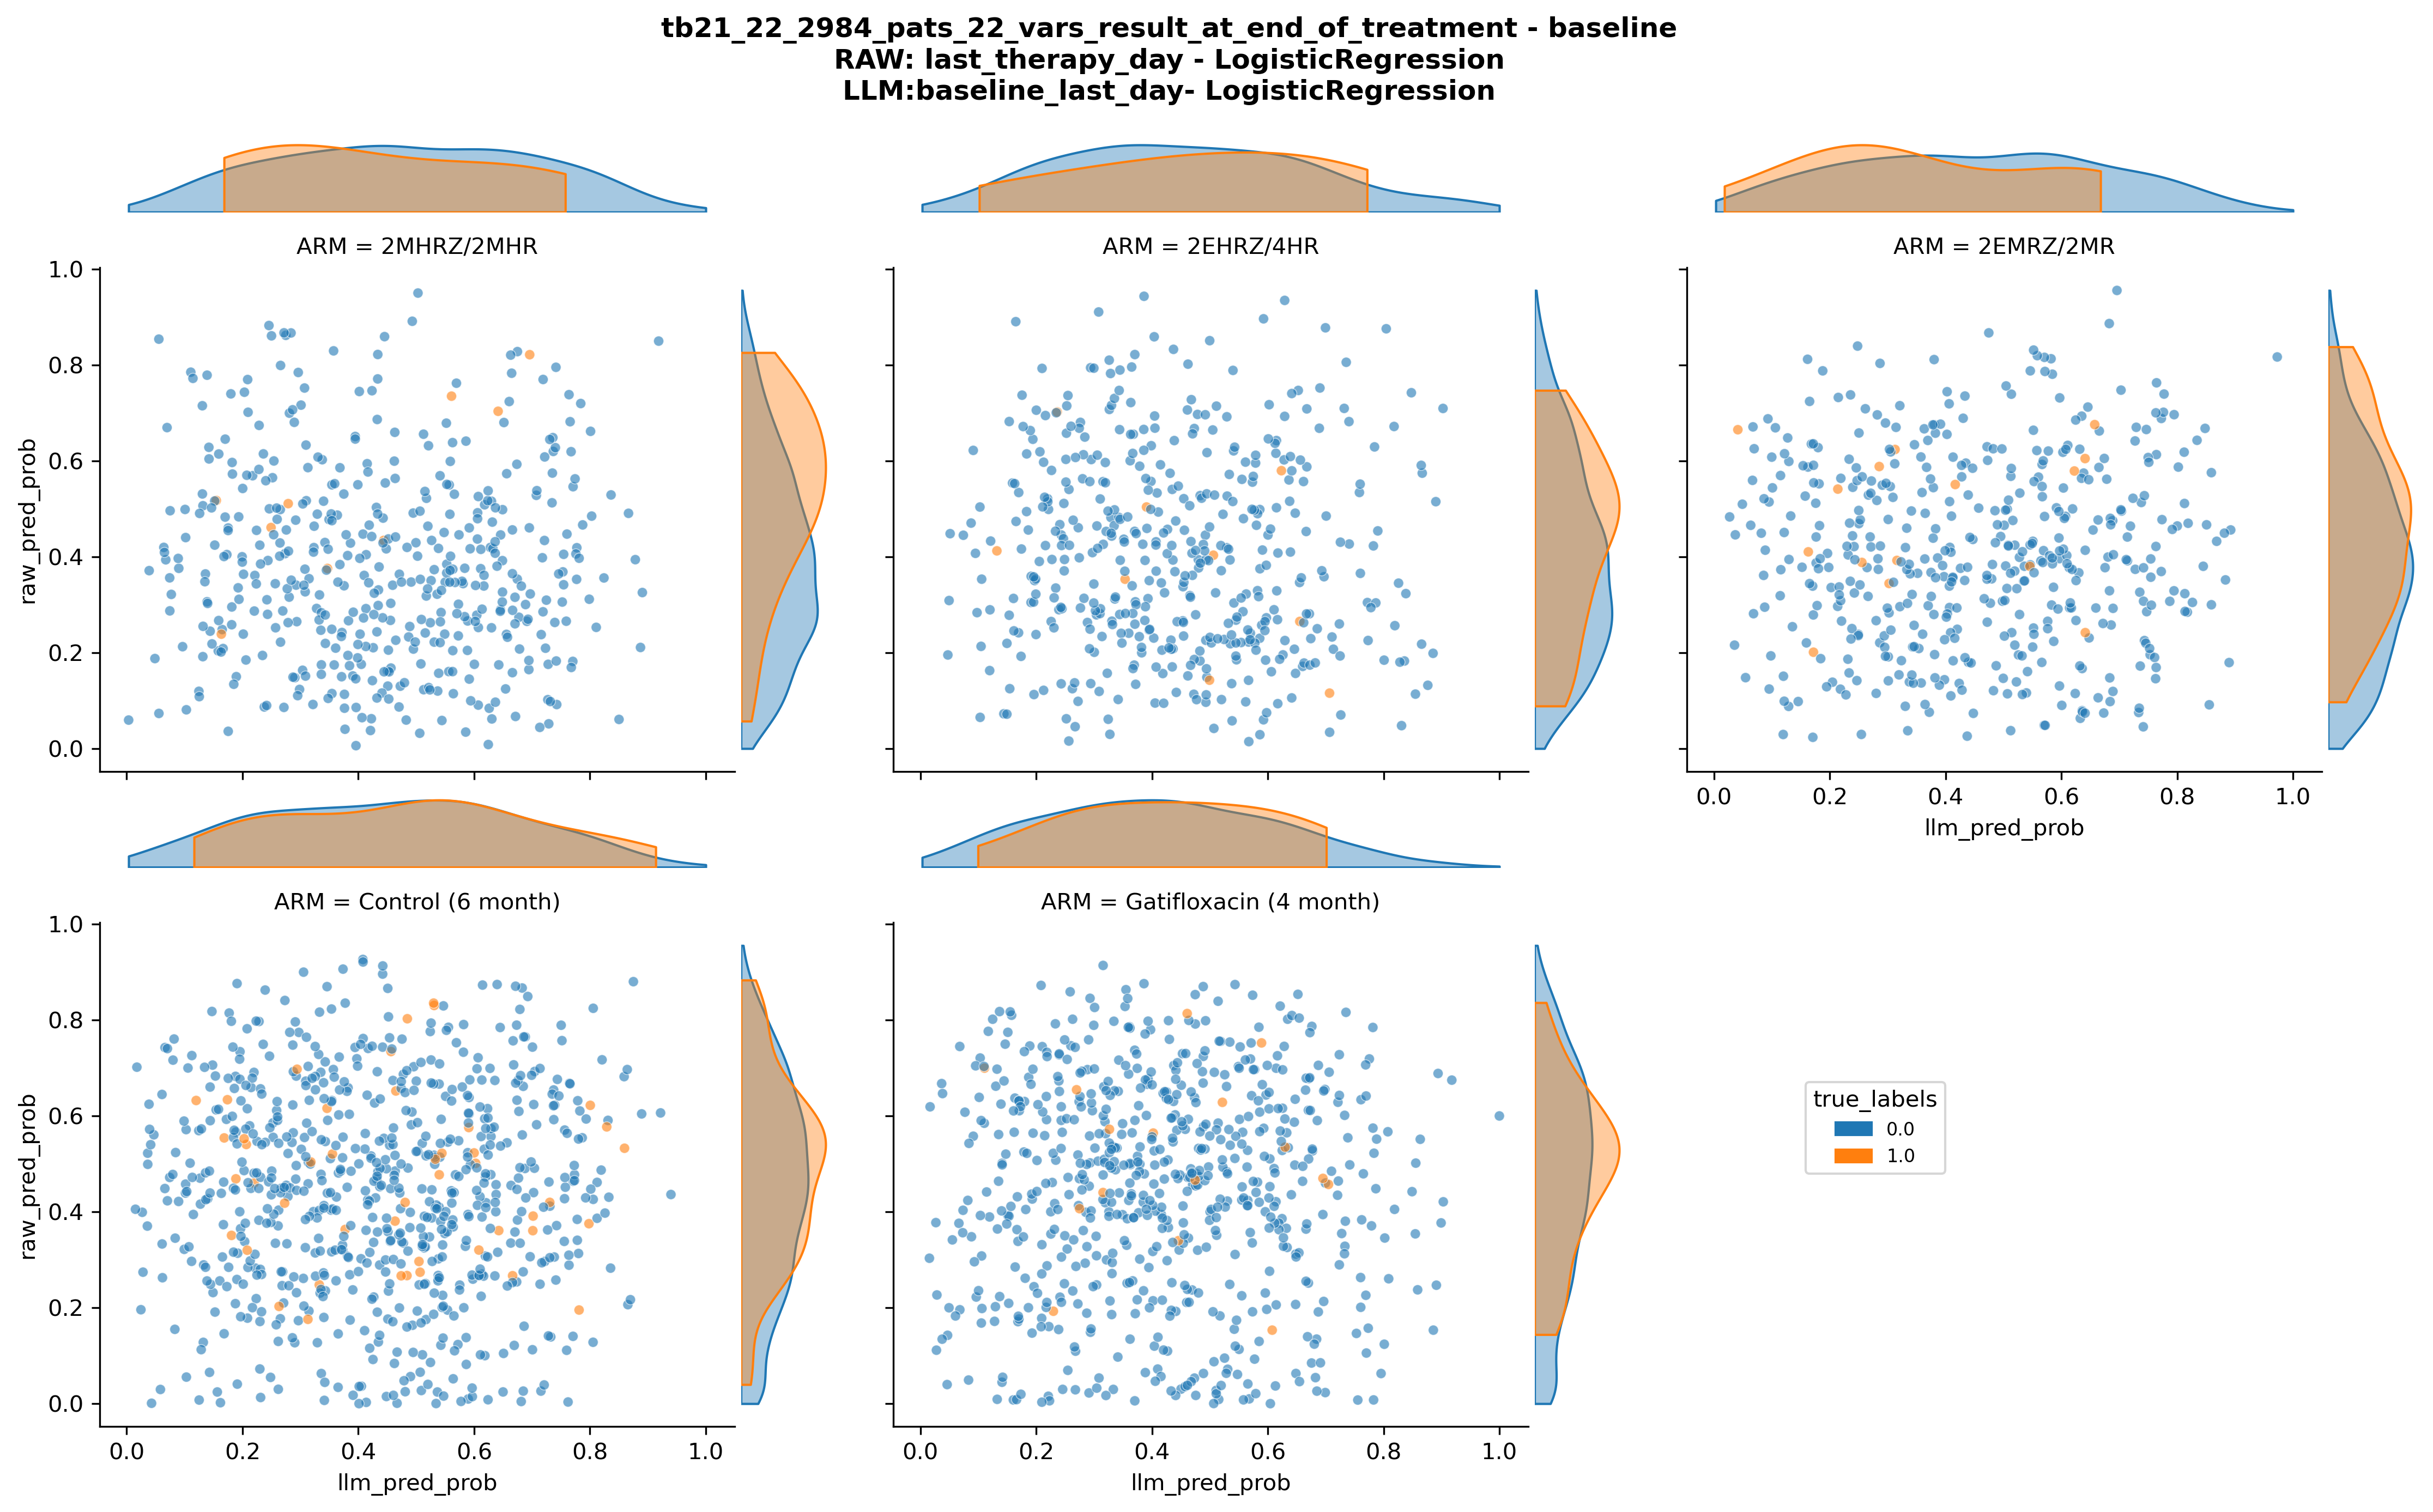

In [38]:
from matplotlib.patches import Patch
from matplotlib.colorbar import ColorbarBase
from matplotlib.colors import Normalize
import matplotlib
import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import fcluster

figtitle_size=20
subtitle_size=18
x_tick_size=31
y_tick_size=31
y_label_size=15
legend_fontsize=11.5
axis_lw=1.6

pats_with_relapse_df=extract_21_22_relapse_pats()

shap_plot_types=['bar','dot'] #'dot'


suptitle_study_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox',
              'TB-1021':'REMox',
              'TB-1022':'OFLOTUB'}

study_dict={'TB-1021':'REMox',
             'TB-1022':'OFLOTUB'}

suptitle_training_type_dict={'all_days_in_period':'all visits in period',
                             'last_therapy_day':'visit at end of period'}


raw_data_training_data_types=['all_days_in_period','last_therapy_day']
llm_training_data_types=['full','pca']

model_names_for_plotting=['XGBoost','LogisticRegression'][:]

parameters_for_analysis_= [*parameters_for_analysis][:1]
period_end_days_=period_end_days[:1]
raw_data_training_data_types_ = raw_data_training_data_types[1:]

model_names_ = model_names_for_plotting[1:]
llm_data_inclusion_types_=['baseline_last_day','baseline_vars','all_days'][:1]
llm_training_data_types_ = ['full','pca'][:1]


### loop over ML models, train them & training results in a dictionary
print('\n======= Loading Raw data model======\n')

for data_param_key in parameters_for_analysis_:
    print('\n===========',data_param_key,'===========\n')
    ## Define X and y dataframes for training

    #outcome_label=data_param_key.split('vars_')[-1].upper()
    outcome_label = parameters_for_analysis[data_param_key]['result_cat']
    
    fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_preproc_data_with_imp.csv.gz'
    X=pd.read_csv(fn,index_col=0)
    arm_pat_dict=X.groupby('USUBJID').apply(lambda x: x['ARM'].unique()[0]).to_dict()
    study_pat_dict=X.groupby('USUBJID').apply(lambda x: x['STUDYID'].unique()[0]).to_dict()

    l,k=[],[]
    
    for period_end_day in period_end_days_:      
        print(f'{period_end_day}')

        for raw_training_data_type in raw_data_training_data_types_:
            print(f'{raw_training_data_type} model')


            for model_name in model_names_:
                #print(f'Loading SHAP-values for model {model_name}')
                

                ### SAVE SHAP-value dataframes + merged X_test dataframes
                data_dir_=f'../data/model_interpretation/baseline/raw_SHAP_values_all_datapoints'
                os.makedirs(data_dir_,exist_ok=True)
                fn=os.path.join(data_dir_,
                            f'{data_param_key}_days_{raw_training_data_type}_{period_end_day}_{model_name}_SHAP_vals_across_CV_splits.csv.gz')
                raw_merged_shap_across_cv=pd.read_csv(fn,index_col=0)

                ## Save merged X_test dataframe
                fn=os.path.join(data_dir_,
                            f'{data_param_key}_days_{raw_training_data_type}_{period_end_day}_X_test_across_CV_splits.csv.gz')
                raw_merged_x_test_across_cv=pd.read_csv(fn,index_col=0)


                ### =======

                ### ======= LOAD LLM LOGITS! ===== ###
            
                print('\n======= Loading LLM model======\n')
                #for data_param_key in parameters_for_analysis_:
            
                ## LOAD FINAL PATIENT IDS FOR ANALYSIS, SAVED DURING PREPROCESSING OF THE BASELINE MODELS IN NOTEBOOK S9_3
                fn=f'../data/{data_param_key}_final_pat_ids_for_analysis.pickle'
                with open(fn, 'rb') as handle:
                    final_pat_ids_for_analysis=pickle.load(handle)
                
                #print(data_param_key)
                #fn='../data/'+data_param_key+'_all_data_concat.csv.gz'
                #X=pd.read_csv(fn,index_col=0,low_memory=False)
                
                ## Define X and y dataframes for training
                fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_preproc_data_with_imp.csv.gz'
                X_imp=pd.read_csv(fn,index_col=0)
            
                
                outcome_label=data_param_key.split('vars_')[-1].upper()
                    
                for llm_model_name in llm_model_names[:1]:
                    
                    for fine_tuned_tag in fine_tuned_tags[:1]:
                        
            
                        if 'text-embedding' in llm_model_name:
                            llm_model_name_with_tag=llm_model_name
                        else:
                            llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
                        
                        
                        #for period_end_day in period_end_days_:                
                        period_num = period_end_days.index(period_end_day)
                        
                        #print(f'Training on {period_end_day} days of data')
        
                        for llm_data_inclusion_type in llm_data_inclusion_types_:
        
                            for autoencoder_merged in autoenc_merged_bool_list[:1]:
        
                                ## Load embeddings created by LLM model
                                print(f'Loading embeddings of {data_param_key} data / {llm_model_name_with_tag} /{period_end_day} /{llm_data_inclusion_type} /autoenc {autoencoder_merged} model')
            
                                ## Load embeddings created by LLM model
                                #print(f'Loading embeddings of {llm_model_name_with_tag} model')
                                try:
                                    df=embed_dict[parameters_for_analysis[data_param_key]['fn']][llm_model_name_with_tag][period_end_day][llm_data_inclusion_type][autoencoder_merged]
                                except KeyError:
                                    warnings.warn(f"Embeddings of {parameters_for_analysis[data_param_key]['fn']} data / {llm_model_name_with_tag} model/ {period_end_day} days/ {llm_data_inclusion_type}/ autoenc {autoencoder_merged}not found! Check if they have been created. Skipping to next item.")
                                    continue
                
                                #print(data_param_key)
                                fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_all_data_concat.csv.gz'
                                X=pd.read_csv(fn,index_col=0,low_memory=False)
        
                            
        
                                for training_data_type in llm_training_data_types_:
        
                                    fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_4096_{llm_data_inclusion_type}_autoenc_{autoencoder_merged}_vars_training_results.pickle'                                
                                    with open(fn, 'rb') as handle:
                                        training_results=pickle.load(handle)

                                    #print('Loadding training results:\n',fn)
                                    
                                    cv_results=training_results['cv_results']
        
                                    #for n, model_name in enumerate(tqdm(model_names_, desc="Processing", unit="model")):
                                    print(model_name)
            
                                    ### SAVE SHAP-value dataframes + merged X_test dataframes
                                    data_dir_=f'../data/model_interpretation/LLM/raw_SHAP_values_all_datapoints'
                                    #os.makedirs(data_dir_,exist_ok=True)
                                    fn=os.path.join(data_dir_,
                                                f'{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{llm_data_inclusion_type}_autoenc_{autoencoder_merged}_SHAP_vals_across_CV_splits.csv.gz')
                                    #merged_shap_across_cv.to_csv(fn)
                                    merged_shap_across_cv=pd.read_csv(fn,index_col=0)



                                    prob_df = concat_raw_llm_pred_probs_dfs(raw_merged_shap_across_cv,merged_shap_across_cv,raw_merged_x_test_across_cv)
                                    prob_df_mean = avg_pred_probs_across_cvs(prob_df,arm_pat_dict)
                                    
                                    x_coln = 'llm_pred_prob'#_norm'
                                    y_coln = 'raw_pred_prob'#_norm'
                                    hue = 'true_labels'
                                    facet_col = 'ARM'
                                    #hue = 'ARM'
                                    #facet_col = 'true_labels'
                                    g = plot_facet_grid_scatter_kdeplot(prob_df,hue,facet_col,x_coln,y_coln)
                                    suptitle=f"{data_param_key} - {period_end_day}\nRAW: {raw_training_data_type} - {model_name}\nLLM:{llm_data_inclusion_type}- {model_name}"
                                    g.fig.suptitle(suptitle,y=1.15,fontweight='bold')
                                    
                                    
                                    
                                    raw_pred_prob_coln='raw_pred_prob'#_norm'
                                    llm_pred_prob_coln='llm_pred_prob'#_norm'
                                    max_fpr=0.1
                                    fig = plot_roc_auc_per_arm_across_raw_llm(prob_df,raw_pred_prob_coln,llm_pred_prob_coln,max_fpr)
                                    fig.suptitle(suptitle,y=1.12,fontweight='bold')


                                

In [46]:
X_test.sort_index()

,0,1,2,3,4,5,6,7,8,9,...,4086,4087,4088,4089,4090,4091,4092,4093,4094,4095
TB-1021/1001709,-1.223725,-1.500596,-0.522244,0.043711,-0.194564,-0.142501,0.318934,-0.976143,-0.039112,-0.147329,...,-1.878629,0.951145,-0.042033,0.165882,-0.003475,0.266795,0.354687,-0.672339,-0.071940,-0.379615
TB-1021/1006663,-0.662690,-1.721712,-0.768565,0.592449,-0.329097,0.045576,0.232836,-0.127926,0.256923,0.594316,...,-1.668886,0.985044,-0.490188,-0.232721,0.113173,1.145664,1.388665,-0.563870,-1.025835,-0.902139
TB-1021/1007783,-0.157759,-0.358165,-1.210059,0.874233,0.923455,1.469591,0.097539,-1.754753,0.205439,-1.374511,...,-0.870508,1.504831,-1.456188,-1.333628,1.287425,-0.895579,0.198614,-0.290113,-1.818920,-0.496121
TB-1021/1011747,1.445196,-1.205775,0.636004,0.310664,0.932733,1.845746,-0.357550,-1.025352,0.514345,-1.710652,...,-0.542361,1.403134,-1.639686,-1.523439,-0.283429,-0.678225,-1.030454,-0.469018,-0.762692,-0.517002
TB-1021/1018488,-0.438277,-0.505576,-0.472442,0.829741,0.315735,1.550196,-0.222253,-0.968888,0.836122,-1.139746,...,-1.171591,1.052842,-1.161607,-1.694269,0.424233,-0.527021,-0.113530,-0.130410,-1.983385,-0.986155
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TB-1022/53492,-3.620143,-1.334759,-6.289928,-2.907611,-0.834757,-2.876341,4.697629,3.540424,-3.038076,-0.483470,...,1.978789,1.617828,-0.622362,3.051016,4.429132,1.419719,-2.415595,0.314217,-1.362074,0.308976
TB-1022/53495,-1.600419,-0.616133,-5.939964,-2.640657,0.134811,-3.682387,5.324914,3.251061,-3.604404,0.098107,...,2.878234,1.911621,-0.259058,3.440129,4.538003,1.306317,-2.240014,2.161016,-1.592324,0.739376
TB-1022/53499,-1.600419,-0.468723,-4.725856,-2.922442,0.784283,-2.338977,4.537733,3.893716,-3.115303,-0.835618,...,2.483908,1.832523,-0.508467,3.174393,5.113464,1.381919,-2.220505,2.241782,-0.890609,0.455391
TB-1022/53502,-2.490059,-0.505576,-6.009957,-3.886442,-0.394044,-2.950229,4.599231,3.984562,-2.188584,0.290188,...,2.405677,2.148915,-1.205900,2.481581,4.320261,1.816628,-1.459653,1.778790,-0.488584,-0.738405


In [47]:
prob_df.reset_index().loc[(prob_df.reset_index()['cv_repeat_num']==0)&\
                    ~(prob_df.reset_index()['llm_pred_prob_norm'].isna()),:].sort_values('USUBJID')

,USUBJID,cv_repeat_num,pred_prob,true_labels,ARM,raw_pred_prob_norm,raw_pred_prob,raw_logits,llm_pred_prob_norm,llm_pred_prob,...,mh_DYSPNEA,mh_WEIGHT LOSS,RACE_ASIAN,RACE_BLACK,RACE_MIXED RACE OR COLOURED,RACE_OTHER,SEX_F,SEX_M,BMI,data_type
14372,TB-1021/1001933,0,NaN,NaN,NaN,NaN,NaN,NaN,0.275777,0.253072,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14388,TB-1021/1003959,0,NaN,NaN,NaN,NaN,NaN,NaN,0.669441,0.601513,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14407,TB-1021/1006439,0,NaN,NaN,NaN,NaN,NaN,NaN,0.276246,0.253487,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14466,TB-1021/1012429,0,NaN,NaN,NaN,NaN,NaN,NaN,0.765448,0.686491,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14477,TB-1021/1013072,0,NaN,NaN,NaN,NaN,NaN,NaN,0.405740,0.368105,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25679,TB-1022/53133,0,NaN,NaN,NaN,NaN,NaN,NaN,0.838529,0.751177,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25704,TB-1022/53141,0,NaN,NaN,NaN,NaN,NaN,NaN,0.702284,0.630583,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25715,TB-1022/53143,0,NaN,NaN,NaN,NaN,NaN,NaN,0.357917,0.325776,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25753,TB-1022/53486,0,NaN,NaN,NaN,NaN,NaN,NaN,0.411245,0.372978,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
#prob_df['llm_pred_prob']#.value_counts(dropna=False)
raw_merged_shap_across_cv

,AGE,Weight,Temperature,Diastolic Blood Pressure,Systolic Blood Pressure,Heart Rate,Height,Blood Creatinine,Blood Hemoglobin,Blood Alanine Aminotransferase,...,RACE_OTHER,SEX_F,SEX_M,BMI,data_type,pred_prob,true_labels,USUBJID,cv_repeat_num,ARM
0,0.062557,-0.362639,-0.019410,-0.013827,-0.035090,0.126359,-0.006492,-0.045065,0.329471,-0.258133,...,-0.001232,0.072599,0.068951,-0.279391,test,0.228827,0,TB-1021/1001709,0,2MHRZ/2MHR
1,-0.028688,-0.114781,-0.035063,0.041104,-0.133415,-0.044038,0.002695,0.023398,-0.443785,0.169441,...,-0.001884,-0.000373,-0.008625,0.066664,test,0.185587,0,TB-1021/1006663,0,2EMRZ/2MR
2,-0.015042,-0.078970,0.093934,0.040789,0.145851,0.056970,0.007952,0.037852,-0.546982,0.133226,...,-0.001345,0.091526,0.089982,0.004135,test,0.418561,0,TB-1021/1007783,0,2MHRZ/2MHR
3,-0.007672,0.030388,-0.121174,-0.078734,0.007121,-1.242091,-0.025470,-0.009034,-0.126369,-0.843656,...,-0.000604,-0.188203,-0.193071,-0.078667,test,0.012550,0,TB-1021/1011747,0,2EHRZ/4HR
4,-0.036957,-0.156486,-0.070415,0.050449,0.054049,-0.057577,0.005690,-0.016843,0.310215,0.011246,...,-0.001518,0.069468,0.064635,-0.022597,test,0.469123,0,TB-1021/1018488,0,2EMRZ/2MR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
569,-0.045851,0.000924,0.016996,-0.113047,-0.053535,0.359893,-0.101908,0.021090,-0.150254,-0.097562,...,0.000301,-0.244465,-0.262456,0.023753,test,0.452985,0,TB-1022/53488,24,Control (6 month)
570,-0.017705,0.027442,0.003888,0.021223,-0.169069,0.138480,-0.147708,0.030786,0.051717,0.011392,...,0.000181,-0.264022,-0.287170,0.059853,test,0.374733,0,TB-1022/53493,24,Gatifloxacin (4 month)
571,0.081618,-0.017635,0.009451,-0.371376,-0.217934,0.042114,0.089055,0.019877,-0.133274,-0.319763,...,-0.000512,0.092080,0.102750,-0.042700,test,0.368827,0,TB-1022/53497,24,Gatifloxacin (4 month)
572,-0.048826,0.156171,0.007404,-0.231410,-0.082337,0.400765,0.270514,0.024999,-0.455979,0.092336,...,0.000082,-0.126702,-0.121473,-0.065081,test,0.483565,0,TB-1022/53498,24,Gatifloxacin (4 month)


In [31]:
merged_shap_across_cv

,data_type,pred_prob,true_labels,USUBJID,cv_repeat_num,ARM
0,test,0.755520,0.0,TB-1021/2850123,0,2EMRZ/2MR
1,test,0.218046,0.0,TB-1022/11133,0,Gati-arm regimen (4 month regimen)
2,test,0.447617,0.0,TB-1022/31037,0,Control-arm regimen (6 month regimen)
3,test,0.554709,0.0,TB-1021/2861250,0,2EMRZ/2MR
4,test,0.698821,0.0,TB-1021/2010019,0,2MHRZ/2MHR
...,...,...,...,...,...,...
566,test,0.784664,0.0,TB-1022/11161,24,Control-arm regimen (6 month regimen)
567,test,0.069379,0.0,TB-1021/1570203,24,2MHRZ/2MHR
568,test,0.186845,0.0,TB-1022/53500,24,Gati-arm regimen (4 month regimen)
569,test,0.300695,0.0,TB-1021/1104035,24,2EMRZ/2MR


In [ ]:
prob_df['ARM'].value_counts(dropna=False)

In [ ]:
plot_df = concat_raw_llm_pred_probs_dfs(raw,llm,raw_merged_x_test_across_cv)
plot_df_mean = avg_pred_probs_across_cvs(plot_df,pats_with_relapse_df)

## Plot raw vs. LLM logits

In [ ]:


hue='mb_ZN-smear'
hue='true_labels'
#hue='mb_LJ-culture'
#hue='SEX_M'
#hue='ARM'
x_coln='llm_pred_prob_norm'
y_coln='raw_pred_prob_norm'

#x_coln='llm_logits'
#y_coln='raw_logits'
# Create the JointGrid
g = sns.JointGrid(
    data=plot_df,
    x=x_coln,
    y=y_coln,
    hue=hue
)

# Scatter plot
#g.plot_joint(sns.scatterplot, s=10,alpha=0.5)

sns.scatterplot(
    data=plot_df,
    x=x_coln,
    y=y_coln,
    hue=hue,
    s=25,
    alpha=0.8,
    #style='mb_ZN-smear',
    ax=g.ax_joint
)


hue='ARM'

# Marginal KDE plots with independent normalization
for ax, var in zip([g.ax_marg_x, g.ax_marg_y], [x_coln, y_coln]):
    sns.kdeplot(
        data=plot_df,
        x=var if ax is g.ax_marg_x else None,
        y=None if ax is g.ax_marg_x else var,
        hue=hue,
        ax=ax,
        cut=0,
        #size=5,
        #alpha=0.5,
        common_norm=False,
        fill=True,
        legend=False
    )
    
    handles,labels=g.ax_joint.get_legend_handles_labels()

    
    g.ax_marg_x.legend(handles=handles,
                      labels=labels,
                      fontsize=6,
                      bbox_to_anchor=(0.75,0.5),
                      markerscale=1,
                      loc='center')

# Add legend
g.ax_joint.legend_.remove()  # remove the duplicate
#g.ax_joint.legend(title=hue)

plt.tight_layout()
plt.show()

### CALCULATE RATIO OF RELAPSING PATIENTS BELONGING TO DIFFERENT ARMS 
plot_df_mean = plot_df.reset_index().groupby('USUBJID').apply(lambda x:x.loc[:,num_col].mean())
plot_df_mean['DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE']=np.nan
plot_df_mean.loc[:,'DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE']=pats_with_relapse_df.loc[plot_df_mean.index.get_level_values('USUBJID'),'DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE'].values

plot_df_mean['ARM']=pats_with_relapse_df.loc[plot_df_mean.index,'ARM'].values
plot_df_mean[~plot_df_mean['DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE'].isna()]['ARM'].value_counts(normalize=True)

In [ ]:


### CALCULATE RATIO OF RELAPSING PATIENTS BELONGING TO DIFFERENT ARMS 
plot_df_mean['DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE']=np.nan
plot_df_mean.loc[:,'DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE']=pats_with_relapse_df.loc[plot_df_mean.index.get_level_values('USUBJID'),'DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE'].values

plot_df_mean['ARM']=pats_with_relapse_df.loc[plot_df_mean.index,'ARM'].values
plot_df_mean[~plot_df_mean['DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE'].isna()]['ARM'].value_counts(normalize=True)


In [ ]:



result1 = plot_df.groupby(['cv_repeat_num', 'ARM']).apply(
                lambda df: safe_auc(
                    df,
                    pred_prob_coln='raw_pred_prob',
                    cv_results=cv_results,  # your full dict
                    cv_repeat_num=df.name[0])).to_frame()

result1['model']='raw'
result2 = plot_df.groupby(['cv_repeat_num', 'ARM']).apply(
                lambda df: safe_auc(
                    df,
                    pred_prob_coln='llm_pred_prob',
                    cv_results=cv_results,  # your full dict
                    cv_repeat_num=df.name[0])).to_frame()

result2['model']='llm'
result = pd.concat([result1,result2])


fig,ax=plt.subplots(1,1,figsize=(10,4))
sns.boxplot(data=result.reset_index(),
            x='ARM',
            hue='model',
            boxprops={'fill': None},
            legend=False,
            ax=ax,
            y=0)


sns.stripplot(data=result.reset_index(),
            x='ARM',
            hue='model',
            dodge=True,
            ax=ax,
            y=0)

In [ ]:
result1

## Pred. logits - days between last therapy day - relapse

In [ ]:
pats_with_relapse_df=extract_21_22_relapse_pats()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr,spearmanr
from statsmodels.stats.multitest import fdrcorrection

raw=raw_merged_shap_across_cv.loc[raw_merged_shap_across_cv['data_type']=='test',['pred_prob','true_labels','USUBJID','cv_repeat_num','ARM']]
llm=merged_shap_across_cv[['pred_prob','true_labels','USUBJID','cv_repeat_num','ARM']]

l=[]
for cv_rep,x in raw.groupby('cv_repeat_num'):
    l.append((x['pred_prob']-x['pred_prob'].min())/(x['pred_prob'].max()-x['pred_prob'].min()))

raw['raw_pred_prob_norm']=pd.concat(l).values
raw['raw_pred_prob']=raw['pred_prob']

l=[]
for cv_rep,x in llm.groupby('cv_repeat_num'):
    l.append((x['pred_prob']-x['pred_prob'].min())/(x['pred_prob'].max()-x['pred_prob'].min()))


llm['llm_pred_prob_norm']=pd.concat(l).values
llm['llm_pred_prob']=llm['pred_prob']


raw = raw.sort_values(['USUBJID','cv_repeat_num']).set_index(['USUBJID','cv_repeat_num'])
#raw['exp_setup']='raw_data'
llm = llm.sort_values(['USUBJID','cv_repeat_num']).set_index(['USUBJID','cv_repeat_num'])
#llm['exp_setup']='LLM'


x_test__ = raw_merged_x_test_across_cv[raw_merged_x_test_across_cv['data_type']=='test'].reset_index().sort_values(['USUBJID','cv_repeat_num']).set_index(['USUBJID','cv_repeat_num'])

plot_df = pd.concat([raw,llm,
                     x_test__],axis=1)
plot_df=plot_df.loc[:,~plot_df.columns.duplicated()]

plot_df['raw_logits']=np.log(plot_df['raw_pred_prob'] / (1 - plot_df['raw_pred_prob']))
plot_df['llm_logits']=np.log(plot_df['llm_pred_prob'] / (1 - plot_df['llm_pred_prob']))


num_col = [col for col in plot_df.columns if col not in ['ARM','data_type']]

#plot_df = plot_df.reset_index().groupby('USUBJID').apply(lambda x:x.loc[:,num_col].mean())
#plot_df['ARM']=pats_with_relapse_df.loc[plot_df.index,'ARM'].values


plot_df['DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE']=np.nan
plot_df.loc[:,'DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE']=pats_with_relapse_df.loc[plot_df.index.get_level_values('USUBJID'),'DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE'].values



hue='mb_ZN-smear'
hue='true_labels'
#hue='mb_LJ-culture'
#hue='SEX_M'
hue='ARM'


for y_coln in ['raw_pred_prob_norm','llm_pred_prob_norm']:
    
    x_coln='DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE'
    #y_coln='raw_logits'
    #y_coln='raw_pred_prob_norm'
    #y_coln='llm_pred_prob_norm'
    #y_coln='llm_logits'
    # Create the JointGrid
    g = sns.JointGrid(
        data=plot_df,
        x=x_coln,
        y=y_coln,
        hue=hue,
        height=5,
        ratio=2
    )
    
    # Scatter plot
    g.plot_joint(sns.scatterplot, s=10,alpha=0.5)
    
    #hue='ARM'
    # Marginal KDE plots with independent normalization
    for ax, var in zip([g.ax_marg_x, g.ax_marg_y], [x_coln, y_coln]):
        sns.kdeplot(
            data=plot_df,
            x=var if ax is g.ax_marg_x else None,
            y=None if ax is g.ax_marg_x else var,
            hue=hue,
            ax=ax,
            cut=0,
            #size=5,
            #alpha=0.5,
            common_norm=False,
            fill=True,
            legend=False
        )

    
    # Add legend
    #g.ax_joint.legend_.remove()  # remove the duplicate
    #g.ax_marg_x.legend_.remove()  # remove the duplicate
    handles,labels=g.ax_joint.get_legend_handles_labels()

    
    g.ax_marg_x.legend(handles=handles,
                      labels=labels,
                      fontsize=6,
                      bbox_to_anchor=(0.75,0.5),
                      markerscale=1,
                      loc='center')
    

    g.ax_joint.legend_.remove()
    
    plt.tight_layout()
    plt.show()


### CALCULATE RATIO OF RELAPSING PATIENTS BELONGING TO DIFFERENT ARMS 
plot_df_mean = plot_df.reset_index().groupby('USUBJID').apply(lambda x:x.loc[:,num_col].mean())
plot_df_mean['DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE']=np.nan
plot_df_mean.loc[:,'DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE']=pats_with_relapse_df.loc[plot_df_mean.index.get_level_values('USUBJID'),'DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE'].values

plot_df_mean['ARM']=pats_with_relapse_df.loc[plot_df_mean.index,'ARM'].values
plot_df_mean[~plot_df_mean['DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE'].isna()]['ARM'].value_counts(normalize=True)

In [ ]:

#for 
for pred_coln in ['raw_pred_prob_norm','llm_pred_prob_norm']:
    
    agg_df = (
        plot_df
        .groupby('USUBJID')
        .agg({
            pred_coln: ['mean', 'std'],
            'DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE': 'first',
            hue: 'first'  # Optional: keep hue if consistent per patient
        })
        .reset_index()
    )
    
    # Flatten MultiIndex column names
    agg_df.columns = ['USUBJID', 'logit_mean', 'logit_std', x_coln, hue]
    
    x_coln = 'DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE'
    y_coln = 'logit_mean'
    
    g = sns.JointGrid(
        data=agg_df,
        x=x_coln,
        y=y_coln,
        hue=hue,
        height=6,
    )
    
    # Main scatterplot with error bars
    sns.scatterplot(
        data=agg_df,
        x=x_coln,
        y=y_coln,
        hue=hue,
        ax=g.ax_joint,
        s=15,
        alpha=0.8
    )
    
    # Add error bars manually
    for _, row in agg_df.iterrows():
        g.ax_joint.errorbar(
            x=row[x_coln],
            y=row['logit_mean'],
            yerr=row['logit_std'],
            fmt='none',
            ecolor='gray',
            alpha=0.3,
            capsize=1
        )
    
    # Marginal KDEs
    for ax, var in zip([g.ax_marg_x, g.ax_marg_y], [x_coln, y_coln]):
        sns.kdeplot(
            data=agg_df,
            x=var if ax is g.ax_marg_x else None,
            y=None if ax is g.ax_marg_x else var,
            hue=hue,
            ax=ax,
            cut=0,
            fill=True,
            common_norm=False,
            legend=False
        )
    
    # Clean legend
    #g.ax_joint.legend_.remove()
    g.ax_joint.set_ylabel(f'mean {pred_coln}')
    # Optional: g.ax_joint.legend(title=hue)
    
    plt.tight_layout()
    plt.show()



In [ ]:
from scipy.stats import pearsonr,spearmanr
from statsmodels.stats.multitest import fdrcorrection

pred_coln='raw_pred_prob_norm'
pred_coln='llm_pred_prob_norm'

y_coln='raw_logits'
y_coln='llm_logits'

l=[]
for pred_coln,pred in zip(['raw_logits','llm_logits'],['raw','llm']):
    a_=plot_df.groupby('cv_repeat_num').apply(lambda x:pearsonr(x.loc[~x['DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE'].isna(),pred_coln],\
                                                              x.loc[~x['DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE'].isna(),'DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE'])[0])
    
    a__=plot_df.groupby('cv_repeat_num').apply(lambda x:pearsonr(x.loc[~x['DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE'].isna(),pred_coln],\
                                                              x.loc[~x['DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE'].isna(),'DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE'])[1])
    
    #corr, p_value = spearmanr(val_df.values, pred_df_subset.values)
    a___=pd.concat([a_,a__],axis=1)
    a___.columns=[f'{pred}_corr',f'{pred}_p_val']
    a___[f'{pred}_fdr']=fdrcorrection(a___[f'{pred}_p_val'],alpha=0.05, method='indep')[1]
    l.append(a___)

p=pd.concat(l,axis=1)

In [ ]:
plt.hist(p['raw_corr'],label='raw',alpha=0.5);
plt.hist(p['llm_corr'],label='llm',alpha=0.5);
plt.legend()
            

In [ ]:
sns.scatterplot(data=p,
               x='raw_corr',
               y='llm_corr'
               )
plt.xlim(-0.9,0.2)
plt.ylim(-0.9,0.2)


In [ ]:
relapse_df